# VIX Multi-Horizon Stacking — Version Finale Complète
## 1785 modèles ML × 6 horizons × 4 régimes + modèles DL comme features supplémentaires
## Méta-modèle XGBoost sur probabilités OOF — Google Colab ready


In [14]:
# ============================================================
# INSTALLATION — Google Colab
# ============================================================
import subprocess, sys

packages = [
    'xgboost', 'lightgbm', 'yfinance', 'pandas_datareader',
    'arch', 'pykalman', 'hmmlearn', 'shap',
    'xlsxwriter', 'imbalanced-learn', 'statsmodels', 'seaborn'
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + packages, check=False)
print("Installation terminée.")


Installation terminée.


In [15]:
# ============================================================
# IMPORTS
# ============================================================
import os, time, json, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import pandas_datareader.data as web
import shap

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from arch import arch_model
from pykalman import KalmanFilter
from hmmlearn import hmm as hmmlib

import statsmodels.api as sm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}")


Python 3.12.13 | pandas 2.2.2 | numpy 2.0.2


In [16]:
# ============================================================
# CONFIGURATION
# ============================================================
CONFIG = {
    'seed':             42,
    'start_date':       '2000-01-01',
    'flat_thr':         0.003,
    'horizons':         [1, 2, 3, 5, 7, 10],
    'meta_horizons':    [5],         # cible principale du méta-modèle
    'min_f1_dir':       0.50,
    'max_feat_overlap': 0.80,        # seuil diversité features (pré-entraînement)
    'max_pred_corr':    0.85,        # seuil diversité prédictions (post-entraînement)
    'top_n_per_cell':   40,          # max modèles par (horizon, regime)
    'meta_n_estimators':400,
    'meta_max_depth':   4,
    'meta_lr':          0.03,
    'n_folds_oof':      5,
}

TARGET_COL = 'VIX_Amplitude_Class'

YF_TICKERS = """
^GSPC ^IXIC ^VIX ^VXN ^OVX ^GVZ ^EVZ ^VVIX
^FTSE ^N225 ^HSI ^GDAXI ^STOXX50E
SPY QQQ TLT GLD USO HYG LQD
AAPL AMZN MSFT NVDA INTC QCOM XOM WMT MCD SBUX
MS COF BLK SCHW CLX CPB LMT NOC GD HON
CCI PSA EQIX NEE TXN PAYX LUV CMCSA
XLK XLF XLE XLV XLU XLB XLI XLY
""".split()

FRED_SERIES = {
    'NFCI':   'NFCI',
    'STLFSI': 'STLFSI4',
    'T10Y2Y': 'T10Y2Y',
    'EFFR':   'EFFR',
}

# Résultats DL (meilleurs par horizon, issus du notebook DL)
# Ces F1 servent uniquement de référence — pas de prédictions DL disponibles ici
DL_RESULTS = {
    1: {'model':'ENSEMBLE', 'F1_dir':0.5528, 'F1_UP_FORT':0.2960, 'F1_DOWN_FORT':0.3303},
    3: {'model':'CNN-LSTM', 'F1_dir':0.6188, 'F1_UP_FORT':0.4809, 'F1_DOWN_FORT':0.3005},
    5: {'model':'TFT',      'F1_dir':0.6225, 'F1_UP_FORT':0.5879, 'F1_DOWN_FORT':0.0894},
    7: {'model':'TFT',      'F1_dir':0.6128, 'F1_UP_FORT':0.5492, 'F1_DOWN_FORT':0.2255},
}

ML_REFS = {
    'LogReg h=5j GLOBAL':       {'F1_dir':0.634,'F1_UP_FORT':0.406,'F1_DOWN_FORT':0.575},
    'RandomForest h=5j GLOBAL': {'F1_dir':0.620,'F1_UP_FORT':0.412,'F1_DOWN_FORT':0.462},
    'Stacking V1 (27 modèles)': {'F1_dir':0.596,'F1_UP_FORT':None,'F1_DOWN_FORT':None},
}

print("Config chargée.")


Config chargée.


In [17]:
# ============================================================
# PANEL ML — 1785 runs (F1_dir >= 0.50, anti-leakage)
# Extraits de tous les Excel de résultats précédents
# ============================================================
ALL_RUNS = json.loads('[{"model_id": "egarch_v2_h1_CALM_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 5, "F1_dir": 0.5787, "F1_UP_FORT": 0.2955, "F1_DOWN_FORT": 0.3404, "Acc_dir": 0.5797, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N6", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 6, "F1_dir": 0.5644, "F1_UP_FORT": 0.2353, "F1_DOWN_FORT": 0.4086, "Acc_dir": 0.5652, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.5778, "F1_UP_FORT": 0.2, "F1_DOWN_FORT": 0.3596, "Acc_dir": 0.5797, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.5543, "F1_UP_FORT": 0.1333, "F1_DOWN_FORT": 0.3529, "Acc_dir": 0.5556, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 9, "F1_dir": 0.6027, "F1_UP_FORT": 0.1429, "F1_DOWN_FORT": 0.3301, "Acc_dir": 0.6039, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 10, "F1_dir": 0.5926, "F1_UP_FORT": 0.1975, "F1_DOWN_FORT": 0.3368, "Acc_dir": 0.5942, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 11, "F1_dir": 0.5926, "F1_UP_FORT": 0.2045, "F1_DOWN_FORT": 0.25, "Acc_dir": 0.5942, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 12, "F1_dir": 0.618, "F1_UP_FORT": 0.137, "F1_DOWN_FORT": 0.2828, "Acc_dir": 0.6184, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N13", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 13, "F1_dir": 0.5741, "F1_UP_FORT": 0.0822, "F1_DOWN_FORT": 0.2885, "Acc_dir": 0.5749, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N14", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 14, "F1_dir": 0.5314, "F1_UP_FORT": 0.1558, "F1_DOWN_FORT": 0.2941, "Acc_dir": 0.5314, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 15, "F1_dir": 0.5507, "F1_UP_FORT": 0.1333, "F1_DOWN_FORT": 0.2941, "Acc_dir": 0.5507, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N16", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 16, "F1_dir": 0.569, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.3232, "Acc_dir": 0.57, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 17, "F1_dir": 0.5553, "F1_UP_FORT": 0.137, "F1_DOWN_FORT": 0.3301, "Acc_dir": 0.5556, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N18", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 18, "F1_dir": 0.5699, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.3232, "Acc_dir": 0.57, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d", "STLFSI4_ret_1d__minus__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_XGBoost_N19", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 19, "F1_dir": 0.5409, "F1_UP_FORT": 0.1389, "F1_DOWN_FORT": 0.3137, "Acc_dir": 0.5411, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d", "STLFSI4_ret_1d__minus__spx_vol_5d", "STLFSI4_ret_1d__macross__BDX_Becton_Dickinson_ret_1d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 5, "F1_dir": 0.5589, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.303, "Acc_dir": 0.5604, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 6, "F1_dir": 0.5765, "F1_UP_FORT": 0.2222, "F1_DOWN_FORT": 0.3505, "Acc_dir": 0.5797, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N7", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.6277, "F1_UP_FORT": 0.1519, "F1_DOWN_FORT": 0.34, "Acc_dir": 0.628, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N8", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.6027, "F1_UP_FORT": 0.1839, "F1_DOWN_FORT": 0.3269, "Acc_dir": 0.6039, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 9, "F1_dir": 0.596, "F1_UP_FORT": 0.2093, "F1_DOWN_FORT": 0.3654, "Acc_dir": 0.599, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 10, "F1_dir": 0.5772, "F1_UP_FORT": 0.1687, "F1_DOWN_FORT": 0.2737, "Acc_dir": 0.5797, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 11, "F1_dir": 0.5797, "F1_UP_FORT": 0.1975, "F1_DOWN_FORT": 0.25, "Acc_dir": 0.5797, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 12, "F1_dir": 0.565, "F1_UP_FORT": 0.0811, "F1_DOWN_FORT": 0.2887, "Acc_dir": 0.5652, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 13, "F1_dir": 0.5651, "F1_UP_FORT": 0.1412, "F1_DOWN_FORT": 0.2574, "Acc_dir": 0.5652, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 14, "F1_dir": 0.5748, "F1_UP_FORT": 0.2105, "F1_DOWN_FORT": 0.297, "Acc_dir": 0.5749, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N15", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 15, "F1_dir": 0.5584, "F1_UP_FORT": 0.125, "F1_DOWN_FORT": 0.2947, "Acc_dir": 0.5604, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 16, "F1_dir": 0.5307, "F1_UP_FORT": 0.1299, "F1_DOWN_FORT": 0.2198, "Acc_dir": 0.5314, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N17", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 17, "F1_dir": 0.5492, "F1_UP_FORT": 0.1408, "F1_DOWN_FORT": 0.2558, "Acc_dir": 0.5507, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N18", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 18, "F1_dir": 0.6135, "F1_UP_FORT": 0.2133, "F1_DOWN_FORT": 0.3838, "Acc_dir": 0.6135, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d", "STLFSI4_ret_1d__minus__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_LightGBM_N19", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 19, "F1_dir": 0.5744, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.2979, "Acc_dir": 0.5749, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d", "STLFSI4_ret_1d__minus__spx_vol_5d", "STLFSI4_ret_1d__macross__BDX_Becton_Dickinson_ret_1d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 5, "F1_dir": 0.5694, "F1_UP_FORT": 0.2045, "F1_DOWN_FORT": 0.3656, "Acc_dir": 0.57, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N6", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 6, "F1_dir": 0.5744, "F1_UP_FORT": 0.2247, "F1_DOWN_FORT": 0.3878, "Acc_dir": 0.5749, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.5892, "F1_UP_FORT": 0.1707, "F1_DOWN_FORT": 0.3956, "Acc_dir": 0.5894, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.6069, "F1_UP_FORT": 0.1266, "F1_DOWN_FORT": 0.375, "Acc_dir": 0.6087, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N9", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 9, "F1_dir": 0.6018, "F1_UP_FORT": 0.1882, "F1_DOWN_FORT": 0.4043, "Acc_dir": 0.6039, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 10, "F1_dir": 0.5602, "F1_UP_FORT": 0.1905, "F1_DOWN_FORT": 0.3261, "Acc_dir": 0.5604, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 11, "F1_dir": 0.5744, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.3434, "Acc_dir": 0.5749, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 12, "F1_dir": 0.565, "F1_UP_FORT": 0.1081, "F1_DOWN_FORT": 0.2553, "Acc_dir": 0.5652, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N13", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 13, "F1_dir": 0.5555, "F1_UP_FORT": 0.0556, "F1_DOWN_FORT": 0.2857, "Acc_dir": 0.5556, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N14", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 14, "F1_dir": 0.5603, "F1_UP_FORT": 0.1053, "F1_DOWN_FORT": 0.303, "Acc_dir": 0.5604, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N15", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 15, "F1_dir": 0.541, "F1_UP_FORT": 0.1067, "F1_DOWN_FORT": 0.3429, "Acc_dir": 0.5411, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N16", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 16, "F1_dir": 0.5726, "F1_UP_FORT": 0.2025, "F1_DOWN_FORT": 0.3232, "Acc_dir": 0.5749, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 17, "F1_dir": 0.5845, "F1_UP_FORT": 0.1143, "F1_DOWN_FORT": 0.2917, "Acc_dir": 0.5845, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N18", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 18, "F1_dir": 0.5555, "F1_UP_FORT": 0.1867, "F1_DOWN_FORT": 0.3043, "Acc_dir": 0.5556, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d", "STLFSI4_ret_1d__minus__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_N19", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 19, "F1_dir": 0.57, "F1_UP_FORT": 0.1739, "F1_DOWN_FORT": 0.2887, "Acc_dir": 0.57, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d", "STLFSI4_ret_1d__minus__spx_vol_5d", "STLFSI4_ret_1d__macross__BDX_Becton_Dickinson_ret_1d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 5, "F1_dir": 0.56, "F1_UP_FORT": 0.1842, "F1_DOWN_FORT": 0.3784, "Acc_dir": 0.5604, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 6, "F1_dir": 0.5584, "F1_UP_FORT": 0.169, "F1_DOWN_FORT": 0.3604, "Acc_dir": 0.5604, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.6183, "F1_UP_FORT": 0.16, "F1_DOWN_FORT": 0.4158, "Acc_dir": 0.6184, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.56, "F1_UP_FORT": 0.1892, "F1_DOWN_FORT": 0.42, "Acc_dir": 0.5604, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 9, "F1_dir": 0.5981, "F1_UP_FORT": 0.2222, "F1_DOWN_FORT": 0.3226, "Acc_dir": 0.599, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 10, "F1_dir": 0.5409, "F1_UP_FORT": 0.2716, "F1_DOWN_FORT": 0.3125, "Acc_dir": 0.5411, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 11, "F1_dir": 0.5409, "F1_UP_FORT": 0.1867, "F1_DOWN_FORT": 0.3148, "Acc_dir": 0.5411, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 12, "F1_dir": 0.5458, "F1_UP_FORT": 0.1892, "F1_DOWN_FORT": 0.2885, "Acc_dir": 0.5459, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N13", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 13, "F1_dir": 0.5737, "F1_UP_FORT": 0.1449, "F1_DOWN_FORT": 0.3186, "Acc_dir": 0.5749, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N14", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 14, "F1_dir": 0.5234, "F1_UP_FORT": 0.1918, "F1_DOWN_FORT": 0.3214, "Acc_dir": 0.5266, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N15", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 15, "F1_dir": 0.5501, "F1_UP_FORT": 0.2, "F1_DOWN_FORT": 0.3333, "Acc_dir": 0.5507, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N16", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 16, "F1_dir": 0.5553, "F1_UP_FORT": 0.2133, "F1_DOWN_FORT": 0.3455, "Acc_dir": 0.5556, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N17", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 17, "F1_dir": 0.5941, "F1_UP_FORT": 0.1176, "F1_DOWN_FORT": 0.3333, "Acc_dir": 0.5942, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N18", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 18, "F1_dir": 0.5473, "F1_UP_FORT": 0.1918, "F1_DOWN_FORT": 0.3178, "Acc_dir": 0.5507, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d", "STLFSI4_ret_1d__minus__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_RandomForest_N19", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 19, "F1_dir": 0.5623, "F1_UP_FORT": 0.1739, "F1_DOWN_FORT": 0.3186, "Acc_dir": 0.5652, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d", "STLFSI4_ret_1d__minus__spx_vol_5d", "STLFSI4_ret_1d__macross__BDX_Becton_Dickinson_ret_1d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 5, "F1_dir": 0.5446, "F1_UP_FORT": 0.1892, "F1_DOWN_FORT": 0.3301, "Acc_dir": 0.5459, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 6, "F1_dir": 0.5697, "F1_UP_FORT": 0.1795, "F1_DOWN_FORT": 0.3469, "Acc_dir": 0.57, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.5441, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.3409, "Acc_dir": 0.5459, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.5344, "F1_UP_FORT": 0.2245, "F1_DOWN_FORT": 0.3218, "Acc_dir": 0.5362, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 9, "F1_dir": 0.5331, "F1_UP_FORT": 0.2308, "F1_DOWN_FORT": 0.3146, "Acc_dir": 0.5362, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 10, "F1_dir": 0.542, "F1_UP_FORT": 0.2353, "F1_DOWN_FORT": 0.2989, "Acc_dir": 0.5459, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 11, "F1_dir": 0.5543, "F1_UP_FORT": 0.28, "F1_DOWN_FORT": 0.2955, "Acc_dir": 0.5556, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 12, "F1_dir": 0.5459, "F1_UP_FORT": 0.2727, "F1_DOWN_FORT": 0.3011, "Acc_dir": 0.5459, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N13", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 13, "F1_dir": 0.5553, "F1_UP_FORT": 0.2921, "F1_DOWN_FORT": 0.3441, "Acc_dir": 0.5556, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N14", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 14, "F1_dir": 0.5456, "F1_UP_FORT": 0.2889, "F1_DOWN_FORT": 0.3226, "Acc_dir": 0.5459, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N15", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 15, "F1_dir": 0.5553, "F1_UP_FORT": 0.2889, "F1_DOWN_FORT": 0.3191, "Acc_dir": 0.5556, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N16", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 16, "F1_dir": 0.5507, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.3061, "Acc_dir": 0.5507, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N17", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 17, "F1_dir": 0.5383, "F1_UP_FORT": 0.225, "F1_DOWN_FORT": 0.3301, "Acc_dir": 0.5411, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N18", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 18, "F1_dir": 0.5338, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.32, "Acc_dir": 0.5362, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d", "STLFSI4_ret_1d__minus__spx_vol_5d"]}, {"model_id": "egarch_v2_h1_CALM_LogisticRegression_N19", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 19, "F1_dir": 0.5234, "F1_UP_FORT": 0.2025, "F1_DOWN_FORT": 0.3366, "Acc_dir": 0.5266, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d", "EOG_EOGResources_ret_5d", "VIX_Price_zscore_60d__div__spx_vol_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_5d", "ITT_ITTInc_ret_5d", "NVDA_vol_20d", "hmm_p_stress__zrel__spx_vol_5d", "MS_MorganStanley_zscore_60d", "STLFSI4_ret_1d__ret5x__VRP", "AMGN_Amgen_ret_1d", "NFCI_ret_5d", "STLFSI4_ret_1d__minus__spx_vol_5d", "STLFSI4_ret_1d__macross__BDX_Becton_Dickinson_ret_1d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_Optuna_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.5987, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.3711, "Acc_dir": 0.599, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d"]}, {"model_id": "egarch_v2_h1_CALM_GradientBoosting_OptunaCal_N7", "source": "egarch_v2", "algo": "GradientBoostingCal", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.5942, "F1_UP_FORT": 0.1176, "F1_DOWN_FORT": 0.3958, "Acc_dir": 0.5942, "train_start": "2001-08-01", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__ret5x__LLY_ret_1d", "hmm_p_stress__minus__spx_vol_5d", "XOM_ret_1d", "EWQ_France_ret_1d__minus__BDX_Becton_Dickinson_ret_1d", "MS_MorganStanley_ret_5d", "VIX_Price_zscore_60d__div__VRP", "MSTR_Bitcoin3_ret_5d"]}, {"model_id": "egarch_v2_h1_NORMAL_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5058, "F1_UP_FORT": 0.3051, "F1_DOWN_FORT": 0.3509, "Acc_dir": 0.5122, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v2_h1_NORMAL_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 10, "F1_dir": 0.5026, "F1_UP_FORT": 0.2871, "F1_DOWN_FORT": 0.3261, "Acc_dir": 0.5065, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d", "PLD_Prologis_ret_5d", "T_ret_1d__div__BOVESPA_Brazil_ret_1d", "BAC_ret_1d__prod__BOVESPA_Brazil_ret_1d"]}, {"model_id": "egarch_v2_h1_NORMAL_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5263, "F1_UP_FORT": 0.2971, "F1_DOWN_FORT": 0.3461, "Acc_dir": 0.5395, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v2_h1_NORMAL_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 6, "F1_dir": 0.5268, "F1_UP_FORT": 0.2865, "F1_DOWN_FORT": 0.3491, "Acc_dir": 0.5395, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h1_NORMAL_LightGBM_N7", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5084, "F1_UP_FORT": 0.2993, "F1_DOWN_FORT": 0.2894, "Acc_dir": 0.5122, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d"]}, {"model_id": "egarch_v2_h1_NORMAL_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 10, "F1_dir": 0.504, "F1_UP_FORT": 0.2748, "F1_DOWN_FORT": 0.3294, "Acc_dir": 0.5079, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d", "PLD_Prologis_ret_5d", "T_ret_1d__div__BOVESPA_Brazil_ret_1d", "BAC_ret_1d__prod__BOVESPA_Brazil_ret_1d"]}, {"model_id": "egarch_v2_h1_NORMAL_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5038, "F1_UP_FORT": 0.3007, "F1_DOWN_FORT": 0.3325, "Acc_dir": 0.5065, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v2_h1_NORMAL_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5094, "F1_UP_FORT": 0.2693, "F1_DOWN_FORT": 0.3367, "Acc_dir": 0.5151, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d"]}, {"model_id": "egarch_v2_h1_NORMAL_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5226, "F1_UP_FORT": 0.2752, "F1_DOWN_FORT": 0.319, "Acc_dir": 0.5265, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d", "PLD_Prologis_ret_5d"]}, {"model_id": "egarch_v2_h1_NORMAL_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 10, "F1_dir": 0.504, "F1_UP_FORT": 0.2637, "F1_DOWN_FORT": 0.335, "Acc_dir": 0.5079, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d", "PLD_Prologis_ret_5d", "T_ret_1d__div__BOVESPA_Brazil_ret_1d", "BAC_ret_1d__prod__BOVESPA_Brazil_ret_1d"]}, {"model_id": "egarch_v2_h1_NORMAL_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5395, "F1_UP_FORT": 0.3167, "F1_DOWN_FORT": 0.4103, "Acc_dir": 0.5552, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v2_h1_NORMAL_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 1, "n_features": 6, "F1_dir": 0.5249, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.3883, "Acc_dir": 0.5438, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h1_NORMAL_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5126, "F1_UP_FORT": 0.2663, "F1_DOWN_FORT": 0.3983, "Acc_dir": 0.5194, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d"]}, {"model_id": "egarch_v2_h1_NORMAL_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5287, "F1_UP_FORT": 0.3021, "F1_DOWN_FORT": 0.3864, "Acc_dir": 0.5366, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d", "PLD_Prologis_ret_5d"]}, {"model_id": "egarch_v2_h1_NORMAL_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 1, "n_features": 10, "F1_dir": 0.5168, "F1_UP_FORT": 0.3089, "F1_DOWN_FORT": 0.3967, "Acc_dir": 0.5265, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d", "PLD_Prologis_ret_5d", "T_ret_1d__div__BOVESPA_Brazil_ret_1d", "BAC_ret_1d__prod__BOVESPA_Brazil_ret_1d"]}, {"model_id": "egarch_v2_h1_NORMAL_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5265, "F1_UP_FORT": 0.267, "F1_DOWN_FORT": 0.396, "Acc_dir": 0.5265, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v2_h1_NORMAL_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 6, "F1_dir": 0.5179, "F1_UP_FORT": 0.2822, "F1_DOWN_FORT": 0.3939, "Acc_dir": 0.5179, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h1_NORMAL_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5135, "F1_UP_FORT": 0.2689, "F1_DOWN_FORT": 0.3773, "Acc_dir": 0.5136, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d"]}, {"model_id": "egarch_v2_h1_NORMAL_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5007, "F1_UP_FORT": 0.2644, "F1_DOWN_FORT": 0.3618, "Acc_dir": 0.5007, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d", "PLD_Prologis_ret_5d"]}, {"model_id": "egarch_v2_h1_NORMAL_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 9, "F1_dir": 0.5036, "F1_UP_FORT": 0.2542, "F1_DOWN_FORT": 0.3575, "Acc_dir": 0.5036, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d", "PLD_Prologis_ret_5d", "T_ret_1d__div__BOVESPA_Brazil_ret_1d"]}, {"model_id": "egarch_v2_h1_NORMAL_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 10, "F1_dir": 0.5035, "F1_UP_FORT": 0.2682, "F1_DOWN_FORT": 0.3526, "Acc_dir": 0.5036, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d", "PLD_Prologis_ret_5d", "T_ret_1d__div__BOVESPA_Brazil_ret_1d", "BAC_ret_1d__prod__BOVESPA_Brazil_ret_1d"]}, {"model_id": "egarch_v2_h1_NORMAL_RandomForest_OptunaCal_N8", "source": "egarch_v2", "algo": "RandomForestCal", "regime": "NORMAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5034, "F1_UP_FORT": 0.2582, "F1_DOWN_FORT": 0.2899, "Acc_dir": 0.5151, "train_start": "2000-11-02", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_var_ev_h1__prod__heston_xi", "SBUX_vol_20d", "US5Y_Rate_ret_5d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__minus__XLY_Disc_zscore_60d", "EWY_Korea_ret_1d__prod__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__BOVESPA_Brazil_ret_1d", "PLD_Prologis_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 5, "F1_dir": 0.5325, "F1_UP_FORT": 0.2182, "F1_DOWN_FORT": 0.4963, "Acc_dir": 0.561, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation"]}, {"model_id": "egarch_v2_h1_STRESS_XGBoost_N6", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 6, "F1_dir": 0.5185, "F1_UP_FORT": 0.2078, "F1_DOWN_FORT": 0.4762, "Acc_dir": 0.5552, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d"]}, {"model_id": "egarch_v2_h1_STRESS_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 7, "F1_dir": 0.5023, "F1_UP_FORT": 0.2105, "F1_DOWN_FORT": 0.4494, "Acc_dir": 0.5349, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 8, "F1_dir": 0.5201, "F1_UP_FORT": 0.2222, "F1_DOWN_FORT": 0.4403, "Acc_dir": 0.5494, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d"]}, {"model_id": "egarch_v2_h1_STRESS_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 9, "F1_dir": 0.5202, "F1_UP_FORT": 0.2208, "F1_DOWN_FORT": 0.4552, "Acc_dir": 0.5552, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d"]}, {"model_id": "egarch_v2_h1_STRESS_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 10, "F1_dir": 0.5137, "F1_UP_FORT": 0.2297, "F1_DOWN_FORT": 0.4539, "Acc_dir": 0.5581, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d"]}, {"model_id": "egarch_v2_h1_STRESS_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 11, "F1_dir": 0.5404, "F1_UP_FORT": 0.2803, "F1_DOWN_FORT": 0.493, "Acc_dir": 0.5785, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5299, "F1_UP_FORT": 0.1912, "F1_DOWN_FORT": 0.5185, "Acc_dir": 0.5843, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d", "SCHW_Schwab_ret_1d__macross__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 5, "F1_dir": 0.5107, "F1_UP_FORT": 0.253, "F1_DOWN_FORT": 0.4908, "Acc_dir": 0.5378, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation"]}, {"model_id": "egarch_v2_h1_STRESS_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 6, "F1_dir": 0.5377, "F1_UP_FORT": 0.2609, "F1_DOWN_FORT": 0.4925, "Acc_dir": 0.564, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d"]}, {"model_id": "egarch_v2_h1_STRESS_LightGBM_N7", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 7, "F1_dir": 0.5049, "F1_UP_FORT": 0.2609, "F1_DOWN_FORT": 0.4609, "Acc_dir": 0.5291, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_LightGBM_N8", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 8, "F1_dir": 0.5225, "F1_UP_FORT": 0.2532, "F1_DOWN_FORT": 0.4377, "Acc_dir": 0.5523, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d"]}, {"model_id": "egarch_v2_h1_STRESS_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 9, "F1_dir": 0.5182, "F1_UP_FORT": 0.2771, "F1_DOWN_FORT": 0.4528, "Acc_dir": 0.5436, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d"]}, {"model_id": "egarch_v2_h1_STRESS_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 10, "F1_dir": 0.5155, "F1_UP_FORT": 0.2683, "F1_DOWN_FORT": 0.4667, "Acc_dir": 0.5494, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d"]}, {"model_id": "egarch_v2_h1_STRESS_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 11, "F1_dir": 0.5428, "F1_UP_FORT": 0.2517, "F1_DOWN_FORT": 0.4765, "Acc_dir": 0.5814, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5491, "F1_UP_FORT": 0.2781, "F1_DOWN_FORT": 0.5075, "Acc_dir": 0.5872, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d", "SCHW_Schwab_ret_1d__macross__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 5, "F1_dir": 0.5076, "F1_UP_FORT": 0.242, "F1_DOWN_FORT": 0.4669, "Acc_dir": 0.5436, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation"]}, {"model_id": "egarch_v2_h1_STRESS_GradientBoosting_N6", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 6, "F1_dir": 0.5304, "F1_UP_FORT": 0.239, "F1_DOWN_FORT": 0.4803, "Acc_dir": 0.564, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d"]}, {"model_id": "egarch_v2_h1_STRESS_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 7, "F1_dir": 0.5116, "F1_UP_FORT": 0.2692, "F1_DOWN_FORT": 0.4436, "Acc_dir": 0.5407, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 8, "F1_dir": 0.5329, "F1_UP_FORT": 0.2945, "F1_DOWN_FORT": 0.4385, "Acc_dir": 0.5581, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d"]}, {"model_id": "egarch_v2_h1_STRESS_GradientBoosting_N9", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 9, "F1_dir": 0.5521, "F1_UP_FORT": 0.2875, "F1_DOWN_FORT": 0.4758, "Acc_dir": 0.5814, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d"]}, {"model_id": "egarch_v2_h1_STRESS_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 10, "F1_dir": 0.5672, "F1_UP_FORT": 0.2667, "F1_DOWN_FORT": 0.4876, "Acc_dir": 0.6076, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d"]}, {"model_id": "egarch_v2_h1_STRESS_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 11, "F1_dir": 0.5241, "F1_UP_FORT": 0.2635, "F1_DOWN_FORT": 0.4765, "Acc_dir": 0.5581, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5631, "F1_UP_FORT": 0.2302, "F1_DOWN_FORT": 0.4949, "Acc_dir": 0.6163, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d", "SCHW_Schwab_ret_1d__macross__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 5, "F1_dir": 0.5298, "F1_UP_FORT": 0.1527, "F1_DOWN_FORT": 0.5132, "Acc_dir": 0.5959, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation"]}, {"model_id": "egarch_v2_h1_STRESS_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 6, "F1_dir": 0.5171, "F1_UP_FORT": 0.1, "F1_DOWN_FORT": 0.4984, "Acc_dir": 0.5959, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d"]}, {"model_id": "egarch_v2_h1_STRESS_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 7, "F1_dir": 0.5098, "F1_UP_FORT": 0.1217, "F1_DOWN_FORT": 0.5115, "Acc_dir": 0.5756, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 8, "F1_dir": 0.5256, "F1_UP_FORT": 0.1062, "F1_DOWN_FORT": 0.4967, "Acc_dir": 0.5872, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d"]}, {"model_id": "egarch_v2_h1_STRESS_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 9, "F1_dir": 0.5271, "F1_UP_FORT": 0.1197, "F1_DOWN_FORT": 0.5096, "Acc_dir": 0.5988, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d"]}, {"model_id": "egarch_v2_h1_STRESS_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 10, "F1_dir": 0.5189, "F1_UP_FORT": 0.1111, "F1_DOWN_FORT": 0.4935, "Acc_dir": 0.5814, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d"]}, {"model_id": "egarch_v2_h1_STRESS_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 11, "F1_dir": 0.5171, "F1_UP_FORT": 0.087, "F1_DOWN_FORT": 0.5047, "Acc_dir": 0.5959, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5004, "F1_UP_FORT": 0.1681, "F1_DOWN_FORT": 0.5031, "Acc_dir": 0.5843, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d", "SCHW_Schwab_ret_1d__macross__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 5, "F1_dir": 0.5275, "F1_UP_FORT": 0.1217, "F1_DOWN_FORT": 0.5356, "Acc_dir": 0.5785, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation"]}, {"model_id": "egarch_v2_h1_STRESS_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 6, "F1_dir": 0.519, "F1_UP_FORT": 0.1053, "F1_DOWN_FORT": 0.5267, "Acc_dir": 0.5756, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d"]}, {"model_id": "egarch_v2_h1_STRESS_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 7, "F1_dir": 0.532, "F1_UP_FORT": 0.0862, "F1_DOWN_FORT": 0.5205, "Acc_dir": 0.5843, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 8, "F1_dir": 0.5523, "F1_UP_FORT": 0.2014, "F1_DOWN_FORT": 0.5053, "Acc_dir": 0.5872, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d"]}, {"model_id": "egarch_v2_h1_STRESS_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 9, "F1_dir": 0.5405, "F1_UP_FORT": 0.2044, "F1_DOWN_FORT": 0.5084, "Acc_dir": 0.5901, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d"]}, {"model_id": "egarch_v2_h1_STRESS_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 10, "F1_dir": 0.5474, "F1_UP_FORT": 0.1884, "F1_DOWN_FORT": 0.5033, "Acc_dir": 0.5988, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d"]}, {"model_id": "egarch_v2_h1_STRESS_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 11, "F1_dir": 0.5608, "F1_UP_FORT": 0.1884, "F1_DOWN_FORT": 0.5137, "Acc_dir": 0.6017, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5745, "F1_UP_FORT": 0.1972, "F1_DOWN_FORT": 0.526, "Acc_dir": 0.6105, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d", "SCHW_Schwab_ret_1d__macross__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_LightGBM_Optuna_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5295, "F1_UP_FORT": 0.2553, "F1_DOWN_FORT": 0.4848, "Acc_dir": 0.5785, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d", "SCHW_Schwab_ret_1d__macross__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_STRESS_LightGBM_OptunaCal_N12", "source": "egarch_v2", "algo": "LightGBMCal", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5375, "F1_UP_FORT": 0.2838, "F1_DOWN_FORT": 0.4842, "Acc_dir": 0.5814, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["heston_xi__prod__hmm_p_stress", "LOGI_Logitech_ret_1d__prod__CPB_CampbellSoup_ret_1d", "HangSeng_HK_vol_20d", "heston_var_ev_h7", "NFCI_ret_1d__macross__kalman_innovation", "XLY_Disc_ret_5d__prod__CPB_CampbellSoup_ret_1d", "US3Y_Rate_ret_5d", "BA_ret_1d", "BLK_BlackRock_zscore_60d", "PG_ret_1d__div__vix_vol_of_vol_5d", "vix_vol_of_vol_5d__minus__XLY_Disc_ret_5d", "SCHW_Schwab_ret_1d__macross__XLY_Disc_ret_5d"]}, {"model_id": "egarch_v2_h1_GLOBAL_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5376, "F1_UP_FORT": 0.211, "F1_DOWN_FORT": 0.4198, "Acc_dir": 0.5409, "train_start": "2001-02-06", "sampler": "SMOTETomek", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "heston_xi__div__kalman_residual", "heston_xi__div__kalman_innovation", "kalman_innovation__zrel__kalman_residual", "kalman_innovation__prod__kalman_residual"]}, {"model_id": "egarch_v2_h1_GLOBAL_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 6, "F1_dir": 0.536, "F1_UP_FORT": 0.1992, "F1_DOWN_FORT": 0.4223, "Acc_dir": 0.5393, "train_start": "2001-02-06", "sampler": "SMOTETomek", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "heston_xi__div__kalman_residual", "heston_xi__div__kalman_innovation", "kalman_innovation__zrel__kalman_residual", "kalman_innovation__prod__kalman_residual", "kalman_innovation__minus__kalman_residual"]}, {"model_id": "egarch_v2_h1_GLOBAL_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5428, "F1_UP_FORT": 0.2055, "F1_DOWN_FORT": 0.4152, "Acc_dir": 0.5449, "train_start": "2001-02-06", "sampler": "SMOTETomek", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "heston_xi__div__kalman_residual", "heston_xi__div__kalman_innovation", "kalman_innovation__zrel__kalman_residual", "kalman_innovation__prod__kalman_residual", "kalman_innovation__minus__kalman_residual", "kalman_innovation__macross__kalman_residual"]}, {"model_id": "egarch_v2_h1_GLOBAL_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5747, "F1_UP_FORT": 0.2218, "F1_DOWN_FORT": 0.3916, "Acc_dir": 0.5785, "train_start": "2001-02-06", "sampler": "SMOTETomek", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "heston_xi__div__kalman_residual", "heston_xi__div__kalman_innovation", "kalman_innovation__zrel__kalman_residual", "kalman_innovation__prod__kalman_residual", "kalman_innovation__minus__kalman_residual", "kalman_innovation__macross__kalman_residual", "DIS_vol_20d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 7, "F1_dir": 0.5151, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.3415, "Acc_dir": 0.5152, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 8, "F1_dir": 0.5195, "F1_UP_FORT": 0.186, "F1_DOWN_FORT": 0.3065, "Acc_dir": 0.5195, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 9, "F1_dir": 0.5193, "F1_UP_FORT": 0.2353, "F1_DOWN_FORT": 0.3, "Acc_dir": 0.5195, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 11, "F1_dir": 0.5325, "F1_UP_FORT": 0.26, "F1_DOWN_FORT": 0.3, "Acc_dir": 0.5325, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 12, "F1_dir": 0.5706, "F1_UP_FORT": 0.2828, "F1_DOWN_FORT": 0.3519, "Acc_dir": 0.5714, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N13", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.558, "F1_UP_FORT": 0.2947, "F1_DOWN_FORT": 0.3214, "Acc_dir": 0.5584, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N14", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 14, "F1_dir": 0.552, "F1_UP_FORT": 0.3107, "F1_DOWN_FORT": 0.3009, "Acc_dir": 0.5541, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 15, "F1_dir": 0.509, "F1_UP_FORT": 0.2558, "F1_DOWN_FORT": 0.3208, "Acc_dir": 0.5108, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N16", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 16, "F1_dir": 0.5392, "F1_UP_FORT": 0.2529, "F1_DOWN_FORT": 0.3063, "Acc_dir": 0.5411, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5647, "F1_UP_FORT": 0.2247, "F1_DOWN_FORT": 0.4118, "Acc_dir": 0.5671, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N18", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 18, "F1_dir": 0.5136, "F1_UP_FORT": 0.2022, "F1_DOWN_FORT": 0.3654, "Acc_dir": 0.5152, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N19", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 19, "F1_dir": 0.5305, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.3178, "Acc_dir": 0.5325, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_N22", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 22, "F1_dir": 0.5172, "F1_UP_FORT": 0.0988, "F1_DOWN_FORT": 0.3273, "Acc_dir": 0.5195, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d", "QQQ_vol_20d__macross__QQQ_ret_5d", "HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 5, "F1_dir": 0.5362, "F1_UP_FORT": 0.3119, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.5368, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 6, "F1_dir": 0.5102, "F1_UP_FORT": 0.2316, "F1_DOWN_FORT": 0.2832, "Acc_dir": 0.5108, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N7", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 7, "F1_dir": 0.5107, "F1_UP_FORT": 0.2391, "F1_DOWN_FORT": 0.2759, "Acc_dir": 0.5108, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 9, "F1_dir": 0.5003, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.3063, "Acc_dir": 0.5022, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 10, "F1_dir": 0.5584, "F1_UP_FORT": 0.2574, "F1_DOWN_FORT": 0.2975, "Acc_dir": 0.5584, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 11, "F1_dir": 0.5151, "F1_UP_FORT": 0.1628, "F1_DOWN_FORT": 0.2703, "Acc_dir": 0.5152, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 12, "F1_dir": 0.5186, "F1_UP_FORT": 0.2553, "F1_DOWN_FORT": 0.2703, "Acc_dir": 0.5195, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.5494, "F1_UP_FORT": 0.2766, "F1_DOWN_FORT": 0.3333, "Acc_dir": 0.5498, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 14, "F1_dir": 0.5273, "F1_UP_FORT": 0.2667, "F1_DOWN_FORT": 0.3248, "Acc_dir": 0.5281, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N15", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 15, "F1_dir": 0.5223, "F1_UP_FORT": 0.2759, "F1_DOWN_FORT": 0.2991, "Acc_dir": 0.5238, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 16, "F1_dir": 0.5355, "F1_UP_FORT": 0.2299, "F1_DOWN_FORT": 0.3455, "Acc_dir": 0.5368, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N17", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5694, "F1_UP_FORT": 0.1364, "F1_DOWN_FORT": 0.3704, "Acc_dir": 0.5714, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N18", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 18, "F1_dir": 0.5151, "F1_UP_FORT": 0.2588, "F1_DOWN_FORT": 0.3148, "Acc_dir": 0.5195, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N19", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 19, "F1_dir": 0.5688, "F1_UP_FORT": 0.1882, "F1_DOWN_FORT": 0.3364, "Acc_dir": 0.5714, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N20", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 20, "F1_dir": 0.5123, "F1_UP_FORT": 0.2553, "F1_DOWN_FORT": 0.3093, "Acc_dir": 0.5195, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N21", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 21, "F1_dir": 0.5682, "F1_UP_FORT": 0.2326, "F1_DOWN_FORT": 0.3063, "Acc_dir": 0.5714, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d", "QQQ_vol_20d__macross__QQQ_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LightGBM_N22", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 22, "F1_dir": 0.5317, "F1_UP_FORT": 0.2759, "F1_DOWN_FORT": 0.3366, "Acc_dir": 0.5368, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d", "QQQ_vol_20d__macross__QQQ_ret_5d", "HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 5, "F1_dir": 0.5365, "F1_UP_FORT": 0.233, "F1_DOWN_FORT": 0.3761, "Acc_dir": 0.5368, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 7, "F1_dir": 0.5063, "F1_UP_FORT": 0.1798, "F1_DOWN_FORT": 0.314, "Acc_dir": 0.5065, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 8, "F1_dir": 0.5063, "F1_UP_FORT": 0.122, "F1_DOWN_FORT": 0.2783, "Acc_dir": 0.5065, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N9", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 9, "F1_dir": 0.5016, "F1_UP_FORT": 0.2062, "F1_DOWN_FORT": 0.3, "Acc_dir": 0.5022, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 11, "F1_dir": 0.5231, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.2703, "Acc_dir": 0.5238, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 12, "F1_dir": 0.5438, "F1_UP_FORT": 0.297, "F1_DOWN_FORT": 0.3704, "Acc_dir": 0.5455, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N14", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 14, "F1_dir": 0.5253, "F1_UP_FORT": 0.2737, "F1_DOWN_FORT": 0.3462, "Acc_dir": 0.5281, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N16", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 16, "F1_dir": 0.5085, "F1_UP_FORT": 0.2326, "F1_DOWN_FORT": 0.2991, "Acc_dir": 0.5108, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5016, "F1_UP_FORT": 0.2353, "F1_DOWN_FORT": 0.3673, "Acc_dir": 0.5065, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N18", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 18, "F1_dir": 0.5293, "F1_UP_FORT": 0.186, "F1_DOWN_FORT": 0.3396, "Acc_dir": 0.5325, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N19", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 19, "F1_dir": 0.5396, "F1_UP_FORT": 0.2697, "F1_DOWN_FORT": 0.3462, "Acc_dir": 0.5455, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N20", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 20, "F1_dir": 0.5253, "F1_UP_FORT": 0.2045, "F1_DOWN_FORT": 0.3878, "Acc_dir": 0.5368, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N21", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 21, "F1_dir": 0.5309, "F1_UP_FORT": 0.2222, "F1_DOWN_FORT": 0.3265, "Acc_dir": 0.5368, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d", "QQQ_vol_20d__macross__QQQ_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_GradientBoosting_N22", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 22, "F1_dir": 0.5348, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.3542, "Acc_dir": 0.5411, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d", "QQQ_vol_20d__macross__QQQ_ret_5d", "HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 5, "F1_dir": 0.5538, "F1_UP_FORT": 0.1616, "F1_DOWN_FORT": 0.3871, "Acc_dir": 0.5541, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 6, "F1_dir": 0.5227, "F1_UP_FORT": 0.2316, "F1_DOWN_FORT": 0.3607, "Acc_dir": 0.5238, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 7, "F1_dir": 0.5584, "F1_UP_FORT": 0.234, "F1_DOWN_FORT": 0.3692, "Acc_dir": 0.5584, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 8, "F1_dir": 0.5627, "F1_UP_FORT": 0.2418, "F1_DOWN_FORT": 0.3308, "Acc_dir": 0.5628, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 9, "F1_dir": 0.5276, "F1_UP_FORT": 0.22, "F1_DOWN_FORT": 0.2857, "Acc_dir": 0.5281, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 10, "F1_dir": 0.5536, "F1_UP_FORT": 0.2376, "F1_DOWN_FORT": 0.2903, "Acc_dir": 0.5541, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 11, "F1_dir": 0.567, "F1_UP_FORT": 0.2796, "F1_DOWN_FORT": 0.3307, "Acc_dir": 0.5671, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 12, "F1_dir": 0.5751, "F1_UP_FORT": 0.2553, "F1_DOWN_FORT": 0.3889, "Acc_dir": 0.5758, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N13", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.541, "F1_UP_FORT": 0.2222, "F1_DOWN_FORT": 0.3077, "Acc_dir": 0.5411, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N14", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 14, "F1_dir": 0.5404, "F1_UP_FORT": 0.2826, "F1_DOWN_FORT": 0.3214, "Acc_dir": 0.5411, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N16", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 16, "F1_dir": 0.5105, "F1_UP_FORT": 0.1282, "F1_DOWN_FORT": 0.3455, "Acc_dir": 0.5108, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N17", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5186, "F1_UP_FORT": 0.1429, "F1_DOWN_FORT": 0.3529, "Acc_dir": 0.5195, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N18", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 18, "F1_dir": 0.5054, "F1_UP_FORT": 0.1647, "F1_DOWN_FORT": 0.3238, "Acc_dir": 0.5065, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N20", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 20, "F1_dir": 0.5318, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.3551, "Acc_dir": 0.5325, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N21", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 21, "F1_dir": 0.5314, "F1_UP_FORT": 0.1687, "F1_DOWN_FORT": 0.3519, "Acc_dir": 0.5325, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d", "QQQ_vol_20d__macross__QQQ_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_RandomForest_N22", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 22, "F1_dir": 0.5407, "F1_UP_FORT": 0.1647, "F1_DOWN_FORT": 0.3478, "Acc_dir": 0.5411, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d", "QQQ_vol_20d__macross__QQQ_ret_5d", "HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 5, "F1_dir": 0.5699, "F1_UP_FORT": 0.2804, "F1_DOWN_FORT": 0.3492, "Acc_dir": 0.5758, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 6, "F1_dir": 0.5707, "F1_UP_FORT": 0.234, "F1_DOWN_FORT": 0.3231, "Acc_dir": 0.5758, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 7, "F1_dir": 0.5611, "F1_UP_FORT": 0.2308, "F1_DOWN_FORT": 0.3167, "Acc_dir": 0.5671, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 8, "F1_dir": 0.5755, "F1_UP_FORT": 0.26, "F1_DOWN_FORT": 0.3115, "Acc_dir": 0.5801, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 9, "F1_dir": 0.5467, "F1_UP_FORT": 0.3243, "F1_DOWN_FORT": 0.2881, "Acc_dir": 0.5498, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 10, "F1_dir": 0.5548, "F1_UP_FORT": 0.2632, "F1_DOWN_FORT": 0.2857, "Acc_dir": 0.5584, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 11, "F1_dir": 0.5548, "F1_UP_FORT": 0.2549, "F1_DOWN_FORT": 0.3063, "Acc_dir": 0.5584, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 12, "F1_dir": 0.5682, "F1_UP_FORT": 0.26, "F1_DOWN_FORT": 0.2936, "Acc_dir": 0.5714, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N13", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.5622, "F1_UP_FORT": 0.2069, "F1_DOWN_FORT": 0.3167, "Acc_dir": 0.5628, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N14", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 14, "F1_dir": 0.5661, "F1_UP_FORT": 0.2022, "F1_DOWN_FORT": 0.3077, "Acc_dir": 0.5671, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N15", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 15, "F1_dir": 0.5322, "F1_UP_FORT": 0.0857, "F1_DOWN_FORT": 0.3387, "Acc_dir": 0.5325, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N16", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 16, "F1_dir": 0.5278, "F1_UP_FORT": 0.169, "F1_DOWN_FORT": 0.3175, "Acc_dir": 0.5281, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N17", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5365, "F1_UP_FORT": 0.2133, "F1_DOWN_FORT": 0.3607, "Acc_dir": 0.5368, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N18", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 18, "F1_dir": 0.5404, "F1_UP_FORT": 0.2078, "F1_DOWN_FORT": 0.35, "Acc_dir": 0.5411, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N19", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 19, "F1_dir": 0.5442, "F1_UP_FORT": 0.16, "F1_DOWN_FORT": 0.3248, "Acc_dir": 0.5455, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N20", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 20, "F1_dir": 0.579, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.3419, "Acc_dir": 0.5801, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N21", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 21, "F1_dir": 0.5664, "F1_UP_FORT": 0.16, "F1_DOWN_FORT": 0.339, "Acc_dir": 0.5671, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d", "QQQ_vol_20d__macross__QQQ_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_LogisticRegression_N22", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 22, "F1_dir": 0.5533, "F1_UP_FORT": 0.1351, "F1_DOWN_FORT": 0.3559, "Acc_dir": 0.5541, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "EWM_Malaysia_ret_1d", "VIX_Price_zscore_60d__div__Russell_Price_ret_5d", "VIX_Price_zscore_60d__minus__BTI_BritishAmerican_ret_5d", "QQQ_vol_20d__macross__QQQ_ret_5d", "HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_Optuna_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.558, "F1_UP_FORT": 0.1739, "F1_DOWN_FORT": 0.404, "Acc_dir": 0.5628, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_CALM_XGBoost_OptunaCal_N17", "source": "egarch_v2", "algo": "XGBoostCal", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5507, "F1_UP_FORT": 0.1591, "F1_DOWN_FORT": 0.3958, "Acc_dir": 0.5541, "train_start": "2000-11-02", "sampler": "SMOTE", "best_params": "{}", "features": ["WTI_Oil_FRED_ret_5d__minus__vix_max_abs_ret_5d", "NFCI_ret_5d__prod__hmm_p_stress", "VIX_Price_zscore_60d__div__MSTR_Bitcoin3_ret_5d", "AORD_AUS_ret_5d__minus__spx_drawdown_252d", "EWQ_France_zscore_60d", "EWQ_France_ret_20d", "DHR_ret_1d", "MRK_Merck_zscore_60d", "LMT_LockheedMartin_vol_20d", "XLB_Materials_zscore_60d", "QQQ_vol_20d__prod__vix_max_abs_ret_5d", "vix_vs_ma20__div__spx_drawdown_252d", "vix_vs_ma20__minus__YUM_YumBrands_zscore_60d", "IYM_BasicMaterials_ret_20d", "QQQ_vol_20d", "SCHW_Schwab_ret_5d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5366, "F1_UP_FORT": 0.3437, "F1_DOWN_FORT": 0.3436, "Acc_dir": 0.5368, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N6", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5545, "F1_UP_FORT": 0.356, "F1_DOWN_FORT": 0.3444, "Acc_dir": 0.5548, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 7, "F1_dir": 0.556, "F1_UP_FORT": 0.3526, "F1_DOWN_FORT": 0.3745, "Acc_dir": 0.5562, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5311, "F1_UP_FORT": 0.3325, "F1_DOWN_FORT": 0.3318, "Acc_dir": 0.5312, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 9, "F1_dir": 0.5449, "F1_UP_FORT": 0.358, "F1_DOWN_FORT": 0.3426, "Acc_dir": 0.5451, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5062, "F1_UP_FORT": 0.3227, "F1_DOWN_FORT": 0.307, "Acc_dir": 0.5062, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5529, "F1_UP_FORT": 0.3431, "F1_DOWN_FORT": 0.343, "Acc_dir": 0.5534, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5828, "F1_UP_FORT": 0.3713, "F1_DOWN_FORT": 0.3606, "Acc_dir": 0.5839, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N13", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 13, "F1_dir": 0.567, "F1_UP_FORT": 0.3614, "F1_DOWN_FORT": 0.3654, "Acc_dir": 0.5687, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N14", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 14, "F1_dir": 0.595, "F1_UP_FORT": 0.3838, "F1_DOWN_FORT": 0.37, "Acc_dir": 0.5964, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5978, "F1_UP_FORT": 0.3706, "F1_DOWN_FORT": 0.3833, "Acc_dir": 0.5992, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N16", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5974, "F1_UP_FORT": 0.3536, "F1_DOWN_FORT": 0.4126, "Acc_dir": 0.5992, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.6053, "F1_UP_FORT": 0.3714, "F1_DOWN_FORT": 0.4099, "Acc_dir": 0.6089, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N18", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5931, "F1_UP_FORT": 0.3958, "F1_DOWN_FORT": 0.3957, "Acc_dir": 0.5992, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N19", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 19, "F1_dir": 0.5767, "F1_UP_FORT": 0.3473, "F1_DOWN_FORT": 0.3915, "Acc_dir": 0.5881, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N20", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 20, "F1_dir": 0.593, "F1_UP_FORT": 0.3315, "F1_DOWN_FORT": 0.4094, "Acc_dir": 0.6033, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N21", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 21, "F1_dir": 0.5862, "F1_UP_FORT": 0.3696, "F1_DOWN_FORT": 0.4321, "Acc_dir": 0.595, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d", "vix_zscore_10d__macross__MSFT_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_XGBoost_N22", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 22, "F1_dir": 0.5856, "F1_UP_FORT": 0.3694, "F1_DOWN_FORT": 0.3973, "Acc_dir": 0.5922, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d", "vix_zscore_10d__macross__MSFT_ret_5d", "VOD_Vodafone_vol_20d__macross__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5347, "F1_UP_FORT": 0.3206, "F1_DOWN_FORT": 0.3516, "Acc_dir": 0.5354, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5244, "F1_UP_FORT": 0.3498, "F1_DOWN_FORT": 0.3341, "Acc_dir": 0.5257, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N7", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5253, "F1_UP_FORT": 0.3264, "F1_DOWN_FORT": 0.3497, "Acc_dir": 0.527, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N8", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5349, "F1_UP_FORT": 0.3242, "F1_DOWN_FORT": 0.3442, "Acc_dir": 0.5368, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 9, "F1_dir": 0.5497, "F1_UP_FORT": 0.3526, "F1_DOWN_FORT": 0.3519, "Acc_dir": 0.552, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5367, "F1_UP_FORT": 0.3558, "F1_DOWN_FORT": 0.3441, "Acc_dir": 0.5368, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5582, "F1_UP_FORT": 0.3469, "F1_DOWN_FORT": 0.3624, "Acc_dir": 0.5603, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5649, "F1_UP_FORT": 0.2995, "F1_DOWN_FORT": 0.3415, "Acc_dir": 0.5673, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5739, "F1_UP_FORT": 0.3562, "F1_DOWN_FORT": 0.3493, "Acc_dir": 0.5756, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5635, "F1_UP_FORT": 0.3402, "F1_DOWN_FORT": 0.3801, "Acc_dir": 0.5673, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N15", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5928, "F1_UP_FORT": 0.3679, "F1_DOWN_FORT": 0.3829, "Acc_dir": 0.595, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5798, "F1_UP_FORT": 0.3378, "F1_DOWN_FORT": 0.3934, "Acc_dir": 0.5839, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N17", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.6, "F1_UP_FORT": 0.3616, "F1_DOWN_FORT": 0.3881, "Acc_dir": 0.6047, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N18", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5846, "F1_UP_FORT": 0.3464, "F1_DOWN_FORT": 0.3732, "Acc_dir": 0.5936, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N19", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 19, "F1_dir": 0.5653, "F1_UP_FORT": 0.3371, "F1_DOWN_FORT": 0.4093, "Acc_dir": 0.577, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N20", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 20, "F1_dir": 0.5865, "F1_UP_FORT": 0.3257, "F1_DOWN_FORT": 0.4148, "Acc_dir": 0.5978, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N21", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 21, "F1_dir": 0.5878, "F1_UP_FORT": 0.2989, "F1_DOWN_FORT": 0.4339, "Acc_dir": 0.6006, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d", "vix_zscore_10d__macross__MSFT_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LightGBM_N22", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 22, "F1_dir": 0.5792, "F1_UP_FORT": 0.3343, "F1_DOWN_FORT": 0.4115, "Acc_dir": 0.5908, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d", "vix_zscore_10d__macross__MSFT_ret_5d", "VOD_Vodafone_vol_20d__macross__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5505, "F1_UP_FORT": 0.3364, "F1_DOWN_FORT": 0.3548, "Acc_dir": 0.5506, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N6", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5645, "F1_UP_FORT": 0.3823, "F1_DOWN_FORT": 0.3632, "Acc_dir": 0.5645, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 7, "F1_dir": 0.549, "F1_UP_FORT": 0.3276, "F1_DOWN_FORT": 0.3401, "Acc_dir": 0.5492, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5505, "F1_UP_FORT": 0.3512, "F1_DOWN_FORT": 0.3597, "Acc_dir": 0.5506, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N9", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 9, "F1_dir": 0.541, "F1_UP_FORT": 0.3105, "F1_DOWN_FORT": 0.3029, "Acc_dir": 0.5423, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5532, "F1_UP_FORT": 0.33, "F1_DOWN_FORT": 0.3576, "Acc_dir": 0.5534, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5722, "F1_UP_FORT": 0.355, "F1_DOWN_FORT": 0.3382, "Acc_dir": 0.5728, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5726, "F1_UP_FORT": 0.3594, "F1_DOWN_FORT": 0.3547, "Acc_dir": 0.5742, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N13", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5638, "F1_UP_FORT": 0.3487, "F1_DOWN_FORT": 0.362, "Acc_dir": 0.5659, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N14", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 14, "F1_dir": 0.582, "F1_UP_FORT": 0.3724, "F1_DOWN_FORT": 0.3973, "Acc_dir": 0.5839, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N15", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5931, "F1_UP_FORT": 0.3673, "F1_DOWN_FORT": 0.3982, "Acc_dir": 0.595, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N16", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 16, "F1_dir": 0.6023, "F1_UP_FORT": 0.3717, "F1_DOWN_FORT": 0.3864, "Acc_dir": 0.6047, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.6123, "F1_UP_FORT": 0.3686, "F1_DOWN_FORT": 0.4161, "Acc_dir": 0.6172, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N18", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5894, "F1_UP_FORT": 0.3516, "F1_DOWN_FORT": 0.3949, "Acc_dir": 0.5978, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N19", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 19, "F1_dir": 0.5828, "F1_UP_FORT": 0.3579, "F1_DOWN_FORT": 0.4063, "Acc_dir": 0.5908, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N20", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 20, "F1_dir": 0.5967, "F1_UP_FORT": 0.3575, "F1_DOWN_FORT": 0.4167, "Acc_dir": 0.6075, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N21", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 21, "F1_dir": 0.6038, "F1_UP_FORT": 0.3397, "F1_DOWN_FORT": 0.4051, "Acc_dir": 0.613, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d", "vix_zscore_10d__macross__MSFT_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_N22", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 22, "F1_dir": 0.6082, "F1_UP_FORT": 0.3558, "F1_DOWN_FORT": 0.4298, "Acc_dir": 0.6172, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d", "vix_zscore_10d__macross__MSFT_ret_5d", "VOD_Vodafone_vol_20d__macross__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5362, "F1_UP_FORT": 0.3229, "F1_DOWN_FORT": 0.3542, "Acc_dir": 0.5395, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5532, "F1_UP_FORT": 0.3117, "F1_DOWN_FORT": 0.3696, "Acc_dir": 0.5562, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5475, "F1_UP_FORT": 0.2994, "F1_DOWN_FORT": 0.3761, "Acc_dir": 0.552, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5635, "F1_UP_FORT": 0.328, "F1_DOWN_FORT": 0.3919, "Acc_dir": 0.5673, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 9, "F1_dir": 0.5596, "F1_UP_FORT": 0.3055, "F1_DOWN_FORT": 0.384, "Acc_dir": 0.5631, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5497, "F1_UP_FORT": 0.3037, "F1_DOWN_FORT": 0.393, "Acc_dir": 0.5534, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5645, "F1_UP_FORT": 0.3407, "F1_DOWN_FORT": 0.3947, "Acc_dir": 0.57, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5762, "F1_UP_FORT": 0.3526, "F1_DOWN_FORT": 0.3877, "Acc_dir": 0.5825, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N13", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5623, "F1_UP_FORT": 0.3095, "F1_DOWN_FORT": 0.3878, "Acc_dir": 0.5673, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N14", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5627, "F1_UP_FORT": 0.3351, "F1_DOWN_FORT": 0.4048, "Acc_dir": 0.5714, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N15", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5758, "F1_UP_FORT": 0.3226, "F1_DOWN_FORT": 0.409, "Acc_dir": 0.5853, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N16", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5618, "F1_UP_FORT": 0.3298, "F1_DOWN_FORT": 0.4041, "Acc_dir": 0.5687, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N17", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5822, "F1_UP_FORT": 0.3416, "F1_DOWN_FORT": 0.396, "Acc_dir": 0.5895, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N18", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5701, "F1_UP_FORT": 0.3342, "F1_DOWN_FORT": 0.4206, "Acc_dir": 0.5798, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N19", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 19, "F1_dir": 0.5585, "F1_UP_FORT": 0.3116, "F1_DOWN_FORT": 0.4165, "Acc_dir": 0.5742, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N20", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 20, "F1_dir": 0.5604, "F1_UP_FORT": 0.314, "F1_DOWN_FORT": 0.4311, "Acc_dir": 0.577, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N21", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 21, "F1_dir": 0.5712, "F1_UP_FORT": 0.3218, "F1_DOWN_FORT": 0.4355, "Acc_dir": 0.5867, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d", "vix_zscore_10d__macross__MSFT_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_RandomForest_N22", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 22, "F1_dir": 0.564, "F1_UP_FORT": 0.317, "F1_DOWN_FORT": 0.4181, "Acc_dir": 0.5784, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d", "vix_zscore_10d__macross__MSFT_ret_5d", "VOD_Vodafone_vol_20d__macross__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5548, "F1_UP_FORT": 0.3789, "F1_DOWN_FORT": 0.404, "Acc_dir": 0.5548, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 6, "F1_dir": 0.552, "F1_UP_FORT": 0.3729, "F1_DOWN_FORT": 0.4131, "Acc_dir": 0.552, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5409, "F1_UP_FORT": 0.3697, "F1_DOWN_FORT": 0.4152, "Acc_dir": 0.5409, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5368, "F1_UP_FORT": 0.3723, "F1_DOWN_FORT": 0.4031, "Acc_dir": 0.5368, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 9, "F1_dir": 0.5512, "F1_UP_FORT": 0.42, "F1_DOWN_FORT": 0.4115, "Acc_dir": 0.552, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5596, "F1_UP_FORT": 0.4337, "F1_DOWN_FORT": 0.3947, "Acc_dir": 0.5603, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5572, "F1_UP_FORT": 0.4055, "F1_DOWN_FORT": 0.352, "Acc_dir": 0.5576, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5407, "F1_UP_FORT": 0.4, "F1_DOWN_FORT": 0.3353, "Acc_dir": 0.5409, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N13", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5378, "F1_UP_FORT": 0.3909, "F1_DOWN_FORT": 0.3235, "Acc_dir": 0.5381, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N14", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5436, "F1_UP_FORT": 0.386, "F1_DOWN_FORT": 0.3516, "Acc_dir": 0.5437, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N15", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5532, "F1_UP_FORT": 0.3991, "F1_DOWN_FORT": 0.3516, "Acc_dir": 0.5534, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N16", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5345, "F1_UP_FORT": 0.3498, "F1_DOWN_FORT": 0.3626, "Acc_dir": 0.5354, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N17", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5388, "F1_UP_FORT": 0.3685, "F1_DOWN_FORT": 0.3503, "Acc_dir": 0.5395, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N18", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5436, "F1_UP_FORT": 0.391, "F1_DOWN_FORT": 0.3641, "Acc_dir": 0.5437, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N19", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 19, "F1_dir": 0.5381, "F1_UP_FORT": 0.3532, "F1_DOWN_FORT": 0.3914, "Acc_dir": 0.5381, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N20", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 20, "F1_dir": 0.5534, "F1_UP_FORT": 0.3632, "F1_DOWN_FORT": 0.4192, "Acc_dir": 0.5534, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N21", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 21, "F1_dir": 0.5534, "F1_UP_FORT": 0.3632, "F1_DOWN_FORT": 0.414, "Acc_dir": 0.5534, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d", "vix_zscore_10d__macross__MSFT_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_LogisticRegression_N22", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 22, "F1_dir": 0.5534, "F1_UP_FORT": 0.3632, "F1_DOWN_FORT": 0.4122, "Acc_dir": 0.5534, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d", "VIX_Price_zscore_60d__div__heston_var_ev_h3", "US3M_Rate_zscore_60d", "kalman_filtered__minus__XLY_Disc_zscore_60d", "vix_zscore_10d__macross__MSFT_ret_5d", "VOD_Vodafone_vol_20d__macross__COF_CapitalOne_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_Optuna_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5848, "F1_UP_FORT": 0.3627, "F1_DOWN_FORT": 0.383, "Acc_dir": 0.5881, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d"]}, {"model_id": "egarch_v2_h3_NORMAL_GradientBoosting_OptunaCal_N17", "source": "egarch_v2", "algo": "GradientBoostingCal", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5584, "F1_UP_FORT": 0.1418, "F1_DOWN_FORT": 0.3878, "Acc_dir": 0.5687, "train_start": "2001-02-20", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__hmm_p_stress", "vix_zscore_10d__div__heston_var_ev_h1", "NFCI_ret_5d__zrel__NEE_NextEra_ret_5d", "VIX_Price_zscore_60d__zrel__heston_var_ev_h3", "HangSeng_HK_ret_5d", "VIX_Price_zscore_60d__ret5x__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__div__COF_CapitalOne_ret_5d", "DUK_Duke_ret_5d__ret5x__COF_CapitalOne_ret_5d", "EWL_Switzerland_vol_20d", "EWM_Malaysia_vol_20d", "EOG_EOGResources_vol_20d", "kalman_filtered__prod__VOD_Vodafone_vol_20d", "MSFT_ret_5d__div__NEE_NextEra_ret_5d", "GD_GeneralDynamics_zscore_60d", "ENB_EnbridgeInc_ret_1d", "INTC_ret_5d", "MSFT_ret_5d__zrel__AVB_AvalonBay_ret_5d"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 5, "F1_dir": 0.5095, "F1_UP_FORT": 0.2889, "F1_DOWN_FORT": 0.4046, "Acc_dir": 0.5419, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N6", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 6, "F1_dir": 0.5068, "F1_UP_FORT": 0.1931, "F1_DOWN_FORT": 0.4769, "Acc_dir": 0.5698, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 7, "F1_dir": 0.513, "F1_UP_FORT": 0.1831, "F1_DOWN_FORT": 0.484, "Acc_dir": 0.5782, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 10, "F1_dir": 0.5108, "F1_UP_FORT": 0.2439, "F1_DOWN_FORT": 0.4361, "Acc_dir": 0.5587, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 11, "F1_dir": 0.5345, "F1_UP_FORT": 0.2767, "F1_DOWN_FORT": 0.4632, "Acc_dir": 0.595, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 12, "F1_dir": 0.5281, "F1_UP_FORT": 0.2805, "F1_DOWN_FORT": 0.4818, "Acc_dir": 0.5838, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N13", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 13, "F1_dir": 0.5484, "F1_UP_FORT": 0.3114, "F1_DOWN_FORT": 0.4873, "Acc_dir": 0.595, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N14", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 14, "F1_dir": 0.5613, "F1_UP_FORT": 0.3077, "F1_DOWN_FORT": 0.4765, "Acc_dir": 0.6089, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 15, "F1_dir": 0.556, "F1_UP_FORT": 0.2917, "F1_DOWN_FORT": 0.4702, "Acc_dir": 0.6145, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N16", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 16, "F1_dir": 0.549, "F1_UP_FORT": 0.3097, "F1_DOWN_FORT": 0.4674, "Acc_dir": 0.6006, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 17, "F1_dir": 0.5536, "F1_UP_FORT": 0.3205, "F1_DOWN_FORT": 0.4795, "Acc_dir": 0.6089, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d", "VIX_Price_zscore_60d__ret5x__AMD_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_XGBoost_N18", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 18, "F1_dir": 0.5345, "F1_UP_FORT": 0.28, "F1_DOWN_FORT": 0.4846, "Acc_dir": 0.5922, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d", "VIX_Price_zscore_60d__ret5x__AMD_zscore_60d", "ORCL_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 10, "F1_dir": 0.5362, "F1_UP_FORT": 0.236, "F1_DOWN_FORT": 0.4576, "Acc_dir": 0.5866, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h3_STRESS_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 11, "F1_dir": 0.5447, "F1_UP_FORT": 0.2785, "F1_DOWN_FORT": 0.5, "Acc_dir": 0.595, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 12, "F1_dir": 0.568, "F1_UP_FORT": 0.3214, "F1_DOWN_FORT": 0.4571, "Acc_dir": 0.6173, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 13, "F1_dir": 0.5622, "F1_UP_FORT": 0.3145, "F1_DOWN_FORT": 0.4884, "Acc_dir": 0.6173, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20"]}, {"model_id": "egarch_v2_h3_STRESS_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 14, "F1_dir": 0.5648, "F1_UP_FORT": 0.3354, "F1_DOWN_FORT": 0.4781, "Acc_dir": 0.6089, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_LightGBM_N15", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 15, "F1_dir": 0.5297, "F1_UP_FORT": 0.2345, "F1_DOWN_FORT": 0.4739, "Acc_dir": 0.6006, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d"]}, {"model_id": "egarch_v2_h3_STRESS_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 16, "F1_dir": 0.5406, "F1_UP_FORT": 0.2642, "F1_DOWN_FORT": 0.4643, "Acc_dir": 0.5922, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_LightGBM_N17", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 17, "F1_dir": 0.5617, "F1_UP_FORT": 0.3394, "F1_DOWN_FORT": 0.471, "Acc_dir": 0.6117, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d", "VIX_Price_zscore_60d__ret5x__AMD_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_LightGBM_N18", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 18, "F1_dir": 0.5144, "F1_UP_FORT": 0.2313, "F1_DOWN_FORT": 0.4605, "Acc_dir": 0.5866, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d", "VIX_Price_zscore_60d__ret5x__AMD_zscore_60d", "ORCL_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 5, "F1_dir": 0.5224, "F1_UP_FORT": 0.3169, "F1_DOWN_FORT": 0.424, "Acc_dir": 0.5475, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N6", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 6, "F1_dir": 0.5112, "F1_UP_FORT": 0.1757, "F1_DOWN_FORT": 0.4794, "Acc_dir": 0.567, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 7, "F1_dir": 0.509, "F1_UP_FORT": 0.1769, "F1_DOWN_FORT": 0.4565, "Acc_dir": 0.5698, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 10, "F1_dir": 0.5387, "F1_UP_FORT": 0.2338, "F1_DOWN_FORT": 0.4355, "Acc_dir": 0.595, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 11, "F1_dir": 0.5517, "F1_UP_FORT": 0.2649, "F1_DOWN_FORT": 0.4604, "Acc_dir": 0.6117, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 12, "F1_dir": 0.5493, "F1_UP_FORT": 0.2981, "F1_DOWN_FORT": 0.4519, "Acc_dir": 0.6034, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N13", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 13, "F1_dir": 0.5302, "F1_UP_FORT": 0.2517, "F1_DOWN_FORT": 0.4487, "Acc_dir": 0.5922, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N14", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 14, "F1_dir": 0.5443, "F1_UP_FORT": 0.2963, "F1_DOWN_FORT": 0.4521, "Acc_dir": 0.5922, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N15", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 15, "F1_dir": 0.5408, "F1_UP_FORT": 0.2548, "F1_DOWN_FORT": 0.4532, "Acc_dir": 0.595, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N16", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 16, "F1_dir": 0.5236, "F1_UP_FORT": 0.2466, "F1_DOWN_FORT": 0.4484, "Acc_dir": 0.5894, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 17, "F1_dir": 0.5281, "F1_UP_FORT": 0.2468, "F1_DOWN_FORT": 0.4514, "Acc_dir": 0.5866, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d", "VIX_Price_zscore_60d__ret5x__AMD_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_GradientBoosting_N18", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 18, "F1_dir": 0.5089, "F1_UP_FORT": 0.2297, "F1_DOWN_FORT": 0.4702, "Acc_dir": 0.5726, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d", "VIX_Price_zscore_60d__ret5x__AMD_zscore_60d", "ORCL_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 5, "F1_dir": 0.529, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.4706, "Acc_dir": 0.5726, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 7, "F1_dir": 0.5094, "F1_UP_FORT": 0.1167, "F1_DOWN_FORT": 0.4969, "Acc_dir": 0.5866, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 10, "F1_dir": 0.5485, "F1_UP_FORT": 0.3537, "F1_DOWN_FORT": 0.4735, "Acc_dir": 0.5866, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 11, "F1_dir": 0.5552, "F1_UP_FORT": 0.3667, "F1_DOWN_FORT": 0.5205, "Acc_dir": 0.595, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 12, "F1_dir": 0.5359, "F1_UP_FORT": 0.3234, "F1_DOWN_FORT": 0.5051, "Acc_dir": 0.5838, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N13", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 13, "F1_dir": 0.5635, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.52, "Acc_dir": 0.6117, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N14", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 14, "F1_dir": 0.5564, "F1_UP_FORT": 0.3832, "F1_DOWN_FORT": 0.5288, "Acc_dir": 0.6006, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N15", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 15, "F1_dir": 0.5721, "F1_UP_FORT": 0.3657, "F1_DOWN_FORT": 0.5306, "Acc_dir": 0.6061, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N16", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 16, "F1_dir": 0.5516, "F1_UP_FORT": 0.3793, "F1_DOWN_FORT": 0.5133, "Acc_dir": 0.5866, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N17", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 17, "F1_dir": 0.543, "F1_UP_FORT": 0.3832, "F1_DOWN_FORT": 0.5084, "Acc_dir": 0.5838, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d", "VIX_Price_zscore_60d__ret5x__AMD_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_N18", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 18, "F1_dir": 0.5406, "F1_UP_FORT": 0.3137, "F1_DOWN_FORT": 0.5223, "Acc_dir": 0.5922, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d", "VIX_Price_zscore_60d__ret5x__AMD_zscore_60d", "ORCL_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 10, "F1_dir": 0.5234, "F1_UP_FORT": 0.3708, "F1_DOWN_FORT": 0.493, "Acc_dir": 0.5503, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h3_STRESS_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 11, "F1_dir": 0.5425, "F1_UP_FORT": 0.3696, "F1_DOWN_FORT": 0.4875, "Acc_dir": 0.5642, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 12, "F1_dir": 0.5437, "F1_UP_FORT": 0.3607, "F1_DOWN_FORT": 0.4875, "Acc_dir": 0.5642, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_LogisticRegression_N13", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 13, "F1_dir": 0.5484, "F1_UP_FORT": 0.3626, "F1_DOWN_FORT": 0.4946, "Acc_dir": 0.5698, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20"]}, {"model_id": "egarch_v2_h3_STRESS_LogisticRegression_N14", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 14, "F1_dir": 0.5483, "F1_UP_FORT": 0.3804, "F1_DOWN_FORT": 0.4895, "Acc_dir": 0.5726, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_LogisticRegression_N15", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 15, "F1_dir": 0.5519, "F1_UP_FORT": 0.3892, "F1_DOWN_FORT": 0.4876, "Acc_dir": 0.5754, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d"]}, {"model_id": "egarch_v2_h3_STRESS_LogisticRegression_N16", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 16, "F1_dir": 0.5472, "F1_UP_FORT": 0.3978, "F1_DOWN_FORT": 0.4823, "Acc_dir": 0.5698, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_LogisticRegression_N17", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 17, "F1_dir": 0.5437, "F1_UP_FORT": 0.3936, "F1_DOWN_FORT": 0.4823, "Acc_dir": 0.567, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d", "VIX_Price_zscore_60d__ret5x__AMD_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_LogisticRegression_N18", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 18, "F1_dir": 0.519, "F1_UP_FORT": 0.3656, "F1_DOWN_FORT": 0.4638, "Acc_dir": 0.5363, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress", "PFE_ret_1d", "ENB_EnbridgeInc_ret_5d__macross__CMCSA_zscore_60d", "VIX_Price_zscore_60d__ret5x__AMD_zscore_60d", "ORCL_zscore_60d"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_Optuna_N14", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 14, "F1_dir": 0.5539, "F1_UP_FORT": 0.3598, "F1_DOWN_FORT": 0.5106, "Acc_dir": 0.5894, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress"]}, {"model_id": "egarch_v2_h3_STRESS_RandomForest_OptunaCal_N14", "source": "egarch_v2", "algo": "RandomForestCal", "regime": "STRESS", "horizon": 3, "n_features": 14, "F1_dir": 0.5497, "F1_UP_FORT": 0.3404, "F1_DOWN_FORT": 0.4981, "Acc_dir": 0.6341, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_mean_abs_ret_5d__prod__heston_xi", "Core_PCE_zscore_60d", "VIX_Price_zscore_60d__ret5x__MCD_ret_1d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "ENB_EnbridgeInc_ret_5d__zrel__CMCSA_zscore_60d", "US7Y_Rate_ret_20d", "JNJ_ret_1d", "EQIX_Equinix_ret_5d", "TM_Telephone_ret_1d", "CVX_ret_20d__zrel__NFCI_ret_5d", "heston_xi__div__hmm_p_stress", "ENB_EnbridgeInc_ret_5d__div__hmm_p_stress", "COST_ret_5d__div__vix_vs_ma20", "hmm_p_stress"]}, {"model_id": "egarch_v2_h3_GLOBAL_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 5, "F1_dir": 0.6197, "F1_UP_FORT": 0.3818, "F1_DOWN_FORT": 0.4664, "Acc_dir": 0.6229, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi"]}, {"model_id": "egarch_v2_h3_GLOBAL_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 5, "F1_dir": 0.6015, "F1_UP_FORT": 0.362, "F1_DOWN_FORT": 0.4407, "Acc_dir": 0.6038, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi"]}, {"model_id": "egarch_v2_h3_GLOBAL_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 12, "F1_dir": 0.6789, "F1_UP_FORT": 0.5024, "F1_DOWN_FORT": 0.5444, "Acc_dir": 0.6802, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_GLOBAL_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 14, "F1_dir": 0.6796, "F1_UP_FORT": 0.5245, "F1_DOWN_FORT": 0.5528, "Acc_dir": 0.6802, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d", "VVIX_ret_20d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 16, "F1_dir": 0.6765, "F1_UP_FORT": 0.5325, "F1_DOWN_FORT": 0.5549, "Acc_dir": 0.6771, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d", "VVIX_ret_20d", "vix_vol_of_vol_10d__div__kalman_residual", "heston_xi__div__kalman_residual"]}, {"model_id": "egarch_v2_h3_GLOBAL_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 5, "F1_dir": 0.6124, "F1_UP_FORT": 0.3846, "F1_DOWN_FORT": 0.4643, "Acc_dir": 0.6145, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi"]}, {"model_id": "egarch_v2_h3_GLOBAL_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 5, "F1_dir": 0.6169, "F1_UP_FORT": 0.3962, "F1_DOWN_FORT": 0.4656, "Acc_dir": 0.6206, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi"]}, {"model_id": "egarch_v2_h3_GLOBAL_RandomForest_N13", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 13, "F1_dir": 0.675, "F1_UP_FORT": 0.4615, "F1_DOWN_FORT": 0.5248, "Acc_dir": 0.6779, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d"]}, {"model_id": "egarch_v2_h3_GLOBAL_RandomForest_N14", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 14, "F1_dir": 0.6721, "F1_UP_FORT": 0.4706, "F1_DOWN_FORT": 0.5314, "Acc_dir": 0.674, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d", "VVIX_ret_20d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5655, "F1_UP_FORT": 0.2104, "F1_DOWN_FORT": 0.4251, "Acc_dir": 0.5733, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 6, "F1_dir": 0.57, "F1_UP_FORT": 0.1871, "F1_DOWN_FORT": 0.4307, "Acc_dir": 0.5779, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5716, "F1_UP_FORT": 0.1839, "F1_DOWN_FORT": 0.4498, "Acc_dir": 0.5794, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 8, "F1_dir": 0.556, "F1_UP_FORT": 0.2895, "F1_DOWN_FORT": 0.4389, "Acc_dir": 0.5595, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 9, "F1_dir": 0.5658, "F1_UP_FORT": 0.2676, "F1_DOWN_FORT": 0.4424, "Acc_dir": 0.5687, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5642, "F1_UP_FORT": 0.284, "F1_DOWN_FORT": 0.4334, "Acc_dir": 0.5664, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5718, "F1_UP_FORT": 0.2832, "F1_DOWN_FORT": 0.4258, "Acc_dir": 0.574, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5575, "F1_UP_FORT": 0.2947, "F1_DOWN_FORT": 0.428, "Acc_dir": 0.5595, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N13", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5669, "F1_UP_FORT": 0.3178, "F1_DOWN_FORT": 0.4264, "Acc_dir": 0.5679, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N14", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5567, "F1_UP_FORT": 0.3034, "F1_DOWN_FORT": 0.4138, "Acc_dir": 0.5573, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d", "VVIX_ret_20d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N15", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5529, "F1_UP_FORT": 0.3216, "F1_DOWN_FORT": 0.4166, "Acc_dir": 0.5534, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d", "VVIX_ret_20d", "vix_vol_of_vol_10d__div__kalman_residual"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N16", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5529, "F1_UP_FORT": 0.3236, "F1_DOWN_FORT": 0.4144, "Acc_dir": 0.5534, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d", "VVIX_ret_20d", "vix_vol_of_vol_10d__div__kalman_residual", "heston_xi__div__kalman_residual"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N17", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5558, "F1_UP_FORT": 0.3255, "F1_DOWN_FORT": 0.4186, "Acc_dir": 0.5565, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d", "VVIX_ret_20d", "vix_vol_of_vol_10d__div__kalman_residual", "heston_xi__div__kalman_residual", "spx_momentum_3d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N18", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5594, "F1_UP_FORT": 0.3196, "F1_DOWN_FORT": 0.4327, "Acc_dir": 0.5603, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d", "VVIX_ret_20d", "vix_vol_of_vol_10d__div__kalman_residual", "heston_xi__div__kalman_residual", "spx_momentum_3d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v2_h3_GLOBAL_LogisticRegression_N19", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 19, "F1_dir": 0.5616, "F1_UP_FORT": 0.3265, "F1_DOWN_FORT": 0.4408, "Acc_dir": 0.5626, "train_start": "2007-01-31", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["kalman_innovation__div__kalman_residual", "kalman_innovation__macross__kalman_residual", "PAYX_Paychex_vol_20d", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "TXN_vol_20d__div__heston_xi", "TXN_vol_20d__div__kalman_residual", "CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "vix_zscore_10d__minus__EWQ_France_zscore_60d", "AMZN_ret_5d", "ITT_ITTInc_ret_5d", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWL_Switzerland_vol_20d", "VVIX_ret_20d", "vix_vol_of_vol_10d__div__kalman_residual", "heston_xi__div__kalman_residual", "spx_momentum_3d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "VIX_Price_zscore_60d__ret5x__HangSeng_HK_ret_5d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 5, "F1_dir": 0.5169, "F1_UP_FORT": 0.3396, "F1_DOWN_FORT": 0.3876, "Acc_dir": 0.5172, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 8, "F1_dir": 0.5083, "F1_UP_FORT": 0.2712, "F1_DOWN_FORT": 0.3103, "Acc_dir": 0.5086, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.5255, "F1_UP_FORT": 0.2075, "F1_DOWN_FORT": 0.381, "Acc_dir": 0.5259, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 10, "F1_dir": 0.5257, "F1_UP_FORT": 0.2373, "F1_DOWN_FORT": 0.3846, "Acc_dir": 0.5259, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 11, "F1_dir": 0.5301, "F1_UP_FORT": 0.193, "F1_DOWN_FORT": 0.3511, "Acc_dir": 0.5302, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 12, "F1_dir": 0.5039, "F1_UP_FORT": 0.1042, "F1_DOWN_FORT": 0.4088, "Acc_dir": 0.5043, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N13", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 13, "F1_dir": 0.5517, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.4088, "Acc_dir": 0.5517, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N14", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 14, "F1_dir": 0.5602, "F1_UP_FORT": 0.1136, "F1_DOWN_FORT": 0.3971, "Acc_dir": 0.5603, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 15, "F1_dir": 0.5723, "F1_UP_FORT": 0.1616, "F1_DOWN_FORT": 0.3898, "Acc_dir": 0.5733, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N16", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 16, "F1_dir": 0.5637, "F1_UP_FORT": 0.1684, "F1_DOWN_FORT": 0.3361, "Acc_dir": 0.5647, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 17, "F1_dir": 0.5904, "F1_UP_FORT": 0.1765, "F1_DOWN_FORT": 0.3299, "Acc_dir": 0.5948, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d", "TM_Telephone_vol_20d"]}, {"model_id": "egarch_v2_h5_CALM_XGBoost_N18", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 18, "F1_dir": 0.5626, "F1_UP_FORT": 0.1538, "F1_DOWN_FORT": 0.2692, "Acc_dir": 0.569, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d", "TM_Telephone_vol_20d", "vix_zscore_10d__minus__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.5577, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.4034, "Acc_dir": 0.5603, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 11, "F1_dir": 0.5241, "F1_UP_FORT": 0.2479, "F1_DOWN_FORT": 0.3415, "Acc_dir": 0.5259, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 12, "F1_dir": 0.5472, "F1_UP_FORT": 0.0833, "F1_DOWN_FORT": 0.3438, "Acc_dir": 0.5474, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 13, "F1_dir": 0.5546, "F1_UP_FORT": 0.1458, "F1_DOWN_FORT": 0.3969, "Acc_dir": 0.556, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 14, "F1_dir": 0.5118, "F1_UP_FORT": 0.1489, "F1_DOWN_FORT": 0.3538, "Acc_dir": 0.5129, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_N15", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 15, "F1_dir": 0.5469, "F1_UP_FORT": 0.1224, "F1_DOWN_FORT": 0.3359, "Acc_dir": 0.5517, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 16, "F1_dir": 0.5342, "F1_UP_FORT": 0.1042, "F1_DOWN_FORT": 0.3443, "Acc_dir": 0.5388, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_N17", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 17, "F1_dir": 0.5722, "F1_UP_FORT": 0.125, "F1_DOWN_FORT": 0.3168, "Acc_dir": 0.5776, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d", "TM_Telephone_vol_20d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_N18", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 18, "F1_dir": 0.5207, "F1_UP_FORT": 0.1333, "F1_DOWN_FORT": 0.2752, "Acc_dir": 0.5259, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d", "TM_Telephone_vol_20d", "vix_zscore_10d__minus__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 5, "F1_dir": 0.5263, "F1_UP_FORT": 0.3273, "F1_DOWN_FORT": 0.4194, "Acc_dir": 0.5302, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N9", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.5317, "F1_UP_FORT": 0.2373, "F1_DOWN_FORT": 0.2931, "Acc_dir": 0.5345, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 10, "F1_dir": 0.5645, "F1_UP_FORT": 0.2783, "F1_DOWN_FORT": 0.3333, "Acc_dir": 0.5647, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 11, "F1_dir": 0.5328, "F1_UP_FORT": 0.2143, "F1_DOWN_FORT": 0.3279, "Acc_dir": 0.5345, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 12, "F1_dir": 0.5474, "F1_UP_FORT": 0.1616, "F1_DOWN_FORT": 0.4328, "Acc_dir": 0.5474, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N13", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 13, "F1_dir": 0.5582, "F1_UP_FORT": 0.26, "F1_DOWN_FORT": 0.3651, "Acc_dir": 0.5603, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N14", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 14, "F1_dir": 0.5554, "F1_UP_FORT": 0.1935, "F1_DOWN_FORT": 0.4091, "Acc_dir": 0.556, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N15", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 15, "F1_dir": 0.5837, "F1_UP_FORT": 0.1429, "F1_DOWN_FORT": 0.3802, "Acc_dir": 0.5862, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N16", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 16, "F1_dir": 0.5657, "F1_UP_FORT": 0.1443, "F1_DOWN_FORT": 0.3361, "Acc_dir": 0.569, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 17, "F1_dir": 0.5508, "F1_UP_FORT": 0.1165, "F1_DOWN_FORT": 0.2804, "Acc_dir": 0.556, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d", "TM_Telephone_vol_20d"]}, {"model_id": "egarch_v2_h5_CALM_GradientBoosting_N18", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 18, "F1_dir": 0.5669, "F1_UP_FORT": 0.1333, "F1_DOWN_FORT": 0.339, "Acc_dir": 0.569, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d", "TM_Telephone_vol_20d", "vix_zscore_10d__minus__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 7, "F1_dir": 0.5073, "F1_UP_FORT": 0.2264, "F1_DOWN_FORT": 0.3165, "Acc_dir": 0.5086, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 8, "F1_dir": 0.5068, "F1_UP_FORT": 0.2308, "F1_DOWN_FORT": 0.3597, "Acc_dir": 0.5086, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.5301, "F1_UP_FORT": 0.2, "F1_DOWN_FORT": 0.3438, "Acc_dir": 0.5302, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 10, "F1_dir": 0.5776, "F1_UP_FORT": 0.2883, "F1_DOWN_FORT": 0.3846, "Acc_dir": 0.5776, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 11, "F1_dir": 0.5689, "F1_UP_FORT": 0.2727, "F1_DOWN_FORT": 0.3664, "Acc_dir": 0.569, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 12, "F1_dir": 0.5143, "F1_UP_FORT": 0.2105, "F1_DOWN_FORT": 0.3433, "Acc_dir": 0.5172, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N13", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 13, "F1_dir": 0.5176, "F1_UP_FORT": 0.1739, "F1_DOWN_FORT": 0.3741, "Acc_dir": 0.5216, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N15", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 15, "F1_dir": 0.5342, "F1_UP_FORT": 0.2364, "F1_DOWN_FORT": 0.3485, "Acc_dir": 0.5345, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N16", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 16, "F1_dir": 0.5258, "F1_UP_FORT": 0.2018, "F1_DOWN_FORT": 0.3761, "Acc_dir": 0.5259, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N17", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 17, "F1_dir": 0.5688, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.386, "Acc_dir": 0.569, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d", "TM_Telephone_vol_20d"]}, {"model_id": "egarch_v2_h5_CALM_RandomForest_N18", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 18, "F1_dir": 0.556, "F1_UP_FORT": 0.2807, "F1_DOWN_FORT": 0.3729, "Acc_dir": 0.556, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d", "Michigan_Sentiment_zscore_60d__zrel__AMZN_zscore_60d", "NFCI_ret_5d__div__SO_SouthernCo_ret_1d", "XLY_Disc_vol_20d", "ASML_ASML_ret_5d__div__spx_momentum_3d", "NFCI_ret_5d", "Nikkei_Japan_zscore_60d__prod__AMZN_zscore_60d", "T10Y2Y_Spread_ret_5d", "TM_Telephone_vol_20d", "vix_zscore_10d__minus__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 6, "F1_dir": 0.5016, "F1_UP_FORT": 0.2222, "F1_DOWN_FORT": 0.3425, "Acc_dir": 0.5043, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_Optuna_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.5571, "F1_UP_FORT": 0.1964, "F1_DOWN_FORT": 0.3964, "Acc_dir": 0.5603, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d"]}, {"model_id": "egarch_v2_h5_CALM_LightGBM_OptunaCal_N9", "source": "egarch_v2", "algo": "LightGBMCal", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.5611, "F1_UP_FORT": 0.1964, "F1_DOWN_FORT": 0.4, "Acc_dir": 0.5647, "train_start": "2000-11-15", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "NFCI_ret_5d__div__NVDA_vol_20d", "vix_zscore_10d__ret5x__SO_SouthernCo_ret_1d", "VIX_Price_zscore_60d__div__VRP", "vix_zscore_10d__div__spx_abs_ret_max_5d", "EWY_Korea_ret_20d", "EWQ_France_zscore_60d", "LLY_zscore_60d", "EWC_Canada_zscore_60d"]}, {"model_id": "egarch_v2_h5_NORMAL_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5007, "F1_UP_FORT": 0.34, "F1_DOWN_FORT": 0.3119, "Acc_dir": 0.5021, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_XGBoost_N6", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5061, "F1_UP_FORT": 0.2783, "F1_DOWN_FORT": 0.3293, "Acc_dir": 0.5062, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP"]}, {"model_id": "egarch_v2_h5_NORMAL_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5138, "F1_UP_FORT": 0.33, "F1_DOWN_FORT": 0.343, "Acc_dir": 0.5144, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5451, "F1_UP_FORT": 0.2797, "F1_DOWN_FORT": 0.4116, "Acc_dir": 0.5528, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5289, "F1_UP_FORT": 0.2757, "F1_DOWN_FORT": 0.4258, "Acc_dir": 0.5377, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h5_NORMAL_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5164, "F1_UP_FORT": 0.2588, "F1_DOWN_FORT": 0.4208, "Acc_dir": 0.5295, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_XGBoost_N16", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5098, "F1_UP_FORT": 0.2157, "F1_DOWN_FORT": 0.439, "Acc_dir": 0.5281, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_XGBoost_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5185, "F1_UP_FORT": 0.2459, "F1_DOWN_FORT": 0.4467, "Acc_dir": 0.5309, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_XGBoost_N18", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 18, "F1_dir": 0.5229, "F1_UP_FORT": 0.2324, "F1_DOWN_FORT": 0.4282, "Acc_dir": 0.535, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_XGBoost_N19", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 19, "F1_dir": 0.5299, "F1_UP_FORT": 0.2147, "F1_DOWN_FORT": 0.4444, "Acc_dir": 0.5446, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d", "vix_max_abs_ret_5d__macross__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5111, "F1_UP_FORT": 0.3644, "F1_DOWN_FORT": 0.3003, "Acc_dir": 0.5117, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5032, "F1_UP_FORT": 0.2851, "F1_DOWN_FORT": 0.3427, "Acc_dir": 0.5034, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N8", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5253, "F1_UP_FORT": 0.2768, "F1_DOWN_FORT": 0.4068, "Acc_dir": 0.5364, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5289, "F1_UP_FORT": 0.2835, "F1_DOWN_FORT": 0.4149, "Acc_dir": 0.5377, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5192, "F1_UP_FORT": 0.248, "F1_DOWN_FORT": 0.3855, "Acc_dir": 0.5322, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5075, "F1_UP_FORT": 0.2209, "F1_DOWN_FORT": 0.4181, "Acc_dir": 0.5281, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5121, "F1_UP_FORT": 0.226, "F1_DOWN_FORT": 0.4396, "Acc_dir": 0.5336, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5232, "F1_UP_FORT": 0.2254, "F1_DOWN_FORT": 0.4115, "Acc_dir": 0.5391, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N17", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5192, "F1_UP_FORT": 0.2597, "F1_DOWN_FORT": 0.4145, "Acc_dir": 0.5322, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N18", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 18, "F1_dir": 0.5276, "F1_UP_FORT": 0.2611, "F1_DOWN_FORT": 0.4289, "Acc_dir": 0.5364, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_LightGBM_N19", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 19, "F1_dir": 0.5143, "F1_UP_FORT": 0.2305, "F1_DOWN_FORT": 0.4526, "Acc_dir": 0.5322, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d", "vix_max_abs_ret_5d__macross__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N6", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5226, "F1_UP_FORT": 0.2991, "F1_DOWN_FORT": 0.2701, "Acc_dir": 0.5226, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5224, "F1_UP_FORT": 0.289, "F1_DOWN_FORT": 0.2997, "Acc_dir": 0.5226, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5188, "F1_UP_FORT": 0.2698, "F1_DOWN_FORT": 0.3552, "Acc_dir": 0.524, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N9", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5133, "F1_UP_FORT": 0.2567, "F1_DOWN_FORT": 0.4203, "Acc_dir": 0.5199, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 10, "F1_dir": 0.512, "F1_UP_FORT": 0.234, "F1_DOWN_FORT": 0.4167, "Acc_dir": 0.5295, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5138, "F1_UP_FORT": 0.1905, "F1_DOWN_FORT": 0.4174, "Acc_dir": 0.5322, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5075, "F1_UP_FORT": 0.2393, "F1_DOWN_FORT": 0.4428, "Acc_dir": 0.5267, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N13", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5015, "F1_UP_FORT": 0.2273, "F1_DOWN_FORT": 0.4615, "Acc_dir": 0.5267, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N15", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5167, "F1_UP_FORT": 0.2543, "F1_DOWN_FORT": 0.4363, "Acc_dir": 0.5377, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N16", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 16, "F1_dir": 0.537, "F1_UP_FORT": 0.2626, "F1_DOWN_FORT": 0.4329, "Acc_dir": 0.5487, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5133, "F1_UP_FORT": 0.2949, "F1_DOWN_FORT": 0.4232, "Acc_dir": 0.524, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N18", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 18, "F1_dir": 0.5098, "F1_UP_FORT": 0.2575, "F1_DOWN_FORT": 0.459, "Acc_dir": 0.524, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_N19", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 19, "F1_dir": 0.5374, "F1_UP_FORT": 0.2466, "F1_DOWN_FORT": 0.4661, "Acc_dir": 0.5487, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d", "vix_max_abs_ret_5d__macross__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5044, "F1_UP_FORT": 0.3394, "F1_DOWN_FORT": 0.3641, "Acc_dir": 0.5048, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5322, "F1_UP_FORT": 0.3106, "F1_DOWN_FORT": 0.3478, "Acc_dir": 0.5322, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5267, "F1_UP_FORT": 0.3306, "F1_DOWN_FORT": 0.3711, "Acc_dir": 0.5267, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5635, "F1_UP_FORT": 0.2835, "F1_DOWN_FORT": 0.4449, "Acc_dir": 0.5665, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5547, "F1_UP_FORT": 0.272, "F1_DOWN_FORT": 0.4458, "Acc_dir": 0.561, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5594, "F1_UP_FORT": 0.2644, "F1_DOWN_FORT": 0.4575, "Acc_dir": 0.5693, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5539, "F1_UP_FORT": 0.2388, "F1_DOWN_FORT": 0.4689, "Acc_dir": 0.5652, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5515, "F1_UP_FORT": 0.2655, "F1_DOWN_FORT": 0.4694, "Acc_dir": 0.5693, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N13", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5403, "F1_UP_FORT": 0.2955, "F1_DOWN_FORT": 0.4664, "Acc_dir": 0.5556, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N14", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 14, "F1_dir": 0.541, "F1_UP_FORT": 0.2651, "F1_DOWN_FORT": 0.4664, "Acc_dir": 0.5569, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N15", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5518, "F1_UP_FORT": 0.3236, "F1_DOWN_FORT": 0.4686, "Acc_dir": 0.5652, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N16", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5559, "F1_UP_FORT": 0.2772, "F1_DOWN_FORT": 0.4589, "Acc_dir": 0.5679, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N17", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5502, "F1_UP_FORT": 0.2873, "F1_DOWN_FORT": 0.4686, "Acc_dir": 0.561, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N18", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 18, "F1_dir": 0.559, "F1_UP_FORT": 0.3133, "F1_DOWN_FORT": 0.4711, "Acc_dir": 0.5693, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_RandomForest_N19", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 19, "F1_dir": 0.5534, "F1_UP_FORT": 0.2695, "F1_DOWN_FORT": 0.4564, "Acc_dir": 0.5665, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d", "vix_max_abs_ret_5d__macross__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5212, "F1_UP_FORT": 0.3556, "F1_DOWN_FORT": 0.3762, "Acc_dir": 0.5213, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5391, "F1_UP_FORT": 0.3381, "F1_DOWN_FORT": 0.3758, "Acc_dir": 0.5391, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5295, "F1_UP_FORT": 0.3192, "F1_DOWN_FORT": 0.3815, "Acc_dir": 0.5295, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5473, "F1_UP_FORT": 0.3014, "F1_DOWN_FORT": 0.4146, "Acc_dir": 0.5487, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5498, "F1_UP_FORT": 0.3095, "F1_DOWN_FORT": 0.4087, "Acc_dir": 0.5514, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5324, "F1_UP_FORT": 0.3243, "F1_DOWN_FORT": 0.4077, "Acc_dir": 0.5336, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5375, "F1_UP_FORT": 0.3187, "F1_DOWN_FORT": 0.4426, "Acc_dir": 0.5391, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5398, "F1_UP_FORT": 0.2877, "F1_DOWN_FORT": 0.4229, "Acc_dir": 0.5418, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N13", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5398, "F1_UP_FORT": 0.2808, "F1_DOWN_FORT": 0.4306, "Acc_dir": 0.5418, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N14", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 14, "F1_dir": 0.537, "F1_UP_FORT": 0.267, "F1_DOWN_FORT": 0.4298, "Acc_dir": 0.5391, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N15", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5329, "F1_UP_FORT": 0.2843, "F1_DOWN_FORT": 0.4444, "Acc_dir": 0.5364, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N16", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5433, "F1_UP_FORT": 0.245, "F1_DOWN_FORT": 0.4642, "Acc_dir": 0.546, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N17", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5433, "F1_UP_FORT": 0.2339, "F1_DOWN_FORT": 0.462, "Acc_dir": 0.546, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N18", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 18, "F1_dir": 0.5466, "F1_UP_FORT": 0.2486, "F1_DOWN_FORT": 0.4558, "Acc_dir": 0.5487, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d"]}, {"model_id": "egarch_v2_h5_NORMAL_LogisticRegression_N19", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 19, "F1_dir": 0.5405, "F1_UP_FORT": 0.2471, "F1_DOWN_FORT": 0.4615, "Acc_dir": 0.5418, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d", "vix_max_abs_ret_5d__macross__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_Optuna_N19", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 19, "F1_dir": 0.5393, "F1_UP_FORT": 0.2674, "F1_DOWN_FORT": 0.4469, "Acc_dir": 0.5556, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d", "vix_max_abs_ret_5d__macross__heston_theta"]}, {"model_id": "egarch_v2_h5_NORMAL_GradientBoosting_OptunaCal_N19", "source": "egarch_v2", "algo": "GradientBoostingCal", "regime": "NORMAL", "horizon": 5, "n_features": 19, "F1_dir": 0.5334, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.4136, "Acc_dir": 0.5377, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__CCI_CrownCastle_vol_20d", "VIX_Price_zscore_60d__div__heston_theta", "VIX_Price_zscore_60d__div__hmm_p_stress", "EWY_Korea_ret_20d", "M_Macys_vol_20d", "Core_CPI_zscore_60d__macross__VRP", "VIX_Price_zscore_60d__div__vix_max_abs_ret_5d", "NFCI_ret_5d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "Nikkei_Japan_vol_20d", "AMT_AmericanTower_zscore_60d__minus__vix_level", "3M_vol_20d", "VIX_Price_zscore_60d__div__VRP", "VIX_Price_zscore_60d__div__MCD_ret_5d", "SO_SouthernCo_ret_5d", "vix_vol_of_vol_10d__prod__heston_theta", "heston_var_ev_h1__minus__MCD_ret_5d", "EMR_Emerson_ret_20d", "vix_max_abs_ret_5d__macross__heston_theta"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 8, "F1_dir": 0.5088, "F1_UP_FORT": 0.2078, "F1_DOWN_FORT": 0.4354, "Acc_dir": 0.5596, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 9, "F1_dir": 0.5048, "F1_UP_FORT": 0.2533, "F1_DOWN_FORT": 0.4615, "Acc_dir": 0.5568, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 10, "F1_dir": 0.5086, "F1_UP_FORT": 0.2785, "F1_DOWN_FORT": 0.4639, "Acc_dir": 0.5568, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 12, "F1_dir": 0.5295, "F1_UP_FORT": 0.3137, "F1_DOWN_FORT": 0.5376, "Acc_dir": 0.5789, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N13", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 13, "F1_dir": 0.5194, "F1_UP_FORT": 0.3179, "F1_DOWN_FORT": 0.5247, "Acc_dir": 0.5734, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N14", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 14, "F1_dir": 0.5276, "F1_UP_FORT": 0.2788, "F1_DOWN_FORT": 0.5149, "Acc_dir": 0.5789, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 15, "F1_dir": 0.5448, "F1_UP_FORT": 0.2933, "F1_DOWN_FORT": 0.5113, "Acc_dir": 0.6011, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N16", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 16, "F1_dir": 0.5397, "F1_UP_FORT": 0.2892, "F1_DOWN_FORT": 0.5323, "Acc_dir": 0.5873, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 17, "F1_dir": 0.5426, "F1_UP_FORT": 0.2517, "F1_DOWN_FORT": 0.4981, "Acc_dir": 0.5983, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N18", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 18, "F1_dir": 0.5296, "F1_UP_FORT": 0.2535, "F1_DOWN_FORT": 0.5037, "Acc_dir": 0.5983, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N19", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 19, "F1_dir": 0.5469, "F1_UP_FORT": 0.2482, "F1_DOWN_FORT": 0.5092, "Acc_dir": 0.6122, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d", "NEE_NextEra_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_N20", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 20, "F1_dir": 0.5468, "F1_UP_FORT": 0.2703, "F1_DOWN_FORT": 0.518, "Acc_dir": 0.615, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d", "NEE_NextEra_ret_20d", "BDX_Becton_Dickinson_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 6, "F1_dir": 0.5084, "F1_UP_FORT": 0.2252, "F1_DOWN_FORT": 0.4627, "Acc_dir": 0.554, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 10, "F1_dir": 0.5153, "F1_UP_FORT": 0.2148, "F1_DOWN_FORT": 0.4496, "Acc_dir": 0.5706, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 11, "F1_dir": 0.5111, "F1_UP_FORT": 0.2133, "F1_DOWN_FORT": 0.5199, "Acc_dir": 0.5651, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 12, "F1_dir": 0.5173, "F1_UP_FORT": 0.2152, "F1_DOWN_FORT": 0.4943, "Acc_dir": 0.5706, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 13, "F1_dir": 0.5274, "F1_UP_FORT": 0.2716, "F1_DOWN_FORT": 0.4841, "Acc_dir": 0.5762, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 14, "F1_dir": 0.5481, "F1_UP_FORT": 0.284, "F1_DOWN_FORT": 0.5227, "Acc_dir": 0.5956, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N15", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 15, "F1_dir": 0.5194, "F1_UP_FORT": 0.2767, "F1_DOWN_FORT": 0.4867, "Acc_dir": 0.5734, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 16, "F1_dir": 0.531, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.5098, "Acc_dir": 0.5762, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N17", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 17, "F1_dir": 0.5237, "F1_UP_FORT": 0.225, "F1_DOWN_FORT": 0.4743, "Acc_dir": 0.5817, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N18", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 18, "F1_dir": 0.5577, "F1_UP_FORT": 0.2597, "F1_DOWN_FORT": 0.4961, "Acc_dir": 0.6177, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N19", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 19, "F1_dir": 0.5223, "F1_UP_FORT": 0.194, "F1_DOWN_FORT": 0.5, "Acc_dir": 0.5983, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d", "NEE_NextEra_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_LightGBM_N20", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 20, "F1_dir": 0.5334, "F1_UP_FORT": 0.2759, "F1_DOWN_FORT": 0.5092, "Acc_dir": 0.6066, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d", "NEE_NextEra_ret_20d", "BDX_Becton_Dickinson_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 11, "F1_dir": 0.5067, "F1_UP_FORT": 0.271, "F1_DOWN_FORT": 0.4697, "Acc_dir": 0.5568, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_STRESS_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 12, "F1_dir": 0.5028, "F1_UP_FORT": 0.2368, "F1_DOWN_FORT": 0.5128, "Acc_dir": 0.5568, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_GradientBoosting_N13", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 13, "F1_dir": 0.5069, "F1_UP_FORT": 0.2981, "F1_DOWN_FORT": 0.5113, "Acc_dir": 0.5596, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_GradientBoosting_N14", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 14, "F1_dir": 0.5132, "F1_UP_FORT": 0.2484, "F1_DOWN_FORT": 0.4906, "Acc_dir": 0.5679, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d"]}, {"model_id": "egarch_v2_h5_STRESS_GradientBoosting_N15", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 15, "F1_dir": 0.555, "F1_UP_FORT": 0.3152, "F1_DOWN_FORT": 0.4962, "Acc_dir": 0.6066, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_GradientBoosting_N16", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 16, "F1_dir": 0.5521, "F1_UP_FORT": 0.3095, "F1_DOWN_FORT": 0.4981, "Acc_dir": 0.5983, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_STRESS_GradientBoosting_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 17, "F1_dir": 0.5565, "F1_UP_FORT": 0.2927, "F1_DOWN_FORT": 0.4846, "Acc_dir": 0.6039, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_GradientBoosting_N18", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 18, "F1_dir": 0.5448, "F1_UP_FORT": 0.2517, "F1_DOWN_FORT": 0.4904, "Acc_dir": 0.6011, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_GradientBoosting_N19", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 19, "F1_dir": 0.5254, "F1_UP_FORT": 0.2222, "F1_DOWN_FORT": 0.4853, "Acc_dir": 0.5928, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d", "NEE_NextEra_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_GradientBoosting_N20", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 20, "F1_dir": 0.5508, "F1_UP_FORT": 0.2877, "F1_DOWN_FORT": 0.4779, "Acc_dir": 0.6233, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d", "NEE_NextEra_ret_20d", "BDX_Becton_Dickinson_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 8, "F1_dir": 0.509, "F1_UP_FORT": 0.2321, "F1_DOWN_FORT": 0.5346, "Acc_dir": 0.6066, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 9, "F1_dir": 0.511, "F1_UP_FORT": 0.2881, "F1_DOWN_FORT": 0.5385, "Acc_dir": 0.6011, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 10, "F1_dir": 0.5098, "F1_UP_FORT": 0.2344, "F1_DOWN_FORT": 0.5548, "Acc_dir": 0.5956, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 12, "F1_dir": 0.5003, "F1_UP_FORT": 0.2479, "F1_DOWN_FORT": 0.5402, "Acc_dir": 0.59, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_RandomForest_N16", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 16, "F1_dir": 0.5237, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.5351, "Acc_dir": 0.615, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d"]}, {"model_id": "egarch_v2_h5_STRESS_RandomForest_N17", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 17, "F1_dir": 0.5138, "F1_UP_FORT": 0.1594, "F1_DOWN_FORT": 0.5188, "Acc_dir": 0.6011, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_RandomForest_N18", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 18, "F1_dir": 0.5207, "F1_UP_FORT": 0.1593, "F1_DOWN_FORT": 0.5246, "Acc_dir": 0.6233, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_RandomForest_N19", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 19, "F1_dir": 0.5139, "F1_UP_FORT": 0.1587, "F1_DOWN_FORT": 0.5246, "Acc_dir": 0.6094, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d", "NEE_NextEra_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_RandomForest_N20", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 20, "F1_dir": 0.504, "F1_UP_FORT": 0.1221, "F1_DOWN_FORT": 0.5115, "Acc_dir": 0.6039, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d", "EWT_Taiwan_ret_1d__ret5x__NFCI_ret_5d", "GILD_Gilead_ret_20d", "TGT_Target_zscore_60d", "NEE_NextEra_ret_20d", "BDX_Becton_Dickinson_ret_20d"]}, {"model_id": "egarch_v2_h5_STRESS_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 5, "n_features": 5, "F1_dir": 0.5086, "F1_UP_FORT": 0.2945, "F1_DOWN_FORT": 0.5493, "Acc_dir": 0.5568, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 5, "n_features": 6, "F1_dir": 0.5166, "F1_UP_FORT": 0.3067, "F1_DOWN_FORT": 0.5614, "Acc_dir": 0.5623, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_LogisticRegression_N13", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 5, "n_features": 13, "F1_dir": 0.5046, "F1_UP_FORT": 0.183, "F1_DOWN_FORT": 0.5196, "Acc_dir": 0.554, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_Optuna_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 15, "F1_dir": 0.5389, "F1_UP_FORT": 0.3057, "F1_DOWN_FORT": 0.5159, "Acc_dir": 0.5817, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d"]}, {"model_id": "egarch_v2_h5_STRESS_XGBoost_OptunaCal_N15", "source": "egarch_v2", "algo": "XGBoostCal", "regime": "STRESS", "horizon": 5, "n_features": 15, "F1_dir": 0.5269, "F1_UP_FORT": 0.14, "F1_DOWN_FORT": 0.456, "Acc_dir": 0.687, "train_start": "2000-11-15", "sampler": "SMOTETomek", "best_params": "{}", "features": ["VIX_Price_zscore_60d__prod__Core_PCE_zscore_60d", "hmm_p_stress", "SBUX_ret_20d__minus__VIX_Price_ret_5d", "AAPL_ret_5d__minus__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__EWZ_Brazil_zscore_60d", "PAYX_Paychex_zscore_60d__ret5x__STLFSI4_zscore_60d", "AAPL_ret_5d__zrel__vix_vol_of_vol_10d", "DOW_Price_zscore_60d", "ORCL_zscore_60d", "EWZ_Brazil_zscore_60d__zrel__STLFSI4_zscore_60d", "LUV_SouthwestAir_zscore_60d__ret5x__NFCI_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "EWM_Malaysia_zscore_60d", "T_ret_1d", "LUV_SouthwestAir_zscore_60d__div__PAYX_Paychex_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5213, "F1_UP_FORT": 0.2147, "F1_DOWN_FORT": 0.4144, "Acc_dir": 0.5477, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N6", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5016, "F1_UP_FORT": 0.2, "F1_DOWN_FORT": 0.4241, "Acc_dir": 0.528, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5071, "F1_UP_FORT": 0.2191, "F1_DOWN_FORT": 0.4098, "Acc_dir": 0.5257, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5029, "F1_UP_FORT": 0.2055, "F1_DOWN_FORT": 0.4248, "Acc_dir": 0.5265, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5081, "F1_UP_FORT": 0.2194, "F1_DOWN_FORT": 0.4213, "Acc_dir": 0.5287, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5134, "F1_UP_FORT": 0.2264, "F1_DOWN_FORT": 0.4244, "Acc_dir": 0.5318, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5152, "F1_UP_FORT": 0.2321, "F1_DOWN_FORT": 0.4205, "Acc_dir": 0.5287, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N13", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5117, "F1_UP_FORT": 0.2678, "F1_DOWN_FORT": 0.4079, "Acc_dir": 0.525, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N14", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 14, "F1_dir": 0.5198, "F1_UP_FORT": 0.2709, "F1_DOWN_FORT": 0.4143, "Acc_dir": 0.5295, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5353, "F1_UP_FORT": 0.3187, "F1_DOWN_FORT": 0.4278, "Acc_dir": 0.5424, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N16", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5333, "F1_UP_FORT": 0.3181, "F1_DOWN_FORT": 0.4377, "Acc_dir": 0.5446, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "SO_SouthernCo_ret_5d"]}, {"model_id": "egarch_v2_h5_GLOBAL_XGBoost_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5435, "F1_UP_FORT": 0.3351, "F1_DOWN_FORT": 0.4413, "Acc_dir": 0.5537, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "SO_SouthernCo_ret_5d", "3M_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5118, "F1_UP_FORT": 0.2054, "F1_DOWN_FORT": 0.3629, "Acc_dir": 0.5272, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N7", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5084, "F1_UP_FORT": 0.2131, "F1_DOWN_FORT": 0.4049, "Acc_dir": 0.5287, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N8", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5332, "F1_UP_FORT": 0.2204, "F1_DOWN_FORT": 0.3894, "Acc_dir": 0.5484, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5317, "F1_UP_FORT": 0.2193, "F1_DOWN_FORT": 0.4064, "Acc_dir": 0.5507, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5292, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.3874, "Acc_dir": 0.5439, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5105, "F1_UP_FORT": 0.2295, "F1_DOWN_FORT": 0.3955, "Acc_dir": 0.5257, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5147, "F1_UP_FORT": 0.2313, "F1_DOWN_FORT": 0.4183, "Acc_dir": 0.5242, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5339, "F1_UP_FORT": 0.2544, "F1_DOWN_FORT": 0.4066, "Acc_dir": 0.5461, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 14, "F1_dir": 0.512, "F1_UP_FORT": 0.2773, "F1_DOWN_FORT": 0.4032, "Acc_dir": 0.5212, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N15", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5384, "F1_UP_FORT": 0.342, "F1_DOWN_FORT": 0.4152, "Acc_dir": 0.5431, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5229, "F1_UP_FORT": 0.2963, "F1_DOWN_FORT": 0.4229, "Acc_dir": 0.5333, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "SO_SouthernCo_ret_5d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LightGBM_N17", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5457, "F1_UP_FORT": 0.3311, "F1_DOWN_FORT": 0.4268, "Acc_dir": 0.556, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "SO_SouthernCo_ret_5d", "3M_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5187, "F1_UP_FORT": 0.1932, "F1_DOWN_FORT": 0.4084, "Acc_dir": 0.5431, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N6", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5017, "F1_UP_FORT": 0.2068, "F1_DOWN_FORT": 0.4134, "Acc_dir": 0.5242, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5077, "F1_UP_FORT": 0.2159, "F1_DOWN_FORT": 0.403, "Acc_dir": 0.5303, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5029, "F1_UP_FORT": 0.2017, "F1_DOWN_FORT": 0.4039, "Acc_dir": 0.5257, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5136, "F1_UP_FORT": 0.2156, "F1_DOWN_FORT": 0.4055, "Acc_dir": 0.531, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5172, "F1_UP_FORT": 0.256, "F1_DOWN_FORT": 0.4106, "Acc_dir": 0.5272, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N13", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5097, "F1_UP_FORT": 0.2561, "F1_DOWN_FORT": 0.4376, "Acc_dir": 0.5227, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N14", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 14, "F1_dir": 0.5246, "F1_UP_FORT": 0.2809, "F1_DOWN_FORT": 0.4095, "Acc_dir": 0.534, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N15", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5263, "F1_UP_FORT": 0.3237, "F1_DOWN_FORT": 0.4433, "Acc_dir": 0.5333, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N16", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5327, "F1_UP_FORT": 0.3397, "F1_DOWN_FORT": 0.4125, "Acc_dir": 0.5416, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "SO_SouthernCo_ret_5d"]}, {"model_id": "egarch_v2_h5_GLOBAL_GradientBoosting_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5348, "F1_UP_FORT": 0.3432, "F1_DOWN_FORT": 0.4329, "Acc_dir": 0.5446, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "SO_SouthernCo_ret_5d", "3M_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5248, "F1_UP_FORT": 0.179, "F1_DOWN_FORT": 0.4208, "Acc_dir": 0.5681, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7"]}, {"model_id": "egarch_v2_h5_GLOBAL_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5098, "F1_UP_FORT": 0.166, "F1_DOWN_FORT": 0.4435, "Acc_dir": 0.559, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5083, "F1_UP_FORT": 0.1382, "F1_DOWN_FORT": 0.4369, "Acc_dir": 0.5454, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5"]}, {"model_id": "egarch_v2_h5_GLOBAL_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5019, "F1_UP_FORT": 0.1552, "F1_DOWN_FORT": 0.4362, "Acc_dir": 0.5378, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5157, "F1_UP_FORT": 0.1511, "F1_DOWN_FORT": 0.4243, "Acc_dir": 0.5439, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_RandomForest_N13", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 13, "F1_dir": 0.513, "F1_UP_FORT": 0.1591, "F1_DOWN_FORT": 0.4413, "Acc_dir": 0.5439, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_RandomForest_N14", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 14, "F1_dir": 0.5331, "F1_UP_FORT": 0.1905, "F1_DOWN_FORT": 0.4371, "Acc_dir": 0.5598, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_RandomForest_N15", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5375, "F1_UP_FORT": 0.2402, "F1_DOWN_FORT": 0.449, "Acc_dir": 0.5522, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_RandomForest_N16", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5304, "F1_UP_FORT": 0.276, "F1_DOWN_FORT": 0.4507, "Acc_dir": 0.5492, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "SO_SouthernCo_ret_5d"]}, {"model_id": "egarch_v2_h5_GLOBAL_RandomForest_N17", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5337, "F1_UP_FORT": 0.2716, "F1_DOWN_FORT": 0.4621, "Acc_dir": 0.5537, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "SO_SouthernCo_ret_5d", "3M_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.604, "F1_UP_FORT": 0.3119, "F1_DOWN_FORT": 0.4545, "Acc_dir": 0.6097, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5785, "F1_UP_FORT": 0.2878, "F1_DOWN_FORT": 0.4417, "Acc_dir": 0.5847, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5696, "F1_UP_FORT": 0.2913, "F1_DOWN_FORT": 0.4507, "Acc_dir": 0.5779, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5694, "F1_UP_FORT": 0.2907, "F1_DOWN_FORT": 0.4417, "Acc_dir": 0.5779, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5711, "F1_UP_FORT": 0.3122, "F1_DOWN_FORT": 0.4457, "Acc_dir": 0.5772, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5739, "F1_UP_FORT": 0.2653, "F1_DOWN_FORT": 0.4447, "Acc_dir": 0.5809, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5702, "F1_UP_FORT": 0.2599, "F1_DOWN_FORT": 0.4305, "Acc_dir": 0.5802, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5723, "F1_UP_FORT": 0.2569, "F1_DOWN_FORT": 0.4381, "Acc_dir": 0.5809, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N13", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5706, "F1_UP_FORT": 0.2523, "F1_DOWN_FORT": 0.4388, "Acc_dir": 0.5794, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N14", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 14, "F1_dir": 0.5831, "F1_UP_FORT": 0.2699, "F1_DOWN_FORT": 0.4424, "Acc_dir": 0.59, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N15", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 15, "F1_dir": 0.564, "F1_UP_FORT": 0.3299, "F1_DOWN_FORT": 0.4569, "Acc_dir": 0.5673, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N16", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5539, "F1_UP_FORT": 0.3128, "F1_DOWN_FORT": 0.4565, "Acc_dir": 0.5582, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "SO_SouthernCo_ret_5d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_N17", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5414, "F1_UP_FORT": 0.3313, "F1_DOWN_FORT": 0.4582, "Acc_dir": 0.5454, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7", "EWL_Switzerland_zscore_60d", "HON_Honeywell_zscore_60d__minus__HD_zscore_60d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "heston_var_ev_h5", "AORD_AUS_zscore_60d", "VIX_Price_zscore_60d__minus__HON_Honeywell_zscore_60d", "AXP_Amex_vol_20d", "NFCI_zscore_60d__div__HD_zscore_60d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__minus__NFCI_zscore_60d", "SO_SouthernCo_ret_5d", "3M_vol_20d"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_Optuna_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.6017, "F1_UP_FORT": 0.3087, "F1_DOWN_FORT": 0.4536, "Acc_dir": 0.6074, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7"]}, {"model_id": "egarch_v2_h5_GLOBAL_LogisticRegression_OptunaCal_N5", "source": "egarch_v2", "algo": "LogisticRegressionCal", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5518, "F1_UP_FORT": 0.1422, "F1_DOWN_FORT": 0.4489, "Acc_dir": 0.5998, "train_start": "2001-02-06", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["HON_Honeywell_zscore_60d__zrel__vix_vs_ma20", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "vix_vs_ma10__zrel__US30Y_Rate_ret_20d", "PAYX_Paychex_vol_20d", "heston_var_ev_h7"]}, {"model_id": "egarch_v2_h7_CALM_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5885, "F1_UP_FORT": 0.359, "F1_DOWN_FORT": 0.4681, "Acc_dir": 0.5887, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_XGBoost_N6", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 6, "F1_dir": 0.6037, "F1_UP_FORT": 0.3043, "F1_DOWN_FORT": 0.4138, "Acc_dir": 0.6061, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 7, "F1_dir": 0.6178, "F1_UP_FORT": 0.3269, "F1_DOWN_FORT": 0.3778, "Acc_dir": 0.6234, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d"]}, {"model_id": "egarch_v2_h7_CALM_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 8, "F1_dir": 0.5895, "F1_UP_FORT": 0.3107, "F1_DOWN_FORT": 0.3789, "Acc_dir": 0.5974, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 9, "F1_dir": 0.5977, "F1_UP_FORT": 0.2889, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.6017, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 10, "F1_dir": 0.5675, "F1_UP_FORT": 0.3226, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.5714, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 11, "F1_dir": 0.6101, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.354, "Acc_dir": 0.619, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d", "VOD_Vodafone_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 12, "F1_dir": 0.5856, "F1_UP_FORT": 0.2826, "F1_DOWN_FORT": 0.3419, "Acc_dir": 0.5931, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d", "VOD_Vodafone_zscore_60d", "BA_ret_1d"]}, {"model_id": "egarch_v2_h7_CALM_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5713, "F1_UP_FORT": 0.3636, "F1_DOWN_FORT": 0.4421, "Acc_dir": 0.5714, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 6, "F1_dir": 0.6396, "F1_UP_FORT": 0.3299, "F1_DOWN_FORT": 0.3902, "Acc_dir": 0.6494, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_LightGBM_N7", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 7, "F1_dir": 0.5973, "F1_UP_FORT": 0.3148, "F1_DOWN_FORT": 0.3265, "Acc_dir": 0.6061, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d"]}, {"model_id": "egarch_v2_h7_CALM_LightGBM_N8", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 8, "F1_dir": 0.5885, "F1_UP_FORT": 0.3077, "F1_DOWN_FORT": 0.3478, "Acc_dir": 0.5974, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 9, "F1_dir": 0.6121, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.419, "Acc_dir": 0.619, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 10, "F1_dir": 0.6121, "F1_UP_FORT": 0.3077, "F1_DOWN_FORT": 0.3551, "Acc_dir": 0.619, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 11, "F1_dir": 0.5888, "F1_UP_FORT": 0.3019, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.6017, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d", "VOD_Vodafone_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 12, "F1_dir": 0.605, "F1_UP_FORT": 0.3011, "F1_DOWN_FORT": 0.3717, "Acc_dir": 0.6104, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d", "VOD_Vodafone_zscore_60d", "BA_ret_1d"]}, {"model_id": "egarch_v2_h7_CALM_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5541, "F1_UP_FORT": 0.3291, "F1_DOWN_FORT": 0.4468, "Acc_dir": 0.5541, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_GradientBoosting_N6", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 6, "F1_dir": 0.6083, "F1_UP_FORT": 0.2955, "F1_DOWN_FORT": 0.3871, "Acc_dir": 0.6104, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 7, "F1_dir": 0.5699, "F1_UP_FORT": 0.2826, "F1_DOWN_FORT": 0.2796, "Acc_dir": 0.5758, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d"]}, {"model_id": "egarch_v2_h7_CALM_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 8, "F1_dir": 0.5973, "F1_UP_FORT": 0.2737, "F1_DOWN_FORT": 0.2887, "Acc_dir": 0.6061, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_GradientBoosting_N9", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 9, "F1_dir": 0.5708, "F1_UP_FORT": 0.2766, "F1_DOWN_FORT": 0.3043, "Acc_dir": 0.5801, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 10, "F1_dir": 0.5787, "F1_UP_FORT": 0.2444, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.5844, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 11, "F1_dir": 0.5817, "F1_UP_FORT": 0.2247, "F1_DOWN_FORT": 0.3252, "Acc_dir": 0.5887, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d", "VOD_Vodafone_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 12, "F1_dir": 0.6209, "F1_UP_FORT": 0.2526, "F1_DOWN_FORT": 0.3306, "Acc_dir": 0.6277, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d", "VOD_Vodafone_zscore_60d", "BA_ret_1d"]}, {"model_id": "egarch_v2_h7_CALM_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5838, "F1_UP_FORT": 0.3488, "F1_DOWN_FORT": 0.4632, "Acc_dir": 0.5844, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 6, "F1_dir": 0.5627, "F1_UP_FORT": 0.3469, "F1_DOWN_FORT": 0.3736, "Acc_dir": 0.5628, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 7, "F1_dir": 0.5661, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.3656, "Acc_dir": 0.5671, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d"]}, {"model_id": "egarch_v2_h7_CALM_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 8, "F1_dir": 0.6159, "F1_UP_FORT": 0.3265, "F1_DOWN_FORT": 0.4086, "Acc_dir": 0.619, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 9, "F1_dir": 0.5793, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.4211, "Acc_dir": 0.5801, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 10, "F1_dir": 0.5955, "F1_UP_FORT": 0.3448, "F1_DOWN_FORT": 0.4118, "Acc_dir": 0.5974, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 11, "F1_dir": 0.6065, "F1_UP_FORT": 0.3505, "F1_DOWN_FORT": 0.4286, "Acc_dir": 0.6104, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d", "VOD_Vodafone_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 12, "F1_dir": 0.6287, "F1_UP_FORT": 0.34, "F1_DOWN_FORT": 0.4242, "Acc_dir": 0.632, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d", "VOD_Vodafone_zscore_60d", "BA_ret_1d"]}, {"model_id": "egarch_v2_h7_CALM_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5193, "F1_UP_FORT": 0.2772, "F1_DOWN_FORT": 0.3761, "Acc_dir": 0.5195, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 7, "n_features": 6, "F1_dir": 0.5234, "F1_UP_FORT": 0.2745, "F1_DOWN_FORT": 0.3621, "Acc_dir": 0.5238, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 7, "n_features": 7, "F1_dir": 0.5494, "F1_UP_FORT": 0.3093, "F1_DOWN_FORT": 0.3902, "Acc_dir": 0.5498, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d"]}, {"model_id": "egarch_v2_h7_CALM_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 7, "n_features": 8, "F1_dir": 0.5757, "F1_UP_FORT": 0.3019, "F1_DOWN_FORT": 0.3597, "Acc_dir": 0.5758, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 7, "n_features": 9, "F1_dir": 0.6015, "F1_UP_FORT": 0.2957, "F1_DOWN_FORT": 0.3824, "Acc_dir": 0.6017, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 7, "n_features": 10, "F1_dir": 0.574, "F1_UP_FORT": 0.3704, "F1_DOWN_FORT": 0.3385, "Acc_dir": 0.5758, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d"]}, {"model_id": "egarch_v2_h7_CALM_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 7, "n_features": 11, "F1_dir": 0.5554, "F1_UP_FORT": 0.3208, "F1_DOWN_FORT": 0.3134, "Acc_dir": 0.5584, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d", "VOD_Vodafone_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "CALM", "horizon": 7, "n_features": 12, "F1_dir": 0.5529, "F1_UP_FORT": 0.3238, "F1_DOWN_FORT": 0.3111, "Acc_dir": 0.5541, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d", "DAX_Germany_zscore_60d", "LOW_Lowes_ret_5d", "CPB_CampbellSoup_vol_20d", "CI_Cigna_vol_20d", "vix_vs_ma20__prod__NVDA_vol_20d", "VOD_Vodafone_zscore_60d", "BA_ret_1d"]}, {"model_id": "egarch_v2_h7_CALM_XGBoost_Optuna_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5497, "F1_UP_FORT": 0.325, "F1_DOWN_FORT": 0.4318, "Acc_dir": 0.5498, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d"]}, {"model_id": "egarch_v2_h7_CALM_XGBoost_OptunaCal_N5", "source": "egarch_v2", "algo": "XGBoostCal", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5449, "F1_UP_FORT": 0.359, "F1_DOWN_FORT": 0.3158, "Acc_dir": 0.5455, "train_start": "2001-02-19", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "QCOM_ret_20d__zrel__PCE_zscore_60d", "vix_vs_ma20__zrel__XLK_Tech_zscore_60d", "spx_abs_ret_max_5d__ret5x__PCE_zscore_60d", "VIX_Price_zscore_60d__div__PCE_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5423, "F1_UP_FORT": 0.3409, "F1_DOWN_FORT": 0.415, "Acc_dir": 0.5445, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N6", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5758, "F1_UP_FORT": 0.4316, "F1_DOWN_FORT": 0.4311, "Acc_dir": 0.5759, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5635, "F1_UP_FORT": 0.3742, "F1_DOWN_FORT": 0.4204, "Acc_dir": 0.5636, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5444, "F1_UP_FORT": 0.3926, "F1_DOWN_FORT": 0.4394, "Acc_dir": 0.5445, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5689, "F1_UP_FORT": 0.4174, "F1_DOWN_FORT": 0.444, "Acc_dir": 0.5691, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5672, "F1_UP_FORT": 0.4312, "F1_DOWN_FORT": 0.4359, "Acc_dir": 0.5677, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5775, "F1_UP_FORT": 0.435, "F1_DOWN_FORT": 0.4449, "Acc_dir": 0.5787, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5684, "F1_UP_FORT": 0.4367, "F1_DOWN_FORT": 0.433, "Acc_dir": 0.5705, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N13", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5834, "F1_UP_FORT": 0.4258, "F1_DOWN_FORT": 0.4148, "Acc_dir": 0.5841, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N14", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5988, "F1_UP_FORT": 0.4544, "F1_DOWN_FORT": 0.4298, "Acc_dir": 0.5992, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5963, "F1_UP_FORT": 0.4686, "F1_DOWN_FORT": 0.4492, "Acc_dir": 0.5964, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N16", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 16, "F1_dir": 0.5976, "F1_UP_FORT": 0.4586, "F1_DOWN_FORT": 0.4313, "Acc_dir": 0.5978, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 17, "F1_dir": 0.6155, "F1_UP_FORT": 0.4706, "F1_DOWN_FORT": 0.4586, "Acc_dir": 0.6156, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N18", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 18, "F1_dir": 0.6168, "F1_UP_FORT": 0.4948, "F1_DOWN_FORT": 0.4568, "Acc_dir": 0.617, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N19", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 19, "F1_dir": 0.606, "F1_UP_FORT": 0.4625, "F1_DOWN_FORT": 0.4636, "Acc_dir": 0.606, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d", "IYR_US_REIT2_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_XGBoost_N20", "source": "egarch_v2", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 20, "F1_dir": 0.5883, "F1_UP_FORT": 0.457, "F1_DOWN_FORT": 0.4561, "Acc_dir": 0.5896, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d", "IYR_US_REIT2_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5359, "F1_UP_FORT": 0.3158, "F1_DOWN_FORT": 0.3991, "Acc_dir": 0.5431, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5397, "F1_UP_FORT": 0.3434, "F1_DOWN_FORT": 0.4603, "Acc_dir": 0.5431, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N7", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5529, "F1_UP_FORT": 0.3529, "F1_DOWN_FORT": 0.4439, "Acc_dir": 0.554, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N8", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5622, "F1_UP_FORT": 0.3373, "F1_DOWN_FORT": 0.4581, "Acc_dir": 0.5636, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5596, "F1_UP_FORT": 0.3649, "F1_DOWN_FORT": 0.462, "Acc_dir": 0.5636, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5596, "F1_UP_FORT": 0.3653, "F1_DOWN_FORT": 0.4235, "Acc_dir": 0.5636, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5497, "F1_UP_FORT": 0.3675, "F1_DOWN_FORT": 0.4495, "Acc_dir": 0.5513, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 12, "F1_dir": 0.563, "F1_UP_FORT": 0.3794, "F1_DOWN_FORT": 0.4498, "Acc_dir": 0.5663, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5681, "F1_UP_FORT": 0.3458, "F1_DOWN_FORT": 0.4554, "Acc_dir": 0.5718, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5912, "F1_UP_FORT": 0.3917, "F1_DOWN_FORT": 0.4418, "Acc_dir": 0.5951, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N15", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5821, "F1_UP_FORT": 0.4119, "F1_DOWN_FORT": 0.4581, "Acc_dir": 0.5828, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 16, "F1_dir": 0.5749, "F1_UP_FORT": 0.4018, "F1_DOWN_FORT": 0.4412, "Acc_dir": 0.5787, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N17", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 17, "F1_dir": 0.5746, "F1_UP_FORT": 0.414, "F1_DOWN_FORT": 0.4461, "Acc_dir": 0.5773, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N18", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 18, "F1_dir": 0.5941, "F1_UP_FORT": 0.4595, "F1_DOWN_FORT": 0.4513, "Acc_dir": 0.5951, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N19", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 19, "F1_dir": 0.5962, "F1_UP_FORT": 0.449, "F1_DOWN_FORT": 0.4423, "Acc_dir": 0.5964, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d", "IYR_US_REIT2_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LightGBM_N20", "source": "egarch_v2", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 20, "F1_dir": 0.5913, "F1_UP_FORT": 0.4455, "F1_DOWN_FORT": 0.4899, "Acc_dir": 0.5923, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d", "IYR_US_REIT2_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5124, "F1_UP_FORT": 0.294, "F1_DOWN_FORT": 0.3905, "Acc_dir": 0.5198, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N6", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5589, "F1_UP_FORT": 0.3786, "F1_DOWN_FORT": 0.4309, "Acc_dir": 0.5595, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5689, "F1_UP_FORT": 0.3912, "F1_DOWN_FORT": 0.4306, "Acc_dir": 0.5691, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5656, "F1_UP_FORT": 0.3956, "F1_DOWN_FORT": 0.4109, "Acc_dir": 0.5663, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N9", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5451, "F1_UP_FORT": 0.4034, "F1_DOWN_FORT": 0.4268, "Acc_dir": 0.5472, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5591, "F1_UP_FORT": 0.4228, "F1_DOWN_FORT": 0.4248, "Acc_dir": 0.5609, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 11, "F1_dir": 0.576, "F1_UP_FORT": 0.4042, "F1_DOWN_FORT": 0.4397, "Acc_dir": 0.5773, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5756, "F1_UP_FORT": 0.4268, "F1_DOWN_FORT": 0.4444, "Acc_dir": 0.5773, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N13", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5751, "F1_UP_FORT": 0.4163, "F1_DOWN_FORT": 0.4548, "Acc_dir": 0.5773, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N14", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5869, "F1_UP_FORT": 0.4426, "F1_DOWN_FORT": 0.4439, "Acc_dir": 0.5882, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N15", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5756, "F1_UP_FORT": 0.4262, "F1_DOWN_FORT": 0.4439, "Acc_dir": 0.5773, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N16", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 16, "F1_dir": 0.5925, "F1_UP_FORT": 0.4686, "F1_DOWN_FORT": 0.4496, "Acc_dir": 0.5937, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 17, "F1_dir": 0.5832, "F1_UP_FORT": 0.4619, "F1_DOWN_FORT": 0.4513, "Acc_dir": 0.5841, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N18", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 18, "F1_dir": 0.6142, "F1_UP_FORT": 0.4899, "F1_DOWN_FORT": 0.4677, "Acc_dir": 0.6142, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N19", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 19, "F1_dir": 0.6071, "F1_UP_FORT": 0.4625, "F1_DOWN_FORT": 0.458, "Acc_dir": 0.6074, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d", "IYR_US_REIT2_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_GradientBoosting_N20", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 20, "F1_dir": 0.5922, "F1_UP_FORT": 0.4671, "F1_DOWN_FORT": 0.4854, "Acc_dir": 0.5923, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d", "IYR_US_REIT2_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 5, "F1_dir": 0.513, "F1_UP_FORT": 0.2908, "F1_DOWN_FORT": 0.419, "Acc_dir": 0.5321, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5118, "F1_UP_FORT": 0.3116, "F1_DOWN_FORT": 0.4477, "Acc_dir": 0.5294, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5407, "F1_UP_FORT": 0.3641, "F1_DOWN_FORT": 0.4691, "Acc_dir": 0.5527, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5416, "F1_UP_FORT": 0.3298, "F1_DOWN_FORT": 0.4468, "Acc_dir": 0.5568, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5395, "F1_UP_FORT": 0.3102, "F1_DOWN_FORT": 0.437, "Acc_dir": 0.5554, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5595, "F1_UP_FORT": 0.368, "F1_DOWN_FORT": 0.4557, "Acc_dir": 0.5732, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5723, "F1_UP_FORT": 0.4105, "F1_DOWN_FORT": 0.4619, "Acc_dir": 0.58, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 12, "F1_dir": 0.555, "F1_UP_FORT": 0.397, "F1_DOWN_FORT": 0.4372, "Acc_dir": 0.5691, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N13", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 13, "F1_dir": 0.56, "F1_UP_FORT": 0.371, "F1_DOWN_FORT": 0.4502, "Acc_dir": 0.5759, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N14", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5808, "F1_UP_FORT": 0.3611, "F1_DOWN_FORT": 0.4578, "Acc_dir": 0.5951, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N15", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5738, "F1_UP_FORT": 0.349, "F1_DOWN_FORT": 0.472, "Acc_dir": 0.5828, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N16", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 16, "F1_dir": 0.576, "F1_UP_FORT": 0.3704, "F1_DOWN_FORT": 0.4709, "Acc_dir": 0.5896, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N17", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 17, "F1_dir": 0.5764, "F1_UP_FORT": 0.3784, "F1_DOWN_FORT": 0.4524, "Acc_dir": 0.5882, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N18", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 18, "F1_dir": 0.5995, "F1_UP_FORT": 0.4053, "F1_DOWN_FORT": 0.4838, "Acc_dir": 0.6088, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N19", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 19, "F1_dir": 0.5768, "F1_UP_FORT": 0.3611, "F1_DOWN_FORT": 0.4731, "Acc_dir": 0.5882, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d", "IYR_US_REIT2_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_N20", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 20, "F1_dir": 0.5215, "F1_UP_FORT": 0.3859, "F1_DOWN_FORT": 0.47, "Acc_dir": 0.5445, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d", "IYR_US_REIT2_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5018, "F1_UP_FORT": 0.32, "F1_DOWN_FORT": 0.4431, "Acc_dir": 0.5171, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5091, "F1_UP_FORT": 0.3641, "F1_DOWN_FORT": 0.4596, "Acc_dir": 0.5185, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5146, "F1_UP_FORT": 0.3697, "F1_DOWN_FORT": 0.429, "Acc_dir": 0.5198, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5235, "F1_UP_FORT": 0.3186, "F1_DOWN_FORT": 0.4471, "Acc_dir": 0.5349, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5486, "F1_UP_FORT": 0.3718, "F1_DOWN_FORT": 0.4201, "Acc_dir": 0.5581, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5391, "F1_UP_FORT": 0.3301, "F1_DOWN_FORT": 0.4334, "Acc_dir": 0.5499, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5133, "F1_UP_FORT": 0.3212, "F1_DOWN_FORT": 0.4023, "Acc_dir": 0.5294, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N13", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5206, "F1_UP_FORT": 0.3135, "F1_DOWN_FORT": 0.375, "Acc_dir": 0.5335, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N14", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 14, "F1_dir": 0.526, "F1_UP_FORT": 0.3243, "F1_DOWN_FORT": 0.3846, "Acc_dir": 0.5431, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N15", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 15, "F1_dir": 0.523, "F1_UP_FORT": 0.3145, "F1_DOWN_FORT": 0.3846, "Acc_dir": 0.539, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N16", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 16, "F1_dir": 0.543, "F1_UP_FORT": 0.3137, "F1_DOWN_FORT": 0.3979, "Acc_dir": 0.5568, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N17", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 17, "F1_dir": 0.5434, "F1_UP_FORT": 0.3325, "F1_DOWN_FORT": 0.4076, "Acc_dir": 0.5568, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N18", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 18, "F1_dir": 0.5772, "F1_UP_FORT": 0.3033, "F1_DOWN_FORT": 0.4405, "Acc_dir": 0.5828, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N19", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 19, "F1_dir": 0.5718, "F1_UP_FORT": 0.3166, "F1_DOWN_FORT": 0.419, "Acc_dir": 0.5718, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d", "IYR_US_REIT2_zscore_60d"]}, {"model_id": "egarch_v2_h7_NORMAL_LogisticRegression_N20", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 20, "F1_dir": 0.514, "F1_UP_FORT": 0.1864, "F1_DOWN_FORT": 0.4234, "Acc_dir": 0.5198, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d", "IYR_US_REIT2_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_NORMAL_RandomForest_Optuna_N18", "source": "egarch_v2", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 18, "F1_dir": 0.6292, "F1_UP_FORT": 0.489, "F1_DOWN_FORT": 0.4629, "Acc_dir": 0.6293, "train_start": "2001-02-06", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "VIX_Price_zscore_60d__div__heston_var_ev_h1", "VIX_Price_zscore_60d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__prod__Nikkei_Japan_vol_20d", "GD_GeneralDynamics_zscore_60d__ret5x__COST_zscore_60d", "vix_vol_of_vol_10d__zrel__XLU_Util_ret_5d", "HD_ret_20d", "VIX_Price_zscore_60d__minus__GD_GeneralDynamics_zscore_60d", "VIX_Price_zscore_60d__minus__CLX_Clorox_zscore_60d", "VIX_Price_zscore_60d__zrel__CLX_Clorox_zscore_60d", "vix_zscore_10d__macross__RTX_Raytheon_zscore_60d", "vix_vol_of_vol_10d__minus__XLU_Util_ret_5d", "Nikkei_Japan_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "VIX_Price_zscore_60d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__GD_GeneralDynamics_zscore_60d", "vix_vol_of_vol_10d__prod__vix_level", "vix_zscore_10d__zrel__EWP_Spain_zscore_60d"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 7, "n_features": 7, "F1_dir": 0.5789, "F1_UP_FORT": 0.323, "F1_DOWN_FORT": 0.4074, "Acc_dir": 0.6201, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 7, "n_features": 8, "F1_dir": 0.5675, "F1_UP_FORT": 0.3356, "F1_DOWN_FORT": 0.4091, "Acc_dir": 0.6145, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 7, "n_features": 9, "F1_dir": 0.5657, "F1_UP_FORT": 0.2714, "F1_DOWN_FORT": 0.4394, "Acc_dir": 0.6145, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 7, "n_features": 10, "F1_dir": 0.549, "F1_UP_FORT": 0.2329, "F1_DOWN_FORT": 0.4296, "Acc_dir": 0.6006, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 7, "n_features": 11, "F1_dir": 0.5517, "F1_UP_FORT": 0.1778, "F1_DOWN_FORT": 0.4351, "Acc_dir": 0.6117, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 7, "n_features": 12, "F1_dir": 0.5148, "F1_UP_FORT": 0.1481, "F1_DOWN_FORT": 0.4521, "Acc_dir": 0.5838, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_N13", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 7, "n_features": 13, "F1_dir": 0.5293, "F1_UP_FORT": 0.1356, "F1_DOWN_FORT": 0.4514, "Acc_dir": 0.6034, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_N14", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 7, "n_features": 14, "F1_dir": 0.5623, "F1_UP_FORT": 0.15, "F1_DOWN_FORT": 0.5017, "Acc_dir": 0.6341, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 7, "n_features": 15, "F1_dir": 0.5101, "F1_UP_FORT": 0.1311, "F1_DOWN_FORT": 0.4507, "Acc_dir": 0.595, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d", "FedFunds_zscore_60d"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 5, "F1_dir": 0.5026, "F1_UP_FORT": 0.3038, "F1_DOWN_FORT": 0.4016, "Acc_dir": 0.5196, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 6, "F1_dir": 0.5234, "F1_UP_FORT": 0.2793, "F1_DOWN_FORT": 0.3419, "Acc_dir": 0.5391, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N7", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 7, "F1_dir": 0.5946, "F1_UP_FORT": 0.3158, "F1_DOWN_FORT": 0.4312, "Acc_dir": 0.648, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N8", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 8, "F1_dir": 0.6185, "F1_UP_FORT": 0.3265, "F1_DOWN_FORT": 0.4125, "Acc_dir": 0.6704, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 9, "F1_dir": 0.6175, "F1_UP_FORT": 0.2295, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.676, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 10, "F1_dir": 0.6132, "F1_UP_FORT": 0.2927, "F1_DOWN_FORT": 0.3534, "Acc_dir": 0.6732, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 11, "F1_dir": 0.5862, "F1_UP_FORT": 0.194, "F1_DOWN_FORT": 0.4615, "Acc_dir": 0.6425, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 12, "F1_dir": 0.5793, "F1_UP_FORT": 0.1835, "F1_DOWN_FORT": 0.4784, "Acc_dir": 0.6592, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 13, "F1_dir": 0.562, "F1_UP_FORT": 0.1724, "F1_DOWN_FORT": 0.5034, "Acc_dir": 0.6369, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 14, "F1_dir": 0.5651, "F1_UP_FORT": 0.1308, "F1_DOWN_FORT": 0.4899, "Acc_dir": 0.662, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N15", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 15, "F1_dir": 0.52, "F1_UP_FORT": 0.0561, "F1_DOWN_FORT": 0.4467, "Acc_dir": 0.6257, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d", "FedFunds_zscore_60d"]}, {"model_id": "egarch_v2_h7_STRESS_LightGBM_N19", "source": "egarch_v2", "algo": "LightGBM", "regime": "STRESS", "horizon": 7, "n_features": 19, "F1_dir": 0.5004, "F1_UP_FORT": 0.144, "F1_DOWN_FORT": 0.4422, "Acc_dir": 0.6117, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d", "FedFunds_zscore_60d", "US6M_Rate_ret_20d", "EFFR_ret_1d", "MSTR_Bitcoin3_ret_5d", "T10Y2Y_Spread_ret_5d__zrel__vix_vs_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_GradientBoosting_N6", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 7, "n_features": 6, "F1_dir": 0.5003, "F1_UP_FORT": 0.2637, "F1_DOWN_FORT": 0.375, "Acc_dir": 0.5168, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 7, "n_features": 7, "F1_dir": 0.5666, "F1_UP_FORT": 0.3472, "F1_DOWN_FORT": 0.4014, "Acc_dir": 0.6229, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 7, "n_features": 8, "F1_dir": 0.5855, "F1_UP_FORT": 0.3239, "F1_DOWN_FORT": 0.3876, "Acc_dir": 0.6369, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_GradientBoosting_N9", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 7, "n_features": 9, "F1_dir": 0.5756, "F1_UP_FORT": 0.2205, "F1_DOWN_FORT": 0.4242, "Acc_dir": 0.6369, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d"]}, {"model_id": "egarch_v2_h7_STRESS_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 7, "n_features": 10, "F1_dir": 0.6001, "F1_UP_FORT": 0.2167, "F1_DOWN_FORT": 0.3895, "Acc_dir": 0.6648, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 7, "n_features": 11, "F1_dir": 0.5408, "F1_UP_FORT": 0.1739, "F1_DOWN_FORT": 0.4354, "Acc_dir": 0.595, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v2_h7_STRESS_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 7, "n_features": 12, "F1_dir": 0.5193, "F1_UP_FORT": 0.1391, "F1_DOWN_FORT": 0.4514, "Acc_dir": 0.6117, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d"]}, {"model_id": "egarch_v2_h7_STRESS_GradientBoosting_N13", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 7, "n_features": 13, "F1_dir": 0.5757, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.4604, "Acc_dir": 0.6425, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d"]}, {"model_id": "egarch_v2_h7_STRESS_GradientBoosting_N14", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 7, "n_features": 14, "F1_dir": 0.5428, "F1_UP_FORT": 0.1579, "F1_DOWN_FORT": 0.4718, "Acc_dir": 0.6285, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d"]}, {"model_id": "egarch_v2_h7_STRESS_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 7, "n_features": 5, "F1_dir": 0.5023, "F1_UP_FORT": 0.2516, "F1_DOWN_FORT": 0.3485, "Acc_dir": 0.5168, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 7, "n_features": 6, "F1_dir": 0.5066, "F1_UP_FORT": 0.2312, "F1_DOWN_FORT": 0.3454, "Acc_dir": 0.5196, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 7, "n_features": 7, "F1_dir": 0.529, "F1_UP_FORT": 0.2649, "F1_DOWN_FORT": 0.3456, "Acc_dir": 0.5726, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 7, "n_features": 8, "F1_dir": 0.5493, "F1_UP_FORT": 0.2963, "F1_DOWN_FORT": 0.3609, "Acc_dir": 0.5838, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 7, "n_features": 10, "F1_dir": 0.5042, "F1_UP_FORT": 0.1185, "F1_DOWN_FORT": 0.3908, "Acc_dir": 0.5391, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "STRESS", "horizon": 7, "n_features": 11, "F1_dir": 0.5112, "F1_UP_FORT": 0.1085, "F1_DOWN_FORT": 0.4878, "Acc_dir": 0.5698, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v2_h7_STRESS_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 6, "F1_dir": 0.5146, "F1_UP_FORT": 0.0455, "F1_DOWN_FORT": 0.344, "Acc_dir": 0.5503, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_LogisticRegression_N16", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 16, "F1_dir": 0.509, "F1_UP_FORT": 0.2411, "F1_DOWN_FORT": 0.413, "Acc_dir": 0.5223, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d", "FedFunds_zscore_60d", "US6M_Rate_ret_20d"]}, {"model_id": "egarch_v2_h7_STRESS_LogisticRegression_N17", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 17, "F1_dir": 0.5047, "F1_UP_FORT": 0.2286, "F1_DOWN_FORT": 0.4194, "Acc_dir": 0.5196, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d", "FedFunds_zscore_60d", "US6M_Rate_ret_20d", "EFFR_ret_1d"]}, {"model_id": "egarch_v2_h7_STRESS_LogisticRegression_N18", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 18, "F1_dir": 0.5162, "F1_UP_FORT": 0.2128, "F1_DOWN_FORT": 0.4427, "Acc_dir": 0.5307, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d", "FedFunds_zscore_60d", "US6M_Rate_ret_20d", "EFFR_ret_1d", "MSTR_Bitcoin3_ret_5d"]}, {"model_id": "egarch_v2_h7_STRESS_LogisticRegression_N19", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 19, "F1_dir": 0.5401, "F1_UP_FORT": 0.2615, "F1_DOWN_FORT": 0.4494, "Acc_dir": 0.5587, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d", "FedFunds_zscore_60d", "US6M_Rate_ret_20d", "EFFR_ret_1d", "MSTR_Bitcoin3_ret_5d", "T10Y2Y_Spread_ret_5d__zrel__vix_vs_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_LogisticRegression_N20", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 20, "F1_dir": 0.5098, "F1_UP_FORT": 0.2424, "F1_DOWN_FORT": 0.4335, "Acc_dir": 0.5307, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5", "DHR_vol_20d", "VIX_Price_zscore_60d__ret5x__JNJ_ret_20d", "vix_mean_abs_ret_5d", "DOW_Price_zscore_60d", "BAX_BankBoston_ret_20d__div__XLU_Util_ret_5d", "WMT_zscore_60d__div__BBY_BestBuy_zscore_60d", "FedFunds_zscore_60d", "US6M_Rate_ret_20d", "EFFR_ret_1d", "MSTR_Bitcoin3_ret_5d", "T10Y2Y_Spread_ret_5d__zrel__vix_vs_ma5", "WMT_zscore_60d__div__spx_momentum_3d"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_Optuna_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "STRESS", "horizon": 7, "n_features": 8, "F1_dir": 0.5479, "F1_UP_FORT": 0.3057, "F1_DOWN_FORT": 0.4408, "Acc_dir": 0.5922, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5"]}, {"model_id": "egarch_v2_h7_STRESS_XGBoost_OptunaCal_N8", "source": "egarch_v2", "algo": "XGBoostCal", "regime": "STRESS", "horizon": 7, "n_features": 8, "F1_dir": 0.5661, "F1_UP_FORT": 0.2946, "F1_DOWN_FORT": 0.371, "Acc_dir": 0.6173, "train_start": "2000-11-15", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["US3M_Rate_vol_20d", "AMD_zscore_60d__ret5x__XLU_Util_ret_5d", "DE_Deere_ret_5d", "VIX_Price_zscore_60d__macross__AMD_zscore_60d", "VIX_Price_zscore_60d__prod__JNJ_ret_20d", "JNJ_ret_20d__macross__vix_vs_ma5", "US30Y_Rate_ret_20d", "VRP_ma5"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N5", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5494, "F1_UP_FORT": 0.2545, "F1_DOWN_FORT": 0.4396, "Acc_dir": 0.5508, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N6", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5514, "F1_UP_FORT": 0.2583, "F1_DOWN_FORT": 0.4245, "Acc_dir": 0.5538, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N7", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 7, "F1_dir": 0.518, "F1_UP_FORT": 0.2507, "F1_DOWN_FORT": 0.3848, "Acc_dir": 0.5205, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N8", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 8, "F1_dir": 0.529, "F1_UP_FORT": 0.2266, "F1_DOWN_FORT": 0.4054, "Acc_dir": 0.5326, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N9", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5553, "F1_UP_FORT": 0.3178, "F1_DOWN_FORT": 0.4278, "Acc_dir": 0.5553, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N10", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5347, "F1_UP_FORT": 0.3087, "F1_DOWN_FORT": 0.4403, "Acc_dir": 0.5348, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N11", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5482, "F1_UP_FORT": 0.2893, "F1_DOWN_FORT": 0.4424, "Acc_dir": 0.5492, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N12", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5453, "F1_UP_FORT": 0.3021, "F1_DOWN_FORT": 0.4322, "Acc_dir": 0.5462, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N13", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5301, "F1_UP_FORT": 0.2872, "F1_DOWN_FORT": 0.4388, "Acc_dir": 0.5318, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N14", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5998, "F1_UP_FORT": 0.3621, "F1_DOWN_FORT": 0.4649, "Acc_dir": 0.6, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N15", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5945, "F1_UP_FORT": 0.3436, "F1_DOWN_FORT": 0.4506, "Acc_dir": 0.5947, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N16", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 16, "F1_dir": 0.6114, "F1_UP_FORT": 0.3699, "F1_DOWN_FORT": 0.4701, "Acc_dir": 0.6114, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N17", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.606, "F1_UP_FORT": 0.3881, "F1_DOWN_FORT": 0.4709, "Acc_dir": 0.6061, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N18", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 18, "F1_dir": 0.6114, "F1_UP_FORT": 0.3894, "F1_DOWN_FORT": 0.4895, "Acc_dir": 0.6114, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N19", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 19, "F1_dir": 0.5985, "F1_UP_FORT": 0.3755, "F1_DOWN_FORT": 0.4777, "Acc_dir": 0.5985, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N20", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 20, "F1_dir": 0.6197, "F1_UP_FORT": 0.4034, "F1_DOWN_FORT": 0.492, "Acc_dir": 0.6197, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N21", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 21, "F1_dir": 0.6106, "F1_UP_FORT": 0.3764, "F1_DOWN_FORT": 0.4872, "Acc_dir": 0.6106, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N22", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 22, "F1_dir": 0.6106, "F1_UP_FORT": 0.3827, "F1_DOWN_FORT": 0.4832, "Acc_dir": 0.6106, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d"]}, {"model_id": "egarch_v2_h7_GLOBAL_XGBoost_N23", "source": "egarch_v2", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 23, "F1_dir": 0.5999, "F1_UP_FORT": 0.3645, "F1_DOWN_FORT": 0.4932, "Acc_dir": 0.6, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d", "VIX_Price_zscore_60d__minus__heston_xi"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N5", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5485, "F1_UP_FORT": 0.261, "F1_DOWN_FORT": 0.4321, "Acc_dir": 0.5492, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N6", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5528, "F1_UP_FORT": 0.2349, "F1_DOWN_FORT": 0.4146, "Acc_dir": 0.5545, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N7", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5187, "F1_UP_FORT": 0.2047, "F1_DOWN_FORT": 0.3705, "Acc_dir": 0.5212, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N8", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5295, "F1_UP_FORT": 0.1964, "F1_DOWN_FORT": 0.3897, "Acc_dir": 0.5326, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N9", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5572, "F1_UP_FORT": 0.2967, "F1_DOWN_FORT": 0.4451, "Acc_dir": 0.5576, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N10", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5396, "F1_UP_FORT": 0.2915, "F1_DOWN_FORT": 0.4544, "Acc_dir": 0.5402, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N11", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5168, "F1_UP_FORT": 0.2776, "F1_DOWN_FORT": 0.4076, "Acc_dir": 0.5182, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N12", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5427, "F1_UP_FORT": 0.295, "F1_DOWN_FORT": 0.4337, "Acc_dir": 0.5432, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N13", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 13, "F1_dir": 0.565, "F1_UP_FORT": 0.2968, "F1_DOWN_FORT": 0.4545, "Acc_dir": 0.5659, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N14", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 14, "F1_dir": 0.6013, "F1_UP_FORT": 0.3317, "F1_DOWN_FORT": 0.4679, "Acc_dir": 0.6015, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N15", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5815, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.4605, "Acc_dir": 0.5818, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N16", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 16, "F1_dir": 0.604, "F1_UP_FORT": 0.3936, "F1_DOWN_FORT": 0.468, "Acc_dir": 0.6045, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N17", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.592, "F1_UP_FORT": 0.3816, "F1_DOWN_FORT": 0.4631, "Acc_dir": 0.5924, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N18", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 18, "F1_dir": 0.5909, "F1_UP_FORT": 0.3605, "F1_DOWN_FORT": 0.4519, "Acc_dir": 0.5909, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N19", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 19, "F1_dir": 0.5901, "F1_UP_FORT": 0.373, "F1_DOWN_FORT": 0.4706, "Acc_dir": 0.5902, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N20", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 20, "F1_dir": 0.6083, "F1_UP_FORT": 0.3962, "F1_DOWN_FORT": 0.473, "Acc_dir": 0.6083, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N21", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 21, "F1_dir": 0.5983, "F1_UP_FORT": 0.3959, "F1_DOWN_FORT": 0.4737, "Acc_dir": 0.5985, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N22", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 22, "F1_dir": 0.5909, "F1_UP_FORT": 0.3724, "F1_DOWN_FORT": 0.4848, "Acc_dir": 0.5909, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LightGBM_N23", "source": "egarch_v2", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 23, "F1_dir": 0.6029, "F1_UP_FORT": 0.3899, "F1_DOWN_FORT": 0.4681, "Acc_dir": 0.603, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d", "VIX_Price_zscore_60d__minus__heston_xi"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N5", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5569, "F1_UP_FORT": 0.2715, "F1_DOWN_FORT": 0.4213, "Acc_dir": 0.5576, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N6", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5522, "F1_UP_FORT": 0.2715, "F1_DOWN_FORT": 0.4041, "Acc_dir": 0.5553, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N7", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5183, "F1_UP_FORT": 0.2408, "F1_DOWN_FORT": 0.3744, "Acc_dir": 0.5212, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N8", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5283, "F1_UP_FORT": 0.2222, "F1_DOWN_FORT": 0.4088, "Acc_dir": 0.5318, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N9", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5498, "F1_UP_FORT": 0.2969, "F1_DOWN_FORT": 0.4193, "Acc_dir": 0.55, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N10", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5375, "F1_UP_FORT": 0.2904, "F1_DOWN_FORT": 0.4374, "Acc_dir": 0.5379, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N11", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 11, "F1_dir": 0.554, "F1_UP_FORT": 0.2982, "F1_DOWN_FORT": 0.4402, "Acc_dir": 0.5553, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N12", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5449, "F1_UP_FORT": 0.3027, "F1_DOWN_FORT": 0.455, "Acc_dir": 0.5455, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N13", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5234, "F1_UP_FORT": 0.2897, "F1_DOWN_FORT": 0.4406, "Acc_dir": 0.525, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N14", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5743, "F1_UP_FORT": 0.3233, "F1_DOWN_FORT": 0.4634, "Acc_dir": 0.575, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N15", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5807, "F1_UP_FORT": 0.36, "F1_DOWN_FORT": 0.4415, "Acc_dir": 0.5811, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N16", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 16, "F1_dir": 0.5915, "F1_UP_FORT": 0.3673, "F1_DOWN_FORT": 0.4568, "Acc_dir": 0.5917, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N17", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.593, "F1_UP_FORT": 0.3902, "F1_DOWN_FORT": 0.4769, "Acc_dir": 0.5932, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N18", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 18, "F1_dir": 0.5833, "F1_UP_FORT": 0.3614, "F1_DOWN_FORT": 0.441, "Acc_dir": 0.5833, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N19", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 19, "F1_dir": 0.59, "F1_UP_FORT": 0.3848, "F1_DOWN_FORT": 0.4602, "Acc_dir": 0.5902, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N20", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 20, "F1_dir": 0.5961, "F1_UP_FORT": 0.3884, "F1_DOWN_FORT": 0.4778, "Acc_dir": 0.5962, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N21", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 21, "F1_dir": 0.5871, "F1_UP_FORT": 0.3909, "F1_DOWN_FORT": 0.4986, "Acc_dir": 0.5871, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N22", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 22, "F1_dir": 0.5908, "F1_UP_FORT": 0.3822, "F1_DOWN_FORT": 0.4848, "Acc_dir": 0.5909, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d"]}, {"model_id": "egarch_v2_h7_GLOBAL_GradientBoosting_N23", "source": "egarch_v2", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 23, "F1_dir": 0.6007, "F1_UP_FORT": 0.3745, "F1_DOWN_FORT": 0.4765, "Acc_dir": 0.6008, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d", "VIX_Price_zscore_60d__minus__heston_xi"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N5", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5741, "F1_UP_FORT": 0.1924, "F1_DOWN_FORT": 0.4601, "Acc_dir": 0.5773, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N6", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5616, "F1_UP_FORT": 0.2014, "F1_DOWN_FORT": 0.4733, "Acc_dir": 0.5659, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N7", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5488, "F1_UP_FORT": 0.2155, "F1_DOWN_FORT": 0.4378, "Acc_dir": 0.5538, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N8", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5567, "F1_UP_FORT": 0.1827, "F1_DOWN_FORT": 0.4601, "Acc_dir": 0.5682, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N9", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5686, "F1_UP_FORT": 0.2305, "F1_DOWN_FORT": 0.4739, "Acc_dir": 0.5735, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N10", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 10, "F1_dir": 0.573, "F1_UP_FORT": 0.2633, "F1_DOWN_FORT": 0.4861, "Acc_dir": 0.578, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N11", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5689, "F1_UP_FORT": 0.2139, "F1_DOWN_FORT": 0.4665, "Acc_dir": 0.5795, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N12", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5706, "F1_UP_FORT": 0.2277, "F1_DOWN_FORT": 0.4647, "Acc_dir": 0.5773, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N13", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5624, "F1_UP_FORT": 0.1966, "F1_DOWN_FORT": 0.4686, "Acc_dir": 0.5705, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N14", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 14, "F1_dir": 0.6168, "F1_UP_FORT": 0.358, "F1_DOWN_FORT": 0.4911, "Acc_dir": 0.6189, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N15", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 15, "F1_dir": 0.6205, "F1_UP_FORT": 0.3686, "F1_DOWN_FORT": 0.4918, "Acc_dir": 0.622, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N16", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 16, "F1_dir": 0.6307, "F1_UP_FORT": 0.3951, "F1_DOWN_FORT": 0.4944, "Acc_dir": 0.6318, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N17", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.6262, "F1_UP_FORT": 0.3978, "F1_DOWN_FORT": 0.49, "Acc_dir": 0.6273, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N18", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 18, "F1_dir": 0.6236, "F1_UP_FORT": 0.4006, "F1_DOWN_FORT": 0.4979, "Acc_dir": 0.6242, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N19", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 19, "F1_dir": 0.6289, "F1_UP_FORT": 0.3636, "F1_DOWN_FORT": 0.4965, "Acc_dir": 0.6295, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N20", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 20, "F1_dir": 0.6262, "F1_UP_FORT": 0.3652, "F1_DOWN_FORT": 0.5075, "Acc_dir": 0.6265, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N21", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 21, "F1_dir": 0.6201, "F1_UP_FORT": 0.3536, "F1_DOWN_FORT": 0.5083, "Acc_dir": 0.6205, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N22", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 22, "F1_dir": 0.63, "F1_UP_FORT": 0.3639, "F1_DOWN_FORT": 0.5117, "Acc_dir": 0.6303, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_N23", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 23, "F1_dir": 0.6252, "F1_UP_FORT": 0.3591, "F1_DOWN_FORT": 0.5061, "Acc_dir": 0.6258, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d", "VIX_Price_zscore_60d__minus__heston_xi"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N5", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 5, "F1_dir": 0.592, "F1_UP_FORT": 0.1191, "F1_DOWN_FORT": 0.4663, "Acc_dir": 0.5924, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N6", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5949, "F1_UP_FORT": 0.2031, "F1_DOWN_FORT": 0.4389, "Acc_dir": 0.5962, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N7", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5702, "F1_UP_FORT": 0.2932, "F1_DOWN_FORT": 0.4296, "Acc_dir": 0.5705, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N8", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5696, "F1_UP_FORT": 0.2721, "F1_DOWN_FORT": 0.435, "Acc_dir": 0.5697, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N9", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5675, "F1_UP_FORT": 0.3412, "F1_DOWN_FORT": 0.4212, "Acc_dir": 0.5697, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N10", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 10, "F1_dir": 0.567, "F1_UP_FORT": 0.3338, "F1_DOWN_FORT": 0.4282, "Acc_dir": 0.5697, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N11", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5642, "F1_UP_FORT": 0.3304, "F1_DOWN_FORT": 0.4185, "Acc_dir": 0.5674, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N12", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5606, "F1_UP_FORT": 0.3423, "F1_DOWN_FORT": 0.4332, "Acc_dir": 0.5644, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N13", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5653, "F1_UP_FORT": 0.3404, "F1_DOWN_FORT": 0.4246, "Acc_dir": 0.5682, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N14", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5945, "F1_UP_FORT": 0.3977, "F1_DOWN_FORT": 0.48, "Acc_dir": 0.5962, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N15", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5901, "F1_UP_FORT": 0.3865, "F1_DOWN_FORT": 0.4572, "Acc_dir": 0.5924, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N16", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 16, "F1_dir": 0.5873, "F1_UP_FORT": 0.3917, "F1_DOWN_FORT": 0.4525, "Acc_dir": 0.5894, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N17", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.5806, "F1_UP_FORT": 0.4086, "F1_DOWN_FORT": 0.4437, "Acc_dir": 0.5833, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N18", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 18, "F1_dir": 0.5761, "F1_UP_FORT": 0.4038, "F1_DOWN_FORT": 0.4407, "Acc_dir": 0.5788, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N19", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 19, "F1_dir": 0.5798, "F1_UP_FORT": 0.4043, "F1_DOWN_FORT": 0.4274, "Acc_dir": 0.5826, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N20", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 20, "F1_dir": 0.5855, "F1_UP_FORT": 0.409, "F1_DOWN_FORT": 0.4324, "Acc_dir": 0.5886, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N21", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 21, "F1_dir": 0.5999, "F1_UP_FORT": 0.3956, "F1_DOWN_FORT": 0.4593, "Acc_dir": 0.6023, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N22", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 22, "F1_dir": 0.5976, "F1_UP_FORT": 0.3898, "F1_DOWN_FORT": 0.4623, "Acc_dir": 0.6, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d"]}, {"model_id": "egarch_v2_h7_GLOBAL_LogisticRegression_N23", "source": "egarch_v2", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 23, "F1_dir": 0.6013, "F1_UP_FORT": 0.3995, "F1_DOWN_FORT": 0.462, "Acc_dir": 0.603, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d", "VIX_Price_zscore_60d__minus__heston_xi"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_Optuna_N23", "source": "egarch_v2", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 23, "F1_dir": 0.6147, "F1_UP_FORT": 0.3838, "F1_DOWN_FORT": 0.506, "Acc_dir": 0.6152, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d", "VIX_Price_zscore_60d__minus__heston_xi"]}, {"model_id": "egarch_v2_h7_GLOBAL_RandomForest_OptunaCal_N23", "source": "egarch_v2", "algo": "RandomForestCal", "regime": "GLOBAL", "horizon": 7, "n_features": 23, "F1_dir": 0.6099, "F1_UP_FORT": 0.3891, "F1_DOWN_FORT": 0.5075, "Acc_dir": 0.6121, "train_start": "2001-02-06", "sampler": "SMOTE", "best_params": "{}", "features": ["VIX_Price_zscore_60d__div__NFCI_vol_20d", "Core_CPI_zscore_60d", "VIX_Price_zscore_60d__div__CTAS_Cintas_vol_20d", "Nikkei_Japan_zscore_60d", "XLK_Tech_zscore_60d", "NOC_Northrop_ret_20d", "CLX_Clorox_vol_20d", "vix_zscore_10d__div__heston_var_ev_h7", "Nikkei_Japan_vol_20d", "vix_vol_of_vol_10d__minus__NFCI_vol_20d", "VRP__macross__hmm_p_stress", "HD_zscore_60d", "Industrial_Production_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "ASX_Australia_vol_20d", "Michigan_Sentiment_ret_20d", "XOM_ret_20d", "VIX_Price_zscore_60d__ret5x__NFCI_zscore_60d", "VIX_Price_zscore_60d__div__hmm_p_stress", "VIX_Price_zscore_60d__prod__CTAS_Cintas_vol_20d", "vix_zscore_10d__div__vix_vol_of_vol_10d", "VIX_Price_zscore_60d__zrel__SBUX_ret_5d", "VIX_Price_zscore_60d__minus__heston_xi"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 5, "F1_dir": 0.5522, "F1_UP_FORT": 0.3043, "F1_DOWN_FORT": 0.34, "Acc_dir": 0.5524, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 6, "F1_dir": 0.5318, "F1_UP_FORT": 0.2963, "F1_DOWN_FORT": 0.2737, "Acc_dir": 0.5333, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.557, "F1_UP_FORT": 0.2917, "F1_DOWN_FORT": 0.2857, "Acc_dir": 0.5619, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.5527, "F1_UP_FORT": 0.2366, "F1_DOWN_FORT": 0.2683, "Acc_dir": 0.5571, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 9, "F1_dir": 0.5222, "F1_UP_FORT": 0.2718, "F1_DOWN_FORT": 0.2222, "Acc_dir": 0.5333, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 10, "F1_dir": 0.5465, "F1_UP_FORT": 0.34, "F1_DOWN_FORT": 0.2439, "Acc_dir": 0.5524, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 11, "F1_dir": 0.5249, "F1_UP_FORT": 0.2828, "F1_DOWN_FORT": 0.2381, "Acc_dir": 0.5333, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 12, "F1_dir": 0.5459, "F1_UP_FORT": 0.303, "F1_DOWN_FORT": 0.2308, "Acc_dir": 0.5571, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 13, "F1_dir": 0.5485, "F1_UP_FORT": 0.3462, "F1_DOWN_FORT": 0.2093, "Acc_dir": 0.5571, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 14, "F1_dir": 0.5236, "F1_UP_FORT": 0.2772, "F1_DOWN_FORT": 0.1481, "Acc_dir": 0.5333, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d", "COST_vol_20d__zrel__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 1, "n_features": 15, "F1_dir": 0.5667, "F1_UP_FORT": 0.3366, "F1_DOWN_FORT": 0.2093, "Acc_dir": 0.5762, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d", "COST_vol_20d__zrel__WFC_WellsFargo_ret_1d", "GE_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 5, "F1_dir": 0.5615, "F1_UP_FORT": 0.3696, "F1_DOWN_FORT": 0.2917, "Acc_dir": 0.5619, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 6, "F1_dir": 0.5402, "F1_UP_FORT": 0.2469, "F1_DOWN_FORT": 0.3061, "Acc_dir": 0.5429, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.5593, "F1_UP_FORT": 0.2766, "F1_DOWN_FORT": 0.2247, "Acc_dir": 0.5619, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.5623, "F1_UP_FORT": 0.2105, "F1_DOWN_FORT": 0.241, "Acc_dir": 0.5667, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 9, "F1_dir": 0.5683, "F1_UP_FORT": 0.2963, "F1_DOWN_FORT": 0.2927, "Acc_dir": 0.5714, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 10, "F1_dir": 0.5815, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.3409, "Acc_dir": 0.5857, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 11, "F1_dir": 0.5823, "F1_UP_FORT": 0.3061, "F1_DOWN_FORT": 0.2381, "Acc_dir": 0.5857, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 12, "F1_dir": 0.5911, "F1_UP_FORT": 0.3077, "F1_DOWN_FORT": 0.2326, "Acc_dir": 0.5952, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 13, "F1_dir": 0.5701, "F1_UP_FORT": 0.3107, "F1_DOWN_FORT": 0.225, "Acc_dir": 0.5762, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 14, "F1_dir": 0.5375, "F1_UP_FORT": 0.3636, "F1_DOWN_FORT": 0.2169, "Acc_dir": 0.5476, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d", "COST_vol_20d__zrel__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 1, "n_features": 15, "F1_dir": 0.5579, "F1_UP_FORT": 0.3168, "F1_DOWN_FORT": 0.2759, "Acc_dir": 0.5619, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d", "COST_vol_20d__zrel__WFC_WellsFargo_ret_1d", "GE_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 5, "F1_dir": 0.5285, "F1_UP_FORT": 0.241, "F1_DOWN_FORT": 0.3091, "Acc_dir": 0.5286, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 6, "F1_dir": 0.5517, "F1_UP_FORT": 0.2667, "F1_DOWN_FORT": 0.2857, "Acc_dir": 0.5524, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.5535, "F1_UP_FORT": 0.2667, "F1_DOWN_FORT": 0.3371, "Acc_dir": 0.5571, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.5593, "F1_UP_FORT": 0.2581, "F1_DOWN_FORT": 0.3146, "Acc_dir": 0.5619, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 9, "F1_dir": 0.5465, "F1_UP_FORT": 0.2692, "F1_DOWN_FORT": 0.2651, "Acc_dir": 0.5524, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 10, "F1_dir": 0.5303, "F1_UP_FORT": 0.3, "F1_DOWN_FORT": 0.2651, "Acc_dir": 0.5381, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 11, "F1_dir": 0.5411, "F1_UP_FORT": 0.303, "F1_DOWN_FORT": 0.2716, "Acc_dir": 0.5476, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 12, "F1_dir": 0.5497, "F1_UP_FORT": 0.2574, "F1_DOWN_FORT": 0.2532, "Acc_dir": 0.5571, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 13, "F1_dir": 0.568, "F1_UP_FORT": 0.3364, "F1_DOWN_FORT": 0.2381, "Acc_dir": 0.5762, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 14, "F1_dir": 0.5648, "F1_UP_FORT": 0.3019, "F1_DOWN_FORT": 0.25, "Acc_dir": 0.5714, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d", "COST_vol_20d__zrel__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 15, "F1_dir": 0.5278, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.2069, "Acc_dir": 0.5381, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d", "COST_vol_20d__zrel__WFC_WellsFargo_ret_1d", "GE_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 5, "F1_dir": 0.533, "F1_UP_FORT": 0.1951, "F1_DOWN_FORT": 0.354, "Acc_dir": 0.5333, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 6, "F1_dir": 0.54, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.2772, "Acc_dir": 0.5476, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.5518, "F1_UP_FORT": 0.2449, "F1_DOWN_FORT": 0.1957, "Acc_dir": 0.5571, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.5667, "F1_UP_FORT": 0.2062, "F1_DOWN_FORT": 0.2921, "Acc_dir": 0.5762, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 9, "F1_dir": 0.557, "F1_UP_FORT": 0.2245, "F1_DOWN_FORT": 0.1975, "Acc_dir": 0.5667, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N10", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 10, "F1_dir": 0.5582, "F1_UP_FORT": 0.2449, "F1_DOWN_FORT": 0.2299, "Acc_dir": 0.5667, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 11, "F1_dir": 0.5508, "F1_UP_FORT": 0.2526, "F1_DOWN_FORT": 0.3023, "Acc_dir": 0.5571, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 12, "F1_dir": 0.5459, "F1_UP_FORT": 0.2476, "F1_DOWN_FORT": 0.2532, "Acc_dir": 0.5571, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 13, "F1_dir": 0.5788, "F1_UP_FORT": 0.1957, "F1_DOWN_FORT": 0.2391, "Acc_dir": 0.5857, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 14, "F1_dir": 0.5557, "F1_UP_FORT": 0.2708, "F1_DOWN_FORT": 0.2195, "Acc_dir": 0.5667, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d", "COST_vol_20d__zrel__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 1, "n_features": 15, "F1_dir": 0.5874, "F1_UP_FORT": 0.297, "F1_DOWN_FORT": 0.2169, "Acc_dir": 0.5952, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d", "COST_vol_20d__zrel__WFC_WellsFargo_ret_1d", "GE_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LogisticRegression_N7", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 7, "F1_dir": 0.5272, "F1_UP_FORT": 0.2105, "F1_DOWN_FORT": 0.2796, "Acc_dir": 0.5333, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.5159, "F1_UP_FORT": 0.1905, "F1_DOWN_FORT": 0.2366, "Acc_dir": 0.519, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_CALM_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 9, "F1_dir": 0.5025, "F1_UP_FORT": 0.2247, "F1_DOWN_FORT": 0.2198, "Acc_dir": 0.5095, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d"]}, {"model_id": "egarch_v1_h1_CALM_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 12, "F1_dir": 0.5, "F1_UP_FORT": 0.2609, "F1_DOWN_FORT": 0.2474, "Acc_dir": 0.5095, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LogisticRegression_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 14, "F1_dir": 0.5185, "F1_UP_FORT": 0.3146, "F1_DOWN_FORT": 0.234, "Acc_dir": 0.5238, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d", "COST_vol_20d__zrel__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 1, "n_features": 15, "F1_dir": 0.5291, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.2526, "Acc_dir": 0.5333, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d", "3M_ret_1d__macross__CAT_Caterpillar_ret_5d", "PFE_ret_1d", "VLO_Valero_ret_1d__ret5x__EBAY_eBay_ret_20d", "BBY_BestBuy_ret_1d__div__WFC_WellsFargo_ret_1d", "MS_MorganStanley_ret_1d", "COST_vol_20d__zrel__WFC_WellsFargo_ret_1d", "GE_ret_1d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_Optuna_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.543, "F1_UP_FORT": 0.234, "F1_DOWN_FORT": 0.3023, "Acc_dir": 0.5476, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_CALM_GradientBoosting_OptunaCal_N8", "source": "egarch_v1", "algo": "GradientBoostingCal", "regime": "CALM", "horizon": 1, "n_features": 8, "F1_dir": 0.5012, "F1_UP_FORT": 0.2022, "F1_DOWN_FORT": 0.2857, "Acc_dir": 0.5143, "train_start": "2001-08-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["EWY_Korea_zscore_60d", "spx_vol_5d", "VZ_ret_5d__div__CAT_Caterpillar_ret_5d", "EQR_Equity_ret_1d", "BTI_BritishAmerican_ret_20d", "spx_drawdown_252d__zrel__WFC_WellsFargo_ret_1d", "WFC_WellsFargo_ret_1d__div__EWM_Malaysia_ret_1d", "NFCI_ret_5d__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5081, "F1_UP_FORT": 0.2577, "F1_DOWN_FORT": 0.3053, "Acc_dir": 0.5115, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 6, "F1_dir": 0.5083, "F1_UP_FORT": 0.3069, "F1_DOWN_FORT": 0.2879, "Acc_dir": 0.5115, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5249, "F1_UP_FORT": 0.272, "F1_DOWN_FORT": 0.2995, "Acc_dir": 0.5273, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5229, "F1_UP_FORT": 0.2566, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.5273, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 9, "F1_dir": 0.5205, "F1_UP_FORT": 0.2416, "F1_DOWN_FORT": 0.3096, "Acc_dir": 0.5244, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 10, "F1_dir": 0.5236, "F1_UP_FORT": 0.2689, "F1_DOWN_FORT": 0.3381, "Acc_dir": 0.5287, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 11, "F1_dir": 0.5139, "F1_UP_FORT": 0.2191, "F1_DOWN_FORT": 0.3077, "Acc_dir": 0.5158, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 12, "F1_dir": 0.5258, "F1_UP_FORT": 0.2701, "F1_DOWN_FORT": 0.335, "Acc_dir": 0.5302, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 13, "F1_dir": 0.5371, "F1_UP_FORT": 0.2783, "F1_DOWN_FORT": 0.33, "Acc_dir": 0.5417, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 14, "F1_dir": 0.5379, "F1_UP_FORT": 0.2849, "F1_DOWN_FORT": 0.3409, "Acc_dir": 0.5431, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 15, "F1_dir": 0.559, "F1_UP_FORT": 0.2831, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.5647, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 16, "F1_dir": 0.5489, "F1_UP_FORT": 0.2943, "F1_DOWN_FORT": 0.3484, "Acc_dir": 0.5575, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N17", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 17, "F1_dir": 0.5289, "F1_UP_FORT": 0.2493, "F1_DOWN_FORT": 0.3457, "Acc_dir": 0.5359, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N18", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5423, "F1_UP_FORT": 0.2454, "F1_DOWN_FORT": 0.3437, "Acc_dir": 0.5517, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N19", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 19, "F1_dir": 0.5259, "F1_UP_FORT": 0.3226, "F1_DOWN_FORT": 0.3112, "Acc_dir": 0.5374, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N20", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 20, "F1_dir": 0.5439, "F1_UP_FORT": 0.3003, "F1_DOWN_FORT": 0.3309, "Acc_dir": 0.5575, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N21", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 21, "F1_dir": 0.5301, "F1_UP_FORT": 0.3081, "F1_DOWN_FORT": 0.3056, "Acc_dir": 0.5417, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N22", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 22, "F1_dir": 0.5234, "F1_UP_FORT": 0.2914, "F1_DOWN_FORT": 0.3245, "Acc_dir": 0.5388, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N23", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 23, "F1_dir": 0.5358, "F1_UP_FORT": 0.3112, "F1_DOWN_FORT": 0.3351, "Acc_dir": 0.5503, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N24", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 24, "F1_dir": 0.5297, "F1_UP_FORT": 0.3152, "F1_DOWN_FORT": 0.3276, "Acc_dir": 0.5417, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d", "heston_xi__zrel__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_XGBoost_N25", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 1, "n_features": 25, "F1_dir": 0.5005, "F1_UP_FORT": 0.2523, "F1_DOWN_FORT": 0.3184, "Acc_dir": 0.5216, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d", "heston_xi__zrel__XLY_Disc_zscore_60d", "YUM_YumBrands_ret_1d__minus__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5108, "F1_UP_FORT": 0.2698, "F1_DOWN_FORT": 0.3206, "Acc_dir": 0.5259, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5144, "F1_UP_FORT": 0.2577, "F1_DOWN_FORT": 0.2984, "Acc_dir": 0.5187, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5511, "F1_UP_FORT": 0.2557, "F1_DOWN_FORT": 0.2969, "Acc_dir": 0.556, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 9, "F1_dir": 0.5253, "F1_UP_FORT": 0.2294, "F1_DOWN_FORT": 0.3008, "Acc_dir": 0.533, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 10, "F1_dir": 0.5537, "F1_UP_FORT": 0.2248, "F1_DOWN_FORT": 0.3053, "Acc_dir": 0.5575, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 11, "F1_dir": 0.5128, "F1_UP_FORT": 0.234, "F1_DOWN_FORT": 0.3008, "Acc_dir": 0.5158, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 12, "F1_dir": 0.5374, "F1_UP_FORT": 0.2997, "F1_DOWN_FORT": 0.3333, "Acc_dir": 0.5417, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 13, "F1_dir": 0.5492, "F1_UP_FORT": 0.2733, "F1_DOWN_FORT": 0.3472, "Acc_dir": 0.5532, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 14, "F1_dir": 0.5421, "F1_UP_FORT": 0.312, "F1_DOWN_FORT": 0.3467, "Acc_dir": 0.5474, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 15, "F1_dir": 0.5782, "F1_UP_FORT": 0.3456, "F1_DOWN_FORT": 0.3215, "Acc_dir": 0.5819, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 16, "F1_dir": 0.5521, "F1_UP_FORT": 0.2955, "F1_DOWN_FORT": 0.3032, "Acc_dir": 0.556, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N17", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 17, "F1_dir": 0.5793, "F1_UP_FORT": 0.3231, "F1_DOWN_FORT": 0.3333, "Acc_dir": 0.5805, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N18", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5619, "F1_UP_FORT": 0.2992, "F1_DOWN_FORT": 0.336, "Acc_dir": 0.5647, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N19", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 19, "F1_dir": 0.5171, "F1_UP_FORT": 0.2881, "F1_DOWN_FORT": 0.2895, "Acc_dir": 0.5259, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N20", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 20, "F1_dir": 0.5469, "F1_UP_FORT": 0.3607, "F1_DOWN_FORT": 0.3027, "Acc_dir": 0.556, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N21", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 21, "F1_dir": 0.5323, "F1_UP_FORT": 0.3233, "F1_DOWN_FORT": 0.2946, "Acc_dir": 0.5431, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N22", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 22, "F1_dir": 0.5168, "F1_UP_FORT": 0.2997, "F1_DOWN_FORT": 0.2985, "Acc_dir": 0.5316, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N23", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 23, "F1_dir": 0.5119, "F1_UP_FORT": 0.2943, "F1_DOWN_FORT": 0.3196, "Acc_dir": 0.533, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N24", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 24, "F1_dir": 0.5103, "F1_UP_FORT": 0.3324, "F1_DOWN_FORT": 0.3125, "Acc_dir": 0.5259, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d", "heston_xi__zrel__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_N25", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 25, "F1_dir": 0.5153, "F1_UP_FORT": 0.2791, "F1_DOWN_FORT": 0.3164, "Acc_dir": 0.5287, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d", "heston_xi__zrel__XLY_Disc_zscore_60d", "YUM_YumBrands_ret_1d__minus__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5288, "F1_UP_FORT": 0.2872, "F1_DOWN_FORT": 0.294, "Acc_dir": 0.5316, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5134, "F1_UP_FORT": 0.2216, "F1_DOWN_FORT": 0.2595, "Acc_dir": 0.5158, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 9, "F1_dir": 0.5263, "F1_UP_FORT": 0.2178, "F1_DOWN_FORT": 0.2787, "Acc_dir": 0.5302, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 10, "F1_dir": 0.5112, "F1_UP_FORT": 0.2149, "F1_DOWN_FORT": 0.268, "Acc_dir": 0.5144, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 11, "F1_dir": 0.5337, "F1_UP_FORT": 0.2377, "F1_DOWN_FORT": 0.285, "Acc_dir": 0.5374, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 12, "F1_dir": 0.519, "F1_UP_FORT": 0.2356, "F1_DOWN_FORT": 0.2827, "Acc_dir": 0.5216, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 13, "F1_dir": 0.5338, "F1_UP_FORT": 0.2629, "F1_DOWN_FORT": 0.3212, "Acc_dir": 0.5402, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 14, "F1_dir": 0.5463, "F1_UP_FORT": 0.2621, "F1_DOWN_FORT": 0.3147, "Acc_dir": 0.5489, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 15, "F1_dir": 0.5617, "F1_UP_FORT": 0.3027, "F1_DOWN_FORT": 0.3169, "Acc_dir": 0.5661, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 16, "F1_dir": 0.5582, "F1_UP_FORT": 0.3063, "F1_DOWN_FORT": 0.3188, "Acc_dir": 0.5632, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N17", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 17, "F1_dir": 0.5771, "F1_UP_FORT": 0.3055, "F1_DOWN_FORT": 0.3333, "Acc_dir": 0.5805, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N18", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5432, "F1_UP_FORT": 0.2899, "F1_DOWN_FORT": 0.3234, "Acc_dir": 0.5474, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N19", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 19, "F1_dir": 0.541, "F1_UP_FORT": 0.3314, "F1_DOWN_FORT": 0.3185, "Acc_dir": 0.5503, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N20", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 20, "F1_dir": 0.5275, "F1_UP_FORT": 0.3008, "F1_DOWN_FORT": 0.294, "Acc_dir": 0.5359, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N21", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 21, "F1_dir": 0.5315, "F1_UP_FORT": 0.3172, "F1_DOWN_FORT": 0.2957, "Acc_dir": 0.5388, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N22", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 22, "F1_dir": 0.5402, "F1_UP_FORT": 0.326, "F1_DOWN_FORT": 0.3116, "Acc_dir": 0.5517, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N23", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 23, "F1_dir": 0.5105, "F1_UP_FORT": 0.3125, "F1_DOWN_FORT": 0.3261, "Acc_dir": 0.5273, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N24", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 24, "F1_dir": 0.5115, "F1_UP_FORT": 0.3115, "F1_DOWN_FORT": 0.329, "Acc_dir": 0.5244, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d", "heston_xi__zrel__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_GradientBoosting_N25", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 1, "n_features": 25, "F1_dir": 0.5105, "F1_UP_FORT": 0.2799, "F1_DOWN_FORT": 0.3385, "Acc_dir": 0.5273, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d", "heston_xi__zrel__XLY_Disc_zscore_60d", "YUM_YumBrands_ret_1d__minus__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5035, "F1_UP_FORT": 0.2448, "F1_DOWN_FORT": 0.3543, "Acc_dir": 0.523, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP"]}, {"model_id": "egarch_v1_h1_NORMAL_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5095, "F1_UP_FORT": 0.1824, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.5374, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_RandomForest_N16", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 1, "n_features": 16, "F1_dir": 0.5066, "F1_UP_FORT": 0.2699, "F1_DOWN_FORT": 0.3856, "Acc_dir": 0.5445, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_RandomForest_N23", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 1, "n_features": 23, "F1_dir": 0.5104, "F1_UP_FORT": 0.284, "F1_DOWN_FORT": 0.3732, "Acc_dir": 0.5431, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_RandomForest_N25", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 1, "n_features": 25, "F1_dir": 0.506, "F1_UP_FORT": 0.2687, "F1_DOWN_FORT": 0.3811, "Acc_dir": 0.5417, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d", "heston_xi__zrel__XLY_Disc_zscore_60d", "YUM_YumBrands_ret_1d__minus__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 15, "F1_dir": 0.5154, "F1_UP_FORT": 0.2038, "F1_DOWN_FORT": 0.3731, "Acc_dir": 0.5474, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N16", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 16, "F1_dir": 0.5142, "F1_UP_FORT": 0.2038, "F1_DOWN_FORT": 0.3709, "Acc_dir": 0.546, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N17", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 17, "F1_dir": 0.5196, "F1_UP_FORT": 0.2201, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.5517, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N18", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5188, "F1_UP_FORT": 0.2609, "F1_DOWN_FORT": 0.3687, "Acc_dir": 0.5489, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N19", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 19, "F1_dir": 0.5377, "F1_UP_FORT": 0.2544, "F1_DOWN_FORT": 0.3673, "Acc_dir": 0.5618, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N20", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 20, "F1_dir": 0.5362, "F1_UP_FORT": 0.2356, "F1_DOWN_FORT": 0.3781, "Acc_dir": 0.5632, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N21", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 21, "F1_dir": 0.5023, "F1_UP_FORT": 0.2167, "F1_DOWN_FORT": 0.3675, "Acc_dir": 0.523, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N22", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 22, "F1_dir": 0.5392, "F1_UP_FORT": 0.2515, "F1_DOWN_FORT": 0.3558, "Acc_dir": 0.5532, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N23", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 23, "F1_dir": 0.5367, "F1_UP_FORT": 0.2706, "F1_DOWN_FORT": 0.3352, "Acc_dir": 0.5503, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N24", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 24, "F1_dir": 0.5318, "F1_UP_FORT": 0.2448, "F1_DOWN_FORT": 0.3444, "Acc_dir": 0.5431, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d", "heston_xi__zrel__XLY_Disc_zscore_60d"]}, {"model_id": "egarch_v1_h1_NORMAL_LogisticRegression_N25", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 1, "n_features": 25, "F1_dir": 0.5089, "F1_UP_FORT": 0.2065, "F1_DOWN_FORT": 0.349, "Acc_dir": 0.5302, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d", "heston_xi__minus__ADBE_vol_20d", "IBEX_Spain_ret_20d__div__ROST_RossStores_zscore_60d", "ES_Evergy_ret_1d", "MSTR_Bitcoin3_ret_1d", "LMT_LockheedMartin_ret_1d", "INTC_ret_1d", "VIX_Price_zscore_60d__minus__ROST_RossStores_zscore_60d", "VIX_Price_zscore_60d__prod__WMT_ret_20d", "heston_xi__zrel__XLY_Disc_zscore_60d", "YUM_YumBrands_ret_1d__minus__WMT_ret_20d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_Optuna_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 1, "n_features": 15, "F1_dir": 0.5403, "F1_UP_FORT": 0.2914, "F1_DOWN_FORT": 0.3272, "Acc_dir": 0.5445, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_NORMAL_LightGBM_OptunaCal_N15", "source": "egarch_v1", "algo": "LightGBMCal", "regime": "NORMAL", "horizon": 1, "n_features": 15, "F1_dir": 0.5303, "F1_UP_FORT": 0.2797, "F1_DOWN_FORT": 0.1897, "Acc_dir": 0.5747, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["heston_xi__minus__COF_CapitalOne_ret_5d", "XLY_Disc_zscore_60d__prod__ADM_ArcherDaniels_ret_1d", "US1Y_Rate_ret_20d", "heston_xi__minus__EQIX_Equinix_vol_20d", "VRP", "heston_xi__div__ASML_ASML_vol_20d", "vix_zscore_10d", "IBEX_Spain_ret_20d__macross__ROST_RossStores_zscore_60d", "ROST_RossStores_ret_1d__ret5x__EQIX_Equinix_vol_20d", "ROST_RossStores_ret_1d__macross__WMT_ret_20d", "ADM_ArcherDaniels_ret_1d__ret5x__ADBE_vol_20d", "NFCI_ret_5d__minus__ORCL_ret_1d", "MO_AltriaMG_ret_1d", "NFCI_ret_5d__zrel__ORCL_ret_1d", "ROST_RossStores_ret_1d__zrel__ORCL_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 5, "F1_dir": 0.5742, "F1_UP_FORT": 0.2771, "F1_DOWN_FORT": 0.2967, "Acc_dir": 0.5789, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 6, "F1_dir": 0.5411, "F1_UP_FORT": 0.3312, "F1_DOWN_FORT": 0.4425, "Acc_dir": 0.5614, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 7, "F1_dir": 0.5607, "F1_UP_FORT": 0.2987, "F1_DOWN_FORT": 0.4344, "Acc_dir": 0.5819, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 8, "F1_dir": 0.5839, "F1_UP_FORT": 0.321, "F1_DOWN_FORT": 0.466, "Acc_dir": 0.6023, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 9, "F1_dir": 0.5458, "F1_UP_FORT": 0.3125, "F1_DOWN_FORT": 0.455, "Acc_dir": 0.5643, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 10, "F1_dir": 0.5361, "F1_UP_FORT": 0.3077, "F1_DOWN_FORT": 0.5145, "Acc_dir": 0.5556, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 11, "F1_dir": 0.5533, "F1_UP_FORT": 0.3253, "F1_DOWN_FORT": 0.5106, "Acc_dir": 0.5731, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5508, "F1_UP_FORT": 0.319, "F1_DOWN_FORT": 0.4874, "Acc_dir": 0.576, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 13, "F1_dir": 0.5655, "F1_UP_FORT": 0.3392, "F1_DOWN_FORT": 0.4737, "Acc_dir": 0.5848, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 14, "F1_dir": 0.5497, "F1_UP_FORT": 0.3077, "F1_DOWN_FORT": 0.4746, "Acc_dir": 0.5702, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 15, "F1_dir": 0.5398, "F1_UP_FORT": 0.3133, "F1_DOWN_FORT": 0.4681, "Acc_dir": 0.5643, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 16, "F1_dir": 0.5184, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.4711, "Acc_dir": 0.5468, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N17", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 17, "F1_dir": 0.5495, "F1_UP_FORT": 0.3106, "F1_DOWN_FORT": 0.498, "Acc_dir": 0.576, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N18", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 18, "F1_dir": 0.5312, "F1_UP_FORT": 0.303, "F1_DOWN_FORT": 0.4737, "Acc_dir": 0.5556, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N19", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 19, "F1_dir": 0.5347, "F1_UP_FORT": 0.2642, "F1_DOWN_FORT": 0.4681, "Acc_dir": 0.5614, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N20", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 20, "F1_dir": 0.5366, "F1_UP_FORT": 0.2763, "F1_DOWN_FORT": 0.4245, "Acc_dir": 0.5731, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N21", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 21, "F1_dir": 0.5318, "F1_UP_FORT": 0.2577, "F1_DOWN_FORT": 0.4715, "Acc_dir": 0.5614, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d", "NFCI_zscore_60d__macross__VRTX_VertexPharm_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_XGBoost_N22", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 1, "n_features": 22, "F1_dir": 0.5026, "F1_UP_FORT": 0.2532, "F1_DOWN_FORT": 0.4861, "Acc_dir": 0.5409, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d", "NFCI_zscore_60d__macross__VRTX_VertexPharm_ret_1d", "PCAR_PaccarInc_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 5, "F1_dir": 0.5408, "F1_UP_FORT": 0.3121, "F1_DOWN_FORT": 0.2651, "Acc_dir": 0.5409, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 6, "F1_dir": 0.5251, "F1_UP_FORT": 0.3436, "F1_DOWN_FORT": 0.4182, "Acc_dir": 0.5439, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 7, "F1_dir": 0.5422, "F1_UP_FORT": 0.2953, "F1_DOWN_FORT": 0.4292, "Acc_dir": 0.5673, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 8, "F1_dir": 0.5472, "F1_UP_FORT": 0.3014, "F1_DOWN_FORT": 0.4516, "Acc_dir": 0.5673, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 9, "F1_dir": 0.5129, "F1_UP_FORT": 0.2892, "F1_DOWN_FORT": 0.434, "Acc_dir": 0.5322, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 10, "F1_dir": 0.5068, "F1_UP_FORT": 0.2892, "F1_DOWN_FORT": 0.4649, "Acc_dir": 0.5263, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 11, "F1_dir": 0.5129, "F1_UP_FORT": 0.3095, "F1_DOWN_FORT": 0.4741, "Acc_dir": 0.5322, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5373, "F1_UP_FORT": 0.2767, "F1_DOWN_FORT": 0.4444, "Acc_dir": 0.5614, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 13, "F1_dir": 0.536, "F1_UP_FORT": 0.3, "F1_DOWN_FORT": 0.4701, "Acc_dir": 0.5614, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 14, "F1_dir": 0.5481, "F1_UP_FORT": 0.3067, "F1_DOWN_FORT": 0.4473, "Acc_dir": 0.576, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 15, "F1_dir": 0.5461, "F1_UP_FORT": 0.3247, "F1_DOWN_FORT": 0.4706, "Acc_dir": 0.5789, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 16, "F1_dir": 0.5534, "F1_UP_FORT": 0.3273, "F1_DOWN_FORT": 0.4434, "Acc_dir": 0.576, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N17", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 17, "F1_dir": 0.5115, "F1_UP_FORT": 0.3145, "F1_DOWN_FORT": 0.431, "Acc_dir": 0.5439, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N18", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 18, "F1_dir": 0.5294, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.4395, "Acc_dir": 0.5585, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N19", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 19, "F1_dir": 0.5532, "F1_UP_FORT": 0.2727, "F1_DOWN_FORT": 0.4726, "Acc_dir": 0.5877, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N20", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 20, "F1_dir": 0.5366, "F1_UP_FORT": 0.2683, "F1_DOWN_FORT": 0.4192, "Acc_dir": 0.5731, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N21", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 21, "F1_dir": 0.5184, "F1_UP_FORT": 0.2743, "F1_DOWN_FORT": 0.4242, "Acc_dir": 0.5468, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d", "NFCI_zscore_60d__macross__VRTX_VertexPharm_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LightGBM_N22", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 1, "n_features": 22, "F1_dir": 0.5246, "F1_UP_FORT": 0.2841, "F1_DOWN_FORT": 0.4159, "Acc_dir": 0.5526, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d", "NFCI_zscore_60d__macross__VRTX_VertexPharm_ret_1d", "PCAR_PaccarInc_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 5, "F1_dir": 0.5443, "F1_UP_FORT": 0.3164, "F1_DOWN_FORT": 0.2442, "Acc_dir": 0.5468, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 6, "F1_dir": 0.5409, "F1_UP_FORT": 0.3515, "F1_DOWN_FORT": 0.3981, "Acc_dir": 0.5585, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 7, "F1_dir": 0.5581, "F1_UP_FORT": 0.3462, "F1_DOWN_FORT": 0.4413, "Acc_dir": 0.5848, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 8, "F1_dir": 0.5471, "F1_UP_FORT": 0.3125, "F1_DOWN_FORT": 0.4455, "Acc_dir": 0.5731, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 9, "F1_dir": 0.5583, "F1_UP_FORT": 0.2785, "F1_DOWN_FORT": 0.4314, "Acc_dir": 0.5789, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 10, "F1_dir": 0.5519, "F1_UP_FORT": 0.3057, "F1_DOWN_FORT": 0.4828, "Acc_dir": 0.5789, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 11, "F1_dir": 0.5484, "F1_UP_FORT": 0.3106, "F1_DOWN_FORT": 0.4872, "Acc_dir": 0.5731, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5386, "F1_UP_FORT": 0.3353, "F1_DOWN_FORT": 0.4737, "Acc_dir": 0.5614, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 13, "F1_dir": 0.5555, "F1_UP_FORT": 0.3275, "F1_DOWN_FORT": 0.4273, "Acc_dir": 0.5731, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 14, "F1_dir": 0.5485, "F1_UP_FORT": 0.3468, "F1_DOWN_FORT": 0.4533, "Acc_dir": 0.5702, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 15, "F1_dir": 0.5362, "F1_UP_FORT": 0.3596, "F1_DOWN_FORT": 0.4464, "Acc_dir": 0.5585, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 16, "F1_dir": 0.5756, "F1_UP_FORT": 0.3976, "F1_DOWN_FORT": 0.4783, "Acc_dir": 0.5994, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N17", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 17, "F1_dir": 0.5319, "F1_UP_FORT": 0.2642, "F1_DOWN_FORT": 0.4816, "Acc_dir": 0.5673, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N18", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 18, "F1_dir": 0.5443, "F1_UP_FORT": 0.3012, "F1_DOWN_FORT": 0.4664, "Acc_dir": 0.5731, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N19", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 19, "F1_dir": 0.5596, "F1_UP_FORT": 0.3, "F1_DOWN_FORT": 0.5322, "Acc_dir": 0.5936, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N20", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 20, "F1_dir": 0.5556, "F1_UP_FORT": 0.325, "F1_DOWN_FORT": 0.4681, "Acc_dir": 0.5906, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N21", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 21, "F1_dir": 0.5433, "F1_UP_FORT": 0.3509, "F1_DOWN_FORT": 0.469, "Acc_dir": 0.5702, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d", "NFCI_zscore_60d__macross__VRTX_VertexPharm_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_GradientBoosting_N22", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 1, "n_features": 22, "F1_dir": 0.5272, "F1_UP_FORT": 0.2651, "F1_DOWN_FORT": 0.4513, "Acc_dir": 0.5614, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d", "NFCI_zscore_60d__macross__VRTX_VertexPharm_ret_1d", "PCAR_PaccarInc_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 6, "F1_dir": 0.5075, "F1_UP_FORT": 0.2361, "F1_DOWN_FORT": 0.472, "Acc_dir": 0.5351, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 7, "F1_dir": 0.5208, "F1_UP_FORT": 0.2256, "F1_DOWN_FORT": 0.48, "Acc_dir": 0.5497, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 8, "F1_dir": 0.526, "F1_UP_FORT": 0.2137, "F1_DOWN_FORT": 0.4839, "Acc_dir": 0.5526, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 9, "F1_dir": 0.5448, "F1_UP_FORT": 0.2721, "F1_DOWN_FORT": 0.5041, "Acc_dir": 0.5673, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 11, "F1_dir": 0.516, "F1_UP_FORT": 0.2676, "F1_DOWN_FORT": 0.5211, "Acc_dir": 0.5439, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5245, "F1_UP_FORT": 0.2388, "F1_DOWN_FORT": 0.5407, "Acc_dir": 0.5643, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 13, "F1_dir": 0.5227, "F1_UP_FORT": 0.2344, "F1_DOWN_FORT": 0.5275, "Acc_dir": 0.5643, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 14, "F1_dir": 0.5433, "F1_UP_FORT": 0.28, "F1_DOWN_FORT": 0.5098, "Acc_dir": 0.5702, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 15, "F1_dir": 0.5291, "F1_UP_FORT": 0.1732, "F1_DOWN_FORT": 0.5319, "Acc_dir": 0.5702, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N16", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 16, "F1_dir": 0.5158, "F1_UP_FORT": 0.2406, "F1_DOWN_FORT": 0.5128, "Acc_dir": 0.5556, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N17", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 17, "F1_dir": 0.5218, "F1_UP_FORT": 0.1833, "F1_DOWN_FORT": 0.5357, "Acc_dir": 0.5731, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N18", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 18, "F1_dir": 0.5308, "F1_UP_FORT": 0.2167, "F1_DOWN_FORT": 0.5248, "Acc_dir": 0.5848, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N19", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 19, "F1_dir": 0.5193, "F1_UP_FORT": 0.192, "F1_DOWN_FORT": 0.5357, "Acc_dir": 0.5673, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N20", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 20, "F1_dir": 0.5, "F1_UP_FORT": 0.1935, "F1_DOWN_FORT": 0.5199, "Acc_dir": 0.5526, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N21", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 21, "F1_dir": 0.5349, "F1_UP_FORT": 0.2314, "F1_DOWN_FORT": 0.5409, "Acc_dir": 0.5848, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d", "NFCI_zscore_60d__macross__VRTX_VertexPharm_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_RandomForest_N22", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 1, "n_features": 22, "F1_dir": 0.5218, "F1_UP_FORT": 0.2656, "F1_DOWN_FORT": 0.5435, "Acc_dir": 0.5731, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d", "NFCI_zscore_60d__macross__VRTX_VertexPharm_ret_1d", "PCAR_PaccarInc_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 8, "F1_dir": 0.5127, "F1_UP_FORT": 0.2667, "F1_DOWN_FORT": 0.4711, "Acc_dir": 0.5292, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 9, "F1_dir": 0.5223, "F1_UP_FORT": 0.2781, "F1_DOWN_FORT": 0.4865, "Acc_dir": 0.538, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N10", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 10, "F1_dir": 0.5326, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.5227, "Acc_dir": 0.5702, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N11", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 11, "F1_dir": 0.5262, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.5208, "Acc_dir": 0.5643, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 12, "F1_dir": 0.5169, "F1_UP_FORT": 0.2899, "F1_DOWN_FORT": 0.5211, "Acc_dir": 0.5526, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N13", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 13, "F1_dir": 0.5112, "F1_UP_FORT": 0.2815, "F1_DOWN_FORT": 0.5208, "Acc_dir": 0.5497, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 14, "F1_dir": 0.5326, "F1_UP_FORT": 0.2774, "F1_DOWN_FORT": 0.5169, "Acc_dir": 0.5702, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 15, "F1_dir": 0.5192, "F1_UP_FORT": 0.2429, "F1_DOWN_FORT": 0.5076, "Acc_dir": 0.5556, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N16", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 16, "F1_dir": 0.5146, "F1_UP_FORT": 0.2319, "F1_DOWN_FORT": 0.5038, "Acc_dir": 0.5497, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N17", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 17, "F1_dir": 0.5239, "F1_UP_FORT": 0.192, "F1_DOWN_FORT": 0.524, "Acc_dir": 0.5614, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N18", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 18, "F1_dir": 0.5342, "F1_UP_FORT": 0.2114, "F1_DOWN_FORT": 0.5314, "Acc_dir": 0.5702, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N19", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 19, "F1_dir": 0.5342, "F1_UP_FORT": 0.2419, "F1_DOWN_FORT": 0.5314, "Acc_dir": 0.5702, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N20", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 20, "F1_dir": 0.5279, "F1_UP_FORT": 0.2276, "F1_DOWN_FORT": 0.5314, "Acc_dir": 0.5643, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N21", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 21, "F1_dir": 0.5162, "F1_UP_FORT": 0.2188, "F1_DOWN_FORT": 0.5019, "Acc_dir": 0.5497, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d", "NFCI_zscore_60d__macross__VRTX_VertexPharm_ret_1d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_N22", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 22, "F1_dir": 0.5225, "F1_UP_FORT": 0.2381, "F1_DOWN_FORT": 0.4925, "Acc_dir": 0.5556, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d", "heston_var_ev_h3", "CPB_CampbellSoup_ret_5d", "EWJ_Japan_vol_20d", "ENB_EnbridgeInc_ret_1d__ret5x__XEL_Xcel_ret_1d", "vix_vs_ma20__ret5x__VRTX_VertexPharm_ret_1d", "PPL_PPL_ret_1d__div__BLK_BlackRock_zscore_60d", "NFCI_zscore_60d__macross__VRTX_VertexPharm_ret_1d", "PCAR_PaccarInc_ret_5d"]}, {"model_id": "egarch_v1_h1_STRESS_LogisticRegression_Optuna_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 1, "n_features": 14, "F1_dir": 0.5342, "F1_UP_FORT": 0.2734, "F1_DOWN_FORT": 0.5132, "Acc_dir": 0.5702, "train_start": "2001-02-08", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["ENB_EnbridgeInc_ret_1d__macross__TXN_ret_20d", "ETN_Eaton_ret_1d__div__US6M_Rate_ret_1d", "egarch_spx_delta_h1__macross__VRTX_VertexPharm_ret_1d", "egarch_spx_delta_h1__div__LMT_LockheedMartin_ret_1d", "EXC_Exelon_zscore_60d", "vix_mean_abs_ret_5d", "LMT_LockheedMartin_ret_1d__macross__MCD_ret_1d", "BLK_BlackRock_zscore_60d__ret5x__AMD_ret_5d", "VIX_Price_ret_5d__ret5x__LMT_LockheedMartin_ret_1d", "heston_var_ev_h7", "VIX_Price_ret_5d__prod__LMT_LockheedMartin_ret_1d", "ETN_Eaton_ret_1d__macross__LMT_LockheedMartin_ret_1d", "XEL_Xcel_ret_1d__ret5x__DE_Deere_ret_1d", "CMCSA_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5305, "F1_UP_FORT": 0.2283, "F1_DOWN_FORT": 0.3936, "Acc_dir": 0.5353, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 6, "F1_dir": 0.5385, "F1_UP_FORT": 0.2648, "F1_DOWN_FORT": 0.4169, "Acc_dir": 0.5425, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5413, "F1_UP_FORT": 0.2393, "F1_DOWN_FORT": 0.3966, "Acc_dir": 0.5505, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5449, "F1_UP_FORT": 0.2218, "F1_DOWN_FORT": 0.3924, "Acc_dir": 0.5537, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 9, "F1_dir": 0.5451, "F1_UP_FORT": 0.2162, "F1_DOWN_FORT": 0.3961, "Acc_dir": 0.5569, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 10, "F1_dir": 0.5545, "F1_UP_FORT": 0.2505, "F1_DOWN_FORT": 0.4228, "Acc_dir": 0.5657, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 11, "F1_dir": 0.555, "F1_UP_FORT": 0.2457, "F1_DOWN_FORT": 0.4179, "Acc_dir": 0.5657, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 12, "F1_dir": 0.541, "F1_UP_FORT": 0.2299, "F1_DOWN_FORT": 0.4026, "Acc_dir": 0.5489, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 13, "F1_dir": 0.5382, "F1_UP_FORT": 0.2206, "F1_DOWN_FORT": 0.4208, "Acc_dir": 0.5473, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 14, "F1_dir": 0.5346, "F1_UP_FORT": 0.225, "F1_DOWN_FORT": 0.4223, "Acc_dir": 0.5433, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 15, "F1_dir": 0.5398, "F1_UP_FORT": 0.2132, "F1_DOWN_FORT": 0.4149, "Acc_dir": 0.5489, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 16, "F1_dir": 0.5467, "F1_UP_FORT": 0.2361, "F1_DOWN_FORT": 0.4159, "Acc_dir": 0.5545, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N17", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 17, "F1_dir": 0.5447, "F1_UP_FORT": 0.2409, "F1_DOWN_FORT": 0.4338, "Acc_dir": 0.5521, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N18", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5377, "F1_UP_FORT": 0.2385, "F1_DOWN_FORT": 0.4158, "Acc_dir": 0.5441, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N19", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 19, "F1_dir": 0.5369, "F1_UP_FORT": 0.2495, "F1_DOWN_FORT": 0.4355, "Acc_dir": 0.5441, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d", "ROST_RossStores_ret_1d__minus__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_XGBoost_N20", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 1, "n_features": 20, "F1_dir": 0.5261, "F1_UP_FORT": 0.2131, "F1_DOWN_FORT": 0.4334, "Acc_dir": 0.5337, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d", "ROST_RossStores_ret_1d__minus__COST_vol_20d", "STLFSI4_zscore_60d__ret5x__vix_zscore_10d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5259, "F1_UP_FORT": 0.243, "F1_DOWN_FORT": 0.3812, "Acc_dir": 0.5321, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 6, "F1_dir": 0.5237, "F1_UP_FORT": 0.2276, "F1_DOWN_FORT": 0.4125, "Acc_dir": 0.5312, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5341, "F1_UP_FORT": 0.256, "F1_DOWN_FORT": 0.3835, "Acc_dir": 0.5449, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5317, "F1_UP_FORT": 0.2274, "F1_DOWN_FORT": 0.394, "Acc_dir": 0.5465, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 9, "F1_dir": 0.5322, "F1_UP_FORT": 0.2205, "F1_DOWN_FORT": 0.3824, "Acc_dir": 0.5465, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 10, "F1_dir": 0.535, "F1_UP_FORT": 0.2326, "F1_DOWN_FORT": 0.3729, "Acc_dir": 0.5497, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 11, "F1_dir": 0.5492, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.3874, "Acc_dir": 0.5585, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 12, "F1_dir": 0.5333, "F1_UP_FORT": 0.2646, "F1_DOWN_FORT": 0.4064, "Acc_dir": 0.5433, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 13, "F1_dir": 0.5315, "F1_UP_FORT": 0.2323, "F1_DOWN_FORT": 0.3871, "Acc_dir": 0.5417, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 14, "F1_dir": 0.5174, "F1_UP_FORT": 0.2483, "F1_DOWN_FORT": 0.4069, "Acc_dir": 0.5272, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 15, "F1_dir": 0.5447, "F1_UP_FORT": 0.2606, "F1_DOWN_FORT": 0.3984, "Acc_dir": 0.5537, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 16, "F1_dir": 0.5453, "F1_UP_FORT": 0.2887, "F1_DOWN_FORT": 0.4172, "Acc_dir": 0.5553, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N17", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 17, "F1_dir": 0.5404, "F1_UP_FORT": 0.2451, "F1_DOWN_FORT": 0.4199, "Acc_dir": 0.5505, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N18", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5338, "F1_UP_FORT": 0.2487, "F1_DOWN_FORT": 0.4054, "Acc_dir": 0.5417, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N19", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 19, "F1_dir": 0.5257, "F1_UP_FORT": 0.2705, "F1_DOWN_FORT": 0.4164, "Acc_dir": 0.5329, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d", "ROST_RossStores_ret_1d__minus__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LightGBM_N20", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 1, "n_features": 20, "F1_dir": 0.5345, "F1_UP_FORT": 0.2509, "F1_DOWN_FORT": 0.4149, "Acc_dir": 0.5473, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d", "ROST_RossStores_ret_1d__minus__COST_vol_20d", "STLFSI4_zscore_60d__ret5x__vix_zscore_10d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5563, "F1_UP_FORT": 0.2206, "F1_DOWN_FORT": 0.4146, "Acc_dir": 0.5593, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 6, "F1_dir": 0.5424, "F1_UP_FORT": 0.2447, "F1_DOWN_FORT": 0.4, "Acc_dir": 0.5457, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 7, "F1_dir": 0.553, "F1_UP_FORT": 0.2751, "F1_DOWN_FORT": 0.4017, "Acc_dir": 0.5625, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5357, "F1_UP_FORT": 0.2004, "F1_DOWN_FORT": 0.4063, "Acc_dir": 0.5473, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 9, "F1_dir": 0.5361, "F1_UP_FORT": 0.244, "F1_DOWN_FORT": 0.3746, "Acc_dir": 0.5449, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 10, "F1_dir": 0.543, "F1_UP_FORT": 0.2004, "F1_DOWN_FORT": 0.3939, "Acc_dir": 0.5537, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 11, "F1_dir": 0.5457, "F1_UP_FORT": 0.24, "F1_DOWN_FORT": 0.4267, "Acc_dir": 0.5553, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 12, "F1_dir": 0.5504, "F1_UP_FORT": 0.2303, "F1_DOWN_FORT": 0.41, "Acc_dir": 0.5585, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 13, "F1_dir": 0.5221, "F1_UP_FORT": 0.2399, "F1_DOWN_FORT": 0.4005, "Acc_dir": 0.5296, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 14, "F1_dir": 0.5404, "F1_UP_FORT": 0.2642, "F1_DOWN_FORT": 0.4065, "Acc_dir": 0.5473, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 15, "F1_dir": 0.5395, "F1_UP_FORT": 0.254, "F1_DOWN_FORT": 0.4151, "Acc_dir": 0.5481, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 16, "F1_dir": 0.5396, "F1_UP_FORT": 0.2678, "F1_DOWN_FORT": 0.4154, "Acc_dir": 0.5457, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N17", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 17, "F1_dir": 0.5303, "F1_UP_FORT": 0.2482, "F1_DOWN_FORT": 0.4152, "Acc_dir": 0.5369, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N18", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5359, "F1_UP_FORT": 0.2437, "F1_DOWN_FORT": 0.422, "Acc_dir": 0.5425, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N19", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 19, "F1_dir": 0.5344, "F1_UP_FORT": 0.2526, "F1_DOWN_FORT": 0.4148, "Acc_dir": 0.5409, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d", "ROST_RossStores_ret_1d__minus__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_GradientBoosting_N20", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 1, "n_features": 20, "F1_dir": 0.5416, "F1_UP_FORT": 0.2464, "F1_DOWN_FORT": 0.4101, "Acc_dir": 0.5489, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d", "ROST_RossStores_ret_1d__minus__COST_vol_20d", "STLFSI4_zscore_60d__ret5x__vix_zscore_10d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5559, "F1_UP_FORT": 0.2155, "F1_DOWN_FORT": 0.4295, "Acc_dir": 0.5625, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 6, "F1_dir": 0.5572, "F1_UP_FORT": 0.2324, "F1_DOWN_FORT": 0.4239, "Acc_dir": 0.5649, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5562, "F1_UP_FORT": 0.2093, "F1_DOWN_FORT": 0.4011, "Acc_dir": 0.5777, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5484, "F1_UP_FORT": 0.175, "F1_DOWN_FORT": 0.416, "Acc_dir": 0.5705, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 9, "F1_dir": 0.5471, "F1_UP_FORT": 0.1569, "F1_DOWN_FORT": 0.4139, "Acc_dir": 0.5689, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N10", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 10, "F1_dir": 0.5504, "F1_UP_FORT": 0.167, "F1_DOWN_FORT": 0.4087, "Acc_dir": 0.5721, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 11, "F1_dir": 0.5548, "F1_UP_FORT": 0.1734, "F1_DOWN_FORT": 0.4383, "Acc_dir": 0.5753, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 12, "F1_dir": 0.5605, "F1_UP_FORT": 0.2036, "F1_DOWN_FORT": 0.431, "Acc_dir": 0.5777, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 13, "F1_dir": 0.5394, "F1_UP_FORT": 0.1988, "F1_DOWN_FORT": 0.434, "Acc_dir": 0.5569, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 14, "F1_dir": 0.5399, "F1_UP_FORT": 0.1965, "F1_DOWN_FORT": 0.4179, "Acc_dir": 0.5561, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 15, "F1_dir": 0.5437, "F1_UP_FORT": 0.2012, "F1_DOWN_FORT": 0.4196, "Acc_dir": 0.5641, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N16", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 16, "F1_dir": 0.551, "F1_UP_FORT": 0.2004, "F1_DOWN_FORT": 0.4452, "Acc_dir": 0.5697, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N17", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 17, "F1_dir": 0.5479, "F1_UP_FORT": 0.2175, "F1_DOWN_FORT": 0.4399, "Acc_dir": 0.5641, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N18", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5649, "F1_UP_FORT": 0.2227, "F1_DOWN_FORT": 0.4468, "Acc_dir": 0.5793, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N19", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 19, "F1_dir": 0.5417, "F1_UP_FORT": 0.2055, "F1_DOWN_FORT": 0.4354, "Acc_dir": 0.5585, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d", "ROST_RossStores_ret_1d__minus__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_N20", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 20, "F1_dir": 0.5471, "F1_UP_FORT": 0.2074, "F1_DOWN_FORT": 0.4386, "Acc_dir": 0.5625, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d", "ROST_RossStores_ret_1d__minus__COST_vol_20d", "STLFSI4_zscore_60d__ret5x__vix_zscore_10d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N5", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 5, "F1_dir": 0.5316, "F1_UP_FORT": 0.1318, "F1_DOWN_FORT": 0.4138, "Acc_dir": 0.5321, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N6", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 6, "F1_dir": 0.5372, "F1_UP_FORT": 0.1106, "F1_DOWN_FORT": 0.4187, "Acc_dir": 0.5385, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N7", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 7, "F1_dir": 0.5434, "F1_UP_FORT": 0.1224, "F1_DOWN_FORT": 0.4117, "Acc_dir": 0.5473, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 8, "F1_dir": 0.5449, "F1_UP_FORT": 0.1303, "F1_DOWN_FORT": 0.4153, "Acc_dir": 0.5489, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 9, "F1_dir": 0.5544, "F1_UP_FORT": 0.119, "F1_DOWN_FORT": 0.4174, "Acc_dir": 0.5577, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N10", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 10, "F1_dir": 0.5476, "F1_UP_FORT": 0.1445, "F1_DOWN_FORT": 0.4185, "Acc_dir": 0.5513, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N11", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 11, "F1_dir": 0.5455, "F1_UP_FORT": 0.2028, "F1_DOWN_FORT": 0.417, "Acc_dir": 0.5481, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 12, "F1_dir": 0.5438, "F1_UP_FORT": 0.202, "F1_DOWN_FORT": 0.4159, "Acc_dir": 0.5465, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N13", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 13, "F1_dir": 0.5443, "F1_UP_FORT": 0.1925, "F1_DOWN_FORT": 0.4059, "Acc_dir": 0.5473, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 14, "F1_dir": 0.5434, "F1_UP_FORT": 0.1929, "F1_DOWN_FORT": 0.4065, "Acc_dir": 0.5473, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 15, "F1_dir": 0.5493, "F1_UP_FORT": 0.189, "F1_DOWN_FORT": 0.4061, "Acc_dir": 0.5529, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N16", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 16, "F1_dir": 0.5411, "F1_UP_FORT": 0.1822, "F1_DOWN_FORT": 0.4167, "Acc_dir": 0.5457, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N17", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 17, "F1_dir": 0.5399, "F1_UP_FORT": 0.1737, "F1_DOWN_FORT": 0.4183, "Acc_dir": 0.5449, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N18", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5515, "F1_UP_FORT": 0.2031, "F1_DOWN_FORT": 0.4087, "Acc_dir": 0.5561, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N19", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 19, "F1_dir": 0.5444, "F1_UP_FORT": 0.2066, "F1_DOWN_FORT": 0.4135, "Acc_dir": 0.5481, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d", "ROST_RossStores_ret_1d__minus__COST_vol_20d"]}, {"model_id": "egarch_v1_h1_GLOBAL_LogisticRegression_N20", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 1, "n_features": 20, "F1_dir": 0.5457, "F1_UP_FORT": 0.2248, "F1_DOWN_FORT": 0.4141, "Acc_dir": 0.5489, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d", "ROST_RossStores_ret_1d__minus__COST_vol_20d", "STLFSI4_zscore_60d__ret5x__vix_zscore_10d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_Optuna_N18", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5513, "F1_UP_FORT": 0.2114, "F1_DOWN_FORT": 0.4442, "Acc_dir": 0.5649, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d"]}, {"model_id": "egarch_v1_h1_GLOBAL_RandomForest_OptunaCal_N18", "source": "egarch_v1", "algo": "RandomForestCal", "regime": "GLOBAL", "horizon": 1, "n_features": 18, "F1_dir": 0.5334, "F1_UP_FORT": 0.2413, "F1_DOWN_FORT": 0.4184, "Acc_dir": 0.5593, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__div__IWM_SmallCap_vol_20d", "SPY_zscore_60d", "heston_xi__prod__vix_mean_abs_ret_5d", "SJM_JM_Smucker_ret_1d", "vix_momentum_3d__zrel__VZ_ret_5d", "SBUX_zscore_60d", "IWM_SmallCap_vol_20d", "SLB_Schlumberger_ret_5d", "STLFSI4_zscore_60d__ret5x__PPL_PPL_ret_5d", "EBAY_eBay_ret_1d__div__vix_mean_abs_ret_5d", "heston_xi__minus__EBAY_eBay_ret_1d", "NFCI_ret_5d__div__vix_mean_abs_ret_5d", "EXC_Exelon_ret_1d", "EBAY_eBay_ret_1d__ret5x__PPL_PPL_ret_5d", "NFCI_ret_5d__ret5x__vix_momentum_3d", "heston_xi__div__COST_vol_20d", "US1Y_Rate_ret_5d", "IWM_SmallCap_vol_20d__div__BAC_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 5, "F1_dir": 0.5143, "F1_UP_FORT": 0.1026, "F1_DOWN_FORT": 0.2617, "Acc_dir": 0.5172, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 6, "F1_dir": 0.5509, "F1_UP_FORT": 0.1, "F1_DOWN_FORT": 0.2982, "Acc_dir": 0.5517, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 7, "F1_dir": 0.5259, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.2807, "Acc_dir": 0.5259, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 8, "F1_dir": 0.5796, "F1_UP_FORT": 0.1649, "F1_DOWN_FORT": 0.3252, "Acc_dir": 0.5819, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 9, "F1_dir": 0.5628, "F1_UP_FORT": 0.2083, "F1_DOWN_FORT": 0.3802, "Acc_dir": 0.5647, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 10, "F1_dir": 0.5464, "F1_UP_FORT": 0.1489, "F1_DOWN_FORT": 0.3564, "Acc_dir": 0.5474, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 11, "F1_dir": 0.5592, "F1_UP_FORT": 0.1443, "F1_DOWN_FORT": 0.3689, "Acc_dir": 0.5603, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 12, "F1_dir": 0.543, "F1_UP_FORT": 0.1616, "F1_DOWN_FORT": 0.3853, "Acc_dir": 0.5431, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.5546, "F1_UP_FORT": 0.1702, "F1_DOWN_FORT": 0.32, "Acc_dir": 0.556, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 14, "F1_dir": 0.569, "F1_UP_FORT": 0.1684, "F1_DOWN_FORT": 0.3619, "Acc_dir": 0.569, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 15, "F1_dir": 0.5603, "F1_UP_FORT": 0.2292, "F1_DOWN_FORT": 0.3396, "Acc_dir": 0.5603, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 16, "F1_dir": 0.5682, "F1_UP_FORT": 0.1739, "F1_DOWN_FORT": 0.3455, "Acc_dir": 0.569, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N17", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5687, "F1_UP_FORT": 0.1957, "F1_DOWN_FORT": 0.3455, "Acc_dir": 0.569, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N18", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 18, "F1_dir": 0.5431, "F1_UP_FORT": 0.2083, "F1_DOWN_FORT": 0.3964, "Acc_dir": 0.5431, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N19", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 19, "F1_dir": 0.569, "F1_UP_FORT": 0.1474, "F1_DOWN_FORT": 0.3478, "Acc_dir": 0.569, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d", "NFCI_ret_5d__minus__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_XGBoost_N20", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 3, "n_features": 20, "F1_dir": 0.5345, "F1_UP_FORT": 0.1333, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.5345, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d", "NFCI_ret_5d__minus__BLK_BlackRock_ret_1d", "ORCL_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 5, "F1_dir": 0.5109, "F1_UP_FORT": 0.0899, "F1_DOWN_FORT": 0.2957, "Acc_dir": 0.5129, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 6, "F1_dir": 0.5516, "F1_UP_FORT": 0.1379, "F1_DOWN_FORT": 0.2833, "Acc_dir": 0.5517, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 7, "F1_dir": 0.5086, "F1_UP_FORT": 0.1765, "F1_DOWN_FORT": 0.2727, "Acc_dir": 0.5086, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 8, "F1_dir": 0.5357, "F1_UP_FORT": 0.14, "F1_DOWN_FORT": 0.2549, "Acc_dir": 0.5388, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 9, "F1_dir": 0.5501, "F1_UP_FORT": 0.172, "F1_DOWN_FORT": 0.3125, "Acc_dir": 0.5517, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 10, "F1_dir": 0.6111, "F1_UP_FORT": 0.233, "F1_DOWN_FORT": 0.3617, "Acc_dir": 0.6164, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 11, "F1_dir": 0.6024, "F1_UP_FORT": 0.2245, "F1_DOWN_FORT": 0.3918, "Acc_dir": 0.6034, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 12, "F1_dir": 0.5967, "F1_UP_FORT": 0.1905, "F1_DOWN_FORT": 0.3736, "Acc_dir": 0.6034, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.5801, "F1_UP_FORT": 0.2157, "F1_DOWN_FORT": 0.3125, "Acc_dir": 0.5819, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 14, "F1_dir": 0.5387, "F1_UP_FORT": 0.2364, "F1_DOWN_FORT": 0.2979, "Acc_dir": 0.5388, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 15, "F1_dir": 0.5733, "F1_UP_FORT": 0.2157, "F1_DOWN_FORT": 0.303, "Acc_dir": 0.5733, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 16, "F1_dir": 0.5455, "F1_UP_FORT": 0.2626, "F1_DOWN_FORT": 0.2766, "Acc_dir": 0.5474, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N17", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5381, "F1_UP_FORT": 0.1915, "F1_DOWN_FORT": 0.2963, "Acc_dir": 0.5388, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N18", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 18, "F1_dir": 0.5211, "F1_UP_FORT": 0.1505, "F1_DOWN_FORT": 0.2778, "Acc_dir": 0.5216, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N19", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 19, "F1_dir": 0.5163, "F1_UP_FORT": 0.1935, "F1_DOWN_FORT": 0.3, "Acc_dir": 0.5172, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d", "NFCI_ret_5d__minus__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_LightGBM_N20", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 3, "n_features": 20, "F1_dir": 0.5114, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.2913, "Acc_dir": 0.5129, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d", "NFCI_ret_5d__minus__BLK_BlackRock_ret_1d", "ORCL_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 5, "F1_dir": 0.5325, "F1_UP_FORT": 0.122, "F1_DOWN_FORT": 0.3548, "Acc_dir": 0.5388, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 6, "F1_dir": 0.5467, "F1_UP_FORT": 0.125, "F1_DOWN_FORT": 0.2857, "Acc_dir": 0.5474, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 7, "F1_dir": 0.5904, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.28, "Acc_dir": 0.5948, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 8, "F1_dir": 0.545, "F1_UP_FORT": 0.1875, "F1_DOWN_FORT": 0.2264, "Acc_dir": 0.5474, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 9, "F1_dir": 0.5941, "F1_UP_FORT": 0.202, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.5948, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 10, "F1_dir": 0.587, "F1_UP_FORT": 0.1584, "F1_DOWN_FORT": 0.3299, "Acc_dir": 0.5948, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 11, "F1_dir": 0.5999, "F1_UP_FORT": 0.1915, "F1_DOWN_FORT": 0.3762, "Acc_dir": 0.6034, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 12, "F1_dir": 0.5862, "F1_UP_FORT": 0.2083, "F1_DOWN_FORT": 0.386, "Acc_dir": 0.5862, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.581, "F1_UP_FORT": 0.1957, "F1_DOWN_FORT": 0.3019, "Acc_dir": 0.5819, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 14, "F1_dir": 0.5558, "F1_UP_FORT": 0.1429, "F1_DOWN_FORT": 0.2957, "Acc_dir": 0.556, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 15, "F1_dir": 0.5171, "F1_UP_FORT": 0.2292, "F1_DOWN_FORT": 0.3137, "Acc_dir": 0.5172, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 16, "F1_dir": 0.5039, "F1_UP_FORT": 0.1978, "F1_DOWN_FORT": 0.2913, "Acc_dir": 0.5043, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N17", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5688, "F1_UP_FORT": 0.1609, "F1_DOWN_FORT": 0.3214, "Acc_dir": 0.569, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N18", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 18, "F1_dir": 0.5253, "F1_UP_FORT": 0.1798, "F1_DOWN_FORT": 0.4037, "Acc_dir": 0.5259, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N19", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 19, "F1_dir": 0.5542, "F1_UP_FORT": 0.1758, "F1_DOWN_FORT": 0.3434, "Acc_dir": 0.556, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d", "NFCI_ret_5d__minus__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_GradientBoosting_N20", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 3, "n_features": 20, "F1_dir": 0.5258, "F1_UP_FORT": 0.1573, "F1_DOWN_FORT": 0.3419, "Acc_dir": 0.5259, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d", "NFCI_ret_5d__minus__BLK_BlackRock_ret_1d", "ORCL_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 6, "F1_dir": 0.5113, "F1_UP_FORT": 0.1446, "F1_DOWN_FORT": 0.3688, "Acc_dir": 0.5259, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 7, "F1_dir": 0.5178, "F1_UP_FORT": 0.2524, "F1_DOWN_FORT": 0.4211, "Acc_dir": 0.5259, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 8, "F1_dir": 0.5237, "F1_UP_FORT": 0.2178, "F1_DOWN_FORT": 0.4118, "Acc_dir": 0.5302, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 9, "F1_dir": 0.5637, "F1_UP_FORT": 0.2524, "F1_DOWN_FORT": 0.4375, "Acc_dir": 0.5647, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N10", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 10, "F1_dir": 0.5512, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.3833, "Acc_dir": 0.5517, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 11, "F1_dir": 0.5423, "F1_UP_FORT": 0.2524, "F1_DOWN_FORT": 0.3934, "Acc_dir": 0.5431, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 12, "F1_dir": 0.5505, "F1_UP_FORT": 0.2524, "F1_DOWN_FORT": 0.4298, "Acc_dir": 0.5517, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.5723, "F1_UP_FORT": 0.2524, "F1_DOWN_FORT": 0.4516, "Acc_dir": 0.5733, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 14, "F1_dir": 0.5637, "F1_UP_FORT": 0.2667, "F1_DOWN_FORT": 0.4545, "Acc_dir": 0.5647, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 15, "F1_dir": 0.5633, "F1_UP_FORT": 0.26, "F1_DOWN_FORT": 0.4355, "Acc_dir": 0.5647, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N16", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 16, "F1_dir": 0.5595, "F1_UP_FORT": 0.2376, "F1_DOWN_FORT": 0.4355, "Acc_dir": 0.5603, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N17", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5896, "F1_UP_FORT": 0.2222, "F1_DOWN_FORT": 0.4167, "Acc_dir": 0.5905, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N18", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 18, "F1_dir": 0.5796, "F1_UP_FORT": 0.24, "F1_DOWN_FORT": 0.4545, "Acc_dir": 0.5819, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N19", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 19, "F1_dir": 0.576, "F1_UP_FORT": 0.2424, "F1_DOWN_FORT": 0.4615, "Acc_dir": 0.5776, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d", "NFCI_ret_5d__minus__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_N20", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 20, "F1_dir": 0.5669, "F1_UP_FORT": 0.1895, "F1_DOWN_FORT": 0.4275, "Acc_dir": 0.569, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d", "NFCI_ret_5d__minus__BLK_BlackRock_ret_1d", "ORCL_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 8, "F1_dir": 0.5104, "F1_UP_FORT": 0.0506, "F1_DOWN_FORT": 0.39, "Acc_dir": 0.5216, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 9, "F1_dir": 0.5104, "F1_UP_FORT": 0.0506, "F1_DOWN_FORT": 0.3858, "Acc_dir": 0.5216, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N10", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 10, "F1_dir": 0.5101, "F1_UP_FORT": 0.0494, "F1_DOWN_FORT": 0.3723, "Acc_dir": 0.5172, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N11", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 11, "F1_dir": 0.5052, "F1_UP_FORT": 0.0494, "F1_DOWN_FORT": 0.3665, "Acc_dir": 0.5129, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 12, "F1_dir": 0.5155, "F1_UP_FORT": 0.0723, "F1_DOWN_FORT": 0.3673, "Acc_dir": 0.5259, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N13", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.5205, "F1_UP_FORT": 0.0723, "F1_DOWN_FORT": 0.3692, "Acc_dir": 0.5302, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 14, "F1_dir": 0.523, "F1_UP_FORT": 0.0723, "F1_DOWN_FORT": 0.3684, "Acc_dir": 0.5345, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 15, "F1_dir": 0.5363, "F1_UP_FORT": 0.0941, "F1_DOWN_FORT": 0.3757, "Acc_dir": 0.5431, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N16", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 16, "F1_dir": 0.5412, "F1_UP_FORT": 0.1163, "F1_DOWN_FORT": 0.3757, "Acc_dir": 0.5474, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N17", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 17, "F1_dir": 0.5421, "F1_UP_FORT": 0.1176, "F1_DOWN_FORT": 0.3636, "Acc_dir": 0.5474, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N18", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 18, "F1_dir": 0.5276, "F1_UP_FORT": 0.1395, "F1_DOWN_FORT": 0.3605, "Acc_dir": 0.5345, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N19", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 19, "F1_dir": 0.5276, "F1_UP_FORT": 0.1395, "F1_DOWN_FORT": 0.3626, "Acc_dir": 0.5345, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d", "NFCI_ret_5d__minus__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_LogisticRegression_N20", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 3, "n_features": 20, "F1_dir": 0.5205, "F1_UP_FORT": 0.0988, "F1_DOWN_FORT": 0.375, "Acc_dir": 0.5302, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d", "ASX_Australia_ret_5d", "ROST_RossStores_ret_5d__prod__MKC_McCormick_ret_5d", "T10Y2Y_Spread_zscore_60d__prod__US3M_Rate_ret_5d", "EWH_HongKong_ret_5d", "T10Y2Y_Spread_zscore_60d__ret5x__XLB_Materials_zscore_60d", "NFCI_ret_5d__minus__BLK_BlackRock_ret_1d", "ORCL_vol_20d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_Optuna_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.5431, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.4103, "Acc_dir": 0.5431, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_CALM_RandomForest_OptunaCal_N13", "source": "egarch_v1", "algo": "RandomForestCal", "regime": "CALM", "horizon": 3, "n_features": 13, "F1_dir": 0.5444, "F1_UP_FORT": 0.2642, "F1_DOWN_FORT": 0.4806, "Acc_dir": 0.5474, "train_start": "2000-11-03", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d", "spx_abs_ret_max_5d", "vix_zscore_10d__div__XLY_Disc_vol_20d", "XLY_Disc_vol_20d", "NFCI_ret_5d__zrel__US3M_Rate_ret_5d", "NFCI_ret_5d__macross__BLK_BlackRock_ret_1d", "NFCI_ret_5d__minus__LUV_SouthwestAir_vol_20d", "vix_zscore_10d__minus__XLB_Materials_zscore_60d", "VIX_Price_ret_20d__div__ROST_RossStores_ret_5d", "NASDAQ_Price_zscore_60d__minus__vix_zscore_10d", "NASDAQ_Price_zscore_60d__div__XLY_Disc_vol_20d", "gjr_condvar_h1", "BTI_BritishAmerican_ret_5d__div__BLK_BlackRock_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5023, "F1_UP_FORT": 0.2535, "F1_DOWN_FORT": 0.3032, "Acc_dir": 0.5056, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5087, "F1_UP_FORT": 0.314, "F1_DOWN_FORT": 0.2627, "Acc_dir": 0.5125, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5429, "F1_UP_FORT": 0.2948, "F1_DOWN_FORT": 0.2424, "Acc_dir": 0.5472, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5115, "F1_UP_FORT": 0.2678, "F1_DOWN_FORT": 0.2682, "Acc_dir": 0.5153, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5255, "F1_UP_FORT": 0.2611, "F1_DOWN_FORT": 0.2209, "Acc_dir": 0.5264, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5216, "F1_UP_FORT": 0.2792, "F1_DOWN_FORT": 0.2125, "Acc_dir": 0.5222, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5286, "F1_UP_FORT": 0.2478, "F1_DOWN_FORT": 0.2556, "Acc_dir": 0.5319, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5294, "F1_UP_FORT": 0.2944, "F1_DOWN_FORT": 0.2455, "Acc_dir": 0.5306, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5324, "F1_UP_FORT": 0.3288, "F1_DOWN_FORT": 0.2682, "Acc_dir": 0.5333, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N17", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5204, "F1_UP_FORT": 0.3226, "F1_DOWN_FORT": 0.2466, "Acc_dir": 0.5222, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d", "NFCI_ret_5d__zrel__TM_Telephone_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_XGBoost_N18", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5014, "F1_UP_FORT": 0.2671, "F1_DOWN_FORT": 0.2913, "Acc_dir": 0.5139, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d", "NFCI_ret_5d__zrel__TM_Telephone_ret_5d", "EFFR_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5173, "F1_UP_FORT": 0.2889, "F1_DOWN_FORT": 0.2789, "Acc_dir": 0.5181, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 7, "F1_dir": 0.503, "F1_UP_FORT": 0.2629, "F1_DOWN_FORT": 0.2522, "Acc_dir": 0.5056, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5209, "F1_UP_FORT": 0.295, "F1_DOWN_FORT": 0.3258, "Acc_dir": 0.5264, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5299, "F1_UP_FORT": 0.2762, "F1_DOWN_FORT": 0.2398, "Acc_dir": 0.5306, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5, "F1_UP_FORT": 0.2873, "F1_DOWN_FORT": 0.1923, "Acc_dir": 0.5, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5385, "F1_UP_FORT": 0.2811, "F1_DOWN_FORT": 0.2374, "Acc_dir": 0.5389, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5206, "F1_UP_FORT": 0.2537, "F1_DOWN_FORT": 0.2899, "Acc_dir": 0.5222, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5201, "F1_UP_FORT": 0.3077, "F1_DOWN_FORT": 0.2347, "Acc_dir": 0.5208, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_N17", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5037, "F1_UP_FORT": 0.2849, "F1_DOWN_FORT": 0.219, "Acc_dir": 0.5042, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d", "NFCI_ret_5d__zrel__TM_Telephone_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5109, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.2706, "Acc_dir": 0.5111, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5225, "F1_UP_FORT": 0.2697, "F1_DOWN_FORT": 0.2985, "Acc_dir": 0.525, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5215, "F1_UP_FORT": 0.2751, "F1_DOWN_FORT": 0.2581, "Acc_dir": 0.525, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5049, "F1_UP_FORT": 0.2485, "F1_DOWN_FORT": 0.2866, "Acc_dir": 0.5083, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5147, "F1_UP_FORT": 0.2933, "F1_DOWN_FORT": 0.25, "Acc_dir": 0.5153, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5067, "F1_UP_FORT": 0.2921, "F1_DOWN_FORT": 0.2492, "Acc_dir": 0.5083, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5164, "F1_UP_FORT": 0.2904, "F1_DOWN_FORT": 0.2045, "Acc_dir": 0.5167, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5322, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.2545, "Acc_dir": 0.5333, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5277, "F1_UP_FORT": 0.3144, "F1_DOWN_FORT": 0.2419, "Acc_dir": 0.5278, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N17", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5312, "F1_UP_FORT": 0.3281, "F1_DOWN_FORT": 0.233, "Acc_dir": 0.5319, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d", "NFCI_ret_5d__zrel__TM_Telephone_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N18", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5012, "F1_UP_FORT": 0.2761, "F1_DOWN_FORT": 0.2756, "Acc_dir": 0.5153, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d", "NFCI_ret_5d__zrel__TM_Telephone_ret_5d", "EFFR_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_GradientBoosting_N19", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 3, "n_features": 19, "F1_dir": 0.5043, "F1_UP_FORT": 0.2892, "F1_DOWN_FORT": 0.2831, "Acc_dir": 0.5153, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d", "NFCI_ret_5d__zrel__TM_Telephone_ret_5d", "EFFR_vol_20d", "EWM_Malaysia_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5179, "F1_UP_FORT": 0.3123, "F1_DOWN_FORT": 0.2319, "Acc_dir": 0.5181, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5389, "F1_UP_FORT": 0.2963, "F1_DOWN_FORT": 0.2757, "Acc_dir": 0.5403, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5243, "F1_UP_FORT": 0.2882, "F1_DOWN_FORT": 0.2825, "Acc_dir": 0.5278, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5105, "F1_UP_FORT": 0.2798, "F1_DOWN_FORT": 0.2827, "Acc_dir": 0.525, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 9, "F1_dir": 0.5218, "F1_UP_FORT": 0.2954, "F1_DOWN_FORT": 0.2771, "Acc_dir": 0.5333, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 11, "F1_dir": 0.508, "F1_UP_FORT": 0.2663, "F1_DOWN_FORT": 0.2755, "Acc_dir": 0.5194, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5263, "F1_UP_FORT": 0.2585, "F1_DOWN_FORT": 0.2624, "Acc_dir": 0.5306, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5019, "F1_UP_FORT": 0.2866, "F1_DOWN_FORT": 0.2283, "Acc_dir": 0.5125, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 14, "F1_dir": 0.512, "F1_UP_FORT": 0.2724, "F1_DOWN_FORT": 0.2475, "Acc_dir": 0.5222, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5057, "F1_UP_FORT": 0.2759, "F1_DOWN_FORT": 0.2567, "Acc_dir": 0.5194, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N17", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5286, "F1_UP_FORT": 0.263, "F1_DOWN_FORT": 0.2431, "Acc_dir": 0.5333, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d", "NFCI_ret_5d__zrel__TM_Telephone_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_RandomForest_N18", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5057, "F1_UP_FORT": 0.206, "F1_DOWN_FORT": 0.3015, "Acc_dir": 0.5236, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d", "NFCI_ret_5d__zrel__TM_Telephone_ret_5d", "EFFR_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N5", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5287, "F1_UP_FORT": 0.3514, "F1_DOWN_FORT": 0.1322, "Acc_dir": 0.5292, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N6", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5095, "F1_UP_FORT": 0.3509, "F1_DOWN_FORT": 0.102, "Acc_dir": 0.5097, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N7", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 7, "F1_dir": 0.508, "F1_UP_FORT": 0.3509, "F1_DOWN_FORT": 0.0938, "Acc_dir": 0.5083, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5152, "F1_UP_FORT": 0.3511, "F1_DOWN_FORT": 0.1065, "Acc_dir": 0.5153, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 9, "F1_dir": 0.5082, "F1_UP_FORT": 0.3624, "F1_DOWN_FORT": 0.1119, "Acc_dir": 0.5083, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N10", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5083, "F1_UP_FORT": 0.3583, "F1_DOWN_FORT": 0.1484, "Acc_dir": 0.5083, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N11", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5245, "F1_UP_FORT": 0.3636, "F1_DOWN_FORT": 0.1544, "Acc_dir": 0.525, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5139, "F1_UP_FORT": 0.3342, "F1_DOWN_FORT": 0.2244, "Acc_dir": 0.5139, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N13", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5208, "F1_UP_FORT": 0.3073, "F1_DOWN_FORT": 0.2375, "Acc_dir": 0.5208, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5262, "F1_UP_FORT": 0.3045, "F1_DOWN_FORT": 0.2407, "Acc_dir": 0.5264, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5262, "F1_UP_FORT": 0.2982, "F1_DOWN_FORT": 0.2462, "Acc_dir": 0.5264, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N16", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5086, "F1_UP_FORT": 0.314, "F1_DOWN_FORT": 0.1474, "Acc_dir": 0.5097, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N17", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5076, "F1_UP_FORT": 0.3103, "F1_DOWN_FORT": 0.1712, "Acc_dir": 0.5083, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d", "NFCI_ret_5d__zrel__TM_Telephone_ret_5d"]}, {"model_id": "egarch_v1_h3_NORMAL_LogisticRegression_N18", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 3, "n_features": 18, "F1_dir": 0.501, "F1_UP_FORT": 0.2903, "F1_DOWN_FORT": 0.1877, "Acc_dir": 0.5014, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "NFCI_ret_20d__div__DAX_Germany_vol_20d", "Nikkei_Japan_vol_20d", "WTI_Oil_FRED_zscore_60d", "NFCI_ret_5d__minus__VVIX_ret_1d", "NOC_Northrop_ret_1d__macross__vix_acceleration_1d", "NFCI_ret_5d__ret5x__EQR_Equity_ret_1d", "DAX_Germany_vol_20d", "NFCI_ret_5d__zrel__TM_Telephone_ret_5d", "EFFR_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_Optuna_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5121, "F1_UP_FORT": 0.2682, "F1_DOWN_FORT": 0.2969, "Acc_dir": 0.5167, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_NORMAL_LightGBM_OptunaCal_N8", "source": "egarch_v1", "algo": "LightGBMCal", "regime": "NORMAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5176, "F1_UP_FORT": 0.2849, "F1_DOWN_FORT": 0.2898, "Acc_dir": 0.5208, "train_start": "2007-01-05", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__zrel__EQR_Equity_ret_1d", "heston_var_ev_h5__macross__SRE_Sempra_ret_5d", "US6M_Rate_ret_20d", "VVIX_ret_1d__div__vix_acceleration_1d", "SRE_Sempra_ret_5d__macross__VIX_Price_ret_5d", "NFCI_ret_20d__ret5x__VIX_Price_ret_5d", "heston_var_ev_h5__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__DAX_Germany_vol_20d"]}, {"model_id": "egarch_v1_h3_STRESS_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 5, "F1_dir": 0.5234, "F1_UP_FORT": 0.2222, "F1_DOWN_FORT": 0.3895, "Acc_dir": 0.5503, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress"]}, {"model_id": "egarch_v1_h3_STRESS_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 6, "F1_dir": 0.502, "F1_UP_FORT": 0.1765, "F1_DOWN_FORT": 0.3663, "Acc_dir": 0.5363, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d"]}, {"model_id": "egarch_v1_h3_STRESS_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 7, "F1_dir": 0.5229, "F1_UP_FORT": 0.2055, "F1_DOWN_FORT": 0.4234, "Acc_dir": 0.5531, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d"]}, {"model_id": "egarch_v1_h3_STRESS_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 8, "F1_dir": 0.5303, "F1_UP_FORT": 0.2027, "F1_DOWN_FORT": 0.4135, "Acc_dir": 0.5587, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d"]}, {"model_id": "egarch_v1_h3_STRESS_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 3, "n_features": 9, "F1_dir": 0.5574, "F1_UP_FORT": 0.2128, "F1_DOWN_FORT": 0.397, "Acc_dir": 0.5866, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d", "TED_Spread_zscore_60d"]}, {"model_id": "egarch_v1_h3_STRESS_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 5, "F1_dir": 0.5257, "F1_UP_FORT": 0.2105, "F1_DOWN_FORT": 0.3385, "Acc_dir": 0.5531, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress"]}, {"model_id": "egarch_v1_h3_STRESS_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 6, "F1_dir": 0.5102, "F1_UP_FORT": 0.1857, "F1_DOWN_FORT": 0.3308, "Acc_dir": 0.5391, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d"]}, {"model_id": "egarch_v1_h3_STRESS_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 7, "F1_dir": 0.5109, "F1_UP_FORT": 0.2456, "F1_DOWN_FORT": 0.3735, "Acc_dir": 0.5335, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d"]}, {"model_id": "egarch_v1_h3_STRESS_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 3, "n_features": 9, "F1_dir": 0.5243, "F1_UP_FORT": 0.2177, "F1_DOWN_FORT": 0.3701, "Acc_dir": 0.5531, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d", "TED_Spread_zscore_60d"]}, {"model_id": "egarch_v1_h3_STRESS_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 5, "F1_dir": 0.52, "F1_UP_FORT": 0.2286, "F1_DOWN_FORT": 0.3971, "Acc_dir": 0.5531, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress"]}, {"model_id": "egarch_v1_h3_STRESS_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 6, "F1_dir": 0.507, "F1_UP_FORT": 0.1793, "F1_DOWN_FORT": 0.3658, "Acc_dir": 0.5447, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d"]}, {"model_id": "egarch_v1_h3_STRESS_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 7, "F1_dir": 0.5184, "F1_UP_FORT": 0.2308, "F1_DOWN_FORT": 0.426, "Acc_dir": 0.5531, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d"]}, {"model_id": "egarch_v1_h3_STRESS_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 8, "F1_dir": 0.5448, "F1_UP_FORT": 0.2667, "F1_DOWN_FORT": 0.3715, "Acc_dir": 0.5698, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d"]}, {"model_id": "egarch_v1_h3_STRESS_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 9, "F1_dir": 0.5376, "F1_UP_FORT": 0.2452, "F1_DOWN_FORT": 0.3871, "Acc_dir": 0.5642, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d", "TED_Spread_zscore_60d"]}, {"model_id": "egarch_v1_h3_STRESS_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 5, "F1_dir": 0.5275, "F1_UP_FORT": 0.0885, "F1_DOWN_FORT": 0.4459, "Acc_dir": 0.5587, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress"]}, {"model_id": "egarch_v1_h3_STRESS_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 6, "F1_dir": 0.5237, "F1_UP_FORT": 0.1026, "F1_DOWN_FORT": 0.4539, "Acc_dir": 0.5559, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d"]}, {"model_id": "egarch_v1_h3_STRESS_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 7, "F1_dir": 0.5494, "F1_UP_FORT": 0.1983, "F1_DOWN_FORT": 0.4625, "Acc_dir": 0.5754, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d"]}, {"model_id": "egarch_v1_h3_STRESS_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 8, "F1_dir": 0.5408, "F1_UP_FORT": 0.2137, "F1_DOWN_FORT": 0.4615, "Acc_dir": 0.5698, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d"]}, {"model_id": "egarch_v1_h3_STRESS_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 3, "n_features": 9, "F1_dir": 0.5507, "F1_UP_FORT": 0.2031, "F1_DOWN_FORT": 0.4564, "Acc_dir": 0.5726, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d", "TED_Spread_zscore_60d"]}, {"model_id": "egarch_v1_h3_STRESS_LogisticRegression_N5", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 5, "F1_dir": 0.567, "F1_UP_FORT": 0.0211, "F1_DOWN_FORT": 0.4709, "Acc_dir": 0.595, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress"]}, {"model_id": "egarch_v1_h3_STRESS_LogisticRegression_N6", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 6, "F1_dir": 0.5403, "F1_UP_FORT": 0.0202, "F1_DOWN_FORT": 0.4706, "Acc_dir": 0.5726, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d"]}, {"model_id": "egarch_v1_h3_STRESS_LogisticRegression_N7", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 7, "F1_dir": 0.5417, "F1_UP_FORT": 0.0202, "F1_DOWN_FORT": 0.483, "Acc_dir": 0.5726, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d"]}, {"model_id": "egarch_v1_h3_STRESS_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 8, "F1_dir": 0.5319, "F1_UP_FORT": 0.1345, "F1_DOWN_FORT": 0.4401, "Acc_dir": 0.5559, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d"]}, {"model_id": "egarch_v1_h3_STRESS_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 3, "n_features": 9, "F1_dir": 0.5188, "F1_UP_FORT": 0.1587, "F1_DOWN_FORT": 0.4207, "Acc_dir": 0.5447, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d", "TED_Spread_zscore_60d"]}, {"model_id": "egarch_v1_h3_STRESS_GradientBoosting_Optuna_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 3, "n_features": 9, "F1_dir": 0.517, "F1_UP_FORT": 0.1727, "F1_DOWN_FORT": 0.359, "Acc_dir": 0.5642, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d", "TED_Spread_zscore_60d"]}, {"model_id": "egarch_v1_h3_STRESS_GradientBoosting_OptunaCal_N9", "source": "egarch_v1", "algo": "GradientBoostingCal", "regime": "STRESS", "horizon": 3, "n_features": 9, "F1_dir": 0.5092, "F1_UP_FORT": 0.1974, "F1_DOWN_FORT": 0.3472, "Acc_dir": 0.5475, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["vix_vs_ma20__macross__vix_zscore_10d", "EFFR_ret_5d__div__BBY_BestBuy_zscore_60d", "vix_mean_abs_ret_5d__zrel__EQIX_Equinix_ret_5d", "US1Y_Rate_ret_20d__zrel__US2Y_Rate_ret_5d", "hmm_p_stress", "HD_ret_1d", "3M_ret_5d", "SBUX_ret_5d__div__VRTX_VertexPharm_ret_5d", "TED_Spread_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5852, "F1_UP_FORT": 0.2636, "F1_DOWN_FORT": 0.4403, "Acc_dir": 0.587, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5795, "F1_UP_FORT": 0.2699, "F1_DOWN_FORT": 0.428, "Acc_dir": 0.5817, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5636, "F1_UP_FORT": 0.2226, "F1_DOWN_FORT": 0.4185, "Acc_dir": 0.5702, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5797, "F1_UP_FORT": 0.2473, "F1_DOWN_FORT": 0.4381, "Acc_dir": 0.5863, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 9, "F1_dir": 0.562, "F1_UP_FORT": 0.2411, "F1_DOWN_FORT": 0.4254, "Acc_dir": 0.5649, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5616, "F1_UP_FORT": 0.257, "F1_DOWN_FORT": 0.4255, "Acc_dir": 0.5687, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5613, "F1_UP_FORT": 0.2637, "F1_DOWN_FORT": 0.4225, "Acc_dir": 0.5656, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 12, "F1_dir": 0.565, "F1_UP_FORT": 0.2651, "F1_DOWN_FORT": 0.4075, "Acc_dir": 0.5695, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 13, "F1_dir": 0.555, "F1_UP_FORT": 0.2697, "F1_DOWN_FORT": 0.4108, "Acc_dir": 0.5618, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5641, "F1_UP_FORT": 0.2763, "F1_DOWN_FORT": 0.4203, "Acc_dir": 0.5702, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5541, "F1_UP_FORT": 0.2764, "F1_DOWN_FORT": 0.4085, "Acc_dir": 0.5588, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 16, "F1_dir": 0.572, "F1_UP_FORT": 0.3028, "F1_DOWN_FORT": 0.409, "Acc_dir": 0.5748, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N17", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5638, "F1_UP_FORT": 0.2754, "F1_DOWN_FORT": 0.4, "Acc_dir": 0.5679, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d", "BTI_BritishAmerican_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_N18", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5626, "F1_UP_FORT": 0.2892, "F1_DOWN_FORT": 0.4174, "Acc_dir": 0.5664, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d", "BTI_BritishAmerican_ret_5d", "heston_ev_h3"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5643, "F1_UP_FORT": 0.2278, "F1_DOWN_FORT": 0.4221, "Acc_dir": 0.5664, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5787, "F1_UP_FORT": 0.2466, "F1_DOWN_FORT": 0.4288, "Acc_dir": 0.5809, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5686, "F1_UP_FORT": 0.2033, "F1_DOWN_FORT": 0.3903, "Acc_dir": 0.5756, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5655, "F1_UP_FORT": 0.2329, "F1_DOWN_FORT": 0.4203, "Acc_dir": 0.5733, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 9, "F1_dir": 0.5659, "F1_UP_FORT": 0.237, "F1_DOWN_FORT": 0.4225, "Acc_dir": 0.5733, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5491, "F1_UP_FORT": 0.2443, "F1_DOWN_FORT": 0.3951, "Acc_dir": 0.5534, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5655, "F1_UP_FORT": 0.2408, "F1_DOWN_FORT": 0.407, "Acc_dir": 0.5718, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5709, "F1_UP_FORT": 0.2732, "F1_DOWN_FORT": 0.3964, "Acc_dir": 0.5756, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5641, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.3822, "Acc_dir": 0.5695, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5562, "F1_UP_FORT": 0.2834, "F1_DOWN_FORT": 0.3774, "Acc_dir": 0.5634, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5654, "F1_UP_FORT": 0.3185, "F1_DOWN_FORT": 0.3835, "Acc_dir": 0.571, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5654, "F1_UP_FORT": 0.2622, "F1_DOWN_FORT": 0.4005, "Acc_dir": 0.5695, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N17", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5585, "F1_UP_FORT": 0.2775, "F1_DOWN_FORT": 0.4074, "Acc_dir": 0.5649, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d", "BTI_BritishAmerican_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LightGBM_N18", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5674, "F1_UP_FORT": 0.2812, "F1_DOWN_FORT": 0.4212, "Acc_dir": 0.5733, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d", "BTI_BritishAmerican_ret_5d", "heston_ev_h3"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5825, "F1_UP_FORT": 0.2616, "F1_DOWN_FORT": 0.4382, "Acc_dir": 0.5847, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5827, "F1_UP_FORT": 0.2715, "F1_DOWN_FORT": 0.4178, "Acc_dir": 0.5847, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5571, "F1_UP_FORT": 0.2038, "F1_DOWN_FORT": 0.4149, "Acc_dir": 0.5649, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5648, "F1_UP_FORT": 0.2136, "F1_DOWN_FORT": 0.4357, "Acc_dir": 0.5733, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 9, "F1_dir": 0.575, "F1_UP_FORT": 0.2351, "F1_DOWN_FORT": 0.4331, "Acc_dir": 0.5794, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5537, "F1_UP_FORT": 0.2551, "F1_DOWN_FORT": 0.4104, "Acc_dir": 0.558, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5538, "F1_UP_FORT": 0.2517, "F1_DOWN_FORT": 0.4202, "Acc_dir": 0.5588, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5484, "F1_UP_FORT": 0.2721, "F1_DOWN_FORT": 0.4005, "Acc_dir": 0.5542, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5571, "F1_UP_FORT": 0.2347, "F1_DOWN_FORT": 0.4069, "Acc_dir": 0.5641, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5593, "F1_UP_FORT": 0.2748, "F1_DOWN_FORT": 0.3975, "Acc_dir": 0.5656, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5608, "F1_UP_FORT": 0.2813, "F1_DOWN_FORT": 0.4086, "Acc_dir": 0.5649, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5691, "F1_UP_FORT": 0.288, "F1_DOWN_FORT": 0.4136, "Acc_dir": 0.5733, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N17", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5576, "F1_UP_FORT": 0.2443, "F1_DOWN_FORT": 0.402, "Acc_dir": 0.5626, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d", "BTI_BritishAmerican_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_GradientBoosting_N18", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5513, "F1_UP_FORT": 0.2782, "F1_DOWN_FORT": 0.4041, "Acc_dir": 0.5565, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d", "BTI_BritishAmerican_ret_5d", "heston_ev_h3"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5765, "F1_UP_FORT": 0.2748, "F1_DOWN_FORT": 0.4477, "Acc_dir": 0.5771, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5688, "F1_UP_FORT": 0.2749, "F1_DOWN_FORT": 0.4234, "Acc_dir": 0.5695, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5637, "F1_UP_FORT": 0.242, "F1_DOWN_FORT": 0.4136, "Acc_dir": 0.5656, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5616, "F1_UP_FORT": 0.2496, "F1_DOWN_FORT": 0.4429, "Acc_dir": 0.5649, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 9, "F1_dir": 0.5616, "F1_UP_FORT": 0.2578, "F1_DOWN_FORT": 0.4476, "Acc_dir": 0.5634, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N10", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5753, "F1_UP_FORT": 0.2763, "F1_DOWN_FORT": 0.4476, "Acc_dir": 0.5763, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 11, "F1_dir": 0.5718, "F1_UP_FORT": 0.2794, "F1_DOWN_FORT": 0.455, "Acc_dir": 0.5725, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5742, "F1_UP_FORT": 0.2733, "F1_DOWN_FORT": 0.4316, "Acc_dir": 0.5748, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5884, "F1_UP_FORT": 0.3008, "F1_DOWN_FORT": 0.4282, "Acc_dir": 0.5901, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 14, "F1_dir": 0.5807, "F1_UP_FORT": 0.2843, "F1_DOWN_FORT": 0.4199, "Acc_dir": 0.5824, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 15, "F1_dir": 0.596, "F1_UP_FORT": 0.2843, "F1_DOWN_FORT": 0.427, "Acc_dir": 0.5977, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N16", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5765, "F1_UP_FORT": 0.2816, "F1_DOWN_FORT": 0.4245, "Acc_dir": 0.5779, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N17", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5856, "F1_UP_FORT": 0.2791, "F1_DOWN_FORT": 0.433, "Acc_dir": 0.587, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d", "BTI_BritishAmerican_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_RandomForest_N18", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5765, "F1_UP_FORT": 0.29, "F1_DOWN_FORT": 0.4378, "Acc_dir": 0.5779, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d", "BTI_BritishAmerican_ret_5d", "heston_ev_h3"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N5", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 5, "F1_dir": 0.5859, "F1_UP_FORT": 0.3239, "F1_DOWN_FORT": 0.4132, "Acc_dir": 0.5863, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N6", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 6, "F1_dir": 0.5837, "F1_UP_FORT": 0.2921, "F1_DOWN_FORT": 0.4185, "Acc_dir": 0.584, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N7", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 7, "F1_dir": 0.5747, "F1_UP_FORT": 0.2786, "F1_DOWN_FORT": 0.4114, "Acc_dir": 0.5771, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5552, "F1_UP_FORT": 0.2682, "F1_DOWN_FORT": 0.4275, "Acc_dir": 0.5603, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 9, "F1_dir": 0.5522, "F1_UP_FORT": 0.273, "F1_DOWN_FORT": 0.4308, "Acc_dir": 0.5557, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N10", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 10, "F1_dir": 0.5454, "F1_UP_FORT": 0.2748, "F1_DOWN_FORT": 0.4287, "Acc_dir": 0.5496, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N11", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 11, "F1_dir": 0.545, "F1_UP_FORT": 0.2694, "F1_DOWN_FORT": 0.4334, "Acc_dir": 0.5489, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 12, "F1_dir": 0.5457, "F1_UP_FORT": 0.2852, "F1_DOWN_FORT": 0.4213, "Acc_dir": 0.5489, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N13", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 13, "F1_dir": 0.5502, "F1_UP_FORT": 0.2738, "F1_DOWN_FORT": 0.4283, "Acc_dir": 0.5542, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 14, "F1_dir": 0.553, "F1_UP_FORT": 0.2852, "F1_DOWN_FORT": 0.4174, "Acc_dir": 0.5573, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 15, "F1_dir": 0.5534, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.4248, "Acc_dir": 0.5588, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N16", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 16, "F1_dir": 0.5565, "F1_UP_FORT": 0.276, "F1_DOWN_FORT": 0.4231, "Acc_dir": 0.5618, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N17", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 17, "F1_dir": 0.5468, "F1_UP_FORT": 0.283, "F1_DOWN_FORT": 0.4197, "Acc_dir": 0.5504, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d", "BTI_BritishAmerican_ret_5d"]}, {"model_id": "egarch_v1_h3_GLOBAL_LogisticRegression_N18", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 3, "n_features": 18, "F1_dir": 0.5508, "F1_UP_FORT": 0.2911, "F1_DOWN_FORT": 0.4119, "Acc_dir": 0.5542, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5", "VIX_Price_ret_5d__minus__US2Y_Rate_ret_5d", "Russell_Price_ret_5d__ret5x__HD_zscore_60d", "NFCI_ret_5d__minus__CCI_CrownCastle_vol_20d", "CCI_CrownCastle_vol_20d__macross__heston_kappa", "vix_vs_ma20__div__NWL_Newell_ret_20d", "NFCI_vol_20d__ret5x__heston_kappa", "NFCI_ret_5d__zrel__Russell_Price_ret_5d", "NWL_Newell_ret_20d__ret5x__VIX_zscore_60d", "BTI_BritishAmerican_ret_5d", "heston_ev_h3"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_Optuna_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5488, "F1_UP_FORT": 0.2278, "F1_DOWN_FORT": 0.4095, "Acc_dir": 0.5565, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5"]}, {"model_id": "egarch_v1_h3_GLOBAL_XGBoost_OptunaCal_N8", "source": "egarch_v1", "algo": "XGBoostCal", "regime": "GLOBAL", "horizon": 3, "n_features": 8, "F1_dir": 0.5408, "F1_UP_FORT": 0.2272, "F1_DOWN_FORT": 0.3429, "Acc_dir": 0.5656, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["TXN_vol_20d", "NFCI_ret_5d__div__NFCI_vol_20d", "gjr_condvar_h1", "NFCI_ret_5d", "vix_vs_ma20__zrel__XLB_Materials_zscore_60d", "vix_zscore_10d__zrel__XLB_Materials_zscore_60d", "NWL_Newell_ret_20d__macross__VIX_zscore_60d", "heston_var_ev_h5"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 6, "F1_dir": 0.5081, "F1_UP_FORT": 0.1463, "F1_DOWN_FORT": 0.378, "Acc_dir": 0.5085, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 7, "F1_dir": 0.5513, "F1_UP_FORT": 0.15, "F1_DOWN_FORT": 0.4, "Acc_dir": 0.5513, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 8, "F1_dir": 0.5342, "F1_UP_FORT": 0.175, "F1_DOWN_FORT": 0.303, "Acc_dir": 0.5342, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.554, "F1_UP_FORT": 0.1647, "F1_DOWN_FORT": 0.3967, "Acc_dir": 0.5556, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 10, "F1_dir": 0.5491, "F1_UP_FORT": 0.1522, "F1_DOWN_FORT": 0.4, "Acc_dir": 0.5556, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 11, "F1_dir": 0.5666, "F1_UP_FORT": 0.1758, "F1_DOWN_FORT": 0.4138, "Acc_dir": 0.5684, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 12, "F1_dir": 0.5846, "F1_UP_FORT": 0.198, "F1_DOWN_FORT": 0.4144, "Acc_dir": 0.5897, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 13, "F1_dir": 0.563, "F1_UP_FORT": 0.2, "F1_DOWN_FORT": 0.403, "Acc_dir": 0.5641, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 14, "F1_dir": 0.5403, "F1_UP_FORT": 0.1739, "F1_DOWN_FORT": 0.3664, "Acc_dir": 0.5427, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 15, "F1_dir": 0.6017, "F1_UP_FORT": 0.2247, "F1_DOWN_FORT": 0.4056, "Acc_dir": 0.6026, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 16, "F1_dir": 0.5741, "F1_UP_FORT": 0.1915, "F1_DOWN_FORT": 0.378, "Acc_dir": 0.5769, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d", "vix_vs_ma10__minus__CAT_Caterpillar_ret_5d"]}, {"model_id": "egarch_v1_h5_CALM_XGBoost_N17", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 5, "n_features": 17, "F1_dir": 0.5747, "F1_UP_FORT": 0.1875, "F1_DOWN_FORT": 0.375, "Acc_dir": 0.5769, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d", "vix_vs_ma10__minus__CAT_Caterpillar_ret_5d", "vix_acceleration_1d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 6, "F1_dir": 0.5298, "F1_UP_FORT": 0.1928, "F1_DOWN_FORT": 0.3529, "Acc_dir": 0.5299, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 7, "F1_dir": 0.5039, "F1_UP_FORT": 0.1728, "F1_DOWN_FORT": 0.3361, "Acc_dir": 0.5043, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 8, "F1_dir": 0.5078, "F1_UP_FORT": 0.2444, "F1_DOWN_FORT": 0.304, "Acc_dir": 0.5085, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.5252, "F1_UP_FORT": 0.122, "F1_DOWN_FORT": 0.359, "Acc_dir": 0.5256, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 10, "F1_dir": 0.5703, "F1_UP_FORT": 0.2418, "F1_DOWN_FORT": 0.3495, "Acc_dir": 0.5769, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 11, "F1_dir": 0.558, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.4034, "Acc_dir": 0.5598, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 12, "F1_dir": 0.5638, "F1_UP_FORT": 0.1905, "F1_DOWN_FORT": 0.458, "Acc_dir": 0.5641, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 13, "F1_dir": 0.5547, "F1_UP_FORT": 0.1556, "F1_DOWN_FORT": 0.3937, "Acc_dir": 0.5556, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 14, "F1_dir": 0.6009, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.4122, "Acc_dir": 0.6026, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 15, "F1_dir": 0.5417, "F1_UP_FORT": 0.0759, "F1_DOWN_FORT": 0.3407, "Acc_dir": 0.5427, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 16, "F1_dir": 0.6232, "F1_UP_FORT": 0.1556, "F1_DOWN_FORT": 0.4748, "Acc_dir": 0.6239, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d", "vix_vs_ma10__minus__CAT_Caterpillar_ret_5d"]}, {"model_id": "egarch_v1_h5_CALM_LightGBM_N17", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 5, "n_features": 17, "F1_dir": 0.6033, "F1_UP_FORT": 0.172, "F1_DOWN_FORT": 0.3906, "Acc_dir": 0.6068, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d", "vix_vs_ma10__minus__CAT_Caterpillar_ret_5d", "vix_acceleration_1d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 6, "F1_dir": 0.5213, "F1_UP_FORT": 0.0976, "F1_DOWN_FORT": 0.3167, "Acc_dir": 0.5214, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 7, "F1_dir": 0.5641, "F1_UP_FORT": 0.1905, "F1_DOWN_FORT": 0.381, "Acc_dir": 0.5641, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 8, "F1_dir": 0.5458, "F1_UP_FORT": 0.1839, "F1_DOWN_FORT": 0.3443, "Acc_dir": 0.547, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.5499, "F1_UP_FORT": 0.1839, "F1_DOWN_FORT": 0.3697, "Acc_dir": 0.5513, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 10, "F1_dir": 0.5877, "F1_UP_FORT": 0.2574, "F1_DOWN_FORT": 0.38, "Acc_dir": 0.594, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 11, "F1_dir": 0.5893, "F1_UP_FORT": 0.2174, "F1_DOWN_FORT": 0.3966, "Acc_dir": 0.594, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 12, "F1_dir": 0.5609, "F1_UP_FORT": 0.1348, "F1_DOWN_FORT": 0.3902, "Acc_dir": 0.5641, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 13, "F1_dir": 0.5413, "F1_UP_FORT": 0.1609, "F1_DOWN_FORT": 0.3704, "Acc_dir": 0.5427, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 14, "F1_dir": 0.5934, "F1_UP_FORT": 0.1647, "F1_DOWN_FORT": 0.4225, "Acc_dir": 0.594, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 15, "F1_dir": 0.5721, "F1_UP_FORT": 0.2174, "F1_DOWN_FORT": 0.3893, "Acc_dir": 0.5726, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 16, "F1_dir": 0.563, "F1_UP_FORT": 0.1758, "F1_DOWN_FORT": 0.3889, "Acc_dir": 0.5641, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d", "vix_vs_ma10__minus__CAT_Caterpillar_ret_5d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_N17", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 17, "F1_dir": 0.608, "F1_UP_FORT": 0.1957, "F1_DOWN_FORT": 0.3906, "Acc_dir": 0.6111, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d", "vix_vs_ma10__minus__CAT_Caterpillar_ret_5d", "vix_acceleration_1d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 6, "F1_dir": 0.5513, "F1_UP_FORT": 0.1935, "F1_DOWN_FORT": 0.3902, "Acc_dir": 0.5513, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 7, "F1_dir": 0.5553, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.4275, "Acc_dir": 0.5556, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 8, "F1_dir": 0.5726, "F1_UP_FORT": 0.1935, "F1_DOWN_FORT": 0.3582, "Acc_dir": 0.5726, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.5726, "F1_UP_FORT": 0.2174, "F1_DOWN_FORT": 0.4031, "Acc_dir": 0.5726, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N10", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 10, "F1_dir": 0.5598, "F1_UP_FORT": 0.2245, "F1_DOWN_FORT": 0.413, "Acc_dir": 0.5598, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 11, "F1_dir": 0.5555, "F1_UP_FORT": 0.2391, "F1_DOWN_FORT": 0.4314, "Acc_dir": 0.5556, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 12, "F1_dir": 0.5443, "F1_UP_FORT": 0.1758, "F1_DOWN_FORT": 0.4174, "Acc_dir": 0.547, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 13, "F1_dir": 0.5711, "F1_UP_FORT": 0.2553, "F1_DOWN_FORT": 0.4404, "Acc_dir": 0.5726, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 14, "F1_dir": 0.5499, "F1_UP_FORT": 0.2316, "F1_DOWN_FORT": 0.4522, "Acc_dir": 0.5513, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 15, "F1_dir": 0.5763, "F1_UP_FORT": 0.2553, "F1_DOWN_FORT": 0.4425, "Acc_dir": 0.5769, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N16", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 16, "F1_dir": 0.5376, "F1_UP_FORT": 0.1591, "F1_DOWN_FORT": 0.4074, "Acc_dir": 0.5385, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d", "vix_vs_ma10__minus__CAT_Caterpillar_ret_5d"]}, {"model_id": "egarch_v1_h5_CALM_RandomForest_N17", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 5, "n_features": 17, "F1_dir": 0.5625, "F1_UP_FORT": 0.1978, "F1_DOWN_FORT": 0.4144, "Acc_dir": 0.5641, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d", "vix_vs_ma10__minus__CAT_Caterpillar_ret_5d", "vix_acceleration_1d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N6", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 6, "F1_dir": 0.5081, "F1_UP_FORT": 0.1364, "F1_DOWN_FORT": 0.315, "Acc_dir": 0.5085, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N7", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 7, "F1_dir": 0.5128, "F1_UP_FORT": 0.1739, "F1_DOWN_FORT": 0.3193, "Acc_dir": 0.5128, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 8, "F1_dir": 0.5, "F1_UP_FORT": 0.1915, "F1_DOWN_FORT": 0.2857, "Acc_dir": 0.5, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 9, "F1_dir": 0.5085, "F1_UP_FORT": 0.1957, "F1_DOWN_FORT": 0.281, "Acc_dir": 0.5085, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N10", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 10, "F1_dir": 0.5462, "F1_UP_FORT": 0.2115, "F1_DOWN_FORT": 0.35, "Acc_dir": 0.547, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N11", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 11, "F1_dir": 0.5462, "F1_UP_FORT": 0.1837, "F1_DOWN_FORT": 0.4628, "Acc_dir": 0.547, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 12, "F1_dir": 0.5506, "F1_UP_FORT": 0.1837, "F1_DOWN_FORT": 0.4444, "Acc_dir": 0.5513, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N13", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 13, "F1_dir": 0.5291, "F1_UP_FORT": 0.2041, "F1_DOWN_FORT": 0.4486, "Acc_dir": 0.5299, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 14, "F1_dir": 0.5335, "F1_UP_FORT": 0.2, "F1_DOWN_FORT": 0.4259, "Acc_dir": 0.5342, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 15, "F1_dir": 0.5383, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.434, "Acc_dir": 0.5385, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N16", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 16, "F1_dir": 0.5372, "F1_UP_FORT": 0.1633, "F1_DOWN_FORT": 0.4333, "Acc_dir": 0.5385, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d", "vix_vs_ma10__minus__CAT_Caterpillar_ret_5d"]}, {"model_id": "egarch_v1_h5_CALM_LogisticRegression_N17", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "CALM", "horizon": 5, "n_features": 17, "F1_dir": 0.5553, "F1_UP_FORT": 0.1633, "F1_DOWN_FORT": 0.4202, "Acc_dir": 0.5556, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d", "vix_zscore_10d__div__spx_abs_ret_max_5d", "NFCI_ret_5d__div__CPB_CampbellSoup_vol_20d", "CPB_CampbellSoup_zscore_60d", "SLB_Schlumberger_ret_1d", "HD_ret_1d", "vix_vs_ma10__minus__CAT_Caterpillar_ret_5d", "vix_acceleration_1d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_Optuna_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 5, "n_features": 10, "F1_dir": 0.6164, "F1_UP_FORT": 0.3265, "F1_DOWN_FORT": 0.3579, "Acc_dir": 0.6282, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d"]}, {"model_id": "egarch_v1_h5_CALM_GradientBoosting_OptunaCal_N10", "source": "egarch_v1", "algo": "GradientBoostingCal", "regime": "CALM", "horizon": 5, "n_features": 10, "F1_dir": 0.6047, "F1_UP_FORT": 0.1333, "F1_DOWN_FORT": 0.3802, "Acc_dir": 0.6325, "train_start": "2000-11-16", "sampler": "SMOTETomek", "best_params": "{}", "features": ["XLY_Disc_vol_20d", "CAT_Caterpillar_ret_5d__macross__VRTX_VertexPharm_zscore_60d", "NFCI_ret_5d", "EWA_Australia_zscore_60d", "BAX_BankBoston_vol_20d__div__VRTX_VertexPharm_zscore_60d", "MSTR_Bitcoin3_ret_1d", "vix_vs_ma10__div__vix_zscore_10d", "AMT_AmericanTower_ret_1d", "Brent_Oil_FRED_ret_5d", "vix_zscore_10d__zrel__AMZN_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5147, "F1_UP_FORT": 0.2685, "F1_DOWN_FORT": 0.3022, "Acc_dir": 0.5213, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5243, "F1_UP_FORT": 0.3057, "F1_DOWN_FORT": 0.3135, "Acc_dir": 0.5337, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5429, "F1_UP_FORT": 0.3093, "F1_DOWN_FORT": 0.3125, "Acc_dir": 0.5502, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5167, "F1_UP_FORT": 0.3158, "F1_DOWN_FORT": 0.3759, "Acc_dir": 0.5268, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5221, "F1_UP_FORT": 0.2967, "F1_DOWN_FORT": 0.3805, "Acc_dir": 0.5296, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5035, "F1_UP_FORT": 0.2864, "F1_DOWN_FORT": 0.3325, "Acc_dir": 0.5131, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5252, "F1_UP_FORT": 0.3163, "F1_DOWN_FORT": 0.3756, "Acc_dir": 0.5323, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5089, "F1_UP_FORT": 0.3141, "F1_DOWN_FORT": 0.3521, "Acc_dir": 0.5227, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 14, "F1_dir": 0.5078, "F1_UP_FORT": 0.2968, "F1_DOWN_FORT": 0.3507, "Acc_dir": 0.5158, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5212, "F1_UP_FORT": 0.3061, "F1_DOWN_FORT": 0.3476, "Acc_dir": 0.5323, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5166, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.338, "Acc_dir": 0.5323, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N17", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5049, "F1_UP_FORT": 0.294, "F1_DOWN_FORT": 0.3801, "Acc_dir": 0.5241, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_XGBoost_N18", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 5, "n_features": 18, "F1_dir": 0.506, "F1_UP_FORT": 0.288, "F1_DOWN_FORT": 0.381, "Acc_dir": 0.5241, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "Nikkei_Japan_vol_20d", "CLX_Clorox_ret_1d__macross__EWH_HongKong_ret_5d"]}, {"model_id": "egarch_v1_h5_NORMAL_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5038, "F1_UP_FORT": 0.2182, "F1_DOWN_FORT": 0.254, "Acc_dir": 0.5089, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5346, "F1_UP_FORT": 0.2857, "F1_DOWN_FORT": 0.2872, "Acc_dir": 0.5392, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d"]}, {"model_id": "egarch_v1_h5_NORMAL_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5177, "F1_UP_FORT": 0.2782, "F1_DOWN_FORT": 0.291, "Acc_dir": 0.5227, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5128, "F1_UP_FORT": 0.2916, "F1_DOWN_FORT": 0.3738, "Acc_dir": 0.5186, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_NORMAL_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5298, "F1_UP_FORT": 0.3325, "F1_DOWN_FORT": 0.352, "Acc_dir": 0.5351, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5098, "F1_UP_FORT": 0.2365, "F1_DOWN_FORT": 0.3317, "Acc_dir": 0.5186, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5107, "F1_UP_FORT": 0.2697, "F1_DOWN_FORT": 0.3467, "Acc_dir": 0.5199, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5041, "F1_UP_FORT": 0.269, "F1_DOWN_FORT": 0.3392, "Acc_dir": 0.5172, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_NORMAL_LightGBM_N17", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5148, "F1_UP_FORT": 0.2545, "F1_DOWN_FORT": 0.3307, "Acc_dir": 0.5296, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_LightGBM_N18", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 5, "n_features": 18, "F1_dir": 0.507, "F1_UP_FORT": 0.2828, "F1_DOWN_FORT": 0.335, "Acc_dir": 0.5199, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "Nikkei_Japan_vol_20d", "CLX_Clorox_ret_1d__macross__EWH_HongKong_ret_5d"]}, {"model_id": "egarch_v1_h5_NORMAL_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5174, "F1_UP_FORT": 0.2688, "F1_DOWN_FORT": 0.3047, "Acc_dir": 0.5254, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5154, "F1_UP_FORT": 0.3061, "F1_DOWN_FORT": 0.3005, "Acc_dir": 0.5241, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d"]}, {"model_id": "egarch_v1_h5_NORMAL_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5246, "F1_UP_FORT": 0.2929, "F1_DOWN_FORT": 0.3427, "Acc_dir": 0.5309, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5116, "F1_UP_FORT": 0.2952, "F1_DOWN_FORT": 0.3434, "Acc_dir": 0.5186, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_NORMAL_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5367, "F1_UP_FORT": 0.3096, "F1_DOWN_FORT": 0.3738, "Acc_dir": 0.5433, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 14, "F1_dir": 0.5283, "F1_UP_FORT": 0.3007, "F1_DOWN_FORT": 0.335, "Acc_dir": 0.5351, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d"]}, {"model_id": "egarch_v1_h5_NORMAL_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5131, "F1_UP_FORT": 0.302, "F1_DOWN_FORT": 0.325, "Acc_dir": 0.5241, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 16, "F1_dir": 0.5276, "F1_UP_FORT": 0.3054, "F1_DOWN_FORT": 0.3538, "Acc_dir": 0.5378, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_NORMAL_GradientBoosting_N18", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 5, "n_features": 18, "F1_dir": 0.5024, "F1_UP_FORT": 0.2828, "F1_DOWN_FORT": 0.3161, "Acc_dir": 0.5186, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "Nikkei_Japan_vol_20d", "CLX_Clorox_ret_1d__macross__EWH_HongKong_ret_5d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5332, "F1_UP_FORT": 0.2633, "F1_DOWN_FORT": 0.3313, "Acc_dir": 0.5447, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5236, "F1_UP_FORT": 0.255, "F1_DOWN_FORT": 0.3615, "Acc_dir": 0.5351, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5308, "F1_UP_FORT": 0.2997, "F1_DOWN_FORT": 0.339, "Acc_dir": 0.542, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5258, "F1_UP_FORT": 0.2636, "F1_DOWN_FORT": 0.3647, "Acc_dir": 0.542, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 9, "F1_dir": 0.524, "F1_UP_FORT": 0.2751, "F1_DOWN_FORT": 0.3619, "Acc_dir": 0.5392, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5078, "F1_UP_FORT": 0.2235, "F1_DOWN_FORT": 0.3417, "Acc_dir": 0.5282, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5021, "F1_UP_FORT": 0.2356, "F1_DOWN_FORT": 0.3438, "Acc_dir": 0.5227, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5055, "F1_UP_FORT": 0.2521, "F1_DOWN_FORT": 0.3485, "Acc_dir": 0.5241, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 14, "F1_dir": 0.5032, "F1_UP_FORT": 0.2438, "F1_DOWN_FORT": 0.3538, "Acc_dir": 0.5254, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5118, "F1_UP_FORT": 0.2678, "F1_DOWN_FORT": 0.3407, "Acc_dir": 0.5309, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d"]}, {"model_id": "egarch_v1_h5_NORMAL_RandomForest_N18", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 5, "n_features": 18, "F1_dir": 0.5048, "F1_UP_FORT": 0.2423, "F1_DOWN_FORT": 0.3421, "Acc_dir": 0.5282, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "Nikkei_Japan_vol_20d", "CLX_Clorox_ret_1d__macross__EWH_HongKong_ret_5d"]}, {"model_id": "egarch_v1_h5_NORMAL_LogisticRegression_N6", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5022, "F1_UP_FORT": 0.2446, "F1_DOWN_FORT": 0.3101, "Acc_dir": 0.5048, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d"]}, {"model_id": "egarch_v1_h5_NORMAL_LogisticRegression_N7", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5172, "F1_UP_FORT": 0.2653, "F1_DOWN_FORT": 0.2933, "Acc_dir": 0.5186, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 8, "F1_dir": 0.516, "F1_UP_FORT": 0.2759, "F1_DOWN_FORT": 0.3202, "Acc_dir": 0.5172, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d"]}, {"model_id": "egarch_v1_h5_NORMAL_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5105, "F1_UP_FORT": 0.2609, "F1_DOWN_FORT": 0.3232, "Acc_dir": 0.5117, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d"]}, {"model_id": "egarch_v1_h5_NORMAL_LogisticRegression_N17", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 5, "n_features": 17, "F1_dir": 0.5081, "F1_UP_FORT": 0.3042, "F1_DOWN_FORT": 0.3052, "Acc_dir": 0.5131, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__minus__NFCI_vol_20d", "heston_var_ev_h1__prod__vix_max_abs_ret_5d", "BTI_BritishAmerican_ret_20d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "Core_CPI_zscore_60d__div__CTAS_Cintas_vol_20d", "EWA_Australia_ret_1d", "AVB_AvalonBay_zscore_60d", "heston_var_ev_h1__div__vix_zscore_10d", "HD_zscore_60d", "heston_var_ev_h1__div__NFCI_vol_20d", "HUM_Humana_ret_5d", "Core_CPI_zscore_60d__macross__CTAS_Cintas_vol_20d", "NFCI_ret_5d__ret5x__CTAS_Cintas_vol_20d", "XLY_Disc_ret_5d__ret5x__CLX_Clorox_ret_1d", "PG_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h5_STRESS_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 5, "F1_dir": 0.5437, "F1_UP_FORT": 0.3247, "F1_DOWN_FORT": 0.4686, "Acc_dir": 0.59, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 6, "F1_dir": 0.5484, "F1_UP_FORT": 0.3382, "F1_DOWN_FORT": 0.4386, "Acc_dir": 0.5734, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d"]}, {"model_id": "egarch_v1_h5_STRESS_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 7, "F1_dir": 0.5566, "F1_UP_FORT": 0.3383, "F1_DOWN_FORT": 0.4741, "Acc_dir": 0.5817, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 8, "F1_dir": 0.5871, "F1_UP_FORT": 0.3768, "F1_DOWN_FORT": 0.5182, "Acc_dir": 0.6094, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 9, "F1_dir": 0.5624, "F1_UP_FORT": 0.3902, "F1_DOWN_FORT": 0.51, "Acc_dir": 0.5873, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d", "NFCI_zscore_60d__ret5x__SJM_JM_Smucker_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 10, "F1_dir": 0.5625, "F1_UP_FORT": 0.3902, "F1_DOWN_FORT": 0.5122, "Acc_dir": 0.5845, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d", "NFCI_zscore_60d__ret5x__SJM_JM_Smucker_ret_5d", "VRTX_VertexPharm_ret_5d__prod__PCE_zscore_60d"]}, {"model_id": "egarch_v1_h5_STRESS_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 5, "F1_dir": 0.5372, "F1_UP_FORT": 0.275, "F1_DOWN_FORT": 0.4481, "Acc_dir": 0.5817, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 6, "F1_dir": 0.5335, "F1_UP_FORT": 0.3455, "F1_DOWN_FORT": 0.4746, "Acc_dir": 0.5651, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d"]}, {"model_id": "egarch_v1_h5_STRESS_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 7, "F1_dir": 0.5275, "F1_UP_FORT": 0.3743, "F1_DOWN_FORT": 0.4667, "Acc_dir": 0.5596, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 8, "F1_dir": 0.5399, "F1_UP_FORT": 0.3383, "F1_DOWN_FORT": 0.5122, "Acc_dir": 0.5679, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 9, "F1_dir": 0.5387, "F1_UP_FORT": 0.328, "F1_DOWN_FORT": 0.4981, "Acc_dir": 0.5734, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d", "NFCI_zscore_60d__ret5x__SJM_JM_Smucker_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "STRESS", "horizon": 5, "n_features": 10, "F1_dir": 0.5249, "F1_UP_FORT": 0.3487, "F1_DOWN_FORT": 0.4758, "Acc_dir": 0.5512, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d", "NFCI_zscore_60d__ret5x__SJM_JM_Smucker_ret_5d", "VRTX_VertexPharm_ret_5d__prod__PCE_zscore_60d"]}, {"model_id": "egarch_v1_h5_STRESS_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 5, "F1_dir": 0.5578, "F1_UP_FORT": 0.2692, "F1_DOWN_FORT": 0.4661, "Acc_dir": 0.6011, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 6, "F1_dir": 0.5504, "F1_UP_FORT": 0.3267, "F1_DOWN_FORT": 0.4163, "Acc_dir": 0.5789, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d"]}, {"model_id": "egarch_v1_h5_STRESS_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 7, "F1_dir": 0.5335, "F1_UP_FORT": 0.3209, "F1_DOWN_FORT": 0.4474, "Acc_dir": 0.5651, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 8, "F1_dir": 0.5544, "F1_UP_FORT": 0.3627, "F1_DOWN_FORT": 0.4564, "Acc_dir": 0.5873, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 9, "F1_dir": 0.5378, "F1_UP_FORT": 0.3229, "F1_DOWN_FORT": 0.4634, "Acc_dir": 0.5762, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d", "NFCI_zscore_60d__ret5x__SJM_JM_Smucker_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "STRESS", "horizon": 5, "n_features": 10, "F1_dir": 0.5389, "F1_UP_FORT": 0.33, "F1_DOWN_FORT": 0.4667, "Acc_dir": 0.5651, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d", "NFCI_zscore_60d__ret5x__SJM_JM_Smucker_ret_5d", "VRTX_VertexPharm_ret_5d__prod__PCE_zscore_60d"]}, {"model_id": "egarch_v1_h5_STRESS_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 5, "F1_dir": 0.5859, "F1_UP_FORT": 0.3659, "F1_DOWN_FORT": 0.4672, "Acc_dir": 0.6122, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 6, "F1_dir": 0.5566, "F1_UP_FORT": 0.3691, "F1_DOWN_FORT": 0.5, "Acc_dir": 0.5651, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d"]}, {"model_id": "egarch_v1_h5_STRESS_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 7, "F1_dir": 0.5644, "F1_UP_FORT": 0.3365, "F1_DOWN_FORT": 0.4861, "Acc_dir": 0.5817, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 8, "F1_dir": 0.582, "F1_UP_FORT": 0.3843, "F1_DOWN_FORT": 0.5077, "Acc_dir": 0.5928, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 9, "F1_dir": 0.5739, "F1_UP_FORT": 0.3767, "F1_DOWN_FORT": 0.5483, "Acc_dir": 0.5845, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d", "NFCI_zscore_60d__ret5x__SJM_JM_Smucker_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_RandomForest_N10", "source": "egarch_v1", "algo": "RandomForest", "regime": "STRESS", "horizon": 5, "n_features": 10, "F1_dir": 0.5735, "F1_UP_FORT": 0.3849, "F1_DOWN_FORT": 0.5476, "Acc_dir": 0.5817, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d", "NFCI_zscore_60d__ret5x__SJM_JM_Smucker_ret_5d", "VRTX_VertexPharm_ret_5d__prod__PCE_zscore_60d"]}, {"model_id": "egarch_v1_h5_STRESS_LogisticRegression_N5", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 5, "n_features": 5, "F1_dir": 0.5747, "F1_UP_FORT": 0.256, "F1_DOWN_FORT": 0.5, "Acc_dir": 0.6316, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_XGBoost_Optuna_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "STRESS", "horizon": 5, "n_features": 8, "F1_dir": 0.5618, "F1_UP_FORT": 0.356, "F1_DOWN_FORT": 0.4686, "Acc_dir": 0.5928, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h5_STRESS_XGBoost_OptunaCal_N8", "source": "egarch_v1", "algo": "XGBoostCal", "regime": "STRESS", "horizon": 5, "n_features": 8, "F1_dir": 0.5618, "F1_UP_FORT": 0.356, "F1_DOWN_FORT": 0.4686, "Acc_dir": 0.5928, "train_start": "2000-11-16", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["DE_Deere_vol_20d", "VIX_Price_zscore_60d__prod__PCE_zscore_60d", "Brent_Oil_FRED_ret_20d", "AMD_ret_5d", "SBUX_ret_5d", "NFCI_zscore_60d__minus__VIX_Price_zscore_60d", "LUV_SouthwestAir_ret_5d", "NFCI_zscore_60d__div__vix_mean_abs_ret_5d"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.5781, "F1_UP_FORT": 0.3818, "F1_DOWN_FORT": 0.3668, "Acc_dir": 0.5802, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5794, "F1_UP_FORT": 0.4035, "F1_DOWN_FORT": 0.3594, "Acc_dir": 0.5817, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5983, "F1_UP_FORT": 0.3904, "F1_DOWN_FORT": 0.4586, "Acc_dir": 0.6029, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.6195, "F1_UP_FORT": 0.4124, "F1_DOWN_FORT": 0.4619, "Acc_dir": 0.6218, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5883, "F1_UP_FORT": 0.3827, "F1_DOWN_FORT": 0.4519, "Acc_dir": 0.5908, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5725, "F1_UP_FORT": 0.3638, "F1_DOWN_FORT": 0.4597, "Acc_dir": 0.5749, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5843, "F1_UP_FORT": 0.3761, "F1_DOWN_FORT": 0.4671, "Acc_dir": 0.5862, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5757, "F1_UP_FORT": 0.3676, "F1_DOWN_FORT": 0.4635, "Acc_dir": 0.5779, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5887, "F1_UP_FORT": 0.3709, "F1_DOWN_FORT": 0.4591, "Acc_dir": 0.5915, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 14, "F1_dir": 0.6057, "F1_UP_FORT": 0.3958, "F1_DOWN_FORT": 0.4487, "Acc_dir": 0.6082, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d", "EWM_Malaysia_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 5, "n_features": 15, "F1_dir": 0.597, "F1_UP_FORT": 0.3907, "F1_DOWN_FORT": 0.4523, "Acc_dir": 0.5998, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d", "EWM_Malaysia_zscore_60d", "PAYX_Paychex_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.56, "F1_UP_FORT": 0.3625, "F1_DOWN_FORT": 0.3701, "Acc_dir": 0.5658, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5608, "F1_UP_FORT": 0.3548, "F1_DOWN_FORT": 0.3255, "Acc_dir": 0.5696, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5926, "F1_UP_FORT": 0.3707, "F1_DOWN_FORT": 0.4211, "Acc_dir": 0.6036, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.6081, "F1_UP_FORT": 0.3708, "F1_DOWN_FORT": 0.4174, "Acc_dir": 0.6157, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5808, "F1_UP_FORT": 0.3643, "F1_DOWN_FORT": 0.4224, "Acc_dir": 0.5825, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5898, "F1_UP_FORT": 0.3418, "F1_DOWN_FORT": 0.4379, "Acc_dir": 0.5976, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5816, "F1_UP_FORT": 0.3438, "F1_DOWN_FORT": 0.4382, "Acc_dir": 0.584, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5818, "F1_UP_FORT": 0.3571, "F1_DOWN_FORT": 0.431, "Acc_dir": 0.5847, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5864, "F1_UP_FORT": 0.3485, "F1_DOWN_FORT": 0.4324, "Acc_dir": 0.5961, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 14, "F1_dir": 0.5978, "F1_UP_FORT": 0.3777, "F1_DOWN_FORT": 0.4379, "Acc_dir": 0.5991, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d", "EWM_Malaysia_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 5, "n_features": 15, "F1_dir": 0.6043, "F1_UP_FORT": 0.3831, "F1_DOWN_FORT": 0.4399, "Acc_dir": 0.6074, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d", "EWM_Malaysia_zscore_60d", "PAYX_Paychex_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.561, "F1_UP_FORT": 0.3927, "F1_DOWN_FORT": 0.3555, "Acc_dir": 0.5643, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5475, "F1_UP_FORT": 0.3701, "F1_DOWN_FORT": 0.3645, "Acc_dir": 0.5514, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5927, "F1_UP_FORT": 0.3892, "F1_DOWN_FORT": 0.4301, "Acc_dir": 0.5953, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.587, "F1_UP_FORT": 0.4026, "F1_DOWN_FORT": 0.4296, "Acc_dir": 0.5877, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5819, "F1_UP_FORT": 0.3749, "F1_DOWN_FORT": 0.4379, "Acc_dir": 0.584, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5587, "F1_UP_FORT": 0.3256, "F1_DOWN_FORT": 0.4351, "Acc_dir": 0.5635, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5575, "F1_UP_FORT": 0.3346, "F1_DOWN_FORT": 0.4404, "Acc_dir": 0.5628, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5618, "F1_UP_FORT": 0.3453, "F1_DOWN_FORT": 0.4372, "Acc_dir": 0.5688, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 13, "F1_dir": 0.58, "F1_UP_FORT": 0.3535, "F1_DOWN_FORT": 0.4417, "Acc_dir": 0.587, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 14, "F1_dir": 0.5845, "F1_UP_FORT": 0.3711, "F1_DOWN_FORT": 0.4453, "Acc_dir": 0.59, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d", "EWM_Malaysia_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5775, "F1_UP_FORT": 0.3689, "F1_DOWN_FORT": 0.4512, "Acc_dir": 0.5802, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d", "EWM_Malaysia_zscore_60d", "PAYX_Paychex_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.583, "F1_UP_FORT": 0.3328, "F1_DOWN_FORT": 0.3634, "Acc_dir": 0.6006, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5917, "F1_UP_FORT": 0.3463, "F1_DOWN_FORT": 0.3606, "Acc_dir": 0.6051, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5993, "F1_UP_FORT": 0.3201, "F1_DOWN_FORT": 0.4081, "Acc_dir": 0.6157, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.6091, "F1_UP_FORT": 0.3636, "F1_DOWN_FORT": 0.4194, "Acc_dir": 0.6188, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5876, "F1_UP_FORT": 0.2739, "F1_DOWN_FORT": 0.4137, "Acc_dir": 0.6044, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N10", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5866, "F1_UP_FORT": 0.268, "F1_DOWN_FORT": 0.4372, "Acc_dir": 0.6036, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5985, "F1_UP_FORT": 0.344, "F1_DOWN_FORT": 0.4331, "Acc_dir": 0.6074, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 12, "F1_dir": 0.5821, "F1_UP_FORT": 0.2852, "F1_DOWN_FORT": 0.4331, "Acc_dir": 0.6006, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5799, "F1_UP_FORT": 0.2927, "F1_DOWN_FORT": 0.4199, "Acc_dir": 0.5953, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 14, "F1_dir": 0.6024, "F1_UP_FORT": 0.3244, "F1_DOWN_FORT": 0.4449, "Acc_dir": 0.6157, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d", "EWM_Malaysia_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 15, "F1_dir": 0.599, "F1_UP_FORT": 0.2838, "F1_DOWN_FORT": 0.4442, "Acc_dir": 0.6157, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d", "EWM_Malaysia_zscore_60d", "PAYX_Paychex_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N5", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 5, "F1_dir": 0.6033, "F1_UP_FORT": 0.3558, "F1_DOWN_FORT": 0.3411, "Acc_dir": 0.6036, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N6", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 6, "F1_dir": 0.5989, "F1_UP_FORT": 0.375, "F1_DOWN_FORT": 0.3333, "Acc_dir": 0.5991, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N7", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 7, "F1_dir": 0.5973, "F1_UP_FORT": 0.3213, "F1_DOWN_FORT": 0.4231, "Acc_dir": 0.6036, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5975, "F1_UP_FORT": 0.3065, "F1_DOWN_FORT": 0.4345, "Acc_dir": 0.6014, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 9, "F1_dir": 0.5881, "F1_UP_FORT": 0.3233, "F1_DOWN_FORT": 0.4269, "Acc_dir": 0.5953, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N10", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 10, "F1_dir": 0.5876, "F1_UP_FORT": 0.31, "F1_DOWN_FORT": 0.4304, "Acc_dir": 0.59, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N11", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 11, "F1_dir": 0.5814, "F1_UP_FORT": 0.2945, "F1_DOWN_FORT": 0.4271, "Acc_dir": 0.5847, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 12, "F1_dir": 0.588, "F1_UP_FORT": 0.3005, "F1_DOWN_FORT": 0.426, "Acc_dir": 0.5915, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N13", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 13, "F1_dir": 0.5835, "F1_UP_FORT": 0.323, "F1_DOWN_FORT": 0.397, "Acc_dir": 0.5855, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 14, "F1_dir": 0.5751, "F1_UP_FORT": 0.3236, "F1_DOWN_FORT": 0.4053, "Acc_dir": 0.5764, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d", "EWM_Malaysia_zscore_60d"]}, {"model_id": "egarch_v1_h5_GLOBAL_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 5, "n_features": 15, "F1_dir": 0.5763, "F1_UP_FORT": 0.314, "F1_DOWN_FORT": 0.4035, "Acc_dir": 0.5772, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20", "heston_ev_h3", "TED_Spread_vol_20d", "NFCI_vol_20d__ret5x__VVIX_vol_20d", "NFCI_ret_5d__div__vix_level", "US30Y_Rate_ret_20d", "EWM_Malaysia_zscore_60d", "PAYX_Paychex_vol_20d"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_Optuna_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5831, "F1_UP_FORT": 0.3901, "F1_DOWN_FORT": 0.4312, "Acc_dir": 0.5832, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20"]}, {"model_id": "egarch_v1_h5_GLOBAL_RandomForest_OptunaCal_N8", "source": "egarch_v1", "algo": "RandomForestCal", "regime": "GLOBAL", "horizon": 5, "n_features": 8, "F1_dir": 0.5747, "F1_UP_FORT": 0.3595, "F1_DOWN_FORT": 0.3961, "Acc_dir": 0.6006, "train_start": "2001-02-07", "sampler": "SMOTEENN", "best_params": "{}", "features": ["NFCI_ret_5d__div__vix_vol_of_vol_10d", "SJM_JM_Smucker_ret_5d", "NFCI_ret_5d__minus__vix_level", "vix_vol_of_vol_10d__prod__NFCI_zscore_60d", "NFCI_vol_20d__ret5x__HD_zscore_60d", "NFCI_ret_5d__div__NFCI_vol_20d", "vix_zscore_10d__zrel__HON_Honeywell_zscore_60d", "NFCI_zscore_60d__minus__vix_ma_20"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5926, "F1_UP_FORT": 0.3182, "F1_DOWN_FORT": 0.2718, "Acc_dir": 0.6061, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 6, "F1_dir": 0.5822, "F1_UP_FORT": 0.2653, "F1_DOWN_FORT": 0.3509, "Acc_dir": 0.5974, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 7, "F1_dir": 0.5481, "F1_UP_FORT": 0.3043, "F1_DOWN_FORT": 0.1446, "Acc_dir": 0.5584, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 8, "F1_dir": 0.5658, "F1_UP_FORT": 0.2391, "F1_DOWN_FORT": 0.1348, "Acc_dir": 0.5758, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 9, "F1_dir": 0.5531, "F1_UP_FORT": 0.2381, "F1_DOWN_FORT": 0.1395, "Acc_dir": 0.5628, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 10, "F1_dir": 0.5619, "F1_UP_FORT": 0.2619, "F1_DOWN_FORT": 0.1176, "Acc_dir": 0.5714, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 11, "F1_dir": 0.55, "F1_UP_FORT": 0.3023, "F1_DOWN_FORT": 0.1304, "Acc_dir": 0.5541, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 12, "F1_dir": 0.5668, "F1_UP_FORT": 0.2927, "F1_DOWN_FORT": 0.1616, "Acc_dir": 0.5714, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 13, "F1_dir": 0.5413, "F1_UP_FORT": 0.2892, "F1_DOWN_FORT": 0.1961, "Acc_dir": 0.5455, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 14, "F1_dir": 0.5595, "F1_UP_FORT": 0.2697, "F1_DOWN_FORT": 0.1961, "Acc_dir": 0.5628, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 15, "F1_dir": 0.5647, "F1_UP_FORT": 0.241, "F1_DOWN_FORT": 0.2424, "Acc_dir": 0.5671, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 16, "F1_dir": 0.546, "F1_UP_FORT": 0.2381, "F1_DOWN_FORT": 0.1961, "Acc_dir": 0.5498, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d", "HangSeng_HK_ret_1d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N17", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 17, "F1_dir": 0.5642, "F1_UP_FORT": 0.2759, "F1_DOWN_FORT": 0.1978, "Acc_dir": 0.5671, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d", "HangSeng_HK_ret_1d", "vix_vs_ma10__minus__XLV_Health_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_XGBoost_N18", "source": "egarch_v1", "algo": "XGBoost", "regime": "CALM", "horizon": 7, "n_features": 18, "F1_dir": 0.5433, "F1_UP_FORT": 0.2353, "F1_DOWN_FORT": 0.2178, "Acc_dir": 0.5455, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d", "HangSeng_HK_ret_1d", "vix_vs_ma10__minus__XLV_Health_ret_20d", "NWL_Newell_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5227, "F1_UP_FORT": 0.3226, "F1_DOWN_FORT": 0.3478, "Acc_dir": 0.5238, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 6, "F1_dir": 0.552, "F1_UP_FORT": 0.3, "F1_DOWN_FORT": 0.2772, "Acc_dir": 0.5541, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 8, "F1_dir": 0.5054, "F1_UP_FORT": 0.2892, "F1_DOWN_FORT": 0.0941, "Acc_dir": 0.5065, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 9, "F1_dir": 0.5269, "F1_UP_FORT": 0.2381, "F1_DOWN_FORT": 0.0779, "Acc_dir": 0.5325, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 10, "F1_dir": 0.5238, "F1_UP_FORT": 0.2338, "F1_DOWN_FORT": 0.1928, "Acc_dir": 0.5238, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 11, "F1_dir": 0.5003, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.1489, "Acc_dir": 0.5022, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 12, "F1_dir": 0.5357, "F1_UP_FORT": 0.2466, "F1_DOWN_FORT": 0.1429, "Acc_dir": 0.5541, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 13, "F1_dir": 0.5316, "F1_UP_FORT": 0.2785, "F1_DOWN_FORT": 0.1778, "Acc_dir": 0.5411, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 14, "F1_dir": 0.5553, "F1_UP_FORT": 0.2353, "F1_DOWN_FORT": 0.1609, "Acc_dir": 0.5628, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 15, "F1_dir": 0.5234, "F1_UP_FORT": 0.3117, "F1_DOWN_FORT": 0.2118, "Acc_dir": 0.5238, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "CALM", "horizon": 7, "n_features": 16, "F1_dir": 0.5012, "F1_UP_FORT": 0.3256, "F1_DOWN_FORT": 0.1818, "Acc_dir": 0.5022, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d", "HangSeng_HK_ret_1d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5492, "F1_UP_FORT": 0.2766, "F1_DOWN_FORT": 0.2963, "Acc_dir": 0.5584, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 6, "F1_dir": 0.5506, "F1_UP_FORT": 0.3061, "F1_DOWN_FORT": 0.25, "Acc_dir": 0.5628, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 7, "F1_dir": 0.5327, "F1_UP_FORT": 0.3261, "F1_DOWN_FORT": 0.1463, "Acc_dir": 0.5411, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 8, "F1_dir": 0.5465, "F1_UP_FORT": 0.3059, "F1_DOWN_FORT": 0.1111, "Acc_dir": 0.5541, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 9, "F1_dir": 0.5628, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.1839, "Acc_dir": 0.5671, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 10, "F1_dir": 0.5523, "F1_UP_FORT": 0.3095, "F1_DOWN_FORT": 0.1163, "Acc_dir": 0.5584, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 11, "F1_dir": 0.5433, "F1_UP_FORT": 0.3415, "F1_DOWN_FORT": 0.14, "Acc_dir": 0.5455, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 12, "F1_dir": 0.5309, "F1_UP_FORT": 0.3409, "F1_DOWN_FORT": 0.1458, "Acc_dir": 0.5368, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 13, "F1_dir": 0.5427, "F1_UP_FORT": 0.3678, "F1_DOWN_FORT": 0.1263, "Acc_dir": 0.5455, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 14, "F1_dir": 0.579, "F1_UP_FORT": 0.3059, "F1_DOWN_FORT": 0.2157, "Acc_dir": 0.5801, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 15, "F1_dir": 0.5269, "F1_UP_FORT": 0.3256, "F1_DOWN_FORT": 0.1649, "Acc_dir": 0.5281, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 16, "F1_dir": 0.5386, "F1_UP_FORT": 0.3409, "F1_DOWN_FORT": 0.2553, "Acc_dir": 0.5411, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d", "HangSeng_HK_ret_1d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N17", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 17, "F1_dir": 0.5438, "F1_UP_FORT": 0.2889, "F1_DOWN_FORT": 0.1702, "Acc_dir": 0.5455, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d", "HangSeng_HK_ret_1d", "vix_vs_ma10__minus__XLV_Health_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_GradientBoosting_N18", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "CALM", "horizon": 7, "n_features": 18, "F1_dir": 0.542, "F1_UP_FORT": 0.25, "F1_DOWN_FORT": 0.1163, "Acc_dir": 0.5455, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d", "HangSeng_HK_ret_1d", "vix_vs_ma10__minus__XLV_Health_ret_20d", "NWL_Newell_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.6129, "F1_UP_FORT": 0.2472, "F1_DOWN_FORT": 0.3684, "Acc_dir": 0.619, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 6, "F1_dir": 0.5885, "F1_UP_FORT": 0.1538, "F1_DOWN_FORT": 0.3252, "Acc_dir": 0.5887, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 7, "F1_dir": 0.5269, "F1_UP_FORT": 0.1622, "F1_DOWN_FORT": 0.1053, "Acc_dir": 0.5281, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 8, "F1_dir": 0.5278, "F1_UP_FORT": 0.1842, "F1_DOWN_FORT": 0.1212, "Acc_dir": 0.5325, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 9, "F1_dir": 0.5246, "F1_UP_FORT": 0.1842, "F1_DOWN_FORT": 0.1064, "Acc_dir": 0.5281, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N10", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 10, "F1_dir": 0.5159, "F1_UP_FORT": 0.1867, "F1_DOWN_FORT": 0.1087, "Acc_dir": 0.5195, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 12, "F1_dir": 0.5165, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.1569, "Acc_dir": 0.5195, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 13, "F1_dir": 0.5133, "F1_UP_FORT": 0.1667, "F1_DOWN_FORT": 0.1538, "Acc_dir": 0.5195, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 14, "F1_dir": 0.5326, "F1_UP_FORT": 0.1867, "F1_DOWN_FORT": 0.1782, "Acc_dir": 0.5368, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 15, "F1_dir": 0.5061, "F1_UP_FORT": 0.1842, "F1_DOWN_FORT": 0.1538, "Acc_dir": 0.5195, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N16", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 16, "F1_dir": 0.5088, "F1_UP_FORT": 0.1867, "F1_DOWN_FORT": 0.1856, "Acc_dir": 0.5195, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d", "HangSeng_HK_ret_1d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_N18", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 18, "F1_dir": 0.5063, "F1_UP_FORT": 0.1538, "F1_DOWN_FORT": 0.1522, "Acc_dir": 0.5152, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d", "vix_vs_ma10__zrel__GD_GeneralDynamics_ret_20d", "MSTR_Bitcoin3_ret_20d", "EWG_Germany_ret_20d", "NFCI_ret_5d__ret5x__QCOM_ret_20d", "Nikkei_Japan_zscore_60d__div__WFC_WellsFargo_ret_1d", "HD_ret_5d", "VOD_Vodafone_zscore_60d", "GD_GeneralDynamics_ret_20d__minus__VIX_Price_ret_5d", "NFCI_ret_5d__ret5x__Nikkei_Japan_zscore_60d", "AXP_Amex_ret_20d", "HangSeng_HK_ret_1d", "vix_vs_ma10__minus__XLV_Health_ret_20d", "NWL_Newell_ret_20d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_Optuna_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.5971, "F1_UP_FORT": 0.1728, "F1_DOWN_FORT": 0.3486, "Acc_dir": 0.632, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d"]}, {"model_id": "egarch_v1_h7_CALM_RandomForest_OptunaCal_N5", "source": "egarch_v1", "algo": "RandomForestCal", "regime": "CALM", "horizon": 7, "n_features": 5, "F1_dir": 0.593, "F1_UP_FORT": 0.0606, "F1_DOWN_FORT": 0.3008, "Acc_dir": 0.5974, "train_start": "2000-11-16", "sampler": "ADASYN", "best_params": "{}", "features": ["NFCI_ret_5d__div__NVDA_vol_20d", "NVDA_vol_20d__prod__ADBE_vol_20d", "US3Y_Rate_ret_5d", "XLF_Fin_vol_20d", "Retail_Sales_zscore_60d"]}, {"model_id": "egarch_v1_h7_NORMAL_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5157, "F1_UP_FORT": 0.3452, "F1_DOWN_FORT": 0.232, "Acc_dir": 0.5157, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 6, "F1_dir": 0.534, "F1_UP_FORT": 0.3005, "F1_DOWN_FORT": 0.2946, "Acc_dir": 0.5348, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5246, "F1_UP_FORT": 0.3519, "F1_DOWN_FORT": 0.3081, "Acc_dir": 0.5252, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.549, "F1_UP_FORT": 0.3333, "F1_DOWN_FORT": 0.3553, "Acc_dir": 0.5498, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d"]}, {"model_id": "egarch_v1_h7_NORMAL_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 9, "F1_dir": 0.513, "F1_UP_FORT": 0.3412, "F1_DOWN_FORT": 0.2976, "Acc_dir": 0.5171, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 11, "F1_dir": 0.522, "F1_UP_FORT": 0.3437, "F1_DOWN_FORT": 0.3044, "Acc_dir": 0.5266, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5037, "F1_UP_FORT": 0.349, "F1_DOWN_FORT": 0.3215, "Acc_dir": 0.5075, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "NORMAL", "horizon": 7, "n_features": 16, "F1_dir": 0.511, "F1_UP_FORT": 0.3294, "F1_DOWN_FORT": 0.3242, "Acc_dir": 0.5184, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d", "heston_var_ev_h1__minus__CLX_Clorox_vol_20d", "IBEX_Spain_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5389, "F1_UP_FORT": 0.3155, "F1_DOWN_FORT": 0.2282, "Acc_dir": 0.5389, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5352, "F1_UP_FORT": 0.3069, "F1_DOWN_FORT": 0.2889, "Acc_dir": 0.5362, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5208, "F1_UP_FORT": 0.3415, "F1_DOWN_FORT": 0.271, "Acc_dir": 0.5211, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5284, "F1_UP_FORT": 0.3135, "F1_DOWN_FORT": 0.3496, "Acc_dir": 0.5293, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5097, "F1_UP_FORT": 0.2519, "F1_DOWN_FORT": 0.3178, "Acc_dir": 0.5116, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5067, "F1_UP_FORT": 0.264, "F1_DOWN_FORT": 0.3293, "Acc_dir": 0.5102, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5063, "F1_UP_FORT": 0.2878, "F1_DOWN_FORT": 0.3112, "Acc_dir": 0.5075, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5113, "F1_UP_FORT": 0.337, "F1_DOWN_FORT": 0.3264, "Acc_dir": 0.5116, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5155, "F1_UP_FORT": 0.3303, "F1_DOWN_FORT": 0.31, "Acc_dir": 0.5171, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 14, "F1_dir": 0.505, "F1_UP_FORT": 0.331, "F1_DOWN_FORT": 0.3128, "Acc_dir": 0.5075, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5239, "F1_UP_FORT": 0.3432, "F1_DOWN_FORT": 0.3186, "Acc_dir": 0.5252, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d", "heston_var_ev_h1__minus__CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "NORMAL", "horizon": 7, "n_features": 16, "F1_dir": 0.5368, "F1_UP_FORT": 0.3704, "F1_DOWN_FORT": 0.358, "Acc_dir": 0.5389, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d", "heston_var_ev_h1__minus__CLX_Clorox_vol_20d", "IBEX_Spain_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5195, "F1_UP_FORT": 0.3202, "F1_DOWN_FORT": 0.2727, "Acc_dir": 0.5198, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5388, "F1_UP_FORT": 0.379, "F1_DOWN_FORT": 0.2568, "Acc_dir": 0.5389, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5046, "F1_UP_FORT": 0.3263, "F1_DOWN_FORT": 0.252, "Acc_dir": 0.5048, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5358, "F1_UP_FORT": 0.319, "F1_DOWN_FORT": 0.3279, "Acc_dir": 0.5362, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d"]}, {"model_id": "egarch_v1_h7_NORMAL_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5259, "F1_UP_FORT": 0.3148, "F1_DOWN_FORT": 0.3232, "Acc_dir": 0.5293, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5061, "F1_UP_FORT": 0.272, "F1_DOWN_FORT": 0.3256, "Acc_dir": 0.5116, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5009, "F1_UP_FORT": 0.3387, "F1_DOWN_FORT": 0.3246, "Acc_dir": 0.5061, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d"]}, {"model_id": "egarch_v1_h7_NORMAL_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "NORMAL", "horizon": 7, "n_features": 16, "F1_dir": 0.5029, "F1_UP_FORT": 0.3143, "F1_DOWN_FORT": 0.3209, "Acc_dir": 0.5061, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d", "heston_var_ev_h1__minus__CLX_Clorox_vol_20d", "IBEX_Spain_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5038, "F1_UP_FORT": 0.3407, "F1_DOWN_FORT": 0.3243, "Acc_dir": 0.5143, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5089, "F1_UP_FORT": 0.3226, "F1_DOWN_FORT": 0.3568, "Acc_dir": 0.5198, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5437, "F1_UP_FORT": 0.3262, "F1_DOWN_FORT": 0.3981, "Acc_dir": 0.5512, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5166, "F1_UP_FORT": 0.3501, "F1_DOWN_FORT": 0.3741, "Acc_dir": 0.5307, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N10", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5408, "F1_UP_FORT": 0.385, "F1_DOWN_FORT": 0.3695, "Acc_dir": 0.5512, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5293, "F1_UP_FORT": 0.3939, "F1_DOWN_FORT": 0.3616, "Acc_dir": 0.5402, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5311, "F1_UP_FORT": 0.4069, "F1_DOWN_FORT": 0.3671, "Acc_dir": 0.5443, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5042, "F1_UP_FORT": 0.3805, "F1_DOWN_FORT": 0.3611, "Acc_dir": 0.5225, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5097, "F1_UP_FORT": 0.3692, "F1_DOWN_FORT": 0.3804, "Acc_dir": 0.5266, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5102, "F1_UP_FORT": 0.3509, "F1_DOWN_FORT": 0.3639, "Acc_dir": 0.5266, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d", "heston_var_ev_h1__minus__CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_N16", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 16, "F1_dir": 0.5271, "F1_UP_FORT": 0.3861, "F1_DOWN_FORT": 0.3573, "Acc_dir": 0.5402, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d", "heston_var_ev_h1__minus__CLX_Clorox_vol_20d", "IBEX_Spain_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LogisticRegression_N6", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5093, "F1_UP_FORT": 0.2884, "F1_DOWN_FORT": 0.335, "Acc_dir": 0.5102, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5351, "F1_UP_FORT": 0.3224, "F1_DOWN_FORT": 0.292, "Acc_dir": 0.5362, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d"]}, {"model_id": "egarch_v1_h7_NORMAL_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 9, "F1_dir": 0.512, "F1_UP_FORT": 0.2936, "F1_DOWN_FORT": 0.3383, "Acc_dir": 0.513, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LogisticRegression_N10", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5017, "F1_UP_FORT": 0.2957, "F1_DOWN_FORT": 0.3395, "Acc_dir": 0.502, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d"]}, {"model_id": "egarch_v1_h7_NORMAL_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5046, "F1_UP_FORT": 0.3169, "F1_DOWN_FORT": 0.3354, "Acc_dir": 0.5048, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LogisticRegression_N13", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5192, "F1_UP_FORT": 0.3312, "F1_DOWN_FORT": 0.3534, "Acc_dir": 0.5198, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d"]}, {"model_id": "egarch_v1_h7_NORMAL_LogisticRegression_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5278, "F1_UP_FORT": 0.3716, "F1_DOWN_FORT": 0.352, "Acc_dir": 0.528, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d"]}, {"model_id": "egarch_v1_h7_NORMAL_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5249, "F1_UP_FORT": 0.3716, "F1_DOWN_FORT": 0.3499, "Acc_dir": 0.5252, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d", "heston_var_ev_h1__minus__CLX_Clorox_vol_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_LogisticRegression_N16", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "NORMAL", "horizon": 7, "n_features": 16, "F1_dir": 0.5265, "F1_UP_FORT": 0.3771, "F1_DOWN_FORT": 0.3496, "Acc_dir": 0.5266, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d", "heston_var_ev_h1__minus__M_Macys_vol_20d", "PAYX_Paychex_zscore_60d", "NFCI_ret_5d__minus__CLX_Clorox_vol_20d", "EWG_Germany_vol_20d", "MKC_McCormick_ret_5d__zrel__COST_ret_5d", "MKC_McCormick_ret_5d__minus__COST_ret_5d", "heston_var_ev_h1__minus__CLX_Clorox_vol_20d", "IBEX_Spain_ret_20d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_Optuna_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5498, "F1_UP_FORT": 0.3375, "F1_DOWN_FORT": 0.3731, "Acc_dir": 0.5498, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d"]}, {"model_id": "egarch_v1_h7_NORMAL_RandomForest_OptunaCal_N8", "source": "egarch_v1", "algo": "RandomForestCal", "regime": "NORMAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5151, "F1_UP_FORT": 0.3424, "F1_DOWN_FORT": 0.3469, "Acc_dir": 0.5211, "train_start": "2000-11-10", "sampler": "SMOTETomek", "best_params": "{}", "features": ["NFCI_ret_5d__prod__CLX_Clorox_vol_20d", "NFCI_ret_5d__minus__NFCI_vol_20d", "Nikkei_Japan_vol_20d", "MKC_McCormick_ret_5d__minus__HangSeng_HK_ret_5d", "NFCI_ret_5d__minus__M_Macys_vol_20d", "LOW_Lowes_ret_20d", "CPB_CampbellSoup_ret_20d", "NFCI_ret_5d__prod__vix_zscore_10d"]}, {"model_id": "egarch_v1_h7_STRESS_LogisticRegression_N5", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 5, "F1_dir": 0.5167, "F1_UP_FORT": 0.1042, "F1_DOWN_FORT": 0.3866, "Acc_dir": 0.6348, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["SBUX_ret_5d__div__heston_var_ev_h3", "vix_momentum_2d__minus__US20Y_Rate_ret_20d", "DE_Deere_ret_5d__minus__hmm_p_stress", "US3M_Rate_vol_20d__prod__hmm_p_stress", "DE_Deere_ret_5d__ret5x__hmm_p_stress"]}, {"model_id": "egarch_v1_h7_STRESS_LogisticRegression_N6", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 6, "F1_dir": 0.5311, "F1_UP_FORT": 0.219, "F1_DOWN_FORT": 0.3498, "Acc_dir": 0.5927, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["SBUX_ret_5d__div__heston_var_ev_h3", "vix_momentum_2d__minus__US20Y_Rate_ret_20d", "DE_Deere_ret_5d__minus__hmm_p_stress", "US3M_Rate_vol_20d__prod__hmm_p_stress", "DE_Deere_ret_5d__ret5x__hmm_p_stress", "ROST_RossStores_ret_5d__minus__DE_Deere_ret_5d"]}, {"model_id": "egarch_v1_h7_STRESS_LogisticRegression_N7", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 7, "F1_dir": 0.5376, "F1_UP_FORT": 0.219, "F1_DOWN_FORT": 0.37, "Acc_dir": 0.5983, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["SBUX_ret_5d__div__heston_var_ev_h3", "vix_momentum_2d__minus__US20Y_Rate_ret_20d", "DE_Deere_ret_5d__minus__hmm_p_stress", "US3M_Rate_vol_20d__prod__hmm_p_stress", "DE_Deere_ret_5d__ret5x__hmm_p_stress", "ROST_RossStores_ret_5d__minus__DE_Deere_ret_5d", "HUM_Humana_zscore_60d__div__US20Y_Rate_ret_20d"]}, {"model_id": "egarch_v1_h7_STRESS_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 8, "F1_dir": 0.5056, "F1_UP_FORT": 0.1818, "F1_DOWN_FORT": 0.3041, "Acc_dir": 0.559, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["SBUX_ret_5d__div__heston_var_ev_h3", "vix_momentum_2d__minus__US20Y_Rate_ret_20d", "DE_Deere_ret_5d__minus__hmm_p_stress", "US3M_Rate_vol_20d__prod__hmm_p_stress", "DE_Deere_ret_5d__ret5x__hmm_p_stress", "ROST_RossStores_ret_5d__minus__DE_Deere_ret_5d", "HUM_Humana_zscore_60d__div__US20Y_Rate_ret_20d", "DHR_vol_20d"]}, {"model_id": "egarch_v1_h7_STRESS_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 9, "F1_dir": 0.5205, "F1_UP_FORT": 0.1884, "F1_DOWN_FORT": 0.3421, "Acc_dir": 0.5787, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["SBUX_ret_5d__div__heston_var_ev_h3", "vix_momentum_2d__minus__US20Y_Rate_ret_20d", "DE_Deere_ret_5d__minus__hmm_p_stress", "US3M_Rate_vol_20d__prod__hmm_p_stress", "DE_Deere_ret_5d__ret5x__hmm_p_stress", "ROST_RossStores_ret_5d__minus__DE_Deere_ret_5d", "HUM_Humana_zscore_60d__div__US20Y_Rate_ret_20d", "DHR_vol_20d", "AMD_ret_1d"]}, {"model_id": "egarch_v1_h7_STRESS_LogisticRegression_N10", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 10, "F1_dir": 0.5225, "F1_UP_FORT": 0.1765, "F1_DOWN_FORT": 0.3482, "Acc_dir": 0.5843, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["SBUX_ret_5d__div__heston_var_ev_h3", "vix_momentum_2d__minus__US20Y_Rate_ret_20d", "DE_Deere_ret_5d__minus__hmm_p_stress", "US3M_Rate_vol_20d__prod__hmm_p_stress", "DE_Deere_ret_5d__ret5x__hmm_p_stress", "ROST_RossStores_ret_5d__minus__DE_Deere_ret_5d", "HUM_Humana_zscore_60d__div__US20Y_Rate_ret_20d", "DHR_vol_20d", "AMD_ret_1d", "PPL_PPL_ret_1d"]}, {"model_id": "egarch_v1_h7_STRESS_LogisticRegression_N11", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 11, "F1_dir": 0.5161, "F1_UP_FORT": 0.1871, "F1_DOWN_FORT": 0.3455, "Acc_dir": 0.5787, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["SBUX_ret_5d__div__heston_var_ev_h3", "vix_momentum_2d__minus__US20Y_Rate_ret_20d", "DE_Deere_ret_5d__minus__hmm_p_stress", "US3M_Rate_vol_20d__prod__hmm_p_stress", "DE_Deere_ret_5d__ret5x__hmm_p_stress", "ROST_RossStores_ret_5d__minus__DE_Deere_ret_5d", "HUM_Humana_zscore_60d__div__US20Y_Rate_ret_20d", "DHR_vol_20d", "AMD_ret_1d", "PPL_PPL_ret_1d", "US3M_Rate_vol_20d__ret5x__DE_Deere_ret_5d"]}, {"model_id": "egarch_v1_h7_STRESS_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 12, "F1_dir": 0.5183, "F1_UP_FORT": 0.1871, "F1_DOWN_FORT": 0.338, "Acc_dir": 0.5787, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["SBUX_ret_5d__div__heston_var_ev_h3", "vix_momentum_2d__minus__US20Y_Rate_ret_20d", "DE_Deere_ret_5d__minus__hmm_p_stress", "US3M_Rate_vol_20d__prod__hmm_p_stress", "DE_Deere_ret_5d__ret5x__hmm_p_stress", "ROST_RossStores_ret_5d__minus__DE_Deere_ret_5d", "HUM_Humana_zscore_60d__div__US20Y_Rate_ret_20d", "DHR_vol_20d", "AMD_ret_1d", "PPL_PPL_ret_1d", "US3M_Rate_vol_20d__ret5x__DE_Deere_ret_5d", "SBUX_ret_5d__minus__hmm_p_stress"]}, {"model_id": "egarch_v1_h7_STRESS_LogisticRegression_N13", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "STRESS", "horizon": 7, "n_features": 13, "F1_dir": 0.5011, "F1_UP_FORT": 0.1831, "F1_DOWN_FORT": 0.3585, "Acc_dir": 0.5646, "train_start": "2001-02-07", "sampler": "BorderlineSMOTE", "best_params": "{}", "features": ["SBUX_ret_5d__div__heston_var_ev_h3", "vix_momentum_2d__minus__US20Y_Rate_ret_20d", "DE_Deere_ret_5d__minus__hmm_p_stress", "US3M_Rate_vol_20d__prod__hmm_p_stress", "DE_Deere_ret_5d__ret5x__hmm_p_stress", "ROST_RossStores_ret_5d__minus__DE_Deere_ret_5d", "HUM_Humana_zscore_60d__div__US20Y_Rate_ret_20d", "DHR_vol_20d", "AMD_ret_1d", "PPL_PPL_ret_1d", "US3M_Rate_vol_20d__ret5x__DE_Deere_ret_5d", "SBUX_ret_5d__minus__hmm_p_stress", "STLFSI4_zscore_60d__div__FedFunds_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N5", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5545, "F1_UP_FORT": 0.3606, "F1_DOWN_FORT": 0.3003, "Acc_dir": 0.5545, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N6", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5495, "F1_UP_FORT": 0.3584, "F1_DOWN_FORT": 0.3422, "Acc_dir": 0.55, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N7", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5768, "F1_UP_FORT": 0.3626, "F1_DOWN_FORT": 0.3781, "Acc_dir": 0.578, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N8", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5924, "F1_UP_FORT": 0.3631, "F1_DOWN_FORT": 0.4026, "Acc_dir": 0.5924, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N9", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5937, "F1_UP_FORT": 0.3477, "F1_DOWN_FORT": 0.4132, "Acc_dir": 0.5939, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N10", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5842, "F1_UP_FORT": 0.337, "F1_DOWN_FORT": 0.4023, "Acc_dir": 0.5924, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N11", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5918, "F1_UP_FORT": 0.3733, "F1_DOWN_FORT": 0.4148, "Acc_dir": 0.6015, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N12", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 12, "F1_dir": 0.611, "F1_UP_FORT": 0.4178, "F1_DOWN_FORT": 0.4434, "Acc_dir": 0.6159, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N13", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5933, "F1_UP_FORT": 0.3748, "F1_DOWN_FORT": 0.4378, "Acc_dir": 0.5977, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N14", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5996, "F1_UP_FORT": 0.3833, "F1_DOWN_FORT": 0.4561, "Acc_dir": 0.6038, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N15", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 15, "F1_dir": 0.6091, "F1_UP_FORT": 0.3931, "F1_DOWN_FORT": 0.4857, "Acc_dir": 0.6144, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N16", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 16, "F1_dir": 0.6083, "F1_UP_FORT": 0.3926, "F1_DOWN_FORT": 0.4767, "Acc_dir": 0.6136, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_XGBoost_N17", "source": "egarch_v1", "algo": "XGBoost", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.6261, "F1_UP_FORT": 0.4375, "F1_DOWN_FORT": 0.4741, "Acc_dir": 0.6303, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N5", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5226, "F1_UP_FORT": 0.3046, "F1_DOWN_FORT": 0.2885, "Acc_dir": 0.5227, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N6", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5761, "F1_UP_FORT": 0.3639, "F1_DOWN_FORT": 0.3437, "Acc_dir": 0.5765, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N7", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5656, "F1_UP_FORT": 0.3372, "F1_DOWN_FORT": 0.3731, "Acc_dir": 0.5667, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N8", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 8, "F1_dir": 0.602, "F1_UP_FORT": 0.3538, "F1_DOWN_FORT": 0.4185, "Acc_dir": 0.6023, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N9", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5962, "F1_UP_FORT": 0.3468, "F1_DOWN_FORT": 0.4016, "Acc_dir": 0.5962, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N10", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5929, "F1_UP_FORT": 0.3666, "F1_DOWN_FORT": 0.4204, "Acc_dir": 0.6, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N11", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 11, "F1_dir": 0.6001, "F1_UP_FORT": 0.3776, "F1_DOWN_FORT": 0.4264, "Acc_dir": 0.6091, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N12", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 12, "F1_dir": 0.6191, "F1_UP_FORT": 0.4, "F1_DOWN_FORT": 0.4195, "Acc_dir": 0.6212, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N13", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5896, "F1_UP_FORT": 0.3737, "F1_DOWN_FORT": 0.4305, "Acc_dir": 0.5924, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N14", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 14, "F1_dir": 0.6199, "F1_UP_FORT": 0.3733, "F1_DOWN_FORT": 0.4641, "Acc_dir": 0.6227, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N15", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 15, "F1_dir": 0.6262, "F1_UP_FORT": 0.4107, "F1_DOWN_FORT": 0.4816, "Acc_dir": 0.628, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N16", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 16, "F1_dir": 0.621, "F1_UP_FORT": 0.3894, "F1_DOWN_FORT": 0.4826, "Acc_dir": 0.6227, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LightGBM_N17", "source": "egarch_v1", "algo": "LightGBM", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.6348, "F1_UP_FORT": 0.4307, "F1_DOWN_FORT": 0.4733, "Acc_dir": 0.6371, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N5", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5485, "F1_UP_FORT": 0.3803, "F1_DOWN_FORT": 0.2747, "Acc_dir": 0.5485, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N6", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 6, "F1_dir": 0.567, "F1_UP_FORT": 0.3243, "F1_DOWN_FORT": 0.3544, "Acc_dir": 0.5674, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N7", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 7, "F1_dir": 0.578, "F1_UP_FORT": 0.3371, "F1_DOWN_FORT": 0.3493, "Acc_dir": 0.578, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N8", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 8, "F1_dir": 0.575, "F1_UP_FORT": 0.3367, "F1_DOWN_FORT": 0.3619, "Acc_dir": 0.575, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N9", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5878, "F1_UP_FORT": 0.3293, "F1_DOWN_FORT": 0.3512, "Acc_dir": 0.5879, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N10", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 10, "F1_dir": 0.585, "F1_UP_FORT": 0.3476, "F1_DOWN_FORT": 0.3945, "Acc_dir": 0.5894, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N11", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5769, "F1_UP_FORT": 0.357, "F1_DOWN_FORT": 0.3945, "Acc_dir": 0.5826, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N12", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5886, "F1_UP_FORT": 0.3561, "F1_DOWN_FORT": 0.3975, "Acc_dir": 0.5932, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N13", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5841, "F1_UP_FORT": 0.3747, "F1_DOWN_FORT": 0.4314, "Acc_dir": 0.5879, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N14", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 14, "F1_dir": 0.584, "F1_UP_FORT": 0.3625, "F1_DOWN_FORT": 0.4461, "Acc_dir": 0.5871, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N15", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5996, "F1_UP_FORT": 0.4036, "F1_DOWN_FORT": 0.479, "Acc_dir": 0.6038, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N16", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 16, "F1_dir": 0.6156, "F1_UP_FORT": 0.4146, "F1_DOWN_FORT": 0.4755, "Acc_dir": 0.6189, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_GradientBoosting_N17", "source": "egarch_v1", "algo": "GradientBoosting", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.5963, "F1_UP_FORT": 0.404, "F1_DOWN_FORT": 0.4853, "Acc_dir": 0.6, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N5", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 5, "F1_dir": 0.5267, "F1_UP_FORT": 0.3324, "F1_DOWN_FORT": 0.3011, "Acc_dir": 0.528, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N6", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5656, "F1_UP_FORT": 0.3276, "F1_DOWN_FORT": 0.3579, "Acc_dir": 0.5712, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N7", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5687, "F1_UP_FORT": 0.3419, "F1_DOWN_FORT": 0.3873, "Acc_dir": 0.5705, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N8", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5713, "F1_UP_FORT": 0.3245, "F1_DOWN_FORT": 0.3995, "Acc_dir": 0.5735, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N9", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5809, "F1_UP_FORT": 0.3249, "F1_DOWN_FORT": 0.4081, "Acc_dir": 0.5833, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N10", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 10, "F1_dir": 0.5552, "F1_UP_FORT": 0.3612, "F1_DOWN_FORT": 0.3978, "Acc_dir": 0.5765, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N11", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 11, "F1_dir": 0.5498, "F1_UP_FORT": 0.3685, "F1_DOWN_FORT": 0.4142, "Acc_dir": 0.5735, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N12", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 12, "F1_dir": 0.5664, "F1_UP_FORT": 0.3824, "F1_DOWN_FORT": 0.4237, "Acc_dir": 0.5811, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N13", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5518, "F1_UP_FORT": 0.3493, "F1_DOWN_FORT": 0.41, "Acc_dir": 0.5697, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N14", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5491, "F1_UP_FORT": 0.3277, "F1_DOWN_FORT": 0.4215, "Acc_dir": 0.5705, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N15", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 15, "F1_dir": 0.5791, "F1_UP_FORT": 0.3934, "F1_DOWN_FORT": 0.4547, "Acc_dir": 0.5955, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N16", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 16, "F1_dir": 0.5742, "F1_UP_FORT": 0.3703, "F1_DOWN_FORT": 0.4522, "Acc_dir": 0.5917, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_N17", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.6014, "F1_UP_FORT": 0.412, "F1_DOWN_FORT": 0.4751, "Acc_dir": 0.6167, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N6", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 6, "F1_dir": 0.5479, "F1_UP_FORT": 0.3027, "F1_DOWN_FORT": 0.4343, "Acc_dir": 0.5598, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N7", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 7, "F1_dir": 0.5666, "F1_UP_FORT": 0.2675, "F1_DOWN_FORT": 0.4093, "Acc_dir": 0.5712, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N8", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 8, "F1_dir": 0.5981, "F1_UP_FORT": 0.257, "F1_DOWN_FORT": 0.4324, "Acc_dir": 0.5985, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N9", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 9, "F1_dir": 0.5928, "F1_UP_FORT": 0.2463, "F1_DOWN_FORT": 0.4281, "Acc_dir": 0.5932, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N10", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 10, "F1_dir": 0.6229, "F1_UP_FORT": 0.3255, "F1_DOWN_FORT": 0.4538, "Acc_dir": 0.6242, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N11", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 11, "F1_dir": 0.6208, "F1_UP_FORT": 0.3312, "F1_DOWN_FORT": 0.4469, "Acc_dir": 0.6227, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N12", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 12, "F1_dir": 0.604, "F1_UP_FORT": 0.3539, "F1_DOWN_FORT": 0.4483, "Acc_dir": 0.6045, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N13", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 13, "F1_dir": 0.5946, "F1_UP_FORT": 0.3577, "F1_DOWN_FORT": 0.4426, "Acc_dir": 0.5947, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N14", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 14, "F1_dir": 0.5977, "F1_UP_FORT": 0.365, "F1_DOWN_FORT": 0.45, "Acc_dir": 0.5977, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N15", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 15, "F1_dir": 0.6053, "F1_UP_FORT": 0.3615, "F1_DOWN_FORT": 0.4751, "Acc_dir": 0.6053, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N16", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 16, "F1_dir": 0.578, "F1_UP_FORT": 0.3814, "F1_DOWN_FORT": 0.4581, "Acc_dir": 0.578, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_LogisticRegression_N17", "source": "egarch_v1", "algo": "LogisticRegression", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.6144, "F1_UP_FORT": 0.4294, "F1_DOWN_FORT": 0.4817, "Acc_dir": 0.6144, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_Optuna_N17", "source": "egarch_v1", "algo": "RandomForest", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.5887, "F1_UP_FORT": 0.419, "F1_DOWN_FORT": 0.4789, "Acc_dir": 0.6038, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}, {"model_id": "egarch_v1_h7_GLOBAL_RandomForest_OptunaCal_N17", "source": "egarch_v1", "algo": "RandomForestCal", "regime": "GLOBAL", "horizon": 7, "n_features": 17, "F1_dir": 0.5864, "F1_UP_FORT": 0.4079, "F1_DOWN_FORT": 0.4895, "Acc_dir": 0.6061, "train_start": "2001-02-07", "sampler": "SMOTE", "best_params": "{}", "features": ["NFCI_ret_5d__div__VRP", "NFCI_ret_5d__ret5x__NFCI_ret_20d", "CPB_CampbellSoup_vol_20d", "CLX_Clorox_vol_20d", "US3Y_Rate_ret_5d", "EWA_Australia_zscore_60d", "XLV_Health_zscore_60d", "CTAS_Cintas_vol_20d", "GILD_Gilead_ret_20d", "heston_xi__prod__kalman_filtered", "EWS_Singapore_ret_5d", "VVIX_vol_20d__zrel__kalman_filtered", "Nikkei_Japan_vol_20d", "SBUX_ret_5d", "VVIX_vol_20d__prod__kalman_filtered", "PAYX_Paychex_ret_20d", "NFCI_ret_5d__div__NFCI_vol_20d"]}]')
df_runs = pd.DataFrame(ALL_RUNS)
print(f"Panel ML: {len(df_runs)} runs")
print(df_runs.groupby(['horizon','regime'])['model_id'].count().unstack(fill_value=0).to_string())
print(f"\nF1_dir: mean={df_runs['F1_dir'].mean():.4f} max={df_runs['F1_dir'].max():.4f}")
print(f"N_features: {df_runs['n_features'].min()} à {df_runs['n_features'].max()}")


Panel ML: 1785 runs
regime   CALM  GLOBAL  NORMAL  STRESS
horizon                              
1         129      86     100     128
3         158      96     152      81
5         108     117     114      75
7          95     163     130      53

F1_dir: mean=0.5486 max=0.6796
N_features: 5 à 25


In [18]:
# ============================================================
# CHARGEMENT DONNÉES — Yahoo Finance + FRED
# ============================================================
def load_data(start=CONFIG['start_date']):
    t0 = time.time()
    print(f"[DATA] Téléchargement Yahoo Finance...")
    raw = yf.download(YF_TICKERS, start=start, auto_adjust=True, progress=False)['Close']
    raw.columns = [c.replace('^','IDX_').replace('-','_') for c in raw.columns]
    # Filtre couverture colonnes >= 90%
    cov = raw.notna().mean()
    raw = raw.loc[:, cov >= 0.90]
    raw = raw.ffill().dropna(how='all')
    print(f"  YF: {raw.shape[0]} jours × {raw.shape[1]} séries ({time.time()-t0:.1f}s)")

    # FRED
    fred_list = []
    for name, sid in FRED_SERIES.items():
        try:
            s = web.DataReader(sid, 'fred', start).squeeze()
            s.name = f'FRED_{name}'
            fred_list.append(s)
            print(f"  FRED {sid}: {len(s)} obs")
        except Exception as e:
            print(f"  [WARN] FRED {sid}: {e}")
    if fred_list:
        fred_df = pd.concat(fred_list, axis=1).reindex(raw.index, method='ffill')
        raw = pd.concat([raw, fred_df], axis=1)

    print(f"  Total: {raw.shape[0]} jours × {raw.shape[1]} colonnes ({time.time()-t0:.1f}s)")
    return raw

df_raw = load_data()

# Split 80/20 chronologique
all_dates = df_raw.dropna(how='all').index.sort_values()
SPLIT_IDX = int(len(all_dates) * 0.80)
TEST_DATE  = all_dates[SPLIT_IDX].strftime('%Y-%m-%d')
TRAIN_END  = all_dates[SPLIT_IDX - 1]

print(f"\nSplit 80/20:")
print(f"  Train: {all_dates[0].date()} → {TRAIN_END.date()} ({SPLIT_IDX} jours)")
print(f"  Test:  {all_dates[SPLIT_IDX].date()} → {all_dates[-1].date()} ({len(all_dates)-SPLIT_IDX} jours)")

# Identifier colonnes VIX et SPX
VIX_COL = [c for c in df_raw.columns
            if ('IDX_VIX' in c or c.endswith('_VIX'))
            and 'VXN' not in c and 'VVIX' not in c][0]
SPX_COLS = [c for c in df_raw.columns if 'GSPC' in c or c == 'SPY']
SPX_COL  = SPX_COLS[0] if SPX_COLS else None
print(f"  VIX col: {VIX_COL} | SPX col: {SPX_COL}")


[DATA] Téléchargement Yahoo Finance...
  YF: 6907 jours × 46 séries (18.0s)
  FRED NFCI: 1384 obs
  FRED STLFSI4: 1384 obs
  FRED T10Y2Y: 6925 obs
  FRED EFFR: 6794 obs
  Total: 6907 jours × 50 colonnes (19.2s)

Split 80/20:
  Train: 2000-01-03 → 2021-03-29 (5525 jours)
  Test:  2021-03-30 → 2026-07-20 (1382 jours)
  VIX col: IDX_VIX | SPX col: SPY


In [19]:
# ============================================================
# FEATURE ENGINEERING COMPLET
# Toutes les features nécessaires pour tous les modèles du panel
# ============================================================
def build_all_features(df_raw, vix_col, spx_col, train_end_idx):
    t0 = time.time()
    feats = {}
    vix     = df_raw[vix_col].replace([np.inf,-np.inf],np.nan).ffill().bfill()
    vix_ret = np.log(vix / vix.shift(1)).replace([np.inf,-np.inf],np.nan).fillna(0)

    # ── Rendements, vol, zscore pour chaque ticker ──────────────────────────
    print(f"  [FEAT] Calcul rendements ({df_raw.shape[1]} séries)...")
    for col in df_raw.columns:
        s = df_raw[col].replace([np.inf,-np.inf],np.nan).ffill().bfill()
        lr = np.log(s/s.shift(1)).replace([np.inf,-np.inf],np.nan)
        for w in [1, 5, 20]:
            feats[f'{col}_ret_{w}d'] = np.log(s/s.shift(w)).replace([np.inf,-np.inf],np.nan)
        feats[f'{col}_vol_20d']    = lr.rolling(20, min_periods=10).std()
        mu = s.rolling(60, min_periods=30).mean()
        sd = s.rolling(60, min_periods=30).std().replace(0, np.nan)
        feats[f'{col}_zscore_60d'] = (s - mu) / sd

    # ── Features VIX spécifiques ─────────────────────────────────────────────
    for w in [5, 10, 20]:
        ma = vix.rolling(w, min_periods=w//2).mean()
        sd = vix.rolling(w, min_periods=w//2).std().replace(0, np.nan)
        feats[f'vix_zscore_{w}d'] = (vix - ma) / sd
        feats[f'vix_vs_ma{w}']    = (vix - ma) / ma.replace(0, np.nan)
    feats['vix_level']           = vix
    feats['vix_ma_20']           = vix.rolling(20, min_periods=10).mean()
    feats['vix_vol_of_vol_5d']   = vix_ret.rolling(5,  min_periods=3).std()
    feats['vix_vol_of_vol_10d']  = vix_ret.rolling(10, min_periods=5).std()
    feats['vix_momentum_2d']     = vix.pct_change(2)
    feats['vix_momentum_3d']     = vix.pct_change(3)
    feats['vix_acceleration_1d'] = vix_ret - vix_ret.shift(1)
    feats['vix_acceleration_3d'] = vix_ret - vix_ret.shift(3)
    feats['vix_erratic_ratio']   = (vix_ret.abs().rolling(5,min_periods=3).max() /
                                    vix_ret.abs().rolling(5,min_periods=3).mean().replace(0,np.nan))
    feats['vix_vol_ratio_5_60']  = (vix_ret.rolling(5,min_periods=3).std() /
                                    vix_ret.rolling(60,min_periods=30).std().replace(0,np.nan))
    feats['vix_max_abs_ret_5d']  = vix_ret.abs().rolling(5, min_periods=3).max()
    feats['vix_mean_abs_ret_5d'] = vix_ret.abs().rolling(5, min_periods=3).mean()

    # ── SPX features ──────────────────────────────────────────────────────────
    if spx_col:
        spx = df_raw[spx_col].ffill().bfill()
        spx_ret = np.log(spx/spx.shift(1)).fillna(0)
        roll_hi = spx.rolling(252, min_periods=126).max()
        feats['spx_drawdown_252d']  = (spx - roll_hi) / roll_hi.replace(0,np.nan)
        feats['spx_vol_5d']         = spx_ret.rolling(5, min_periods=3).std()
        feats['spx_abs_ret_max_5d'] = spx_ret.abs().rolling(5, min_periods=3).max()
        feats['spx_momentum_3d']    = spx.pct_change(3)
        feats['vix_spx_corr_30d']   = vix_ret.rolling(30, min_periods=15).corr(spx_ret)
    else:
        spx_ret = pd.Series(0., index=df_raw.index)

    # ── EGARCH SPX ────────────────────────────────────────────────────────────
    print(f"  [FEAT] EGARCH... ({time.time()-t0:.1f}s)")
    try:
        spx_r_tr = spx_ret.iloc[:train_end_idx] * 100
        am  = arch_model(spx_r_tr, vol='EGARCH', p=1, q=1, dist='skewt', rescale=False)
        res = am.fit(disp='off', show_warning=False)
        fc  = res.forecast(start=0, reindex=True)
        cv  = (fc.variance.iloc[:,0]/10000).reindex(df_raw.index, method='ffill')
        cv  = cv.replace([np.inf,-np.inf],np.nan).ffill().bfill()
        feats['egarch_condvar']          = cv
        feats['egarch_delta']            = cv.diff()
        for h in [1,3,5]:
            feats[f'EGARCH_SPX_condvar_h{h}'] = cv
            feats[f'EGARCH_SPX_delta_h{h}']   = cv.diff()
        print(f"    EGARCH OK")
    except Exception as e:
        print(f"    [WARN] EGARCH: {e}")

    # ── Kalman (shift +1j anti-leakage) ──────────────────────────────────────
    print(f"  [FEAT] Kalman... ({time.time()-t0:.1f}s)")
    try:
        vc = vix.interpolate('linear').ffill().bfill().astype(float)
        kf = KalmanFilter(
            transition_matrices   = [[1.]],
            observation_matrices  = [[1.]],
            initial_state_mean    = [float(vc.iloc[0])],
            initial_state_covariance   = [[1.]],
            transition_covariance  = [[1e-3]],
            observation_covariance = [[1e-2]],
            em_vars=['transition_covariance','observation_covariance']
        )
        kf = kf.em(vc.iloc[:train_end_idx].values.reshape(-1,1), n_iter=20)
        sm_f, _ = kf.filter(vc.values.reshape(-1,1))
        sm_s, _ = kf.smooth(vc.values.reshape(-1,1))
        kf_f = pd.Series(sm_f[:,0], index=df_raw.index)
        kf_s = pd.Series(sm_s[:,0], index=df_raw.index)
        # Shift +1j pour éviter le leakage (innovation_t utilise VIX_t)
        feats['VIX_Residual']      = (vc - kf_f).shift(1).replace([np.inf,-np.inf],np.nan)
        feats['VIX_Innovation']    = (vc - kf_s.shift(1)).shift(1).replace([np.inf,-np.inf],np.nan)
        feats['kalman_residual']   = feats['VIX_Residual']
        feats['kalman_innovation'] = feats['VIX_Innovation']
        print(f"    Kalman OK (Q={kf.transition_covariance[0,0]:.5f})")
    except Exception as e:
        print(f"    [WARN] Kalman: {e}")

    # ── HMM K=2 ───────────────────────────────────────────────────────────────
    print(f"  [FEAT] HMM... ({time.time()-t0:.1f}s)")
    try:
        rv5   = vix_ret.pow(2).rolling(5, min_periods=3).mean()
        mu_tr = vix.iloc[:train_end_idx].mean()
        sd_tr = vix.iloc[:train_end_idx].std()
        vix_n = (vix - mu_tr) / (sd_tr if sd_tr > 1e-8 else 1)
        X_hmm = pd.DataFrame({'r': vix_ret, 'v': np.sqrt(rv5.clip(0)), 'l': vix_n}).dropna()
        X_tr  = X_hmm.iloc[:train_end_idx].values
        mh    = hmmlib.GaussianHMM(n_components=2, covariance_type='full',
                                    n_iter=200, random_state=SEED)
        mh.fit(X_tr)
        states   = mh.predict(X_tr)
        rv_tr    = rv5.reindex(X_hmm.index[:train_end_idx]).values
        st_vols  = [rv_tr[states==s].mean() if (states==s).any() else 0 for s in range(2)]
        stress_s = int(np.argmax(st_vols))
        proba    = mh.predict_proba(X_hmm.values)
        p_stress = pd.Series(proba[:,stress_s], index=X_hmm.index).reindex(df_raw.index)
        feats['P_stress_HMM'] = p_stress
        feats['hmm_p_stress'] = p_stress
        print(f"    HMM OK (état stress={stress_s}, P_stress_mean={p_stress.iloc[:train_end_idx].mean():.3f})")
    except Exception as e:
        print(f"    [WARN] HMM: {e}")

    # ── Heston proxies ────────────────────────────────────────────────────────
    print(f"  [FEAT] Heston... ({time.time()-t0:.1f}s)")
    try:
        v0    = (vix / 100).pow(2)
        theta = vix_ret.pow(2).rolling(60, min_periods=30).mean()
        vvix_c = [c for c in df_raw.columns if 'VVIX' in c]
        xi     = (df_raw[vvix_c[0]].ffill().bfill() / 100) if vvix_c else vix_ret.rolling(20).std()
        xi     = xi.reindex(df_raw.index, method='ffill').replace([np.inf,-np.inf], np.nan)
        rho    = vix_ret.rolling(30, min_periods=15).corr(spx_ret) if spx_col else pd.Series(-0.7, index=df_raw.index)

        def rolling_kappa(s, w=252):
            k = pd.Series(np.nan, index=s.index)
            sf = s.ffill().bfill()
            for i in range(w, len(sf)):
                try:
                    x_ = sf.iloc[i-w:i].values; y_ = sf.iloc[i-w+1:i+1].values
                    b  = np.corrcoef(x_, y_)[0,1]
                    if np.isfinite(b) and 0 < abs(b) < 0.9999:
                        hl = -np.log(2) / np.log(abs(b))
                        if np.isfinite(hl) and hl > 0: k.iloc[i] = np.log(2) / hl
                except: pass
            return k.replace([np.inf,-np.inf], np.nan)

        kappa = rolling_kappa(vix)
        feats['heston_v0']             = v0
        feats['heston_theta']          = theta
        feats['heston_xi']             = xi
        feats['heston_rho']            = rho
        feats['heston_kappa']          = kappa
        feats['heston_feller']         = (2*kappa*theta) / xi.pow(2).replace(0, np.nan)
        feats['heston_v0_minus_theta'] = v0 - theta
        for h in [1, 3, 5, 7]:
            ev = theta + (v0 - theta) * np.exp(-kappa * h)
            ev = ev.replace([np.inf,-np.inf], np.nan)
            feats[f'heston_ev_h{h}']     = ev
            feats[f'heston_spread_h{h}'] = v0 - ev
            feats[f'heston_vol_h{h}']    = np.sqrt(ev.clip(lower=0)) * 100
        print(f"    Heston OK (xi_mean={xi.iloc[:train_end_idx].mean():.4f})")
    except Exception as e:
        print(f"    [WARN] Heston: {e}")

    # ── VRP via HAR-RV ────────────────────────────────────────────────────────
    print(f"  [FEAT] VRP... ({time.time()-t0:.1f}s)")
    try:
        rv1d  = vix_ret.pow(2).replace([np.inf,-np.inf], np.nan)
        rv5d  = rv1d.rolling(5,  min_periods=3).mean()
        rv22d = rv1d.rolling(22, min_periods=10).mean()
        rv_tgt = rv1d.shift(-22).rolling(22, min_periods=11).mean()
        hdf = pd.DataFrame({'rv1':rv1d,'rv5':rv5d,'rv22':rv22d,'y':rv_tgt}).dropna()
        hdf = hdf.replace([np.inf,-np.inf], np.nan).dropna()
        htr = hdf.iloc[:train_end_idx]
        Xh  = sm.add_constant(htr[['rv1','rv5','rv22']], has_constant='add')
        hm  = sm.OLS(htr['y'], Xh).fit()
        Xf  = sm.add_constant(hdf[['rv1','rv5','rv22']], has_constant='add').fillna(0)
        rv_pred = hm.predict(Xf).reindex(df_raw.index).fillna(0)
        vrp = (vix/100).pow(2) - rv_pred
        mu_v = vrp.iloc[:train_end_idx].mean()
        sd_v = vrp.iloc[:train_end_idx].std()
        feats['VRP']         = vrp
        feats['VRP_zscore']  = (vrp - mu_v) / (sd_v if sd_v > 1e-8 else 1)
        feats['VRP_ma5']     = vrp.rolling(5, min_periods=3).mean()
        print(f"    VRP OK (R²={hm.rsquared:.4f})")
    except Exception as e:
        print(f"    [WARN] VRP: {e}")

    # ── Jump Intensity ────────────────────────────────────────────────────────
    sig60 = vix_ret.rolling(60, min_periods=30).std()
    is_j  = (vix_ret.abs() > 3 * sig60).astype(float)
    feats['jump_intensity_20d'] = is_j.rolling(20, min_periods=10).mean()
    feats['jump_intensity_60d'] = is_j.rolling(60, min_periods=30).mean()

    # ── Hawkes Process ────────────────────────────────────────────────────────
    print(f"  [FEAT] Hawkes... ({time.time()-t0:.1f}s)")
    try:
        sig_hw = vix_ret.rolling(30, min_periods=15).std()
        jt     = vix_ret.index[vix_ret.abs() > 2 * sig_hw]
        hw     = pd.Series(0., index=vix_ret.index)
        for i, t in enumerate(vix_ret.index):
            past = jt[jt < t]
            if len(past):
                days = np.array([(t - tj).days for tj in past], dtype=float)
                hw.iloc[i] = 0.3 + 0.3 * float(np.sum(np.exp(-0.1 * days)))
            else:
                hw.iloc[i] = 0.3
        mu_hw = hw.iloc[:train_end_idx].mean()
        sd_hw = hw.iloc[:train_end_idx].std()
        feats['hawkes_intensity'] = hw
        feats['hawkes_zscore']    = (hw - mu_hw) / (sd_hw if sd_hw > 1e-8 else 1)
        print(f"    Hawkes OK ({len(jt)} sauts détectés)")
    except Exception as e:
        print(f"    [WARN] Hawkes: {e}")

    # ── Implied Correlation proxy (sectors) ──────────────────────────────────
    try:
        sector_etfs = [c for c in df_raw.columns
                       if any(s in c for s in ['XLK','XLF','XLE','XLV','XLU','XLB','XLI','XLY'])]
        if sector_etfs and VIX_COL in df_raw.columns:
            vix_sq = (vix/100).pow(2)
            w_eq   = 1.0 / len(sector_etfs)
            sv_sum = sum(
                w_eq**2 * np.log(df_raw[c].ffill()/df_raw[c].ffill().shift(1)).rolling(21,min_periods=10).std().pow(2)
                for c in sector_etfs
            )
            feats['impl_corr_proxy'] = (vix_sq - sv_sum).clip(-1, 1)
    except: pass

    # ── Construire le DataFrame ───────────────────────────────────────────────
    df_feat = pd.DataFrame(feats, index=df_raw.index).replace([np.inf,-np.inf], np.nan)
    df_full = pd.concat([df_raw, df_feat], axis=1)
    # Supprimer les colonnes dupliquées
    df_full = df_full.loc[:, ~df_full.columns.duplicated()]
    print(f"  [FEAT] Total: {df_full.shape[1]} colonnes ({time.time()-t0:.1f}s)")
    return df_full


print("[Features] Démarrage du calcul...")
df_features = build_all_features(df_raw, VIX_COL, SPX_COL, SPLIT_IDX)
print(f"Dataset final: {df_features.shape}")


[Features] Démarrage du calcul...
  [FEAT] Calcul rendements (50 séries)...
  [FEAT] EGARCH... (0.7s)
    EGARCH OK
  [FEAT] Kalman... (1.0s)


    Kalman OK (Q=1.85328)
  [FEAT] HMM... (80.3s)
    HMM OK (état stress=0, P_stress_mean=0.361)
  [FEAT] Heston... (80.5s)
    Heston OK (xi_mean=0.0645)
  [FEAT] VRP... (82.4s)
    VRP OK (R²=0.0493)
  [FEAT] Hawkes... (82.4s)
    Hawkes OK (385 sauts détectés)
  [FEAT] Total: 364 colonnes (89.1s)
Dataset final: (6907, 364)


In [20]:
# ============================================================
# CIBLE AMPLITUDE + FONCTIONS UTILITAIRES
# ============================================================

def build_target(vix_series, horizon, train_end_idx):
    """Cible 4 classes avec quantiles conditionnels par régime (train only)."""
    vix    = vix_series.ffill().bfill()
    vix_tr = vix.iloc[:train_end_idx]

    calm_thr   = vix_tr.quantile(0.33)
    stress_thr = vix_tr.quantile(0.67)
    regime = pd.Series('NORMAL', index=vix.index)
    regime[vix < calm_thr]    = 'CALM'
    regime[vix >= stress_thr] = 'STRESS'

    # Rendement à horizon h (relatif)
    ret      = (vix.shift(-horizon) / vix) - 1
    flat_mask = ret.abs() < CONFIG['flat_thr']
    ret       = ret.loc[~flat_mask].dropna()
    regime_r  = regime.reindex(ret.index)

    # Quantiles par régime sur le train uniquement
    ret_tr = ret.iloc[:train_end_idx]
    reg_tr = regime_r.iloc[:train_end_idx]
    thr    = {}
    for reg in ['CALM','NORMAL','STRESS']:
        sub = ret_tr[reg_tr == reg]
        thr[reg] = (
            sub.quantile(0.25) if len(sub) >= 20 else ret_tr.quantile(0.25),
            sub.quantile(0.75) if len(sub) >= 20 else ret_tr.quantile(0.75),
        )
    thr['GLOBAL'] = (ret_tr.quantile(0.25), ret_tr.quantile(0.75))

    def classify(r, reg):
        q25, q75 = thr.get(reg, (0,0))
        if r < q25: return 0   # DOWN_FORT
        if r < 0:   return 1   # DOWN_FAIBLE
        if r < q75: return 2   # UP_FAIBLE
        return 3                # UP_FORT

    target = pd.Series(
        [classify(r, regime_r[i]) for i, r in ret.items()],
        index=ret.index, name=TARGET_COL
    )
    return target, regime_r, thr


def reconstruct_feature(fname, df, rolling_w=20, eps=1e-8):
    """Reconstruit une feature d'interaction depuis son nom."""
    if fname in df.columns:
        return df[fname]
    SEPS = ['__div__','__minus__','__prod__','__zrel__','__macross__','__ret5x__']
    for sep in SEPS:
        if sep in fname:
            parts = fname.split(sep, 1)
            if len(parts) != 2: continue
            a, b = parts
            if a not in df.columns or b not in df.columns:
                return None
            si, sj = df[a], df[b]
            if sep == '__div__':
                return si / sj.where(sj.abs() >= eps, np.nan)
            if sep == '__minus__':
                return si - sj
            if sep == '__prod__':
                return si * sj
            if sep == '__zrel__':
                d  = si - sj
                rs = d.rolling(rolling_w, min_periods=rolling_w//2).std()
                return d / rs.replace(0, np.nan)
            if sep == '__macross__':
                mi = si.rolling(rolling_w, min_periods=rolling_w//2).mean()
                mj = sj.rolling(rolling_w, min_periods=rolling_w//2).mean()
                return mi / mj.where(mj.abs() >= eps, np.nan)
            if sep == '__ret5x__':
                return si.pct_change(5) * sj
    return None


def build_feature_matrix(df, feature_names):
    """Construit la matrice de features (base + interactions reconstruites)."""
    cols, missing = {}, []
    for fname in feature_names:
        s = reconstruct_feature(fname, df)
        if s is not None:
            cols[fname] = s
        else:
            missing.append(fname)
    if missing and len(missing) > 3:
        pass  # Silencieux si beaucoup manquent
    if not cols:
        return pd.DataFrame(index=df.index)
    return pd.DataFrame(cols, index=df.index).replace([np.inf,-np.inf], np.nan)


def get_clf(algo, best_params_str='{}'):
    """Instancie le bon classifieur avec les hyperparamètres sauvegardés."""
    try:
        params = json.loads(best_params_str) if best_params_str not in ('{}','nan','None','') else {}
    except:
        params = {}

    def p(key, default):
        return params.get(key, default)

    if 'XGBoost' in algo:
        return XGBClassifier(
            n_estimators    = p('n_estimators', 200),
            max_depth       = p('max_depth', 4),
            learning_rate   = p('learning_rate', 0.05),
            subsample       = p('subsample', 0.8),
            colsample_bytree= p('colsample_bytree', 0.8),
            min_child_weight= p('min_child_weight', 3),
            eval_metric='mlogloss', objective='multi:softprob',
            random_state=SEED, n_jobs=-1, verbosity=0
        )
    if 'LightGBM' in algo:
        return LGBMClassifier(
            n_estimators   = p('n_estimators', 200),
            max_depth      = p('max_depth', 5),
            learning_rate  = p('learning_rate', 0.05),
            num_leaves     = p('num_leaves', 31),
            min_child_samples = p('min_child_samples', 10),
            subsample      = p('subsample', 0.8),
            class_weight='balanced', random_state=SEED, verbose=-1, n_jobs=-1
        )
    if 'GradientBoosting' in algo:
        return GradientBoostingClassifier(
            n_estimators   = p('n_estimators', 200),
            learning_rate  = p('learning_rate', 0.05),
            max_depth      = p('max_depth', 4),
            min_samples_leaf = p('min_samples_leaf', 10),
            subsample      = p('subsample', 0.8),
            random_state=SEED
        )
    if 'RandomForest' in algo:
        return RandomForestClassifier(
            n_estimators   = p('n_estimators', 200),
            max_depth      = p('max_depth', 6),
            min_samples_leaf = p('min_samples_leaf', 5),
            class_weight='balanced', random_state=SEED, n_jobs=-1
        )
    if 'LogisticRegression' in algo:
        return LogisticRegression(
            C=p('C', 1.0), max_iter=2000,
            class_weight='balanced', multi_class='multinomial',
            solver='lbfgs', random_state=SEED
        )
    raise ValueError(f"Algo inconnu: {algo}")


def get_sampler(name):
    mapping = {
        'SMOTE':           SMOTE(random_state=SEED),
        'BorderlineSMOTE': BorderlineSMOTE(random_state=SEED, kind='borderline-1'),
        'SMOTETomek':      SMOTETomek(random_state=SEED),
    }
    return mapping.get(name, SMOTE(random_state=SEED))


def compute_metrics(y_true, y_pred):
    """Métriques hiérarchiques L1/L2/L3."""
    dm = {0:'DOWN',1:'DOWN',2:'UP',3:'UP'}
    yd_t = [dm[y] for y in y_true]
    yd_p = [dm[y] for y in y_pred]
    m = {
        'F1_4cls':  round(f1_score(y_true,y_pred,average='macro',zero_division=0),4),
        'Acc_4cls': round(accuracy_score(y_true,y_pred),4),
        'Acc_dir':  round(accuracy_score(yd_t,yd_p),4),
        'F1_dir':   round(f1_score(yd_t,yd_p,average='macro',zero_division=0),4),
        'F1_UP':    round(f1_score(yd_t,yd_p,pos_label='UP',  average='binary',zero_division=0),4),
        'F1_DOWN':  round(f1_score(yd_t,yd_p,pos_label='DOWN',average='binary',zero_division=0),4),
    }
    ui = [i for i,y in enumerate(y_true) if dm[y]=='UP']
    di = [i for i,y in enumerate(y_true) if dm[y]=='DOWN']
    if len(ui) >= 10:
        yt = ['FORT' if y_true[i]==3 else 'FAIBLE' for i in ui]
        yp = ['FORT' if y_pred[i]==3 else 'FAIBLE' for i in ui]
        m['F1_UP_FORT']   = round(f1_score(yt,yp,pos_label='FORT',average='binary',zero_division=0),4)
        m['Acc_UP_sub']   = round(accuracy_score(yt,yp),4)
    else:
        m['F1_UP_FORT']  = 0.; m['Acc_UP_sub']   = 0.
    if len(di) >= 10:
        yt = ['FORT' if y_true[i]==0 else 'FAIBLE' for i in di]
        yp = ['FORT' if y_pred[i]==0 else 'FAIBLE' for i in di]
        m['F1_DOWN_FORT'] = round(f1_score(yt,yp,pos_label='FORT',average='binary',zero_division=0),4)
        m['Acc_DOWN_sub'] = round(accuracy_score(yt,yp),4)
    else:
        m['F1_DOWN_FORT'] = 0.; m['Acc_DOWN_sub'] = 0.
    return m


def align_proba_4cls(clf, X):
    """Garantit un array (N,4) même si le clf n'a pas vu toutes les classes."""
    proba = clf.predict_proba(X)
    if proba.shape[1] == 4:
        return proba
    full = np.full((len(proba),4), 0.25)
    for ci, c in enumerate(clf.classes_):
        full[:, int(c)] = proba[:, ci]
    return full


# Construire les targets pour tous les horizons
print("Construction des cibles pour tous les horizons...")
TARGETS = {}
for h in CONFIG['horizons']:
    tgt, reg_s, thr = build_target(df_features[VIX_COL], h, SPLIT_IDX)
    TARGETS[h] = {'target': tgt, 'regime': reg_s, 'thresholds': thr}
    n_tr = (tgt.index < pd.Timestamp(TEST_DATE)).sum()
    n_te = (tgt.index >= pd.Timestamp(TEST_DATE)).sum()
    print(f"  h={h}j: {len(tgt)} obs (train={n_tr} test={n_te}) | {tgt.value_counts().to_dict()}")


Construction des cibles pour tous les horizons...
  h=1j: 6379 obs (train=5099 test=1280) | {1: 1862, 0: 1604, 3: 1596, 2: 1317}
  h=2j: 6659 obs (train=5320 test=1339) | {1: 1878, 3: 1672, 0: 1665, 2: 1444}
  h=3j: 6728 obs (train=5387 test=1341) | {1: 1911, 3: 1697, 0: 1677, 2: 1443}
  h=5j: 6767 obs (train=5412 test=1355) | {1: 1922, 3: 1708, 0: 1688, 2: 1449}
  h=7j: 6773 obs (train=5421 test=1352) | {1: 1894, 3: 1732, 0: 1690, 2: 1457}
  h=10j: 6775 obs (train=5425 test=1350) | {1: 1927, 3: 1732, 0: 1688, 2: 1428}


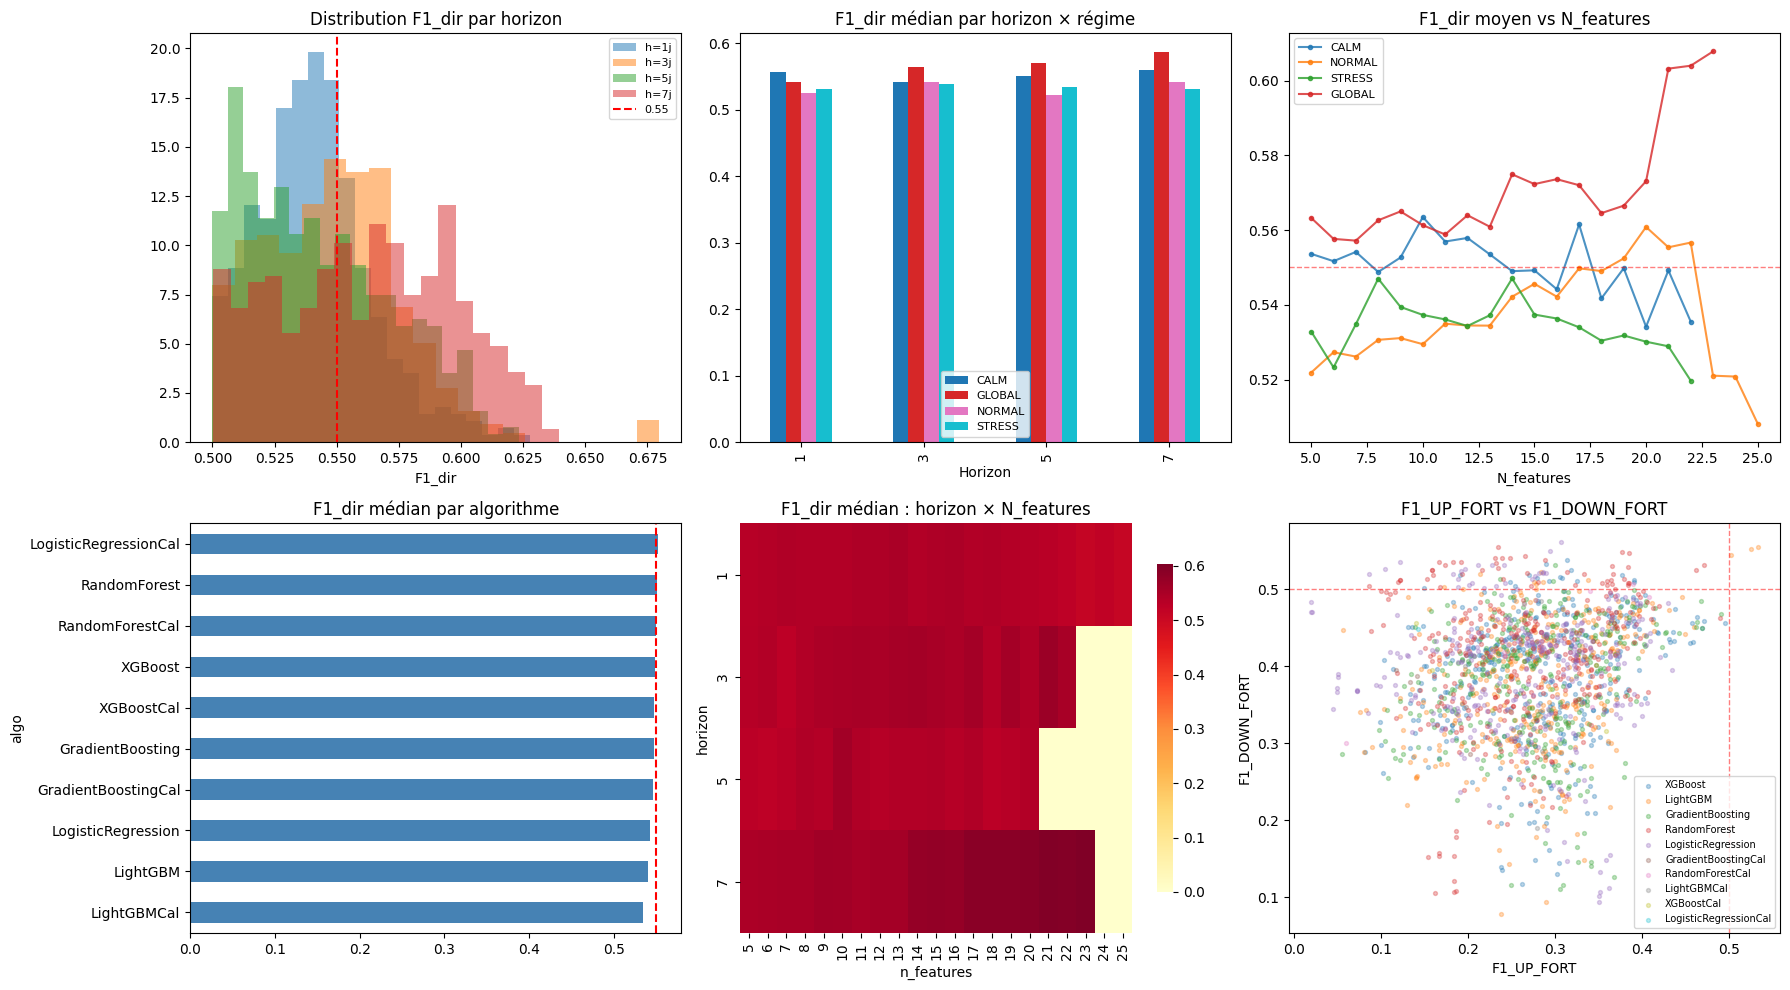


=== Corrélations avec F1_dir ===
F1_dir          1.0000
Acc_dir         0.8236
F1_UP_FORT      0.3647
F1_DOWN_FORT    0.2576
n_features      0.1013

=== Top 10 modèles ===
                                   model_id  horizon regime         algo  n_features  F1_dir  F1_UP_FORT  F1_DOWN_FORT
           egarch_v2_h3_GLOBAL_LightGBM_N14        3 GLOBAL     LightGBM          14  0.6796      0.5245        0.5528
           egarch_v2_h3_GLOBAL_LightGBM_N12        3 GLOBAL     LightGBM          12  0.6789      0.5024        0.5444
           egarch_v2_h3_GLOBAL_LightGBM_N16        3 GLOBAL     LightGBM          16  0.6765      0.5325        0.5549
       egarch_v2_h3_GLOBAL_RandomForest_N13        3 GLOBAL RandomForest          13  0.6750      0.4615        0.5248
       egarch_v2_h3_GLOBAL_RandomForest_N14        3 GLOBAL RandomForest          14  0.6721      0.4706        0.5314
              egarch_v2_h7_CALM_LightGBM_N6        7   CALM     LightGBM           6  0.6396      0.3299        0

In [21]:
# ============================================================
# ANALYSE EXPLORATOIRE DU PANEL
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution F1_dir par horizon
ax = axes[0,0]
for h in sorted(df_runs['horizon'].unique()):
    d = df_runs[df_runs['horizon']==h]['F1_dir']
    ax.hist(d, bins=20, alpha=0.5, label=f'h={h}j', density=True)
ax.axvline(0.55, color='red', ls='--', lw=1.5, label='0.55')
ax.set_title('Distribution F1_dir par horizon')
ax.legend(fontsize=8); ax.set_xlabel('F1_dir')

# 2. Médiane F1_dir par (horizon, regime)
ax = axes[0,1]
df_runs.groupby(['horizon','regime'])['F1_dir'].median().unstack(fill_value=0).plot(
    kind='bar', ax=ax, colormap='tab10')
ax.set_title('F1_dir médian par horizon × régime')
ax.set_xlabel('Horizon'); ax.legend(fontsize=8)

# 3. F1_dir vs N_features
ax = axes[0,2]
for reg in ['CALM','NORMAL','STRESS','GLOBAL']:
    sub = df_runs[df_runs['regime']==reg]
    mn  = sub.groupby('n_features')['F1_dir'].mean()
    ax.plot(mn.index, mn.values, marker='o', ms=3, label=reg, alpha=0.8)
ax.axhline(0.55, color='red', ls='--', lw=1, alpha=0.5)
ax.set_title('F1_dir moyen vs N_features')
ax.set_xlabel('N_features'); ax.legend(fontsize=8)

# 4. F1_dir médian par algo
ax = axes[1,0]
df_runs.groupby('algo')['F1_dir'].median().sort_values().plot(
    kind='barh', ax=ax, color='steelblue')
ax.axvline(0.55, color='red', ls='--', lw=1.5)
ax.set_title('F1_dir médian par algorithme')

# 5. Heatmap F1_dir médian horizon × N_features
ax = axes[1,1]
hm = df_runs.groupby(['horizon','n_features'])['F1_dir'].median().unstack(fill_value=0)
sns.heatmap(hm, ax=ax, cmap='YlOrRd', annot=False, cbar_kws={'shrink':0.8})
ax.set_title('F1_dir médian : horizon × N_features')

# 6. F1_UP_FORT vs F1_DOWN_FORT
ax = axes[1,2]
for algo in df_runs['algo'].unique():
    sub = df_runs[df_runs['algo']==algo]
    ax.scatter(sub['F1_UP_FORT'], sub['F1_DOWN_FORT'], alpha=0.3, s=8, label=algo)
ax.axhline(0.5, color='red', ls='--', lw=1, alpha=0.5)
ax.axvline(0.5, color='red', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('F1_UP_FORT'); ax.set_ylabel('F1_DOWN_FORT')
ax.set_title('F1_UP_FORT vs F1_DOWN_FORT'); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('panel_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# Stats
print("\n=== Corrélations avec F1_dir ===")
num_cols = ['n_features','F1_dir','F1_UP_FORT','F1_DOWN_FORT','Acc_dir']
corr = df_runs[[c for c in num_cols if c in df_runs.columns]].corr()
print(corr['F1_dir'].sort_values(ascending=False).round(4).to_string())

print("\n=== Top 10 modèles ===")
top10 = df_runs.nlargest(10,'F1_dir')[['model_id','horizon','regime','algo','n_features','F1_dir','F1_UP_FORT','F1_DOWN_FORT']]
print(top10.to_string(index=False))


In [22]:
# ============================================================
# SÉLECTION DU PANEL PAR DIVERSITÉ (PRÉ-ENTRAÎNEMENT)
# Critère : overlap de features < 80% entre deux modèles sélectionnés
# ============================================================
def select_by_feature_diversity(df_subset, max_overlap=0.80, top_n=40):
    """
    Sélection greedy par diversité de features.
    1. Trier par F1_dir décroissant
    2. Ajouter si overlap features < max_overlap avec tous les déjà sélectionnés
    """
    selected    = []
    selected_f  = []  # feature sets des sélectionnés

    for _, row in df_subset.sort_values('F1_dir', ascending=False).iterrows():
        feats_new = set(row['features'])
        if not feats_new: continue

        if not selected:
            selected.append(row['model_id'])
            selected_f.append(feats_new)
            continue

        max_ov = max(
            len(feats_new & fs) / max(len(feats_new | fs), 1)
            for fs in selected_f
        )
        if max_ov < max_overlap:
            selected.append(row['model_id'])
            selected_f.append(feats_new)

        if len(selected) >= top_n:
            break

    return selected


print("Sélection du panel par diversité de features...")
panel_ids = []
for h in sorted(df_runs['horizon'].unique()):
    for reg in ['CALM','NORMAL','STRESS','GLOBAL']:
        sub = df_runs[(df_runs['horizon']==h) & (df_runs['regime']==reg)]
        if sub.empty: continue
        sel = select_by_feature_diversity(sub, max_overlap=CONFIG['max_feat_overlap'],
                                           top_n=CONFIG['top_n_per_cell'])
        panel_ids.extend(sel)
        f1_sel = df_runs.loc[df_runs['model_id'].isin(sel),'F1_dir']
        print(f"  h={h}j {reg:<8}: {len(sub):4d} runs → {len(sel):3d} sélectionnés "
              f"| F1 [{f1_sel.min():.3f} - {f1_sel.max():.3f}]")

# Dédupliquer
panel_ids = list(dict.fromkeys(panel_ids))
df_panel  = df_runs[df_runs['model_id'].isin(panel_ids)].reset_index(drop=True)
print(f"\nPanel pré-sélectionné: {len(df_panel)} modèles (sur {len(df_runs)} total)")


Sélection du panel par diversité de features...
  h=1j CALM    :  129 runs →   9 sélectionnés | F1 [0.559 - 0.628]
  h=1j NORMAL  :  100 runs →   8 sélectionnés | F1 [0.511 - 0.579]
  h=1j STRESS  :  128 runs →   8 sélectionnés | F1 [0.538 - 0.584]
  h=1j GLOBAL  :   86 runs →   6 sélectionnés | F1 [0.538 - 0.575]
  h=3j CALM    :  158 runs →   9 sélectionnés | F1 [0.532 - 0.611]
  h=3j NORMAL  :  152 runs →  10 sélectionnés | F1 [0.506 - 0.612]
  h=3j STRESS  :   81 runs →   7 sélectionnés | F1 [0.513 - 0.572]
  h=3j GLOBAL  :   96 runs →   9 sélectionnés | F1 [0.562 - 0.680]
  h=5j CALM    :  108 runs →   8 sélectionnés | F1 [0.507 - 0.623]
  h=5j NORMAL  :  114 runs →  10 sélectionnés | F1 [0.507 - 0.564]
  h=5j STRESS  :   75 runs →   6 sélectionnés | F1 [0.515 - 0.587]
  h=5j GLOBAL  :  117 runs →   8 sélectionnés | F1 [0.570 - 0.620]
  h=7j CALM    :   95 runs →   8 sélectionnés | F1 [0.543 - 0.640]
  h=7j NORMAL  :  130 runs →   9 sélectionnés | F1 [0.531 - 0.629]
  h=7j STRESS 

In [23]:
# ============================================================
# ENTRAÎNEMENT DU PANEL SÉLECTIONNÉ
# ============================================================
trained_clfs   = {}   # model_id → fitted classifier
trained_scalers= {}   # model_id → RobustScaler
trained_fcols  = {}   # model_id → liste de features
trained_metrics= {}   # model_id → dict métriques
trained_proba  = {}   # model_id → array (N_test, 4)
trained_meta   = {}   # model_id → config complète

t_total = time.time()
n_total = len(df_panel)
n_ok    = 0

for i, (_, cfg) in enumerate(df_panel.iterrows()):
    mid    = cfg['model_id']
    h      = int(cfg['horizon'])
    regime = cfg['regime']
    algo   = cfg['algo']
    feats  = cfg['features']
    ts     = cfg['train_start']
    t0     = time.time()

    # Récupérer la target
    tgt_info = TARGETS[h]
    target   = tgt_info['target']
    reg_s    = tgt_info['regime']

    # Construire la matrice de features
    df_al = df_features.reindex(target.index)
    X_mat = build_feature_matrix(df_al, feats)
    if X_mat.empty or X_mat.shape[1] == 0:
        continue

    X_mat = X_mat.copy()
    X_mat[TARGET_COL] = target

    # Splits train / test
    try:
        ts_dt = pd.Timestamp(ts)
    except:
        ts_dt = pd.Timestamp('2000-01-01')

    mask_tr = (X_mat.index <  pd.Timestamp(TEST_DATE)) & (X_mat.index >= ts_dt)
    mask_te = (X_mat.index >= pd.Timestamp(TEST_DATE))
    df_tr   = X_mat.loc[mask_tr].dropna(subset=[TARGET_COL])
    df_te   = X_mat.loc[mask_te].dropna(subset=[TARGET_COL])

    # Filtrer par régime
    if regime != 'GLOBAL':
        mask_reg_tr = reg_s.reindex(df_tr.index) == regime
        mask_reg_te = reg_s.reindex(df_te.index) == regime
        df_tr = df_tr.loc[mask_reg_tr.fillna(False)]
        df_te = df_te.loc[mask_reg_te.fillna(False)]

    feat_cols = [c for c in X_mat.columns if c != TARGET_COL]
    if len(df_tr) < 30 or len(df_te) < 5:
        continue

    y_tr = df_tr[TARGET_COL].values.astype(int)
    y_te = df_te[TARGET_COL].values.astype(int)
    X_tr = df_tr[feat_cols].fillna(0).values
    X_te = df_te[feat_cols].fillna(0).values

    # Scaler
    sc      = RobustScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    # SMOTE
    try:
        samp       = get_sampler(cfg.get('sampler','SMOTE'))
        X_res,y_res= samp.fit_resample(X_tr_sc, y_tr)
    except:
        X_res,y_res= X_tr_sc, y_tr

    # Entraînement
    try:
        clf = get_clf(algo, cfg.get('best_params','{}'))
        clf.fit(X_res, y_res)
    except Exception as e:
        continue

    # Évaluation
    y_pred = clf.predict(X_te_sc)
    y_prob = align_proba_4cls(clf, X_te_sc)
    met    = compute_metrics(y_te, y_pred)

    trained_clfs[mid]    = clf
    trained_scalers[mid] = sc
    trained_fcols[mid]   = feat_cols
    trained_metrics[mid] = {**met,
                             'horizon':h, 'regime':regime, 'algo':algo,
                             'n_features':int(cfg['n_features']),
                             'F1_dir_ref':float(cfg['F1_dir'])}
    trained_proba[mid]   = y_prob
    trained_meta[mid]    = dict(cfg)
    n_ok += 1

    if (i+1) % 25 == 0 or i < 5:
        print(f"  [{i+1:4d}/{n_total}] {mid[:55]:<55} "
              f"F1_dir={met['F1_dir']:.4f} ({time.time()-t0:.1f}s)")

print(f"\n[DONE] {n_ok}/{n_total} modèles entraînés en {time.time()-t_total:.1f}s")


  [   1/133] egarch_v2_h1_CALM_XGBoost_N5                            F1_dir=0.5136 (0.3s)
  [   2/133] egarch_v2_h1_CALM_XGBoost_N9                            F1_dir=0.5136 (0.3s)
  [   3/133] egarch_v2_h1_CALM_XGBoost_N12                           F1_dir=0.5181 (0.4s)
  [   4/133] egarch_v2_h1_CALM_LightGBM_N7                           F1_dir=0.4924 (0.3s)
  [   5/133] egarch_v2_h1_CALM_LightGBM_N18                          F1_dir=0.5178 (0.3s)
  [  25/133] egarch_v2_h3_STRESS_RandomForest_N15                    F1_dir=0.5406 (0.8s)
  [  75/133] egarch_v1_h1_NORMAL_GradientBoosting_N22                F1_dir=0.5197 (2.8s)
  [ 100/133] egarch_v1_h3_GLOBAL_RandomForest_N15                    F1_dir=0.5144 (1.3s)

[DONE] 86/133 modèles entraînés en 82.4s


=== Analyse corrélation inter-prédictions ===
  N modèles entraînés: 86
  Corrélation inter: mean=0.039 | median=0.017 | >0.85=0.8%


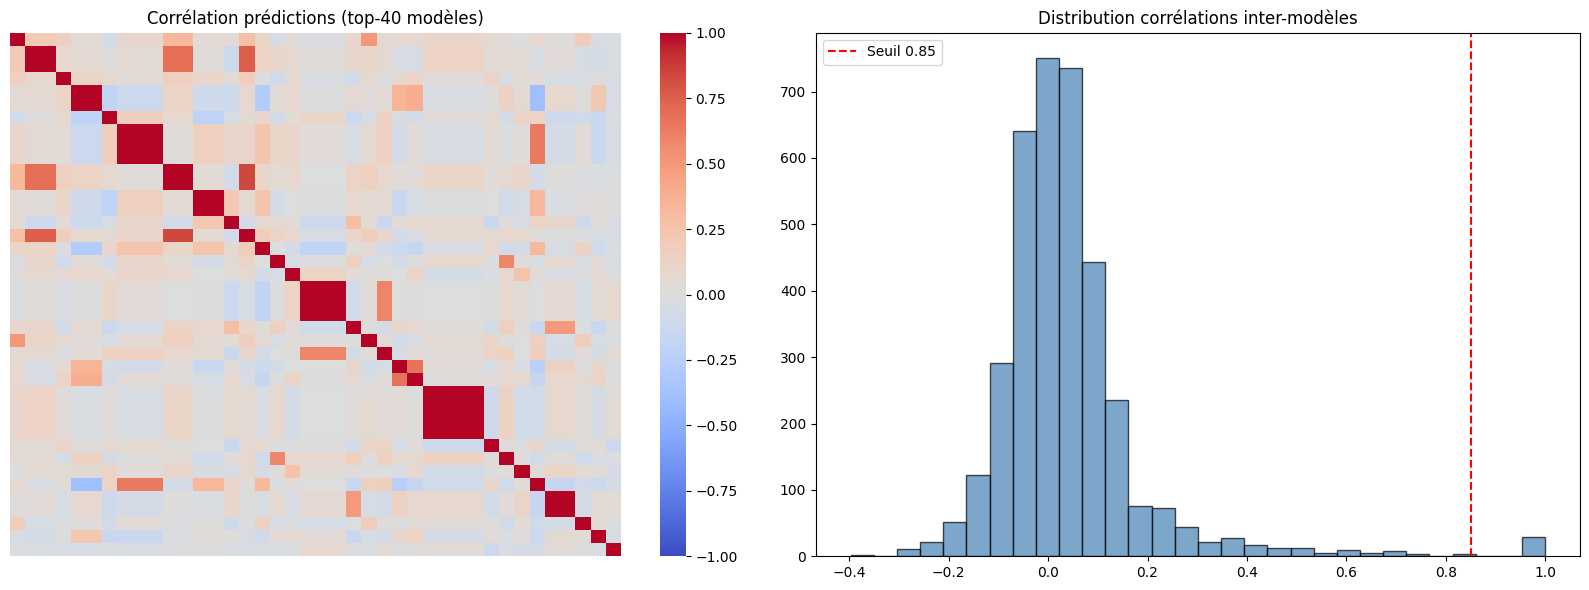


Panel final (diversité prédictions): 64 modèles
regime   CALM  GLOBAL  NORMAL  STRESS
horizon                              
1           5       4       5       4
3           5       8       2       7
5           6       3       2       4
7           1       3       1       4

F1_dir panel final: mean=0.5156 max=0.6220


In [24]:
# ============================================================
# RE-SÉLECTION PAR CORRÉLATION DES PRÉDICTIONS RÉELLES
# Éliminer les modèles redondants (corr > 0.85)
# ============================================================
print("=== Analyse corrélation inter-prédictions ===")

# Matrice directions prédites
dir_preds   = {}
for mid, prob in trained_proba.items():
    dir_preds[mid] = (prob[:,2] + prob[:,3] > 0.5).astype(int)

model_ids_list = list(dir_preds.keys())
min_len        = min(len(v) for v in dir_preds.values())
dir_matrix     = np.column_stack([dir_preds[m][:min_len] for m in model_ids_list])

corr_matrix = np.corrcoef(dir_matrix.T)
upper_tri   = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
print(f"  N modèles entraînés: {len(model_ids_list)}")
print(f"  Corrélation inter: mean={upper_tri.mean():.3f} | "
      f"median={np.median(upper_tri):.3f} | "
      f">0.85={( upper_tri>0.85).mean():.1%}")

# Heatmap (top 40)
n_show = min(40, len(model_ids_list))
top_ids = sorted(model_ids_list, key=lambda x: trained_metrics[x].get('F1_dir',0), reverse=True)[:n_show]
top_idx = [model_ids_list.index(m) for m in top_ids]
sub_corr = corr_matrix[np.ix_(top_idx, top_idx)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(sub_corr, ax=axes[0], cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False)
axes[0].set_title(f'Corrélation prédictions (top-{n_show} modèles)')
axes[1].hist(upper_tri, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].axvline(CONFIG['max_pred_corr'], color='red', ls='--', label=f"Seuil {CONFIG['max_pred_corr']}")
axes[1].set_title('Distribution corrélations inter-modèles')
axes[1].legend()
plt.tight_layout(); plt.show()

# Sélection greedy par diversité des prédictions réelles
def select_by_pred_diversity(model_ids, dir_preds_dict, metrics_dict,
                               max_corr=0.85):
    selected     = []
    selected_dir = []
    for mid in sorted(model_ids, key=lambda x: metrics_dict.get(x,{}).get('F1_dir',0), reverse=True):
        d_new = dir_preds_dict[mid][:min_len]
        if not selected:
            selected.append(mid); selected_dir.append(d_new); continue
        corrs = [np.corrcoef(d_new, d_old[:len(d_new)])[0,1]
                 for d_old in selected_dir]
        if max(corrs) < max_corr:
            selected.append(mid); selected_dir.append(d_new)
    return selected

final_panel = select_by_pred_diversity(
    model_ids_list, dir_preds, trained_metrics,
    max_corr=CONFIG['max_pred_corr']
)
print(f"\nPanel final (diversité prédictions): {len(final_panel)} modèles")

# Distribution dans le panel final
df_final_stats = pd.DataFrame([trained_metrics[m] for m in final_panel if m in trained_metrics])
if not df_final_stats.empty:
    print(df_final_stats.groupby(['horizon','regime']).size().unstack(fill_value=0).to_string())
    print(f"\nF1_dir panel final: mean={df_final_stats['F1_dir'].mean():.4f} "
          f"max={df_final_stats['F1_dir'].max():.4f}")


In [25]:
# ============================================================
# STACKING — Génération des probabilités OOF
# Out-of-Fold: zéro leakage garanti
# ============================================================
META_TARGET_H = 5  # Cible principale du méta-modèle

print(f"=== STACKING OOF | {len(final_panel)} modèles | cible h={META_TARGET_H}j ===")

tgt_meta  = TARGETS[META_TARGET_H]['target']
tr_dates  = tgt_meta.index[tgt_meta.index <  pd.Timestamp(TEST_DATE)]
te_dates  = tgt_meta.index[tgt_meta.index >= pd.Timestamp(TEST_DATE)]
y_tr_dir  = (tgt_meta.reindex(tr_dates).fillna(0).values >= 2).astype(int)
y_te_dir  = (tgt_meta.reindex(te_dates).fillna(0).values >= 2).astype(int)
y_tr_4    = tgt_meta.reindex(tr_dates).fillna(0).values.astype(int)
y_te_4    = tgt_meta.reindex(te_dates).fillna(0).values.astype(int)

def generate_oof(mid, n_folds=5):
    """
    Génère les probabilités OOF pour un modèle donné.
    Re-entraîne le modèle sur K-1 folds et prédit sur le Kème.
    """
    cfg   = trained_meta[mid]
    h     = int(cfg['horizon'])
    reg   = str(cfg['regime'])
    algo  = str(cfg['algo'])
    feats = cfg['features']
    ts    = str(cfg.get('train_start','2000-01-01'))

    tgt_h = TARGETS[h]['target']
    reg_s = TARGETS[h]['regime']
    df_al = df_features.reindex(tgt_h.index)
    X_mat = build_feature_matrix(df_al, feats)
    if X_mat.empty: return None, None

    X_mat = X_mat.copy()
    X_mat[TARGET_COL] = tgt_h

    try: ts_dt = pd.Timestamp(ts)
    except: ts_dt = pd.Timestamp('2000-01-01')

    df_tr2 = X_mat.loc[(X_mat.index < pd.Timestamp(TEST_DATE)) &
                        (X_mat.index >= ts_dt)].dropna(subset=[TARGET_COL])
    if reg != 'GLOBAL':
        df_tr2 = df_tr2.loc[reg_s.reindex(df_tr2.index).fillna('NORMAL') == reg]
    if len(df_tr2) < 50: return None, None

    fc    = [c for c in X_mat.columns if c != TARGET_COL]
    sc    = trained_scalers[mid]
    X_t   = sc.transform(df_tr2[fc].fillna(0).values)
    y_t   = df_tr2[TARGET_COL].values.astype(int)

    oof_p = np.full((len(X_t), 4), 0.25)
    tscv  = TimeSeriesSplit(n_splits=n_folds)

    for tr_i, va_i in tscv.split(X_t):
        if len(va_i) < 5: continue
        try:
            samp_name = cfg.get('sampler','SMOTE')
            samp = get_sampler(samp_name)
            Xr, yr = samp.fit_resample(X_t[tr_i], y_t[tr_i])
        except:
            Xr, yr = X_t[tr_i], y_t[tr_i]
        try:
            c = get_clf(algo, cfg.get('best_params','{}'))
            c.fit(Xr, yr)
            p = align_proba_4cls(c, X_t[va_i])
            oof_p[va_i] = p
        except:
            pass

    return oof_p, df_tr2.index


# Générer les OOF et aligner sur l'index meta
meta_tr_dfs, meta_te_dfs, used_ids = [], [], []
t0 = time.time()

for i, mid in enumerate(final_panel):
    if mid not in trained_clfs: continue

    # OOF sur le train
    oof, oof_dates = generate_oof(mid, n_folds=CONFIG['n_folds_oof'])
    if oof is None: continue

    cols_mid = [f'{mid}_c{k}' for k in range(4)]
    oof_df   = pd.DataFrame(oof, index=oof_dates, columns=cols_mid)
    meta_tr_dfs.append(oof_df.reindex(tr_dates).fillna(0.25))

    # Prédictions test (déjà calculées)
    proba_te = trained_proba[mid]
    cfg_r    = trained_meta[mid]
    h_m      = int(cfg_r['horizon']); reg_m = str(cfg_r['regime'])
    te_h     = TARGETS[h_m]['target'].index
    te_h     = te_h[te_h >= pd.Timestamp(TEST_DATE)]
    if reg_m != 'GLOBAL':
        reg_s_m = TARGETS[h_m]['regime']
        te_h    = te_h[reg_s_m.reindex(te_h).fillna('NORMAL') == reg_m]
    n_te_m = min(len(proba_te), len(te_h))
    te_df  = pd.DataFrame(proba_te[:n_te_m], index=te_h[:n_te_m], columns=cols_mid)
    meta_te_dfs.append(te_df.reindex(te_dates).fillna(0.25))

    used_ids.append(mid)
    if (i+1) % 10 == 0:
        print(f"  OOF [{i+1}/{len(final_panel)}] ({time.time()-t0:.1f}s)")

meta_X_tr = pd.concat(meta_tr_dfs, axis=1).fillna(0.25) if meta_tr_dfs else pd.DataFrame()
meta_X_te = pd.concat(meta_te_dfs, axis=1).fillna(0.25) if meta_te_dfs else pd.DataFrame()

print(f"\n  Méta-features: train={meta_X_tr.shape} | test={meta_X_te.shape}")
print(f"  Modèles utilisés: {len(used_ids)} ({time.time()-t0:.1f}s)")


=== STACKING OOF | 64 modèles | cible h=5j ===
  OOF [10/64] (29.6s)
  OOF [20/64] (71.6s)
  OOF [30/64] (107.9s)
  OOF [40/64] (136.7s)
  OOF [50/64] (157.1s)
  OOF [60/64] (187.3s)

  Méta-features: train=(5412, 256) | test=(1355, 256)
  Modèles utilisés: 64 (189.0s)


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
# ============================================================
# MÉTA-MODÈLES — Vote + XGBoost direction + XGBoost 4 classes
# ============================================================
t0 = time.time()

# ── Vote pondéré ─────────────────────────────────────────────────────────────
score_up   = np.zeros(len(meta_X_te))
score_down = np.zeros(len(meta_X_te))
for mid in used_ids:
    f1 = trained_metrics.get(mid,{}).get('F1_dir', 0.5)
    for k in [2,3]:
        col = f'{mid}_c{k}'
        if col in meta_X_te.columns: score_up   += f1 * meta_X_te[col].values
    for k in [0,1]:
        col = f'{mid}_c{k}'
        if col in meta_X_te.columns: score_down += f1 * meta_X_te[col].values

y_vote    = (score_up > score_down).astype(int)
f1_vote   = f1_score(y_te_dir, y_vote, average='macro', zero_division=0)
acc_vote  = accuracy_score(y_te_dir, y_vote)
print(f"Vote pondéré:    F1_dir={f1_vote:.4f}  Acc={acc_vote:.4f}")

# ── Méta-modèle direction ─────────────────────────────────────────────────────
meta_dir = XGBClassifier(
    n_estimators=CONFIG['meta_n_estimators'],
    max_depth=CONFIG['meta_max_depth'],
    learning_rate=CONFIG['meta_lr'],
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0
)
meta_dir.fit(meta_X_tr.values, y_tr_dir)
y_pred_dir   = meta_dir.predict(meta_X_te.values)
f1_meta_dir  = f1_score(y_te_dir, y_pred_dir, average='macro', zero_division=0)
acc_meta_dir = accuracy_score(y_te_dir, y_pred_dir)
print(f"Méta XGB dir:    F1_dir={f1_meta_dir:.4f}  Acc={acc_meta_dir:.4f}")

# ── Méta-modèle 4 classes ─────────────────────────────────────────────────────
meta_4cls = XGBClassifier(
    n_estimators=CONFIG['meta_n_estimators'],
    max_depth=CONFIG['meta_max_depth'],
    learning_rate=CONFIG['meta_lr'],
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', objective='multi:softprob',
    random_state=SEED, n_jobs=-1, verbosity=0
)
meta_4cls.fit(meta_X_tr.values, y_tr_4)
y_pred_4cls = meta_4cls.predict(meta_X_te.values)
met_4cls    = compute_metrics(y_te_4, y_pred_4cls)
print(f"Méta XGB 4cls:   F1_dir={met_4cls['F1_dir']:.4f}  "
      f"F1_UP_FORT={met_4cls['F1_UP_FORT']:.4f}  "
      f"F1_DOWN_FORT={met_4cls['F1_DOWN_FORT']:.4f}")

# ── SHAP sur le méta-modèle 4 classes ────────────────────────────────────────
print("\nSHAP importance sur le méta-modèle 4 classes...")
try:
    expl = shap.TreeExplainer(meta_4cls)
    sv   = expl.shap_values(meta_X_te.values[:min(300,len(meta_X_te))])
    if isinstance(sv, list): arr = np.mean([np.abs(s) for s in sv], axis=0)
    elif np.array(sv).ndim == 3: arr = np.abs(sv).mean(axis=2)
    else: arr = np.abs(sv)
    shap_scores = pd.Series(arr.mean(axis=0), index=meta_X_te.columns)
    top_shap    = shap_scores.nlargest(30)

    print("\nTop-15 features SHAP du méta-modèle:")
    for feat, score in top_shap.head(15).items():
        mid_src = '_c'.join(feat.split('_c')[:-1])
        info    = trained_metrics.get(mid_src, {})
        print(f"  {feat[:60]:<60} SHAP={score:.5f} "
              f"(h={info.get('horizon','?')}j {info.get('regime','?'):<8} "
              f"F1={info.get('F1_dir',0):.3f})")
except Exception as e:
    print(f"  [WARN] SHAP: {e}")
    top_shap = pd.Series(dtype=float)

print(f"\nTemps total méta-modèles: {time.time()-t0:.1f}s")


Vote pondéré:    F1_dir=0.5848  Acc=0.5882
Méta XGB dir:    F1_dir=0.5781  Acc=0.6074
Méta XGB 4cls:   F1_dir=0.5621  F1_UP_FORT=0.1868  F1_DOWN_FORT=0.6265

SHAP importance sur le méta-modèle 4 classes...

Top-15 features SHAP du méta-modèle:
  egarch_v2_h7_GLOBAL_RandomForest_N22_c0                      SHAP=0.05278 (h=7j GLOBAL   F1=0.549)
  egarch_v1_h1_GLOBAL_RandomForest_N6_c0                       SHAP=0.05241 (h=1j GLOBAL   F1=0.565)
  egarch_v1_h1_GLOBAL_RandomForest_N6_c2                       SHAP=0.04146 (h=1j GLOBAL   F1=0.565)
  egarch_v2_h5_GLOBAL_LogisticRegression_N10_c2                SHAP=0.03595 (h=5j GLOBAL   F1=0.563)
  egarch_v2_h7_GLOBAL_RandomForest_N16_c2                      SHAP=0.03325 (h=7j GLOBAL   F1=0.567)
  egarch_v2_h3_GLOBAL_LogisticRegression_N19_c2                SHAP=0.03086 (h=3j GLOBAL   F1=0.492)
  egarch_v1_h1_GLOBAL_LogisticRegression_N9_c3                 SHAP=0.02806 (h=1j GLOBAL   F1=0.527)
  egarch_v2_h5_GLOBAL_LogisticRegression_N10_c0  

In [28]:
# ============================================================
# RAPPORT FINAL + EXPORT EXCEL
# ============================================================
print("\n" + "="*75)
print(f"RAPPORT FINAL — Stacking sur {len(used_ids)} modèles diversifiés")
print(f"Cible méta-modèle: h={META_TARGET_H}j | Split 80/20")
print("="*75)

print(f"\n{'Modèle':<50} {'F1_dir':>8} {'F1_UP_FORT':>12} {'F1_DOWN_FORT':>14}")
print("─"*87)

# Méta-modèles
print(f"  {'Vote pondéré':<48} {f1_vote:>8.4f}")
print(f"  {'Méta XGBoost (direction)':<48} {f1_meta_dir:>8.4f}  {'Acc='+str(round(acc_meta_dir,4)):>12}")
print(f"  {'Méta XGBoost (4 classes)':<48} {met_4cls['F1_dir']:>8.4f} "
      f"{met_4cls['F1_UP_FORT']:>12.4f} {met_4cls['F1_DOWN_FORT']:>14.4f}")

print("─"*87)
print("  Benchmarks ML (meilleurs modèles individuels):")
for k,v in ML_REFS.items():
    print(f"  {k:<48} {v['F1_dir']:>8.4f} "
          f"{str(v.get('F1_UP_FORT','—')):>12} {str(v.get('F1_DOWN_FORT','—')):>14}")

print("─"*87)
print("  Benchmarks DL (meilleurs par horizon):")
for h_dl, info in DL_RESULTS.items():
    print(f"  DL h={h_dl}j {info['model']:<40} {info['F1_dir']:>8.4f} "
          f"{info['F1_UP_FORT']:>12.4f} {info['F1_DOWN_FORT']:>14.4f}")

print("─"*87)
print("  Meilleurs modèles individuels du panel:")
top5_panel = sorted(
    [(m,trained_metrics[m]) for m in used_ids if m in trained_metrics],
    key=lambda x: -x[1].get('F1_dir',0)
)[:5]
for mid, met in top5_panel:
    print(f"  {mid[:48]:<48} {met.get('F1_dir',0):>8.4f} "
          f"{met.get('F1_UP_FORT',0):>12.4f} {met.get('F1_DOWN_FORT',0):>14.4f}")

# ── Export Excel ──────────────────────────────────────────────────────────────
try:
    rows_panel = [{'Model_ID':m, **trained_metrics[m]} for m in used_ids if m in trained_metrics]
    df_panel_out = pd.DataFrame(rows_panel).sort_values('F1_dir', ascending=False)

    rows_meta = [
        {'Model_ID':'Vote_Pondéré',    'F1_dir':f1_vote,        'Acc_dir':acc_vote,
         'N_models':len(used_ids), 'type':'ensemble'},
        {'Model_ID':'Meta_XGB_dir',    'F1_dir':f1_meta_dir,    'Acc_dir':acc_meta_dir,
         'N_models':len(used_ids), 'type':'stacking'},
        {'Model_ID':'Meta_XGB_4cls',   **met_4cls,
         'N_models':len(used_ids), 'type':'stacking'},
    ]
    df_meta_out = pd.DataFrame(rows_meta)

    shap_out = (top_shap.reset_index()
                .rename(columns={'index':'Feature', 0:'SHAP_importance'})
                if not top_shap.empty else pd.DataFrame())

    with pd.ExcelWriter('vix_stacking_v2_report.xlsx', engine='xlsxwriter') as w:
        df_panel_out.to_excel(w, sheet_name='Panel_Models',    index=False)
        df_meta_out.to_excel( w, sheet_name='Stacking_Results',index=False)
        if not shap_out.empty:
            shap_out.to_excel(w, sheet_name='SHAP_Meta',       index=False)
        # Stats panel
        df_panel_out.groupby(['horizon','regime'])['F1_dir'].agg(
            ['count','mean','max']
        ).reset_index().to_excel(w, sheet_name='Panel_Stats', index=False)

    print("\n[SAVE] vix_stacking_v2_report.xlsx")
except Exception as e:
    print(f"[WARN Export] {e}")

print("\n[NOTE] Aucun modèle enregistré — validation explicite requise.")



RAPPORT FINAL — Stacking sur 64 modèles diversifiés
Cible méta-modèle: h=5j | Split 80/20

Modèle                                               F1_dir   F1_UP_FORT   F1_DOWN_FORT
───────────────────────────────────────────────────────────────────────────────────────
  Vote pondéré                                       0.5848
  Méta XGBoost (direction)                           0.5781    Acc=0.6074
  Méta XGBoost (4 classes)                           0.5621       0.1868         0.6265
───────────────────────────────────────────────────────────────────────────────────────
  Benchmarks ML (meilleurs modèles individuels):
  LogReg h=5j GLOBAL                                 0.6340        0.406          0.575
  RandomForest h=5j GLOBAL                           0.6200        0.412          0.462
  Stacking V1 (27 modèles)                           0.5960         None           None
───────────────────────────────────────────────────────────────────────────────────────
  Benchmarks DL (meil